<a href="https://colab.research.google.com/github/JoDeMiro/Micado-Research/blob/main/ML_Auto_X26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Format Notebook

from IPython.core.display import display, HTML

display(HTML('''
<style>
.container {
    width: 95% !important;
    margin-left: auto !important;
    margin-right: auto !important;
}
</style>
'''))


# ML Auto X28.ipynb <- X26.ipynb-ből

<a name='top'></a>

## Gyors link
[log](#log) [car](#car) [run](#run) [zip](#zip)

[Setup](#setup_current_train)

[Experiments](#experiments)

**ToDo:**

Át kell írnom egy új változatban (csak demo célból) hogy nem előre<br>
hanem oldarla néznek a szezorok (az is ami most egyenesen előre néz)<br>
és mindegyik egy az egyben rá legyen mappalve egy értékere (lehet negatív is).

Mivel ezekből fogom előállítani az 'út közepét' is az se gond ha mindegyik <br> érték az 'út közepe' fölött van (mondjuk kivonok belőle egy értéket) vagy<br>
fölötte van (hozzáadok plusz 10000 ret).

Ehhez át kell írnom a Car osztályt.



Lényeges változás az ML Auto 27-hoz képest,

> Válaszható lett, hogy a Lineáris Regressziós becslés használjon-e Intercptet vagy ne (alapból False)

> Bevezettem hogy paraméterezve lehessen megadni a Car() létrehozásánál a neurális háló paramétereit.

> Bevezettem hogy a lehetséges actionok (-7, ..., +7) is paraméterből legyen megadható a Car() létrehozásánál.

> Plot3DVersion5RCLY() plot a régi Plot3DVersion5() helyett ami Right, Left, Center szenzorokat mutatja és a szín jelzi az y_distance értéket, az út közepétől mért eltérés mértékét a tanulás alatt.

> LinearRegression helyett RidgeRegression van

> Pytorch alapokra tettem az MLPRegressort

> Választható hogy Pythoch vagy Tensorflow alapon számoljon

> MinMaxScaler helyett most már bármilyen scaler válaszható

> FixScaler -> FixScalerCenteredMax osztály képes 0-ra centrálni olyan inputokat amelyek pozitív eredetileg pozitív skálán vannak (például a sensorok adatai) ---> ez azért kell mert a hálóban az átviteli függvény tahn ezért -1 +1 közé kell transzformálnom a bemeneti adatokat. A FixScaler erre eddig nem volt képes, az új osztály viszont már igen.

> Vissza lehet ellenőrizni a Setup elött hogy sikerült a normalizálás a tanulás alatt.

----> ToDo: Még a Centerre külön scalert akarok írni de ehhez alaposan át kell írnom a kódot.

----> ToDo: Az átviteli függvény és bemeneti-, kimeneti adatok skálázását még jól átgondolni, hogy sync-ben legyenek

Lényeges változás az ML Auto 25-hoz képest,

> Bele raktam néhány pályát, hogy izgalmasabb legyen.

Lényeges változás az ML Auto 24-hez képset,

> Kétszer, két lépcsőben használunk gép tanulási modelt. Minkét modellben a súlyok alakulása nyomotkövethető lett a Plotter osztályban.

Lényeges változás az ML Auto 23-hoz képest,

> - save model és a `storage` osztály bekerült. Lehet majd olyan futást csinálni, hogy már ne tanuljon, hamem egy korábbi tanulás eredményei alapján menjen.



Lényeges változás az ML Auto 21-hez képest,

> - teljesen át lettek írva a plot függvények (volt egy bug a `plot.show()` és a `plot.savefig()` sorrendjével kapcsolatban)
- az ani-gif helyett mp4-be exportálok
- számítási függvényekben változás nem keletkezett

Furhter modifications:

> - kisebb idegösszeomlást kaptam amikor az egész rendszert áttettem egy újjabb numpy scikikt learn verzióra és kiderült ugyan olyan beállítások mellett más eredményt ad `->` az eltérés oka sok féle lehet, de ttől függetlenül rávilágított egy komoly problémára `->` ha az autó kilép a sávból akkor két szenzor értékei nullára állnak `->` ezt a jelnséget mindeféleképen orvosolni kell. <br> <br> Ennek kapcsán csináltam egy kisérletet amiben a középső center értékeit gyakorlatilag konstansra állítottam - ezáltál szinte zéró szerepet kap a számításokban és így is végig tudott menni a pályán, igaz nem olyan szépen.
- még néhány `print()` függvényt át kell irnom `-> printer.decision()`, annak érdekében, hogy az output még kissebb legyen.
- `DataExport()`-ot be kell vezetnem. <br> <br> Ez egy átfogó és nagy munka lesz, de elengedhetetlen a későbbi munkákhoz. <br> <br> Valószínűleg a következő X23-ban fogom elkezdeni fejleszteni de az X24-ben lesz releaselve. (Valószínűleg sok új változót fog generálni és a strukturát is értinteni fogja)
- A tanulás során megtanulst súlyokat rögzítse és legyen perzistens az `mlp` és a `linearRegression`. Ez komoly modsítást és sok átalakítást igényel.
- A sávban található összes pontrja meg kell mérnem az állapotteret és ezeken az adatokon feltanítani a nurális hálót, majd ennek alapján végig engednem a neurális háló tanítása nélkül a pályán `->` az ehhez a kísérlethet tartozó függvényt kell megírnom `<-` de ennek előfeltétele, hogy legyen képes a neurális háló perzistens adatokból dolgozni.

Further plots():

> A plottolás elég fontos eleme a rendszernek. Ezeken keresztül nyerünk betekintést abba, hogy mi is történik a felsznín alatt **nem csak debuggolásra alkalmas de összehasonlításokra is**.
<br> <br>
- szeretnék egy olyan plotot ami az `left.sensor`, `right.sensor`, `y.distance` kapcsolatot mutatja be `->` méghozzá úgy, hogy rajta van az `mlp` által becsült érték is. Ez utóbbi lehet pontfelhő, de lehet surface is.
- szeretnék olyan plotokat, amelyeken:
-- a lineráis regresszió befora `->` after becsléseinek koefficiensei szerepelnek idősorrendben, szenzoronként.
- szeretnék egy olyan plotot ahol a `left.sensor`, 'right.sensor` `y.distance` 3Dimenzióban van ábrázolva és az épen aktuális pont értékét egy hajszákereszt mutatja.

Furhter experiments:

> lassan készen állok minden plot és segédfüggvényel, ezért ipari módon lehet megfuttatni néhány kísérletet.
- Sensorok témakörben elég sok lehetőségem van:
-- elöször is a középső szenzor kiiktatása különösen érdekel, hogy reagál erre a rendszer változatlan beállítások mellett
-- számos lehetőségem van arra is, hogy a rendszer stabilitását vizsgáljam például azzal, hogy milyen messzire látnak a szenzorok.
- Az út eddig három periodikus függvényből állt össze, úgyhogy idővel muszáj neki megtanulnia asz összefüggéseket. `->` Érdekelne, hogy mi van akkor ha:
-- diskrét ugrásokat teszek bele
-- bonyolultabb függvényt kap
-- szélesebb lesz az út
-- változik az út szélessége
Ezekre mind új függvényeket kell írnom és át kell írni a `Road` osztályt úgy, hogy ezek a beállítások mind szépen paraméterezhetőek legyenek, miközben meg tudom örizni `default` beállításnak az eredeti beállítást.

Lényeges változás az ML Auto 21-hez képest,

> hogy minden output ki-be kapcsolható lett.

Válaszható lett.

> Itt annyit változtattam, hogy 'Action' után is visszaengedem a before after adatokat. Ennyivel bővülnek a before after adatok. Igy nem csak a mesterséges mozgatás által jut adatokhoz.

Bevezetésre került:

> MLPPlotter osztály <br>
A GitHub repozitoriumból tölti le. A DrawNN metodus egyben el is menti a képeket, ha a flag 2 vagy 3.

> Plotter osztály <br>
ezen túl minden plot függvény a plotter osztályba kerül de a régieket még nem vezettem át. A plotter osztály függvényei amolyan `static` oszályként működnek. A függvényei paraméterként kapják az értékeket. A `car.run()` metodusán belül szoktam hivogatni őket. Célja, hogy ne a `Car` osztályban legyenek a plot függvények.

Bevezetésre került:

> Storage osztály. Ez felel iminden perzistens tárolásért. Ez végzi a `mlp` és a `linreg` modellek tárolását és visszaolvasását is.

Bevezetésre került:

> PostPlotter osztály <br>
Ennek a lényege, hogy példányosításnál egy car objektumot vár, amiből ki tudja olvasni annak minden adatát, így egy hosszabb futás után is tudok plottolni az `auto` adataiból.

Bevezetésre került:

> Kivettem a before after linreg becslésből az Interceptet

Bevezetésre került:

> Linreg helyett MLP van a main modelben

Bevezetésre került:

> Az action kiszámolásánál az új érték is -1, 1 közé lesz normalizálva

Bevezetésre került:

> Minimum 7, Maximum 7 lépést tehet mindkét irányba

Kivezetésre került:

> pyplot save_plots függvény, ami kexportálja png-be a plottokat -> helyette plot_history(flag)

Változtatásra került:

> Incremental - Online learnig. A neurális hálóban a warm_start beállítása és az iter = 1

Ki lett kapcsolva:

> a save_plot és save_plots ezért a futás sokkal gyorsabb

Változtatásra került:

> Az átviteli függvény 'logistic' helyet 'tanh' lett

Bevezetésre került:

> Új könyvjelzők, főként online learning és gradient descent témakörben

Változtatásra került:

> Az action végrehajtása átkerült a tanuló ágról ( i % 3 == 0 ) a teszt ágra ( i % 3 == 1 )

Változtatásra került (ver. 21):

> loggerek (nn, lr, append) bevezetésre került

Változtatásra került (ver. 21):

> külön objektumba került az MLPRegressor


# Későbbi kísérletek

> - MLP activation function {relu, tanh, logistic} <br> mindegyikkel vigyázni kell mert más más normalizációt igényelnek `->` bár már korábban megállapítottam, hogy a [-1, +1] transzformáció a legjobb minden esetben. <br> <br> Az már pár próba alapján látszik, - és tudni is lehetett - hogy vannak különbségek. A `logistic` elég jól teljesített, de még megy a `->` szisztematikus tesztelésbe.
- Legyen meg az, hogy egy feltanított háló hogyan teljesít a pályán az elejétől a végéig, úgy hogy már nem tanul többet.
- Legyen a teljes állapot téren feltanított neurális háló alapján végrehajtott futás is elvégezve és ez erdemények kiértékelve, majd összevetve a korábbi eredményekkel.
- Átteni a döntéshozás a predicted fázisba( i % 3 == 1 )


# Jegyzet

Ne felejtsük el, hogy a before after linregnek nem kell normalizálnia az adatokat.
Az viszont már fontos, hogy amikor a linreg before-after adatok alapján becslést
készítünk arra, hogy mi lesz a fel-le eredménye a neurális hálóba engedve
akkor ott normalizálnunk kell a bemenetet. <br> <br> Minden ilyen lépés magában hordozza a potenciális hiba lehetőségét. Nem mindegy, hogy a `minmax_scaler` az új adatokat egy korábban normalizált adatsoron vagy az új értékeken végzi el. Erre mindíg oda kell fegyelni [ToDo: Végig ellenőrizni az összeset]

# ToDo

**Gondolat:**

Nyilvánvaló, hogy egy idő után se a before after adatokra nem képes jó becslést adni
```
proba_X_metrika   =  [[1 1]]
-------- 1 y up ->  left   =  [[2.13709439]]
-------- 1 y up ->  center =  [[1.94404015]]
-------- 1 y up ->  right  =  [[1.85292015]]
```
Ezért arra gondoltam, hogy beeresztem azokat az adatokat is, amelyeket az action körben lép meg. <br>
Ha úgy se megy akkor át kell gondolni a képletet! A becslés képleétt, before after.

**ToDo:**

Csinálni kell egy ábrát, hogy mi a kapcsolat a tényleges before after között és nem csinálni rá semmilyen becslét. Egyszerűen minden metrikára megnézni, hogy mi a lépés elötti adata és mi a lépés utáni adata. Ezt meg lehet csinálni úgy, hogy egy ploton vízszintesen van before, fűggőlegesen az after, és színnel van kódolva az action (kék +1, piros -1) **Done** Ez lett a `plot_before_after_sensor_values` függvény.

Ennek az lenne az értelme, hogy lássuk a egyáltalán megragadható-e valamilyen lináris kapcsolat a before - after adatok között - vagy ez egyáltalán elvárható-e a lineáris regressziótól


1. A fenti viszgálatot azért végzem el, hogy lássam, hol kap olyan adatokat **milyen helyzetben kap olyan adatokat** a before after adatsor amitől ilyen mértékben elromlik az előre jelző képessége.

2. Teljesen nyilvánvaló, hogy a szenzoros adatok és a tengelytől mért távolság közötti kapcsolatot a lineáris regresszió képtelen megragadni.

3. Utána ki kell próbálni, hogy a szenzorok nem előre néznek, hanem oldalra. Igen ez teljes egészében az amit a célváltozó is mér. De csak ellenőrzés végett.

4. A fenti kísérlet sorozatot elvégeztem. **Mindegyik állítás validálva**


**ToDo:**

A before - after linregnél elgondolkoztam azon, hogy egy egy szélső eset nagyon el tudja húzni a becslést ezért lehet, hogy Huber költségfüggvényt kéne használnom a négyzetes hiba helyett - A hivatkozások között is jeleztem. Az `SGDRegressor` pedig alapból tudja.

Fenti állítás időközben megoldódott - mási miatt ment el a linreg becslése. Azóta ezt a hibát már korrigáltam. Ha mégis meg akarom nyugtatni magam akkor van egy külön plot függvényem arra ami az `after_predicted` `->` `after_true` becslés kapcsolatát mutatja be.


<a name="tartalom"></a>
## Tartalom

Bevezetés

> [Bevezető](#bevezeto)<br>
> [Play Ground](#play_ground)<br>
> [Semmi-Supervised learning](#szintetikus_adatok)<br>
> [Korábbi hibák](#korabbi_hibak)<br>
> [Irodalom](#irodalom)<br>
> [ToDo](#todo)<br>
> [Top](#top)<br>

<a name="tartalom"></a>
## Bevezető gondolat

Összességében az egésszel kapcsolatban van egy hatalmas kérdőjel.

Tulajdonképpen két paradigma van.

Az egyik - nem az enyém - így néz ki:

Egyszerűen becsüjük meg azt, hogy az adott szenzoros adatok alapján mi legyen a döntés kimenetele (fel, le, semmi). Akkor hoztunk jó döntést, ha valamilyen metrika alapján valamilyen költséget minimalizáltunk, vagy maximalizáltunk. Például, ha egy döntéssel sikerült közelebb kerülni a záróvonalhoz, vagyis az út közepére. Vagy az az autó a lehető legmeszebb jutott el anélkül, hogy érintette volna a falat és lehetőleg a legrövidebb úton is.

A másik - amin én dolgozom - viszont egy plusz lépéssel egészül ki és ettől sokkal bonyolultabb. Hogy van-e létjogosultsága az ennek a *kísérletsorozatnak* a lényege, amelyben ez a program egy segédeszköz.

&nbsp;&nbsp;&nbsp;Vannak szenzoros adataink, ami alapján hozunk egy döntést. Eddig olyan mint a máisik, de az érdemi különbség a módszerben és a tanulás folyamatában van.

A szenzoros adatokból megbecsüljük azt, hogy mennyire vagyunk jók és nem azt becsüljük, hogy mit kéne tenni!

Ha nem vagyunk jók akkor egy második modell segítségével csinálunk valamilyen lépést, amitől azt várjuk, hogy jók leszünk.

És itt jogosan merül fel a kérdés, hogy de miért nem az első módszert alkalmazzuk és erre most még én sem tudom a választ pontosan megadni. De röviden erről szól ez a kutatás.

## Paradmigva váltás

Miért olyan nehéz debuggolni ezt a rendszert?

Azért mert ha belegondolsz felügyelt tanulásnál mutatsz egy mintát, a rendszer kiszámolja a hibát és a hiba szerint módosítja a tanulásnál a súlyokat.

Itt viszont mutatsz egy mintát a rendszer kiszámoja a hibát a hiba szerint módosítja a súlyokat, a súlyok alapján hoz egy döntést, AMIT VISSZACSATOLÓDIK A RENDSZERBE olyan formán, hogy ezzel a lépéésel megváltoznak a bemeneti adatok, ami alapján újra tanítjuk a rendszert, és így tovább ahogy haladunk előre az időben, a tanulás során.

```
Attól lesz reinforcement learning, hogy a döntést visszatápláljuk a rendszerbe,
ezáltal megváltoznak a bemeneti adatok. Ez a legnagyobb különbség a supervised
és a re-enforcement learning között.
```

## Vegyünk észre azonban egy érdekes dolgot

Az által, hogy a neurális hálóvan azt becsüljük, hogy milyen messze van a középvonaltól, tulajdonképpen eljárhatnánk úgy is, a neurális háló becslése alapján hozzuk meg döntés `->` hiszen tulajdonképpen ezzel tudnánk a legközelebb visszatérni a középvonalhoz.

 

# Korábbi hibák

Bevezetésre került a regresszió kilistázása minden lehetséges action értékre.<br>
Ez egy új ellenőrzési pont.
```
		 j =  -2
		 ------------------------ a regresszió bemenetei az éppen aktuális értékek -------------------
		 _X_left   =  [[54 -2]]
		 _X_center =  [[ 4 -2]]
		 _X_right  =  [[ 2 -2]]
		 predicted_left   =  [[54.74525509]]
		 predicted_center =  [[2.54721423]]
		 predicted_right  =  [[0.88015566]]

		 predicted_position =  [[-24.53178614]]
```

Egy másik ellenőrzési pont

```
		 # Ennyivel mozdulna el egy szenzor adat 1 egység változással ha 1 lenne a before értéke
proba_X_metrika   =  [[1 1]]
-------- 1 y up ->  left   =  [[-3.50830476e-14]]
-------- 1 y up ->  center =  [[2.]]
-------- 1 y up ->  right  =  [[2.]]
```

Egy másik ellenőrzési pont

```
van már before after, mindenhol van tanulás és az eredmények is jók

az első alkalommal a -3 lépés kerül kiszámításra (jól néz ki)

minden j-re kiszámolom a regressziót és be is helyetessítjük a kapott értékekekt a modellba
		 j =  -3
		 ------------------------ a regresszió bemenetei az éppen aktuális értékek -------------------
		 _X_left   =  [[51 -3]]
		 _X_center =  [[110  -3]]
		 _X_right  =  [[51 -3]]
		 predicted_left   =  [[54.]]
		 predicted_center =  [[107.]]
		 predicted_right  =  [[48.]]
		 --------------------- a regression úgy tűnik, hogy jó és pontos ----------------------
		 regression_left.coef_   =  [[ 1. -1.]]
		 regression_center.coef_ =  [[1. 1.]]
		 regression_right.coef_  =  [[1. 1.]]
		 regression_left.intercept_   =  [-3.55271368e-14]
		 regression_center.intercept_ =  [1.42108547e-14]
		 regression_right.intercept_  =  [-3.55271368e-14]
		 # Ez lesz a bemenete a neurális hálónak
		 -------------------------X-------------------------
		  [[ 54. 107.  48.]]
		 --------------- Tökéletesen működik ---------------
		 --------------- Ha -3 egységgel lejjebb lépünk akkor a szenzoros adatok --------
		 --------------- úgy fognak megváltozni, hogy a belölük képzett neurális hálós becslés -------------
		 --------------- szerint pont -3 egységgel leszünk lejebb a középvonaltól --------
		 predicted_position =  [[-3.]]
```


# Korábbi PNG fájlok törlése

In [ ]:
! rm *.png
! rm *.gif
! rm *.zip
! rm *.mp4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

from matplotlib.colors import Normalize
from matplotlib import cm

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

import gc
import os
import copy
import glob
import time
import pickle

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from IPython.display import clear_output

from rich.progress import track

import warnings
warnings.filterwarnings('ignore')

In [ ]:
os.system('rm MLPPlot.py')
os.system('wget https://raw.githubusercontent.com/JoDeMiro/Micado-Research/main/MLPPlot.py')

In [ ]:
import MLPPlot
from MLPPlot import DrawNN

In [ ]:
class Kutya():

    def __init__(self, blind):
        self._vau = True
        self._blind = blind

    def vau(self, name):
        print("Hello ", name, "vagyok")
        print("self._vau = ", self._vau)
        print("self._blind = ", self._blind)

    def bark(self):
        if (self._blind == True):
            print("Helo vaksi vagyok nagyon ugatok")
        if (self._blind == False):
            print("Hello nem vagyok vaksi ezért nem ugatok annyit")

In [ ]:
Loren = Kutya(True)

Loren.vau("Loren")

Loren.bark()

Mazsi = Kutya(False)

Mazsi.vau("Mazsi")

Mazsi.bark()


<a name="log"></a> [top](#top) log [plt](#plt) [str](#str) [road](#road) [car](#car) [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
class Printer():

    def __init__(self):
        self._nn = True   # Neural Network
        self._lr = False  # Linear Regression on Before After
        self._sr = False  # Sensor Data
        self._ba = False  # Before After Data
        self._nf = False  # Print Info
        self._db = False  # Print Debug
        self._er = True   # Print Error
        self._ut = True   # Print Util
        self._bs = True   # Print Basic
        self._in = True   # Print Investigation
        self._ac = False  # Print Action results
        self._dc = True   # Print Decision result

    def nn(self, text, value=""):
        if (self._nn == True):
            print(text, value)

    def lr(self, text, value=""):
        if (self._lr == True):
            print(text, value)

    def sr(self, text, value=""):
        if (self._sr == True):
            print(text, value)

    def ba(self, text, value=""):
        if (self._ba == True):
            print(text, value)

    def info(self, text, value=""):
        if (self._nf == True):
            print(text, value)

    def debug(self, text, value=""):
        if (self._db == True):
            print(text, value)

    def error(self, text, value=""):
        if (self._er == True):
            print(text, value)

    def util(self, text, value=""):
        if (self._ut == True):
            print(text, value)

    def basic(self, text, value=""):
        if (self._bs == True):
            print(text, value)

    def investigation(self, text, value=""):
        if (self._in == True):
            print(text, value)

    def action(self, text, value=""):
        if (self._ac == True):
            print(text, value)

    def decision(self, text, value=""):
        if (self._dc == True):
            print(text, value)

    def nn_(self, text):
        if (self._nn == True):
            print(text)

    def lr_(self, text):
        if (self._lr == True):
            print(text)

    def sr_(self, text):
        if (self._sr == True):
            print(text)

    def ba_(self, text):
        if (self._ba == True):
            print(text)

    def info_(self, text):
        if (self._nf == True):
            print(text)

    def debug_(self, text):
        if (self._db == True):
            print(text)

    def error_(self, text):
        if (self._er == True):
            print(text)

    def util_(self, text):
        if (self._ut == True):
            print(text)

    def basic_(self, text):
        if (self._bs == True):
            print(text)

    def investigation_(self, text):
        if (self._in == True):
            print(text)

    def action_(self, text):
        if (self._ac == True):
            print(text)

    def decision_(self, text):
        if (self._dc == True):
            print(text)

In [ ]:
f = Printer()

print('> Debug')
print('> nn = {}'.format(f._nn))
print('> lr = {}'.format(f._lr))
print('> sr = {}'.format(f._sr))
print('> ba = {}'.format(f._ba))
print('> info = {}'.format(f._nf))
print('> debug = {}'.format(f._db))
print('> error = {}'.format(f._er))
print('> util = {}'.format(f._ut))
print('> investigation = {}'.format(f._in))
print('> action = {}'.format(f._ac))
print('> decision = {}'.format(f._dc))


f.info_('> valami = {}'.format(20))
f.info('> valami = ', 25)
f.debug('> valami = ', 30)
f.debug('> valami')
f.util('> util is enabled')
f.util('> util value = ', 20)
f.util('> util value = {}'.format(21))
f.investigation('> investigation value = ', 'investigation')
f.ba('> ba value = ', 'befoe after')
f.action('> action value = ', 'action value something')
f.action('> action value = {}'.format(20))
f.decision('> decision value = ', 'decision value something')
f.decision('> decision value = {}'.format(20))


f.info('> valami = {}'.format(200000))

<a name="road"></a>

# Road

[log](#log) rod [plt](#plt) [str](#str) [car](#car) [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
distance    = np.arange(0, 1000, 1)
road        = 100
wall_left   = 30*(np.sin(distance/180)) + distance * 0.3 + 30 * np.cos(distance/30) + 50 * np.sin(distance/90)
wall_left[0:100] = 60
wall_right  = wall_left + road
wall_center = ( wall_left + wall_right ) / 2


plt.figure(figsize=(20,5)); plt.plot(wall_left); plt.plot(wall_right); plt.plot(wall_center); plt.show()

In [ ]:
def blublu(u = 100, v = 100, a=30, b=0.3, c=30, d=30, e=50, f=90):
    distance    = np.arange(0, 1000, 1)
    road        = 100
    wall_left   = 30*(np.sin(distance/180)) + distance * 0.3 + 30 * np.cos(distance/30) + 50 * np.sin(distance/90)
    # wall_left[0:100] = 60
    # wall_right  = wall_left + road
    distance += u
    wall_right  = a*(np.sin(distance/180)) + distance * b + c * np.cos(distance/d) + e * np.sin(distance/f)
    wall_right  += v
    wall_center = ( wall_left + wall_right ) / 2

    plt.figure(figsize=(20,5)); plt.plot(wall_left); plt.plot(wall_right); plt.plot(wall_center); plt.show()

In [ ]:
_a = widgets.IntSlider(min=-10, max=50, step=1, value=41)
_b = widgets.FloatSlider(min=0.2, max=0.7, step=0.1, value=0.3)
_c = widgets.IntSlider(min=0, max=100, step=1, value=30)
_u = widgets.IntSlider(min=0, max=200, step=1, value=0)

In [ ]:
interact(blublu, u = _u, v = 124, a=_a, b=_b, c=_c);

In [ ]:
def wizu(u = 100, v = 100, a=30, b=0.3, c=30, d=30, e=50, f=90, n=2):
    distance    = np.arange(0, 1000, 1)
    road        = 100
    wall_left   = 30*(np.sin(distance/180)) + distance * 0.3 + 30 * np.cos(distance/30) + 50 * np.sin(distance/90)
    # wall_left[0:100] = 60
    # wall_right  = wall_left + road
    distance += u
    wall_right  = a*(np.sin(distance/180)) + distance * b + c * np.cos(distance/d) + e * np.sin(distance/f)
    wall_right  += v
    wall_center = ( 1.3 * wall_left + 0.7 * wall_right ) / n

    plt.figure(figsize=(20,5)); plt.plot(wall_left); plt.plot(wall_right); plt.plot(wall_center); plt.show()

In [ ]:
interact(wizu, u = _u, v = 124, a=_a, b=_b, c=_c);

In [ ]:
class Road():
    'Original'

    def __init__(self, wide, length, type=1):
        
        self.length = length  # 3000
        self.distance = np.arange(0, self.length, 1)
        self.wide = wide
        self.wall_right = 30 * (np.sin(
            self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                self.distance / 30) + 50 * np.sin(self.distance / 90)
        self.wall_right[0:100] = 60
        self.wall_left = self.wall_right + self.wide
        self.wall_center = (self.wall_left + self.wall_right) / 2

        if (type == 2):
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 30
            e = 50
            f = 90
            self.wall_left = 30 * (np.sin(
                self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                    self.distance / 30) + 50 * np.sin(self.distance / 90)
            self.distance += u
            self.wall_right = a * (np.sin(
                self.distance / 180)) + self.distance * b + c * np.cos(
                    self.distance / d) + e * np.sin(self.distance / f)
            self.wall_right += v
            self.wall_center = (1.3 * self.wall_left +
                                0.7 * self.wall_right) / 2
            self.wall_left[0:100] = self.wall_left[101]
            self.wall_center[0:100] = self.wall_center[101]
            self.wall_right[0:100] = self.wall_right[101]

        if (type == 3):
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 46
            e = 50
            f = 90
            self.wall_left = 30 * (np.sin(
                self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                    self.distance / 30) + 50 * np.sin(self.distance / 90)
            self.distance += u
            self.wall_right = a * (np.sin(
                self.distance / 180)) + self.distance * b + c * np.cos(
                    self.distance / d) + e * np.sin(self.distance / f)
            self.wall_right += v
            self.wall_center = (self.wall_left + self.wall_right) / 2
            self.wall_left[0:100] = self.wall_left[101]
            self.wall_center[0:100] = self.wall_center[101]
            self.wall_right[0:100] = self.wall_right[101]

        if (type == 4):  # wizu
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 30
            e = 50
            f = 90
            n = 2
            wall_left = 30 * (np.sin(
                distance / 180)) + distance * 0.3 + 30 * np.cos(
                    distance / 30) + 50 * np.sin(distance / 90)
            # wall_left[0:100] = 60
            distance += u
            wall_right = a * (np.sin(
                distance / 180)) + distance * b + c * np.cos(
                    distance / d) + e * np.sin(distance / f)
            wall_right += v
            wall_center = (1.3 * wall_left + 0.7 * wall_right) / n
            wall_left[0:100] = wall_left[101]
            wall_center[0:100] = wall_center[101]
            wall_right[0:100] = wall_right[101]

        self.description()

    def show(self):
        # fig, ax = plt.subplots(figsize=(26,10)); ax.set_ylim(40, 1000); ax.plot(self.wall_left); ax.plot(self.wall_right); ax.plot(self.wall_center);
        _y_max = np.max(self.wall_left)
        fig, ax = plt.subplots(figsize=(26, 10))
        ax.set_ylim(40, _y_max)
        ax.plot(self.wall_left)
        ax.plot(self.wall_right)
        ax.plot(self.wall_center)
        return fig, ax

    def description(self):
        print(
            '# ----------------------------------------- road Description -----------------------------------------'
        )
        print('  \t\t road.length = ', self.length)
        print(
            '  \t\t minimum slope (descending) = ',
            np.min(
                np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print(
            '  \t\t maximum slope (ascending)  =  ',
            np.max(
                np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print(
            '# ----------------------------------------------------------------------------------------------------'
        )

In [ ]:
class Road():
    'New'

    def __init__(self, wide, length, type=1,
                 ramp_up_length=20,
                 ramp_down_length=20,
                 flat_top_length=40,
                 flat_bottom_length=40,
                 trapezoid_height=30):
        
        self.wide = wide
        self.length = length # 3000
        self.distance = np.arange(0, self.length, 1)

        self.wall_right = 30 * (np.sin(
            self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                self.distance / 30) + 50 * np.sin(self.distance / 90)
        self.wall_right[0:100] = 60
        self.wall_left = self.wall_right + self.wide
        self.wall_center = (self.wall_left + self.wall_right) / 2

        if (type == 2):
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 30
            e = 50
            f = 90
            self.wall_left = 30 * (np.sin(
                self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                    self.distance / 30) + 50 * np.sin(self.distance / 90)
            self.distance += u
            self.wall_right = a * (np.sin(
                self.distance / 180)) + self.distance * b + c * np.cos(
                    self.distance / d) + e * np.sin(self.distance / f)
            self.wall_right += v
            self.wall_center = (1.3 * self.wall_left +
                                0.7 * self.wall_right) / 2
            self.wall_left[0:100] = self.wall_left[101]
            self.wall_center[0:100] = self.wall_center[101]
            self.wall_right[0:100] = self.wall_right[101]

        if (type == 3):
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 46
            e = 50
            f = 90
            self.wall_left = 30 * (np.sin(
                self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(
                    self.distance / 30) + 50 * np.sin(self.distance / 90)
            self.distance += u
            self.wall_right = a * (np.sin(
                self.distance / 180)) + self.distance * b + c * np.cos(
                    self.distance / d) + e * np.sin(self.distance / f)
            self.wall_right += v
            self.wall_center = (self.wall_left + self.wall_right) / 2
            self.wall_left[0:100] = self.wall_left[101]
            self.wall_center[0:100] = self.wall_center[101]
            self.wall_right[0:100] = self.wall_right[101]

        if (type == 4):  # wizu
            v = 124
            u = 0
            a = 41
            b = 0.3
            c = 30
            d = 30
            e = 50
            f = 90
            n = 2
            wall_left = 30 * (np.sin(
                distance / 180)) + distance * 0.3 + 30 * np.cos(
                    distance / 30) + 50 * np.sin(distance / 90)
            # wall_left[0:100] = 60
            distance += u
            wall_right = a * (np.sin(
                distance / 180)) + distance * b + c * np.cos(
                    distance / d) + e * np.sin(distance / f)
            wall_right += v
            wall_center = (1.3 * wall_left + 0.7 * wall_right) / n
            wall_left[0:100] = wall_left[101]
            wall_center[0:100] = wall_center[101]
            wall_right[0:100] = wall_right[101]
        
        if type == 5:
            self.ramp_up_length = ramp_up_length
            self.ramp_down_length = ramp_down_length
            self.flat_top_length = flat_top_length
            self.flat_bottom_length = flat_bottom_length
            self.trapezoid_height = trapezoid_height

            one_trapezoid_length = flat_bottom_length + ramp_up_length + flat_top_length + ramp_down_length
            num_trapezoids = self.length // one_trapezoid_length

            wall_right = []
            current_y = 60  # kezdő magasság
            direction = 1   # 1: felfelé, -1: lefelé

            for _ in range(num_trapezoids):
                # alsó szakasz
                wall_right += [current_y] * flat_bottom_length

                # emelkedő
                for i in range(ramp_up_length):
                    wall_right.append(current_y + direction * trapezoid_height * (i + 1) / ramp_up_length)

                current_y += direction * trapezoid_height

                # felső szakasz
                wall_right += [current_y] * flat_top_length

                # lejtő
                for i in range(ramp_down_length):
                    wall_right.append(current_y - direction * trapezoid_height * (i + 1) / ramp_down_length)

                current_y -= direction * trapezoid_height

            # ha túl rövid lett, egészítsük ki az utolsó értékkel
            if len(wall_right) < self.length:
                wall_right += [wall_right[-1]] * (self.length - len(wall_right))
            self.wall_right = np.array(wall_right)

            self.wall_left = self.wall_right + self.wide
            self.wall_center = (self.wall_left + self.wall_right) / 2

        else:
            # más típusú pályák korábbi logikája
            self.wall_right = 30 * (np.sin(self.distance / 180)) + self.distance * 0.3 + 30 * np.cos(self.distance / 30) + 50 * np.sin(self.distance / 90)
            self.wall_right[0:100] = 60
            self.wall_left = self.wall_right + self.wide
            self.wall_center = (self.wall_left + self.wall_right) / 2

        self.description()

    def show(self):
        # fig, ax = plt.subplots(figsize=(26,10)); ax.set_ylim(40, 1000); ax.plot(self.wall_left); ax.plot(self.wall_right); ax.plot(self.wall_center);
        _y_max = np.max(self.wall_left)
        fig, ax = plt.subplots(figsize=(26, 10))
        ax.set_ylim(40, _y_max)
        ax.plot(self.wall_left)
        ax.plot(self.wall_right)
        ax.plot(self.wall_center)
        return fig, ax

    def description(self):
        print(
            '# --------------------- road Description ----------------------------')
        print('  \t\t road.length = ', self.length)
        print('  \t\t minimum slope (descending) = ',
            np.min(np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print('  \t\t maximum slope (ascending)  =  ',
            np.max(np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print('# -----------------------------------------------------------------')

<a name="plt"></a>

# Plotter

[top](#top) [log](#log) [rod](#road) plt [str](#str) [car](#car) [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
class PostPlotter():

    def __init__(self, car):
        self.car = car

    def plot_history(self, flag, show_y_distance=False):
        self.car.platter.plot_history(self.car, flag, show_y_distance=show_y_distance)
        
    def plot_y_distance(self):
        plt.plot(self.car.y_distance)
        plt.axhline(0, color='black', lw=1.0, ls='--')
        plt.show()

    def plot_mlp(self):

        num_input_varialbe = ['sensor_left', 'sensor_center', 'sensor_right']

        # Define the structure of the network
        network_structure = np.hstack(
            ([len(num_input_varialbe)],
             np.asarray(self.car.mlp.hidden_layer_sizes), [1]))

        print(network_structure)

        # Draw the Neural Network with weights
        network = DrawNN(network_structure, self.car.mlp.coefs_,
                         num_input_varialbe)
        network.draw()

    def plot_y_move_v2(self, car, x, flag, height=6):

        if (flag != 0):

            fileName = 'PostPlotter_y_move_v2'
            fig = plt.figure(figsize=(26, height))
            # fig.subplots_adjust(left=0.33)
            ax = fig.add_subplot()
            y_move = np.zeros((car.road.length))
            y_move[0:len(car.y_history)] = np.diff(np.array(car.y_history),
                                                   1,
                                                   -1,
                                                   prepend=0)
            y_move[0] = 0
            y_tick_labels = [-8, -6, -4, -2, '-0.00', 2, 4, 6]
            ax.set_yticklabels(y_tick_labels)
            ax.plot(y_move)
            ax.hlines(0, 0, 100)
            ax.set_title('#i = ' + str(x))
            # ax.set_title('#i = ' + str(x), fontsize=18, fontweight='bold');
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_{0:04}'.format(x) + '.png',
                            bbox_inches='tight')
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def plot_sensors_distibution(self, bins=30):

        left = np.array(self.car.sensor_left)
        center = np.array(self.car.sensor_center)
        right = np.array(self.car.sensor_right)

        latextext1 = '\n'.join((r'$\sigma_{left}  =%.4f$' % (np.std(left)),
                                r'$\sigma_{center}=%.4f$' % (np.std(center)),
                                r'$\sigma_{right} =%.4f$' % (np.std(right))))

        latextext2 = '\n'.join(
            (r'$\overline{x}_{left}=%.4f$' % (np.mean(left)),
             r'$\overline{x}_{center}=%.4f$' % (np.mean(center)),
             r'$\overline{x}_{right}=%.4f$' % (np.mean(right))))

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # print(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        # ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

        ax = axes[0]
        ax.hist(left,
                bins=bins,
                density=True,
                histtype='step',
                label='left',
                color='#1f77b4')
        ax.hist(center,
                bins=bins,
                density=True,
                histtype='step',
                label='center',
                color='#2ca02c')
        ax.hist(right,
                bins=bins,
                density=True,
                histtype='step',
                label='right',
                color='#ff7f0e')
        ax.legend(loc='upper right')
        ax.text(0.05,
                0.81,
                latextext1,
                transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='black'))
        ax.set_ylabel('Density')

        ax = axes[1]
        ax.hist(left,
                bins=bins,
                density=True,
                histtype='step',
                label='left',
                color='#1f77b4')
        ax.hist(right,
                bins=bins,
                density=True,
                histtype='step',
                label='right',
                color='#ff7f0e')
        ax.legend(loc='upper right')
        ax.text(0.05,
                0.81,
                latextext2,
                transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='black'))
        # ax.set_ylabel('Density')

        fig.suptitle('Distribution of the values of the sensors')
        fig.text(0.5, -0.0, '$\max_{x \in [a,b]}f(x)$', ha='center')
        plt.show()

    def plot_y_distance_distibution(self, bins=30):

        y_distance = np.array(self.car.y_distance)

        latextext1 = '\n'.join((r'$\sigma_{y_distance}  =%.4f$' % (np.std(y_distance))))
        latextext2 = '\n'.join((r'$\overline{x}_{y_distance}  =%.4f$' % (np.mean(y_distance))))

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # print(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        # ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

        ax = axes[0]
        ax.hist(y_distance,
                bins=bins,
                density=True,
                histtype='step',
                label='y_distance',
                color='#1f77b4')
        ax.legend(loc='upper right')
        ax.set_ylabel('Density')
        ax.axvline(0, color='black', lw=1.0, ls='--')

        ax = axes[1]
        ax.hist(y_distance,
                bins=bins,
                density=False,
                histtype='step',
                label='y_distance',
                color='#1f77b4')
        ax.legend(loc='upper right')
        fig.suptitle('Distribution of the values of the sensors')
        plt.show()

    def plot_mlp_surface_prediction_v2(self, resolution=10):
        # fogja meg az auto left és rigth sensor értékeit
        # vegye a minimumot és a maximumát külön külön
        # csináljon rajtuk egy np.linspace-t
        sl = np.array(self.car.sensor_left)
        sl_min = sl.min()
        sl_max = sl.max()
        print('sl.shape = ', sl.shape)
        print('sl.min() = ', sl_min)
        print('sl.max() = ', sl_max)
        sr = np.array(self.car.sensor_right)
        sr_min = sr.min()
        sr_max = sr.max()
        print('sr.shape = ', sr.shape)
        print('sr.min() = ', sr_min)
        print('sr.max() = ', sr_max)
        sc = np.array(self.car.sensor_center)
        sc_min = sc.min()
        sc_max = sc.max()
        print('sc.shape = ', sc.shape)
        print('sc.min() = ', sc_min)
        print('sc.max() = ', sc_max)

        sensor_center = 100
        _sl = np.linspace(sl_min, sl_max, num=resolution)
        _sr = np.linspace(sr_min, sr_max, num=resolution)
        _sc = np.linspace(sensor_center, sensor_center, num=resolution)

        # kell csinálni egy mesh gridet a plothoz
        _left, _right = np.meshgrid(_sl, _sr)

        print('_left.shape   = ', _left.shape)
        print('_right.shapes = ', _right.shape)

        # a bemeneti vectorhoz -> itt mátrixhoz -> kell csinálnom néhány átalakítást

        _left_input = _left.flatten()
        _right_input = _right.flatten()
        _center_input = np.full((resolution, resolution),
                                sensor_center).flatten()

        # create an input vector
        _X_input = np.array([_left_input, _center_input, _right_input]).T

        # normlaize it
        _X_input_scaled = self.car.x_minmaxscaler.transform(_X_input)

        # predict
        _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)

        # transform
        _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
            _Y_output_predicted.reshape(1, -1))

        # vissza kell alakítanom mátrix formába
        _Y_predicted = _Y_predicted_inverse.reshape(resolution, resolution)

        plt.contourf(_left, _right, _Y_predicted, levels=30)
        plt.colorbar(label='level')
        plt.show()

    # valamiért ez a kettő
    # ha kicsit is de eltérő eredményt ad
    def plot_mlp_surface_prediction_v1(self, resolution=10):
        # fogja meg az auto left és rigth sensor értékeit
        # vegye a minimumot és a maximumát külön külön
        # csináljon rajtuk egy np.linspace-t
        sl = np.array(self.car.sensor_left)
        sl_min = sl.min()
        sl_max = sl.max()
        print('type(sl) = ', type(sl))
        print('sl.shape = ', sl.shape)
        print('sl.size  = ', sl.size)
        print('sl.min() = ', sl_min)
        print('sl.max() = ', sl_max)
        sr = np.array(self.car.sensor_right)
        sr_min = sr.min()
        sr_max = sr.max()
        print('sr.shape = ', sr.shape)
        print('sr.size  = ', sr.size)
        print('sr.min() = ', sr_min)
        print('sr.max() = ', sr_max)
        sc = np.array(self.car.sensor_center)
        sc_min = sc.min()
        sc_max = sc.max()
        print('sc.shape = ', sc.shape)
        print('sc.size  = ', sc.size)
        print('sc.min() = ', sc_min)
        print('sc.max() = ', sc_max)

        set_sensor_center = 100
        _sl = np.linspace(sl_min, sl_max, num=resolution)
        _sr = np.linspace(sr_min, sr_max, num=resolution)
        _sc = np.linspace(set_sensor_center, set_sensor_center, num=resolution)

        # kell csinálni egy mesh gridet
        _x, _y = np.meshgrid(_sl, _sr)

        print('_x.shape  = ', _x.shape)
        print('_y.shapes = ', _y.shape)

        # az iterációnál vigyezni kell, mert _x és _y rohadtul nem egész számok
        # ugyan ez de most for loop-al csináltam meg
        _z = np.zeros((resolution, resolution))

        for i in range(1, resolution):
            for j in range(1, resolution):
                _left = _x[i][j]
                _right = _y[i][j]
                _center = set_sensor_center
                # meg kell csinálni a prediction ami nem lesz könnyű mert több lépésből áll
                # 1.
                # rakjuk össze a beneti vectort
                _X_input = np.array([_left, _center, _right])
                # print(_X_input)

                # 2.
                # normalizáljuk
                _X_input_scaled = self.car.x_minmaxscaler.transform(
                    _X_input.reshape(1, -1))

                # 3.
                # becsüljünk
                _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)

                # 4.
                # transformáljuk vissza a becsült értékeket
                _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
                    _Y_output_predicted.reshape(-1, 1))

                # 3.
                # egyébként rájöttem, hogy ezt nem így egyenként kéne megcsinálnom,
                # megcsinálhatnám úgy is, hogy az egészet egyben állítom elő
                # tehát nem lenne szükség erre a nested for loop ciklusra
                _z[i][j] = _Y_predicted_inverse

        plt.contourf(_x, _y, _z, levels=30)
        plt.colorbar(label='level')
        plt.show()

    def plot_mlp_surface_prediction_v3(self,
                                       flag=1,
                                       resolution=10,
                                       transparency=1,
                                       cmap='viridis',
                                       elevation=20,
                                       azimuth=-35,
                                       i=1):
        # fogja meg az auto left és rigth sensor értékeit vegye a minimumot és a maximumát külön külön
        # csináljon rajtuk egy np.linspace-t
        sl = np.array(self.car.sensor_left)
        sl_min = sl.min()
        sl_max = sl.max()
        # print('sl.shape = ', sl.shape); print('sl.min() = ', sl_min); print('sl.max() = ', sl_max)
        sr = np.array(self.car.sensor_right)
        sr_min = sr.min()
        sr_max = sr.max()
        # print('sr.shape = ', sr.shape); print('sr.min() = ', sr_min); print('sr.max() = ', sr_max)
        sc = np.array(self.car.sensor_center)
        sc_min = sc.min()
        sc_max = sc.max()
        # print('sc.shape = ', sc.shape); print('sc.min() = ', sc_min); print('sc.max() = ', sc_max)

        sensor_center = 100
        _sl = np.linspace(sl_min, sl_max, num=resolution)
        _sr = np.linspace(sr_min, sr_max, num=resolution)
        _sc = np.linspace(sensor_center, sensor_center, num=resolution)

        # kell csinálni egy mesh gridet a plothoz
        _left, _right = np.meshgrid(_sl, _sr)

        print('_left.shape   = ', _left.shape)
        print('_right.shapes = ', _right.shape)

        # a bemeneti vectorhoz -> itt mátrixhoz -> kell csinálnom néhány átalakítást
        _left_input = _left.flatten()
        _right_input = _right.flatten()
        _center_input = np.full((resolution, resolution),
                                sensor_center).flatten()

        # create an input vector
        _X_input = np.array([_left_input, _center_input, _right_input]).T

        # normlaize it
        _X_input_scaled = self.car.x_minmaxscaler.transform(_X_input)

        # predict
        _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)

        # transform
        _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
            _Y_output_predicted.reshape(1, -1))

        # vissza kell alakítanom mátrix formába
        _Y_predicted = _Y_predicted_inverse.reshape(resolution, resolution)

        fileName = 'PostPlotter_3D_MLP_Prediction_'
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(projection='3d')
        ax.view_init(elev=elevation, azim=azimuth)
        # x axist direction ascending descending
        # ax.invert_xaxis()
        # labels
        ax.set_xlabel('sensor left')
        ax.set_ylabel('sensor right')
        ax.set_zlabel('y_distance')
        # color
        szin = np.arange(len(self.car.sensor_right))
        # scatter
        scat = ax.scatter(self.car.sensor_left,
                          self.car.sensor_right,
                          self.car.y_distance,
                          c=szin)
        # surface
        surf = ax.plot_surface(_left,
                               _right,
                               _Y_predicted,
                               cmap=cmap,
                               alpha=transparency)
        # wireframe
        wire = ax.plot_wireframe(_left,
                                 _right,
                                 _Y_predicted,
                                 rstride=20,
                                 cstride=20)
        # colorbar -> scatter
        # fig.colorbar(surf, label='level')

        if (flag == 1 or flag == 3): plt.show()
        if (flag == 2 or flag == 3):
            fig.savefig(fileName + '_3D_v1_{0:04}'.format(i) + '.png')
            plt.close(fig)
            plt.close('all')
            fig.clf()
            ax.cla()
            plt.close('all')

    def plot_mlp_surface_prediction_v4(self,
                                       flag=1,
                                       limit=False,
                                       resolution=10,
                                       transparency=1,
                                       cmap='viridis',
                                       elevation=20,
                                       azimuth=-35,
                                       center=100,
                                       i=1):

        if (flag != 0):

            # fogja meg az auto left és rigth sensor értékeit vegye a minimumot és a maximumát külön külön
            # csináljon rajtuk egy np.linspace-t
            sl = np.array(self.car.sensor_left)
            sl_min = sl.min()
            sl_max = sl.max()
            # print('sl.shape = ', sl.shape); print('sl.min() = ', sl_min); print('sl.max() = ', sl_max)
            sr = np.array(self.car.sensor_right)
            sr_min = sr.min()
            sr_max = sr.max()
            # print('sr.shape = ', sr.shape); print('sr.min() = ', sr_min); print('sr.max() = ', sr_max)
            sc = np.array(self.car.sensor_center)
            sc_min = sc.min()
            sc_max = sc.max()
            # print('sc.shape = ', sc.shape); print('sc.min() = ', sc_min); print('sc.max() = ', sc_max)

            if (limit == True):
                __x_min = 0
                __x_max = 200
                __y_min = 0
                __y_max = 200
                __z_min = -50
                __z_max = 50
                sl_min = __x_min
                sl_max = __x_max
                sr_min = __y_min
                sr_max = __y_max
                sc_min = sc.min()
                sc_max = sc.max()

            sensor_center = center
            _sl = np.linspace(sl_min, sl_max, num=resolution)
            _sr = np.linspace(sr_min, sr_max, num=resolution)
            _sc = np.linspace(sensor_center, sensor_center, num=resolution)

            # kell csinálni egy mesh gridet a plothoz
            _left, _right = np.meshgrid(_sl, _sr)

            # print('_left.shape   = ', _left.shape); print('_right.shapes = ', _right.shape)

            # a bemeneti vectorhoz -> itt mátrixhoz -> kell csinálnom néhány átalakítást
            _left_input = _left.flatten()
            _right_input = _right.flatten()
            _center_input = np.full((resolution, resolution),
                                    sensor_center).flatten()

            # create an input vector
            _X_input = np.array([_left_input, _center_input, _right_input]).T

            # normlaize it
            _X_input_scaled = self.car.x_minmaxscaler.transform(_X_input)

            # predict
            _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)

            # transform
            _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
                _Y_output_predicted.reshape(1, -1))

            # vissza kell alakítanom mátrix formába
            _Y_predicted = _Y_predicted_inverse.reshape(resolution, resolution)

            fileName = 'PostPlotter_3D_MLP_Prediction_'
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.view_init(elev=elevation, azim=azimuth)
            # x axist direction ascending descending
            # ax.invert_xaxis()
            # labels
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            # limit
            if (limit == True):
                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)
            # color
            szin = np.arange(len(self.car.sensor_right))
            # scatter
            scat = ax.scatter(self.car.sensor_left,
                              self.car.sensor_right,
                              self.car.y_distance,
                              c=szin)
            # surface
            surf = ax.plot_surface(_left,
                                   _right,
                                   _Y_predicted,
                                   cmap=cmap,
                                   alpha=transparency)
            # wireframe
            wire = ax.plot_wireframe(_left,
                                     _right,
                                     _Y_predicted,
                                     rstride=20,
                                     cstride=20)

            # contour
            ax.contour3D(_left, _right, _Y_predicted, 70)
            # colorbar -> scatter
            # fig.colorbar(surf, label='level')

            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_3D_v1_{0:04}'.format(i) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

# régi
    def plot_mlp_scatter_prediction_RCL(self,
                                        flag=1,
                                        limit=False,
                                        resolution=10,
                                        transparency=1,
                                        cmap='viridis',
                                        colorbar=False,
                                        alpha=1.0,
                                        i=1,
                                        output_dir='temp',
                                        dpi=80):
        '''Ez a függvény az legutoljára tanult model alapján készít útólag becsést az összes olyan adatra
        amellyel a tanulása során talkozott'''

        if (flag != 0):

            # fogja meg az auto left és rigth sensor értékeit vegye a minimumot és a maximumát külön külön
            # csináljon rajtuk egy np.linspace-t
            sl = np.array(self.car.sensor_left)
            sl_min = sl.min()
            sl_max = sl.max()
            # print('sl.shape = ', sl.shape); print('sl.min() = ', sl_min); print('sl.max() = ', sl_max)
            sr = np.array(self.car.sensor_right)
            sr_min = sr.min()
            sr_max = sr.max()
            # print('sr.shape = ', sr.shape); print('sr.min() = ', sr_min); print('sr.max() = ', sr_max)
            sc = np.array(self.car.sensor_center)
            sc_min = sc.min()
            sc_max = sc.max()
            # print('sc.shape = ', sc.shape); print('sc.min() = ', sc_min); print('sc.max() = ', sc_max)

            if (limit == True):
                __x_min = 0
                __x_max = 200
                __y_min = 0
                __y_max = 200
                __z_min = -50
                __z_max = 50
                sl_min = __x_min
                sl_max = __x_max
                sr_min = __y_min
                sr_max = __y_max
                sc_min = sc.min()
                sc_max = sc.max()

            _sl = np.linspace(sl_min, sl_max, num=resolution)
            _sr = np.linspace(sr_min, sr_max, num=resolution)
            _sc = np.linspace(sc_min, sc_max, num=resolution)


            # a bemeneti vectorhoz -> itt mátrixhoz -> kell csinálnom néhány átalakítást
            _left_input = sl
            _right_input = sr
            _center_input = sc

            # create an input vector
            _X_input = np.array([_left_input, _center_input, _right_input]).T

            # normlaize it
            _X_input_scaled = self.car.x_minmaxscaler.transform(_X_input)

            # predict
            _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)
            
            # debug
            print(_Y_output_predicted.shape)
            
            _Y_output_predicted_reshaped = _Y_output_predicted.reshape(1, -1)  # (1, 1000)
            print(_Y_output_predicted_reshaped.shape)

            _Y_output_predicted_reshaped = _Y_output_predicted.reshape(-1, 1)  # (1000, 1)
            print(_Y_output_predicted_reshaped.shape)

            # transform
            _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
                _Y_output_predicted.reshape(-1, 1))


            fileName = 'PostPlotter_3D_MLP_Prediction_Scatter'
            fig = plt.figure(figsize=(10, 10))
            plt.xlabel('True y distance')
            plt.ylabel('Pred y distance')
            plt.title('Post hoc estimation based on the latest MLP model for all data encountered (or used) during training')
            # limit
            if (limit == True):
                plt.xlim(__x_min, __x_max)
                plt.ylim(__y_min, __y_max)
            # color
            szin = np.arange(len(self.car.sensor_right))
            # scatter
            scat = plt.scatter(self.car.y_distance,
                              _Y_predicted_inverse,
                              c=szin, alpha=alpha)
            if colorbar:
                cb = plt.colorbar(scat)
                cb.set_label("Time")

            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(os.path.join(output_dir, f"{fileName}_{i:04}.png"), dpi=dpi)                
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

# új
    def plot_mlp_scatter_prediction_RCL(self,
                                        flag=1,
                                        limit=False,
                                        resolution=10,
                                        transparency=1,
                                        cmap='viridis',
                                        colorbar=False,
                                        alpha=1.0,
                                        shrink=1.0,
                                        i=1,
                                        output_dir='temp',
                                        dpi=80):
        '''Ez a függvény az legutoljára tanult model alapján készít útólag becsést az összes olyan adatra
        amellyel a tanulása során talkozott'''

        if (flag != 0):

            # fogja meg az auto left és rigth sensor értékeit vegye a minimumot és a maximumát külön külön
            # csináljon rajtuk egy np.linspace-t
            sl = np.array(self.car.sensor_left)
            sl_min = sl.min()
            sl_max = sl.max()
            # print('sl.shape = ', sl.shape); print('sl.min() = ', sl_min); print('sl.max() = ', sl_max)
            sr = np.array(self.car.sensor_right)
            sr_min = sr.min()
            sr_max = sr.max()
            # print('sr.shape = ', sr.shape); print('sr.min() = ', sr_min); print('sr.max() = ', sr_max)
            sc = np.array(self.car.sensor_center)
            sc_min = sc.min()
            sc_max = sc.max()
            # print('sc.shape = ', sc.shape); print('sc.min() = ', sc_min); print('sc.max() = ', sc_max)

            if (limit == True):
                __x_min = 0
                __x_max = 200
                __y_min = 0
                __y_max = 200
                __z_min = -50
                __z_max = 50
                sl_min = __x_min
                sl_max = __x_max
                sr_min = __y_min
                sr_max = __y_max
                sc_min = sc.min()
                sc_max = sc.max()

            _sl = np.linspace(sl_min, sl_max, num=resolution)
            _sr = np.linspace(sr_min, sr_max, num=resolution)
            _sc = np.linspace(sc_min, sc_max, num=resolution)


            # a bemeneti vectorhoz -> itt mátrixhoz -> kell csinálnom néhány átalakítást
            _left_input = sl
            _right_input = sr
            _center_input = sc

            # create an input vector
            _X_input = np.array([_left_input, _center_input, _right_input]).T

            # normlaize it
            _X_input_scaled = self.car.x_minmaxscaler.transform(_X_input)

            # predict
            _Y_output_predicted = self.car.mlp.predict(_X_input_scaled)
            
            # debug
            print(_Y_output_predicted.shape)
            
            _Y_output_predicted_reshaped = _Y_output_predicted.reshape(1, -1)  # (1, 1000)
            print(_Y_output_predicted_reshaped.shape)

            _Y_output_predicted_reshaped = _Y_output_predicted.reshape(-1, 1)  # (1000, 1)
            print(_Y_output_predicted_reshaped.shape)

            # transform
            _Y_predicted_inverse = self.car.y_minmaxscaler.inverse_transform(
                _Y_output_predicted.reshape(-1, 1))


            fileName = 'PostPlotter_3D_MLP_Prediction_Scatter'
            fig = plt.figure(figsize=(10, 10))
            plt.xlabel('True y distance')
            plt.ylabel('Pred y distance')
            plt.title('Post hoc estimation based on the latest MLP model for all data encountered (or used) during training')

            # Limit tengely skálák
            true_y = np.array(self.car.y_distance)
            pred_y = _Y_predicted_inverse.flatten()

            min_val = min(true_y.min(), pred_y.min())
            max_val = max(true_y.max(), pred_y.max())
            padding = (max_val - min_val) * 0.05
            plt.xlim(min_val - padding, max_val + padding)
            plt.ylim(min_val - padding, max_val + padding)

            # Szimmetrikus tengelyek
            plt.gca().set_aspect('equal', adjustable='box')

            # Főátló
            plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', linewidth=1.5, label='Perfect fit')

            # Színezés idővel
            szin = np.arange(len(self.car.sensor_right))
            scat = plt.scatter(true_y, pred_y, c=szin, cmap=cmap, alpha=alpha)
            if colorbar:
                # cb = plt.colorbar(scat)
                # cb = plt.colorbar(scat, shrink=shrink, aspect=30, pad=0.02)
                cb = plt.colorbar(scat, shrink=shrink, pad=0.02)
                cb.set_label("Time")

            # Statisztikák
            r2 = r2_score(true_y, pred_y)
            evs = explained_variance_score(true_y, pred_y)
            mae = mean_absolute_error(true_y, pred_y)
            mse = mean_squared_error(true_y, pred_y)
            rmse = np.sqrt(mse)

            # stats_text = f"R² = {r2:.3f}\nMAE = {mae:.2f}\nMSE = {mse:.2f}\nRMSE = {rmse:.2f}"
            
            stats_text = (
                f"{'R²:':<12}{r2:>8.3f}\n"
                f"{'Expl. Var:':<12}{evs:>8.3f}\n"
                f"{'MAE:':<12}{mae:>8.3f}\n"
                f"{'MSE:':<12}{mse:>8.3f}\n"
                f"{'RMSE:':<12}{rmse:>8.3f}"
            )
            
            plt.text(0.05, 0.95, stats_text,
                     transform=plt.gca().transAxes,
                     fontsize=10,
                     fontfamily='monospace',
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            # Megjelenítés vagy mentés
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(os.path.join(output_dir, f"{fileName}_{i:04}.png"), dpi=dpi)
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

In [ ]:
class Plotter():

    def __init__(self):
        self.ildi = "Szexi"
        pass

    def plot_mlp(self, mlp, flag):

        if (flag != 0):

            num_input_varialbe = [
                'sensor left', 'sensor center', 'sensor right'
            ]

            # Define the structure of the network
            network_structure = np.hstack(
                ([len(num_input_varialbe)], np.asarray(mlp.hidden_layer_sizes),
                 [1]))

            print(network_structure)

            # Draw the Neural Network with weights
            network = DrawNN(network_structure, mlp.coefs_, num_input_varialbe)
            network.draw(flag)

    def plot_y_move(self, y_history, x, flag):
        
        'Jaj nincs benne a car pedig hivatkozom rá'

        if (flag != 0):

            fileName = 'y_move'
            fig = plt.figure(figsize=(10.5, 6))
            y_move = np.diff(np.array(y_history), 1, -1, prepend=0)
            y_move[0] = 0
            plt.plot(y_move)
            plt.hlines(0, 0, 100)
            plt.title('#i = ' + str(x))
            # plt.title('#i = ' + str(x), fontsize=18, fontweight='bold');
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                
                full_path = os.path.join(car.dir_training, fileName + '_{0:04}.png'.format(car.x))

                # fig.savefig(fileName + '_{0:04}'.format(x) + '.png')
                fig.savefig(full_path)

                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def test_plot2(self, car, x, flag, lists, force = False):

        if (flag != 0):
            
            if (car.x % car.plot_frequency == 0 or force == True):

                if (6 in lists or 99 in lists):

                    fileName = 'timeline_sensors'

                    fig, ax1 = plt.subplots(figsize=car.test_plot_figsize)

                    ax1.set_title('#i = ' + str(x), fontsize=18, fontweight='bold')

                    ax2 = ax1.twinx()

                    ax1.plot(car.sensor_left, label='left distance')
                    ax1.plot(car.sensor_center, label='center distance')
                    ax1.plot(car.sensor_right, label='right distance')
                    ax1.plot(car.y_distance, label='dist. from center')

                    err = np.cumsum(np.abs(car.y_distance))
                    ax2.plot(err, c='black', label='cummulative error')

                    ax1.set_xlabel('time')
                    ax1.set_ylabel('sensor values', color='black')
                    ax2.set_ylabel('cummulative error', color='black')

                    ax1.legend(frameon=False)
                    ax2.legend(frameon=False)

                    if (flag == 1 or flag == 3): plt.show()
                    if (flag == 2 or flag == 3):
                        
                        full_path = os.path.join(car.dir_training, fileName + '_v1_{0:04}.png'.format(car.x))

                        # fig.savefig(fileName + '_v1_{0:04}'.format(x) + '.png')
                        fig.savefig(full_path)
                        
                        plt.close(fig)

    def test_plot(self, car, x, flag, lists=[0]):

        if (flag != 0):
            
            sensor_left  = car.sensor_left
            sensor_right = car.sensor_right
            y_distance   = car.y_distance

            __x_max = np.max(sensor_left)
            __x_min = np.min(sensor_left)
            __y_max = np.max(sensor_right)
            __y_min = np.min(sensor_right)
            __z_max = np.max(y_distance)
            __z_min = np.min(y_distance)

            __x = sensor_left[-1]
            __y = sensor_right[-1]
            __z = y_distance[-1]

            fileName = 'state_space_discover_new_plotter'

            if (1 in lists or 99 in lists):

                # version 1

                szin = np.arange(len(sensor_right))

                fig = plt.figure(figsize=(10, 10))
                ax = fig.add_subplot(projection='3d')
                ax.scatter(sensor_left, sensor_right, y_distance, c=szin)
                ax.set_xlabel('sensor left')
                ax.set_ylabel('sensor right')
                ax.set_zlabel('y_distance')

                # ax.invert_xaxis()

                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)

                xe = 0
                xv = 10
                xe = __x_min
                xv = __x_max
                ye = 10
                yv = 10
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 10
                xv = 10
                xe = __x_min
                xv = __x_min
                ye = 0
                yv = 100
                ye = __y_min
                yv = __y_max
                ze = 20
                ze = 20
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):
                    
                    full_path = os.path.join(car.dir_training, fileName + '_LeftRightYDistance_3D_v1_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_LeftRightYDistance_3D_v1_{0:04}'.format(x) + '.png')
                    fig.savefig(full_path)

                    plt.close(fig)

            if (2 in lists or 99 in lists):

                # version 2

                szin = np.arange(len(sensor_right))
                fig = plt.figure(figsize=(10, 10))
                ax = fig.add_subplot(projection='3d')
                ax.scatter(sensor_left, sensor_right, y_distance, c=szin)
                ax.set_xlabel('sensor left')
                ax.set_ylabel('sensor right')
                ax.set_zlabel('y_distance')

                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)

                xe = 0
                xv = 10
                xe = __x_min
                xv = __x_max
                ye = 10
                yv = 10
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 10
                xv = 10
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y_min
                yv = __y_max
                ze = 20
                ze = 20
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):
                    
                    full_path = os.path.join(car.dir_training, fileName + '_LeftRightYDistance_3D_v2_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_LeftRightYDistance_3D_v2_{0:04}'.format(x) + '.png')
                    fig.savefig(full_path)
                    
                    plt.close(fig)

            if (3 in lists or 99 in lists):

                # version 3

                szin = np.arange(len(sensor_right))
                fig = plt.figure(figsize=(10, 10))
                ax = fig.add_subplot(projection='3d')
                ax.scatter(sensor_left, sensor_right, y_distance, c=szin)
                ax.set_xlabel('sensor left')
                ax.set_ylabel('sensor right')
                ax.set_zlabel('y_distance')

                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = ax.get_ylim()[0]
                yv = ax.get_ylim()[1]
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 0
                xv = 10
                xe = __x_min
                xv = __x_max
                ye = 10
                yv = 10
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 10
                xv = 10
                xe = ax.get_xlim()[0]
                xv = ax.get_xlim()[0]
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = 20
                ze = 20
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 10
                xv = 10
                xe = __x_min
                xv = __x_min
                ye = 0
                yv = 100
                ye = __y_min
                yv = __y_max
                ze = 20
                ze = 20
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 0
                xv = 0
                xe = __x_min
                xv = __x_max
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                ax.view_init(elev=20., azim=-35)

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):
                    
                    full_path = os.path.join(car.dir_training, fileName + '_LeftRightYDistance_3D_v3_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_LeftRightYDistance_3D_v3_{0:04}'.format(x) + '.png')
                    fig.savefig(full_path)
                    
                    plt.close(fig)

            if (4 in lists or 99 in lists):

                # version 4

                szin = np.arange(len(sensor_right))
                fig = plt.figure(figsize=(10, 10))
                ax = fig.add_subplot(projection='3d')
                ax.scatter(sensor_left, sensor_right, y_distance, c=szin)
                ax.set_xlabel('sensor left')
                ax.set_ylabel('sensor right')
                ax.set_zlabel('y_distance')

                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = ax.get_ylim()[0]
                yv = ax.get_ylim()[1]
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 0
                xv = 10
                xe = __x_min
                xv = __x_max
                ye = 10
                yv = 10
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 10
                xv = 10
                xe = ax.get_xlim()[0]
                xv = ax.get_xlim()[0]
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = 20
                ze = 20
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 10
                xv = 10
                xe = __x_min
                xv = __x_min
                ye = 0
                yv = 100
                ye = __y_min
                yv = __y_max
                ze = 20
                ze = 20
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 0
                xv = 0
                xe = __x_min
                xv = __x_max
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                # ---
                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = ax.get_ylim()[0]
                yv = ax.get_ylim()[1]
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='orange',
                        linestyle='dashed')  #dotted

                xe = 0
                xv = 0
                xe = __x_min
                xv = __x
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='green',
                        linestyle='dashed')  #dotted

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='blue',
                        linestyle='dashed')  #dotted

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):
                    
                    full_path = os.path.join(car.dir_training, fileName + '_LeftRightYDistance_3D_v4_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_LeftRightYDistance_3D_v4_{0:04}'.format(x) + '.png')
                    fig.savefig(full_path)
                    
                    plt.close(fig)

            if (5 in lists or 99 in lists):

                # version 5

                szin = np.arange(len(sensor_right))
                fig = plt.figure(figsize=(10, 10))
                ax = fig.add_subplot(projection='3d')
                ax.scatter(sensor_left, sensor_right, y_distance, c=szin)
                ax.set_xlabel('sensor left')
                ax.set_ylabel('sensor right')
                ax.set_zlabel('y_distance')

                __x_min = 0
                __x_max = 200
                __y_min = 0
                __y_max = 200
                __z_min = -50
                __z_max = 50

                ax.set_xlim(__x_min, __x_max)
                ax.set_ylim(__y_min, __y_max)
                ax.set_zlim(__z_min, __z_max)

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = ax.get_ylim()[0]
                yv = ax.get_ylim()[1]
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 0
                xv = 10
                xe = __x_min
                xv = __x_max
                ye = 10
                yv = 10
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = ax.get_zlim()[0]
                zv = ax.get_zlim()[0]

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

                xe = 10
                xv = 10
                xe = ax.get_xlim()[0]
                xv = ax.get_xlim()[0]
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = 20
                ze = 20
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 10
                xv = 10
                xe = __x_min
                xv = __x_min
                ye = 0
                yv = 100
                ye = __y_min
                yv = __y_max
                ze = 20
                ze = 20
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

                xe = 0
                xv = 0
                xe = __x_min
                xv = __x_max
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y_max
                yv = __y_max
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z_max

                ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

                # ---
                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = ax.get_ylim()[0]
                yv = ax.get_ylim()[1]
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='orange',
                        linestyle='dashed')  #dotted

                xe = 0
                xv = 0
                xe = __x_min
                xv = __x
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='green',
                        linestyle='dashed')  #dotted

                xe = 0
                xv = 0
                xe = __x
                xv = __x
                ye = 0
                yv = 100
                ye = __y
                yv = __y
                ze = -50
                zv = -50
                ze = __z_min
                zv = __z

                ax.plot([xe, xv], [ye, yv], [ze, zv],
                        c='blue',
                        linestyle='dashed')  #dotted

                ax.view_init(elev=20., azim=-35)

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):
                    
                    full_path = os.path.join(car.dir_training, fileName + '_LeftRightYDistance_3D_v5_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_LeftRightYDistance_3D_v5_{0:04}'.format(x) + '.png')
                    fig.savefig(full_path)
                    
                    plt.close(fig)



In [ ]:
class Platter():
    
    def __init__(self):
        self.car = None
        pass
    
    def fuck(self, car: Car):
        print(car)
        print(car.x)
        print(car.y)
    
    def plot_history(self, car, flag):
        print('Fakyou')

    def plot_history(self, car, flag, show_y_distance = False, grid = False):
        if (flag != 0):
            fig, ax = car.road.show()
            circle = plt.Circle((car.x, car.y), 5, color='black')
            ax.add_patch(circle)
            # v.24 - add standardized color -> left = green, rigth = orange
            ax.plot(
                range(int(car.x),
                      int(car.x + car.distance_center_from_wall)),
                np.repeat(car.y, car.distance_center_from_wall))
            # ax.plot(range(int(car.x), int(car.x+car.distance_left_from_wall)), range(int(car.y), int(car.y+car.distance_left_from_wall)), c='green')
            ax.plot(
                range(int(car.x), int(car.x + car.distance_left_from_wall)),
                range(int(car.y), int(car.y + car.distance_left_from_wall)))
            # ax.plot(range(int(car.x), int(car.x+car.distance_right_from_wall)), range(int(car.y), int(car.y-car.distance_right_from_wall), -1), c='orange')
            ax.plot(
                range(int(car.x),
                      int(car.x + car.distance_right_from_wall)),
                range(int(car.y), int(car.y - car.distance_right_from_wall),
                      -1))
            
            if show_y_distance == True:
                __ = 500
                ax.plot(np.array(car.y_distance) + __, label='y_distance') 
                ax.axhline(__, color='black', lw=1.0, ls='--')
                # ax.plot(np.array(car.y_distance_real) + __, label='y_distance_real')
                ax.legend()
                
            if (len(car.y_history) > 0):
                ax.plot(car.y_history)
                ax.set_title('#i = ' + str(car.x),
                             fontsize=18,
                             fontweight='bold')
            
            if car.plot_y_min != None and car.plot_y_max != None:
                ax.set_ylim(car.plot_y_min, car.plot_y_max)
                
            if grid == True:
                plt.grid()
            
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('history{0:04}'.format(car.x) + '.png')
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            print(' --------------- plot --------------- ')

    def plot_state_space_discover_1(self, flag):
        if (flag != 0):

            # fileName = 'state_space_discover'
            fileName = 'state_space_discover_1'
            
            szin = np.arange(len(self.car.sensor_right))
            
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.scatter(self.car.sensor_left,
                       self.car.sensor_right,
                       self.car.sensor_center,
                       c=szin)
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('sensor center')
            ax.set_title('3D sensors data during run (color shows time) #i = ' + str(self.car.x))
            ax.invert_xaxis()
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightCenter_3D_{0:04}'.format(self.car.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')
    
    def plot_state_space_discover_2(self, flag):
        if (flag != 0):
            
            # fileName = 'state_space_discover'
            fileName = 'state_space_discover_2'
            
            szin = np.arange(len(self.car.sensor_right))
            
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.scatter(self.car.sensor_left,
                       self.car.sensor_right,
                       self.car.y_distance,
                       c=szin)
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            ax.set_title('Sensor Left and Right vs y_distance (color=Time) #i = ' + str(self.car.x))
            # ax.invert_xaxis()
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightYDistance_3D_{0:04}'.format(self.car.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def plot_state_space_discover_3(self, flag):
        if (flag != 0):
            
            # fileName = 'state_space_discover'
            fileName = 'state_space_discover_3'
            
            szin = np.arange(len(self.car.sensor_right))
            
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            plot = ax.scatter(self.car.sensor_left,
                              self.car.sensor_right,
                              self.car.y_distance,
                              c=szin,
                              cmap='winter')
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            ax.set_title('Sensor Left and Right vs y_distance (color=Time) #i = ' + str(self.car.x))
            ax.invert_xaxis()
            # Get rid of colored axes planes
            # First remove fill
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            # Now set color to white (or whatever is "invisible")
            ax.xaxis.pane.set_edgecolor('w')
            ax.yaxis.pane.set_edgecolor('w')
            ax.zaxis.pane.set_edgecolor('w')
            # Bonus: To get rid of the grid as well:
            ax.grid(False)
            # Colorbar:
            # Add colorbar
            cbar = fig.colorbar(plot, ax=ax, shrink=0.6)
            # cbar.set_ticks([0, 50, 100, 150, 200])
            # cbar.set_ticklabels(['0', '50', '100', '150', '200 nm'])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    fileName +
                    '_LeftRightYDistance_WhitoutBorder_{0:04}'.format(self.car.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def plot_state_space_discover_4(self, flag):
        if (flag != 0):
            
            # fileName = 'state_space_discover'
            fileName = 'state_space_discover_4'
            
            szin = np.arange(len(self.car.sensor_right))
            
            fig = plt.figure(figsize=(7.5, 6))
            plt.scatter(self.car.sensor_left, self.car.sensor_right, c=self.car.y_distance)
            plt.ylabel('sensor_right')
            plt.xlabel('sensor_left')
            plt.colorbar(orientation='vertical', label='y_distance')
            plt.title('#i = ' + str(self.car.x))
            plt.title('Sensor Left vs Right (color=y_distance) #i = ' + str(self.car.x))
            
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightYDistance_2D_{0:04}'.format(self.car.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def plot_state_space_discover_5(self, flag):
        if (flag != 0):
            
            # fileName = 'state_space_discover'
            fileName = 'state_space_discover_5'
            
            szin = np.arange(len(self.car.sensor_right))
            
            # Üres template ha bövíteni akarom ezeket
            
            pass

# --

    def plot_trace(self, car: Car, freq, flag, plot_action=True):
        '''
        Két plot:
        
        1. (felső) trace - amilyen utat az autó bejárt
        2. (alsó) action - a lépések amiket az egyes időpontokban megtett
        '''

        if (flag != 0):

            if (car.x % freq == 0):

                if (len(car.y_history) > 0):
                    
                    # -------------------------------------------
                    #
                    # Bejárt út history (Trace)
                    #
                    # -------------------------------------------

                    fileName = 'trace'
                    fig, ax = car.road.show()
                    circle = plt.Circle((car.x, car.y), 5, color='black')
                    ax.add_patch(circle)
                    ax.plot(
                        range(int(car.x),
                              int(car.x + car.distance_center_from_wall)),
                        np.repeat(car.y, car.distance_center_from_wall))
                    # ax.plot(range(int(car.x), int(car.x+car.distance_left_from_wall)), range(int(car.y), int(car.y+self.car.distance_left_from_wall)), c='green')
                    ax.plot(
                        range(int(car.x),
                              int(car.x + car.distance_left_from_wall)),
                        range(int(car.y),
                              int(car.y + car.distance_left_from_wall)))
                    # ax.plot(range(int(car.x), int(car.x+car.distance_right_from_wall)), range(int(car.y), int(car.y-car.distance_right_from_wall), -1), c='orange')
                    ax.plot(
                        range(int(car.x),
                              int(car.x + car.distance_right_from_wall)),
                        range(int(car.y),
                              int(car.y - car.distance_right_from_wall), -1))
                    y_history_array = np.array(car.y_history)
                    y_history_diff = np.diff(y_history_array,
                                             n=1,
                                             axis=-1,
                                             prepend=0)
                    y_history_diff[0] = 0
                    y_move = np.zeros(car.road.distance.shape[0])
                    y_move[0:y_history_diff.shape[0]] = y_history_diff
                    x = np.arange(car.road.distance.shape[0])
                    if plot_action == True:
                        ax.plot(car.road.wall_center[0] + y_move * 10)
                    ax.plot(car.y_history)
                    plt.title('#i = ' + str(car.x))
                    # plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold');
                    if (flag == 1 or flag == 3): plt.show()
                    if (flag == 2 or flag == 3):
                        fig.savefig(fileName + '_{0:04}'.format(car.x) +
                                    '.png')
                        plt.close('all')
                        fig.clf()
                        ax.cla()
                        plt.close('all')

                    # -------------------------------------------
                    #
                    # Action step history (lower plot)
                    #
                    # -------------------------------------------

                    fileName = 'y_move'
                    fig = plt.figure(figsize=(10.5, 3.0))
                    y_move = np.diff(np.array(car.y_history),
                                     1,
                                     -1,
                                     prepend=0)
                    y_move[0] = 0
                    plt.plot(y_move)
                    plt.hlines(0, 0, 100, color='black', lw=1.0)
                    plt.title('#i = ' + str(car.x))
                    plt.ylabel('Action')
                    plt.xlabel('Time')
                    if (flag == 1 or flag == 3): plt.show()
                    if (flag == 2 or flag == 3):
                        fig.savefig(fileName + '_{0:04}'.format(car.x) +
                                    '.png')
                        plt.close('all')
                        fig.clf()
                        ax.cla()
                        plt.close('all')

# --

    def plot_investigation_senors(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a bal oldali szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.sensor_left,
                        car.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('car.y_distance')
            plt.xlabel('car.sensor_left')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.sensor_left)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeft_vs_yDistance_v1_{0:04}'.format(car.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            printer.info('len(car.sensor_left) = ', len(car.sensor_left))
            printer.info('len(car.y_distance) = ', len(car.y_distance))

            # Milyen kapcsolat van a közéső szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.sensor_center,
                        car.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('car.y_distance')
            plt.xlabel('car.sensor_center')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.sensor_center)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorCenter_vs_yDistance_v1_{0:04}'.format(car.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a jobb oldali szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.sensor_right,
                        car.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('car.y_distance')
            plt.xlabel('car.sensor_right')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.sensor_right)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorRight_vs_yDistance_v1_{0:04}'.format(car.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

# --

    def plot_investigation_1(self, car: Car, flag):

        if (flag != 0):

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.y_distance_real, car.y_distance_predicted)
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type0_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')
            
    def plot_investigation_2_wrong(self, car: Car, flag):
        
        '''
        Rossz - mert nem a jó visszaskálázást mutatja meg - addigra ugyanis már felülirom a minmaxscalert.
        
        Összehasonlítási és vizsgálati célgból van csak szükségem erre a függvényre
        '''

        if (flag != 0):

            # ez itt kulcsfontosságú lesz.
            # az alap problémám az volt vele, hogy a függőleges tengelyen lévő adatok nem mormalizáltak
            # a vizsszíintes tengelyen viszont a neurális háló utáni becsült értékek normalizált formában jelennek meg
            # ezért amelett, hogy első körben meghagyom a fenti plotot kell csinálnom egy olyat amin a neurális háló által becsült értékek
            # vissza vannak transzformálva
            
            # 1
            #
            # Ebben az a csalóka, hogy becsült értékeket eltároljuk
            # itt viszont egy olyan visszatranszformációt hajtok végre rajtuk
            # amiközben már változott a <<self.y_minmaxscaler>>
            # tehát a visszatranszformáció igazából nem lesz helyes
            #
            # ahol y vissza van transformálva eredeti formájára
            inv_y_distance_predicted = car.y_minmaxscaler.inverse_transform(np.array(car.y_distance_predicted.copy()))
                        
            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.y_distance_real, inv_y_distance_predicted)            
            plt.ylabel('y_distance_predicted_inv (wrong)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_typeWrong_{0:04}'
                            .format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_2_good(self, car: Car, flag):

        if (flag != 0):
            
            # 2
            #
            # Elvileg ez a helyes - de a fentit meghagyom hogy lássam a különbséget
            # ahol a <<y_distance_predicted>> változó előáll ott csinálok rajta gyorsan egy visszatranszformációt és azt is eltárolom egy listában
            # majd pedig azt jelenítem itt meg (sokkal tisztább, nehogy már egy plot fügvényben legyen adat transzformáció)
            #
            # így ugyanis akkor áll elő a visszatranszformáció amikor még ugyan azokat az adatokat kapta meg a <<self.y_minmaxscaler>>
            #
            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.y_distance_real, car.y_distance_predicted_inv) 
            plt.ylabel('y_distance_predicted_inv (correct)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'yDistance_vs_yDistance_predicted_typeCorrect_bw_{0:04}'.
                    format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_2_good_color(self, car: Car, flag):

        if (flag != 0):

            # X) ugyan ez csak az idő színnel kiegészítve
            _time = np.array(
                [np.arange(0, len(car.y_distance_predicted_inv), 1)]).T
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(car.y_distance_real,
                        car.y_distance_predicted_inv,
                        c=_time)
            plt.ylabel('y_distance_predicted_inv (correct)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(car.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'yDistance_vs_yDistance_predicted_typeCorrect_col_{0:04}'.
                    format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_3(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(_y_test_full, predicted_test_full, c='r')
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_y_test_full)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type1_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_3_color(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=car.investigation_figsize)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 2])
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type2_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_3_color_regline(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=car.investigation_figsize)
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type3_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_3_color_regline_fixaxis_small(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=car.investigation_figsize)
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_ylim((-30, 30))
            ax.set_xlim((-30, 30))
            ax.set_title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type4_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_3_color_regline_fixaxis_large(self, car: Car, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak
            # a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=car.investigation_figsize)
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-20, 2, 4, 20], [-20, 2, 4, 20])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_ylim((-60, 60))
            ax.set_xlim((-60, 60))
            ax.set_title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type5_{0:04}'.
                            format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

# --

    # Felesleges, egy szenzort vár de három féle módon ábrázolja egy plotton
    # X26 ezt használta gyárilag
    def plot_before_after_sensor_estimation_in_one_chart(
            self, car: Car, _y_sensor, _predicted_sensor, y_delta, name, flag):

        if (flag != 0):

            fileName = 'sensor' + name.capitalize(
            ) + 'AfterScaled_vs_sensor' + name.capitalize(
            ) + 'PredictedAfterScaled_S1'

            fig = plt.figure(figsize=(18, 7.5))
            # plt.figure(figsize=(18, 7.5));

            # color -> y_delta
            plt.subplot(1, 3, 1)
            plt.scatter(_y_sensor, _predicted_sensor, c=y_delta)
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(car.x))
            cmap = mpl.cm.viridis
            # bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
            bounds = np.arange(y_delta.min(), y_delta.max(), 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='horizontal',
                         label='Elmozdítás mértéke')

            # nem biztos, hogy kell mellé az idő is, de elvileg az még hiányzik
            _array_target = np.array([
                _y_sensor.ravel(),
                _predicted_sensor.ravel(),
                y_delta.ravel(),
                np.arange(0, y_delta.shape[0], 1)
            ]).T

            # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
            # color -> time
            plt.subplot(1, 3, 2)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(car.x))
            plt.colorbar(orientation='horizontal', label='Time')

            # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
            # color -> time, size = y_delta
            plt.subplot(1, 3, 3)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=_array_target[:, 2] + 10)
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(car.x))
            plt.colorbar(orientation='horizontal', label='Time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                
                full_path = os.path.join(car.dir_training, fileName + '_{0:04}.png'.format(car.x))
                
                # fig.savefig(fileName + '_{0:04}'.format(car.x) + '.png')                
                fig.savefig(full_path)
                
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')


    # X26 ezt használta gyárilag (Nem használom már)
    def plot_before_after_sensor_values(self, car : Car, _array_target, name, flag):

        if (flag != 0):

            fileName = 'sensor' + name.capitalize(
            ) + 'BeforeScaled_vs_sensor' + name.capitalize() + 'AfterScaled'

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            # _array_target = [[before_array[:,1](sensor), after_array[:,1](sensor), y_delta{action}, time]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} 2 ----------------'
            )

            fig = plt.figure(figsize=(6.25, 5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            __x_max = _array_target[:, 0].max()
            __x_min = _array_target[:, 0].min()
            __y_max = _array_target[:, 1].max()
            __y_min = _array_target[:, 1].min()
            __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
            __y_cen = (__y_max + __y_min) / 2
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_v1_{0:04}'.format(car.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} and action {size} 2 ----------------'
            )
            fig = plt.figure(figsize=(6.25, 5))
            size = _array_target[:, 2]
            size = np.abs(size) * 4 + 3
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=size)
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):

                full_path = os.path.join(car.dir_training, fileName + '_v2_{0:04}.png'.format(car.x))
                
                # fig.savefig(fileName + '_{0:04}'.format(car.x) + '.png')                
                fig.savefig(full_path)

                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time and action {color} 2 ----------------'
            )
            fig = plt.figure(figsize=(6.25, 5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 2])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            cmap = mpl.cm.viridis
            bounds = np.arange(_array_target[:, 2].min(),
                               _array_target[:, 2].max() + 1, 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # bounds = [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='vertical',
                         label='Elmozdítás mértéke')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_v3_{0:04}'.format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')            


    # Felesleges, egy sensort vár de három féle képpen ábrázolja egy plotton
    def plot_before_after_sensor_values_in_one_chart(self, car: Car, _array_target, name, flag):

        if (flag != 0):

            fileName = 'sensor' + name.capitalize(
            ) + 'BeforeScaled_vs_sensor' + name.capitalize() + 'AfterScaled'

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            # _array_target = [[before_array[:,1](sensor), after_array[:,1](sensor), y_delta{action}, time]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} 2 ----------------'
            )

            fig = plt.figure(figsize=(18, 4.5))
            
            plt.subplot(1, 3, 1)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            __x_max = _array_target[:, 0].max()
            __x_min = _array_target[:, 0].min()
            __y_max = _array_target[:, 1].max()
            __y_min = _array_target[:, 1].min()
            __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
            __y_cen = (__y_max + __y_min) / 2
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')


            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} and action {size} 2 ----------------'
            )
            plt.subplot(1, 3, 2)
            size = _array_target[:, 2]
            size = np.abs(size) * 4 + 3
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=size)
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')


            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time and action {color} 2 ----------------'
            )
            plt.subplot(1, 3, 3)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 2])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            cmap = mpl.cm.viridis
            bounds = np.arange(_array_target[:, 2].min(),
                               _array_target[:, 2].max() + 1, 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # bounds = [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='vertical',
                         label='Elmozdítás mértéke')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):

                full_path = os.path.join(car.dir_training, fileName + '_{0:04}.png'.format(car.x))
                
                # fig.savefig(fileName + '_{0:04}'.format(car.x) + '.png')                
                fig.savefig(full_path)

                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')


# --

    # Ez praktikusabb LCR-t vár és egy féle módon ábrázolja V1 féle módszerrel (time + size is rajta van)
    def plot_before_after_sensor_values_in_one_chart_LCR_v1(self, car: Car,
                                                            _array_target_left,
                                                            _array_target_center,
                                                            _array_target_right,
                                                            name):
        
        flag = car.plot_before_after_sensor_values_flag

        if (flag != 0):
            
            if (car.x % car.plot_frequency == 0):

                fileName = 'sensor' + 'LRC' + 'BeforeScaled_vs_sensor' + 'LRC' + 'AfterScaled'
                name = 'LRC'

                fig = plt.figure(figsize=(car.investigation_in_one_figsize))

            # Left
                plt.subplot(1, 3, 1)
                size = _array_target_left[:, 2]
                size = np.abs(size) * 4 + 3
                plt.scatter(_array_target_left[:, 0],
                            _array_target_left[:, 1],
                            c=_array_target_left[:, 3], s=size)
                plt.ylabel('after left')
                plt.xlabel('before left')
                plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
                __x_max = _array_target_left[:, 0].max()
                __x_min = _array_target_left[:, 0].min()
                __y_max = _array_target_left[:, 1].max()
                __y_min = _array_target_left[:, 1].min()
                __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
                __y_cen = (__y_max + __y_min) / 2
                plt.text(__x_cen,
                         __y_cen,
                         'left',
                         rotation='vertical',
                         horizontalalignment='center',
                         verticalalignment='center')
                white_patch = mpatches.Patch(color='white',
                                             label='number of observation = ' +
                                             str(len(_array_target_left[:, 0])))
                plt.legend(handles=[white_patch])
                plt.colorbar(orientation='vertical', label='time')

            # Center
                plt.subplot(1, 3, 2)
                size = _array_target_center[:, 2]
                size = np.abs(size) * 4 + 3
                plt.scatter(_array_target_center[:, 0],
                            _array_target_center[:, 1],
                            c=_array_target_center[:, 3], s=size)
                plt.ylabel('after center')
                plt.xlabel('before center')
                plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
                __x_max = _array_target_center[:, 0].max()
                __x_min = _array_target_center[:, 0].min()
                __y_max = _array_target_center[:, 1].max()
                __y_min = _array_target_center[:, 1].min()
                __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
                __y_cen = (__y_max + __y_min) / 2
                plt.text(__x_cen,
                         __y_cen,
                         'center',
                         rotation='vertical',
                         horizontalalignment='center',
                         verticalalignment='center')
                white_patch = mpatches.Patch(color='white',
                                             label='number of observation = ' +
                                             str(len(_array_target_center[:, 0])))
                plt.legend(handles=[white_patch])
                plt.colorbar(orientation='vertical', label='time')

            # Right
                plt.subplot(1, 3, 3)
                size = _array_target_right[:, 2]
                size = np.abs(size) * 4 + 3
                plt.scatter(_array_target_right[:, 0],
                            _array_target_right[:, 1],
                            c=_array_target_right[:, 3], s=size)
                plt.ylabel('after right')
                plt.xlabel('before right')
                plt.title('#i = ' + str(car.x), fontsize=18, fontweight='bold')
                __x_max = _array_target_right[:, 0].max()
                __x_min = _array_target_right[:, 0].min()
                __y_max = _array_target_right[:, 1].max()
                __y_min = _array_target_right[:, 1].min()
                __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
                __y_cen = (__y_max + __y_min) / 2
                plt.text(__x_cen,
                         __y_cen,
                         'right',
                         rotation='vertical',
                         horizontalalignment='center',
                         verticalalignment='center')
                white_patch = mpatches.Patch(color='white',
                                             label='number of observation = ' +
                                             str(len(_array_target_right[:, 0])))
                plt.legend(handles=[white_patch])
                plt.colorbar(orientation='vertical', label='time')

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):

                    full_path = os.path.join(car.dir_training, fileName + '_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_{0:04}'.format(car.x) + '.png')                
                    fig.savefig(full_path)

                    plt.close(fig)
                    plt.close('all')
                    fig.clf()
                    plt.close('all')


    # Ez praktikusabb LCR-t vár és egy féle módon ábrázolja V1 féle módszerrel (time + size is rajta van)
    def plot_before_after_sensor_estimation_in_one_chart_LCR_v1(self, car: Car,
                                                                _left_sensor,   _predicted_left_sensor,
                                                                _center_sensor, _predicted_center_sensor,
                                                                _right_sensor,  _predicted_right_sensor,
                                                                y_delta,
                                                                s = 3):
        
        flag = car.plot_before_after_sensor_estimation_flag

        if (flag != 0):
            
            if (car.x % car.plot_frequency == 0):

                fileName = 'sensor' + 'LCR' + 'AfterScaled_vs_sensor' + 'LCR' + 'PredictedAfterScaled_S1'

                _array_left_target = np.array([
                    _left_sensor.ravel(),
                    _predicted_left_sensor.ravel(),
                    y_delta.ravel(),
                    np.arange(0, y_delta.shape[0], 1)
                ]).T

                _array_center_target = np.array([
                    _center_sensor.ravel(),
                    _predicted_center_sensor.ravel(),
                    y_delta.ravel(),
                    np.arange(0, y_delta.shape[0], 1)
                ]).T

                _array_right_target = np.array([
                    _right_sensor.ravel(),
                    _predicted_right_sensor.ravel(),
                    y_delta.ravel(),
                    np.arange(0, y_delta.shape[0], 1)
                ]).T


                # color -> time, size = y_delta

                # fig = plt.figure(figsize=(18, 7.5))

                fig = plt.figure(figsize=(car.investigation_in_one_figsize_7))


                # Left
                plt.subplot(1, 3, 1)
                plt.scatter(_array_left_target[:, 0],
                            _array_left_target[:, 1],
                            c=_array_left_target[:, 3],
                            s=(_array_left_target[:, 2] + 10) * s)
                plt.ylabel('_predicted_left')
                plt.xlabel('_true_left')
                plt.title('#i = ' + str(car.x))
                plt.colorbar(orientation='horizontal', label='Time')


                # Center
                # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
                plt.subplot(1, 3, 2)
                plt.scatter(_array_center_target[:, 0],
                            _array_center_target[:, 1],
                            c=_array_center_target[:, 3],
                            s=(_array_center_target[:, 2] + 10) * s)
                plt.ylabel('_predicted_center')
                plt.xlabel('_true_center')
                plt.title('#i = ' + str(car.x))
                plt.colorbar(orientation='horizontal', label='Time')


                # Right
                # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
                plt.subplot(1, 3, 3)
                plt.scatter(_array_right_target[:, 0],
                            _array_right_target[:, 1],
                            c=_array_right_target[:, 3],
                            s=(_array_right_target[:, 2] + 10) * s)
                plt.ylabel('_predicted_right')
                plt.xlabel('_true_right')
                plt.title('#i = ' + str(car.x))
                plt.colorbar(orientation='horizontal', label='Time')

                if (flag == 1 or flag == 3): plt.show()
                if (flag == 2 or flag == 3):

                    full_path = os.path.join(car.dir_training, fileName + '_{0:04}.png'.format(car.x))

                    # fig.savefig(fileName + '_{0:04}'.format(car.x) + '.png')
                    fig.savefig(full_path)

                    plt.close(fig)
                    plt.close('all')
                    fig.clf()
                    plt.close('all')


[setup](#setup_current_train)

<a name="str"></a>

# Storage

[top](#top) [log](#log) [rod](#road) [plt](#plt) str [scl](#scl) [car](#car) [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
class Storage():

    def __init__(self):
        self.name = 'Storage'
        self.pkl_mlp_filename = 'pickle_mlp.pkl'
        self.pkl_regression_filename = 'pickle_regression.pkl'
        self.pkl_minmaxscaler_filename = 'pickle_minmaxscaler.pkl'

    def save_all_from_object(self, car):
        # Save to file in the current working directory
        # car.mlp
        with open(pkl_mlp_filename, 'wb') as file:
            pickle.dump(car.mlp, file)
        # car.regression
        tuple_objects_regression = (regression_left, regression_center,
                                    regression_right)
        with open(pkl_regression_filename) as file:
            pickle.dump(tuple_objects_regression, file)
        # car.minmaxscaler
        tuple_objects_minmaxscaler = (x_minmaxscaler, y_minmaxscaler)
        with open(pkl_minmaxscaler_filename, 'wb') as file:
            pickle.dump(tuple_objects_minmaxscaler, file)

    def save_mlp(self, mlp):
        # Save to file in the current working directory
        pkl_filename = self.pkl_mlp_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(mlp, file)

    def save_mlp_from_object(self, car):
        # Save to file in the current working directory
        pkl_filename = self.pkl_mlp_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(car.mlp, file)

    def load_mlp(self):
        # Load from file
        pkl_filename = self.pkl_mlp_filename
        with open(pkl_filename, 'rb') as file:
            self.mlp = pickle.load(file)
            return self.mlp

    def save_regression(self, regression_left, regression_center,
                        regression_right):
        # Save to file in the current working directory
        tuple_objects = (regression_left, regression_center, regression_right)
        pkl_filename = self.pkl_regression_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(tuple_objects, file)

    def save_regression_from_object(self, car):
        # Save to file in the current working directory
        tuple_objects = (car.regression_left, car.regression_center,
                         car.regression_right)
        pkl_filename = self.pkl_regression_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(tuple_objects, file)

    def load_regression(self):
        # Load from file
        pkl_filename = self.pkl_regression_filename
        regression_left, regression_center, regression_right = pickle.load(
            open(pkl_filename, 'rb'))
        self.regression_left = regression_left
        self.regression_center = regression_center
        self.regression_right = regression_right

    def save_minmaxscaler(self, x_minmaxscaler, y_minmaxscaler):
        # Save to file in the current working directory
        tuple_objects = (x_minmaxscaler, y_minmaxscaler)
        pkl_filename = self.pkl_minmaxscaler_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(tuple_objects, file)

    def save_minmaxscaler_from_object(self, car):
        # Save to file in the current working directory
        tuple_objects = (car.x_minmaxscaler, car.y_minmaxscaler)
        pkl_filename = self.pkl_minmaxscaler_filename
        with open(pkl_filename, 'wb') as file:
            pickle.dump(tuple_objects, file)

    def load_minmaxscaler(self):
        # Load from file
        pkl_filename = self.pkl_minmaxscaler_filename
        x_minmaxscaler, y_minmaxscaler = pickle.load(open(pkl_filename, 'rb'))
        self.x_minmaxscaler = x_minmaxscaler
        self.y_minmaxscaler = y_minmaxscaler

<a name="scl"></a>

# Scaler

[top](#top) [log](#log) [plt](#plt) [str](#str) scl [car](#car) [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
class NoScaler:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def inverse_transform(self, X):
        return X

class FixScaler:
    def __init__(self, value=100):
        self.value = value

    def fit(self, X, y=None):
        return self  # nincs tanulás, nincs paraméter

    def transform(self, X):
        return X / self.value

    def inverse_transform(self, X):
        return X * self.value

class FixScalerCenteredMax:
    def __init__(self, value=100, maximum=0):
        self.value = value
        self.maximum = maximum
        self.offset = maximum / 2
        print('FixScalerCenteredMax self.offset', self.offset)

    def fit(self, X, y=None):
        return self  # nincs tanulás

    def transform(self, X):
        return (X - self.offset) / self.value
    
    def inverse_transform(self, X):
        return X * self.value + self.offset
    
class CutScaler:
    def __init__(self, min_val=-1.0, max_val=1.0):
        self.min_val = min_val
        self.max_val = max_val

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.clip(X, self.min_val, self.max_val)

    def inverse_transform(self, X):
        # Nem tudjuk pontosan visszaállítani, mert nem skálázás történt – de visszaadjuk, amit kaptunk
        return np.array(X)


class ReciprocalScaler:
    def __init__(self, epsilon=1e-8):
        self.epsilon = epsilon  # hogy elkerüljük az osztást nullával

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return 1.0 / (X + self.epsilon)

    def inverse_transform(self, X):
        X = np.array(X)
        return 1.0 / X - self.epsilon

class LogScaler:
    def __init__(self, epsilon=1e-4):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        # Ha szükséges, itt később tárolhatsz statisztikát, de most nem kell
        return self

    def transform(self, X):
        X = np.array(X)
        return np.log(X + self.epsilon)

    def transform(self, X):
        X = np.array(X)
        return np.log(np.maximum(X + self.epsilon, 1e-8))  # garantáltan > 0

    def inverse_transform(self, X):
        X = np.array(X)
        return np.exp(X) - self.epsilon

class SignedLogScaler:
    def __init__(self, epsilon=1e-4):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.sign(X) * np.log(np.abs(X) + self.epsilon)

    def inverse_transform(self, X):
        X = np.array(X)
        return np.sign(X) * (np.exp(np.abs(X)) - self.epsilon)


In [ ]:
kkk = np.arange(-100, 100)
kkk = 1/kkk
plt.plot(kkk)

_ = SignedLogScaler()
kkk = np.arange(-100, 100)
kkk = _.transform(kkk)
plt.plot(kkk, label='SignedLogSclaer')

_ = CutScaler()
kkk = np.arange(-100, 100)
kkk = _.transform(kkk)
plt.plot(kkk, label='CutSclaer')

_ = RobustScaler()
kkk = np.arange(-100, 100)
kkk = _.fit_transform(kkk.reshape(-1, 1))
plt.plot(kkk, label='RobustSclaer')

_ = QuantileTransformer()
kkk = np.arange(-100, 100)
kkk = _.fit_transform(kkk.reshape(-1, 1))
plt.plot(kkk, label='QuantileTransformer')

_ = FixScaler(10) # Leosztja az adott számmal
kkk = np.arange(-100, 100)
kkk = _.transform(kkk.reshape(-1, 1))
plt.plot(kkk, label='FixScaler')

plt.legend()
plt.show()

In [ ]:
kkk = np.arange(-100, 100)
plt.plot(kkk, label='Original')

_ = FixScaler(10) # Leosztja az adott számmal
kkk = np.arange(-100, 100)
kkk = _.transform(kkk.reshape(-1, 1))
plt.plot(kkk, label='FixScaler')

plt.legend()
plt.show()

# Tehát ha a FixScalert használom.

A bemenet 0-50 közötti érték tehát a FixScaler után a kimenet is a pozitív tartományban lesz.

Ezért ha nem normálom akkor az első rétegen a neuronoknak "Sigmoid" aktivációt lenne érdemes adni.

A "Sigmoid" aktiváció végén az érték viszont a pozitív tartományban marad és ezt nem szeretném.

Sokkal inkább azt szeretném hogy -1 +1 tartományban legyenek az érétkek.

Ezért inkább kéne csinálnom egy olyan FixScalert ami 0-ra centrálja az értékeket.

In [ ]:
class FixScalerCentered:
    def __init__(self, value=100, offset=0):
        self.value = value
        self.offset = offset

    def fit(self, X, y=None):
        return self  # nincs tanulás

    def transform(self, X):
        return X / self.value - self.offset

    def inverse_transform(self, X):
        return (X + self.offset) * self.value


In [ ]:
# Ha eleve cetrálva van akkor a két féle transzformáció megyezik
kkk = np.arange(-100, 100)
plt.plot(kkk, label='Original')

_ = FixScaler(2) # Leosztja az adott számmal
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, label='FixScaler')

_ = FixScalerCentered(2) # Leosztja az adott számmal és 0-ra centrálja
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, ls='--', label='FixScalerCentered')

plt.legend()
plt.show()

In [ ]:
# Ha ha viszont nincs eleve 0-ra cetrálva van akkor a két féle transzformáció NEM egyezik
kkk = np.arange(0, 100)
plt.plot(kkk, label='Original')

_ = FixScaler(3) # Leosztja az adott számmal
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, label='FixScaler')

_ = FixScalerCentered(2, offset=25) # Leosztja az adott számmal és 0-ra centrálja
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, ls='--', label='FixScalerCentered')

plt.legend()
plt.show()

In [ ]:
# Ha ha viszont nincs eleve 0-ra cetrálva van akkor a két féle transzformáció NEM egyezik
kkk = np.arange(0, 50)
plt.plot(kkk, label='Original')

_ = FixScaler(2) # Leosztja az adott számmal
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, label='FixScaler')

_ = FixScalerCentered(2, offset=50) # Leosztja az adott számmal és az offsettel eltolja
ttt = _.transform(kkk.reshape(-1, 1))
# plt.plot(ttt, ls='--', label='FixScalerCentered')

_ = FixScalerCenteredMax(1, maximum=50) # Leosztja az adott számmal és 0-ra centrálja
ttt = _.transform(kkk.reshape(-1, 1))
plt.plot(ttt, ls='--', label='FixScalerCenteredMaximum')

itt = _.inverse_transform(ttt)
plt.plot(itt, ls='--', label='FSC Inv.')


plt.legend()
plt.show()
print(ttt[0], ttt[-1])

Igen, ezt teljesen meg lehet csinálni, sőt: **ez egy ismert módszer**, amit például **symmetrical log transform** vagy **signed log transform** néven is emlegetnek.

---

## **Signed logaritmikus transzformáció** lényege:

$$
f(x) = \text{sign}(x) \cdot \log(|x| + \epsilon)
$$

Ez azt jelenti:

* Ha pozitív az `x`, akkor: `log(x + ε)`
* Ha negatív az `x`, akkor: `-log(|x| + ε)`
* Ha 0, akkor: `0`

Ez szép szimmetrikus eredményt ad, **megőrzi az előjelet**, és jól kezeli a 0-t is.

---

## Inverze:

$$
f^{-1}(x) = \text{sign}(x) \cdot \left( \exp(|x|) - \epsilon \right)
$$

---

## Itt egy `SignedLogScaler` osztály:

```python
import numpy as np

class SignedLogScaler:
    def __init__(self, epsilon=1e-4):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.sign(X) * np.log(np.abs(X) + self.epsilon)

    def inverse_transform(self, X):
        X = np.array(X)
        return np.sign(X) * (np.exp(np.abs(X)) - self.epsilon)
```

---

## 💡 Előnyök:

* Bármilyen valós számra alkalmazható (negatívra is)
* Inverzibilis
* Logaritmikus skálán tartja az értékeket, de **nem veszti el az előjelet**


<a name="car"></a>

# Car

[log](#log) [rod](#road) [plt](#plt) [str](#str) [scl](#scl) car [run](#run) [dev](#dev) [zip](#zip) [tst](#tst)

In [ ]:
class TestCar():
  def __init__(self, road, plotter, storage):
    self.plot_frequency = 9
    self.plot_detailed_frequency = 32
    self.plot_history_flag = 0                          # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_trace_flag = 0                            # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plotter_mlp_flag = 0                           # 0 - disable, 1 - plot, 2 - save, 3 - both

    self.road = road
    self.plotter = plotter
    self.storage = storage

    self.x = 0
    self.y = self.road.wall_center[0]
    self.sight = 400           # ennyit lát előre 300, 54, 154
    self.sight_center = 400    # ennyit lát előre 150

    self.y_history  = []
    self.x_history  = []
    self.y_center   = self.road.wall_center
    self.y_distance = []
    self.y_distance_real = []
    self.y_distance_predicted = []
    self.y_distance_predicted_inv = []

    self.regression = LinearRegression(fit_intercept=False)

    # Load MLP from file
    self.storage.load_mlp()
    self.mlp = self.storage.mlp

    # Load Regression from file
    self.storage.load_regression
    self.regression_left = self.storage.regression_left
    self.regression_center = self.storage.regression_center
    self.regression_right = self.storage.regression_right

    # Load MinMaxScaler from file
    self.storage.load_minmaxscaler()
    self.x_minmaxscaler = self.storage.x_minmaxscaler
    self.y_minmaxscaler = self.storage.y_minmaxscaler

    # data holders
    self.sensor_center = []
    self.sensor_left   = []
    self.sensor_right  = []
    self.before  = []
    self.after   = []

    self.mesterseges_coutner = 0

    # logger helyett
    global printer
    printer = Printer()
    printer._ac = False


  def calculate_distances(self):
    # ha bármikor kevesebb a faltól mért távolsága bármelyik szenzoron akkor a szenzorokon mért távolság is ennyi lesz
    
    k = self.x; d = 0
    while(k < self.x + self.sight_center):
      k += 1; d += 1
      self.distance_center_from_wall = d
      if(int(self.road.wall_left[k]) < self.y):
        printer.sr('Sensor center = ', self.distance_center_from_wall)
        break
      if(int(self.road.wall_right[k]) > self.y):
        printer.sr('Sensor center = ', self.distance_center_from_wall)
        break

    k = self.x; d = 0
    while(k < self.x + self.sight):
      k += 1;  d += 1
      self.distance_left_from_wall = d
      if(int(self.road.wall_left[k]) < self.y + d):
        printer.sr('Sensor from left wall = ', self.distance_left_from_wall)
        break

    k = self.x; d = 0
    while(k < self.x + self.sight):
      k += 1; d += 1
      self.distance_right_from_wall = d
      if(int(self.road.wall_right[k]) > self.y - d):
        printer.sr('Sensor from right wall = ', self.distance_right_from_wall)
        break

    self.distance_from_top     = abs(self.road.wall_left[self.x] - self.y)
    self.distance_from_bottom  = abs(self.road.wall_right[self.x] - self.y)
    printer.sr('most távolsagra van a felső faltól = ', self.distance_from_top)
    printer.sr('most távolsagra van az alsó faltól = ', self.distance_from_bottom)


    printer.info('cccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc')
    printer.info('self.x                       = ', self.x)
    printer.info('cccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc')

    # ezt az értéket fogom becsülni, a középértéktől való eltérés mértéke, ha pozitív akkor fölfelé, ha negatív akkor lefelé tér el
    self.vertical_distance_from_middle = self.y - self.road.wall_center[self.x]

    printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
    printer.info('self.vertical_distance_from_middle = ', self.vertical_distance_from_middle)
    printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
    printer.info('ezt fogjuk becsülni, ez a középértéktől való eltérés mértéke = ', self.vertical_distance_from_middle)

    printer.debug('\t\t\t ---------------- Teszt ----------------')
    printer.debug('\t\t\t len(self.y_distance)    = ', len(self.y_distance))
    printer.debug('\t\t\t len(self.sensor_left)   = ', len(self.sensor_left))
    printer.debug('\t\t\t len(self.sensor_center) = ', len(self.sensor_center))
    printer.debug('\t\t\t len(self.sensor_right)  = ', len(self.sensor_right))
    printer.debug('\t\t\t self.x                  = ', self.x)
    printer.debug('\t\t\t -------------- Teszt End --------------')

  def append(self):
    self.y_distance.append(self.vertical_distance_from_middle)

    self.sensor_left.append(self.distance_left_from_wall)
    self.sensor_center.append(self.distance_center_from_wall)
    self.sensor_right.append(self.distance_right_from_wall)

    printer.debug('\t\t\t ---------------- Append ----------------')
    printer.debug('\t\t\t len(self.y_distance)    = ', len(self.y_distance))
    printer.debug('\t\t\t len(self.sensor_left)   = ', len(self.sensor_left))
    printer.debug('\t\t\t len(self.sensor_center) = ', len(self.sensor_center))
    printer.debug('\t\t\t len(self.sensor_right)  = ', len(self.sensor_right))
    printer.debug('\t\t\t self.x                  = ', self.x)
    printer.debug('\t\t\t -------------- Append End --------------')

  def plot_history(self, flag):
    if( flag != 0 ):
      fig, ax = self.road.show()
      circle = plt.Circle((self.x, self.y), 5, color='black')
      ax.add_patch(circle)
      # v.24 - add standardized color -> left = green, rigth = orange
      ax.plot(range(int(self.x), int(self.x+self.distance_center_from_wall)), np.repeat(self.y, self.distance_center_from_wall))
      # ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)), c='green')
      ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)))
      # ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1), c='orange')
      ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1))
      if( len(self.y_history) > 0 ):
        ax.plot(self.y_history)
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('test_history{0:04}'.format(self.x)+'.png'); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');


  def save_plots(self):
    plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted)
    plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real');
    plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
    plt.savefig('test_y_distance_vs_y_distance_predicted_{0:04}'.format(self.x)+'.png')
    plt.close()


  def run(self, run_length):
    for i in range(0, run_length, 1):
      printer.util('# A run ciklus eleje --------------------------------------------------------------------------------------------------------------------')
      printer.util('# i = ', i)
      _summary_mlp_prediction_was_taken = 0
      _summary_mlp_fit_was_taken = 0
      _summary_mesterseges_mozgatas = 0
      _summary_action_was_taken = 0

# Beállítja az x értékét az éppen aktuális ciklusváltozó értékére
      self.x = i
# Kiszámoja a szenzoroknak a faltól mért távolságát
      self.calculate_distances()
# Eltárolja a kiszámolt értékeket
      self.append()

# Csak néha plottoljunk ne mindíg, egyébként a függvény is megkapja hogy mikor plottoljon
      if ( i % self.plot_frequency == 0 ):
        
        # Show history plot - Save history plot
        self.plot_history(self.plot_history_flag)
        
        # New
#        self.plot_trace(self.plot_frequency, self.plot_trace_flag)
#        print(' --------------- plot trace --------------- ')



# Itt kezdődik a lényeg
      if ( i >= 0 ):

        # A helyzet az, hogy a TestCar nem tanul, ezért erre a részre nem lesz szükségünk
        # --------------------------------------- A NEURÁLIS HÁLÓ TANÍTÁSA (1) ---------------------------------------
        
        if ( i % 3 == 0 and i >= 12 ):
          
          self.plotter.plot_mlp(mlp = self.mlp ,flag = self.plotter_mlp_flag)


        # Élhetünk ezzel a lehetőséggel, bár lehet, hogy a végén kiveszünk mindent és csak a döntés marad majd bent
        # --------------------------------------- A NEURÁLIS HÁLÓ MINŐSÉGÉNEK VISSZAMÉRÉSE, TESZTELÉSE (2) ---------------------------------------

        if( i % 3 == 1 and i >= 22 ):

          print('# i = ', i)
          print('Ezt is kivettük nem ellenörizzük a neurális háló becslését')


        # Igazából ezt a mesterséges mozgatást is kiveszem
        # Tulajdonképpen első körben ezt most benne hagyhatom, de alapvetően majd ki kéne venni
        # ----------------------------------------- MESTERSÉGES MOZGATÁS (3) -----------------------------------------

        if( i % 3 == 2 ):

          print('# i = ', i)
          print('Ezt is kevettük nincs mesterséges mozgatás')




        # Itt jön a lényeg
        # ------------------------------------------------ ACTION (X) ------------------------------------------------



        # atcion változó fogja tárolni, hogy mi lenne az optimizer szerint a helyes döntés -> fontos, hogy ezt a döntést meg is lépi
        action = 0


        # if( i % 3 == 0 ):
        if( i > -1 ):

          # Elvileg most arra kéne rájönnöm, hogy kell-e neki before after adat ahhoz, hogy ki tudja számolni
          # szenzrokra készített modell alapján, hogy mi lenne az új érték
          # szerintem nem kell hozzá de ez az amit most ki kell derítenem

          # Igen az már látszik, hogy korábban itt történt a befre after tanítás is
          # De mivel most nincs tanítás erre nem lesz szükség





          if( len(self.before) > 9 ):

            printer.info('------------------------------ IF len(self.before) > 9 ------------------------------')
            printer.info('\n')
            printer.info('  Ha már van elég before after adatunk')
            printer.info('# 3. Tanulás itt kerül kiszámításra a lineáris regresszió minden egyes metrikára')


            # oké megvan a before és megvan az after (self.y, left, center, right)
            # a before és az after array egyébként úgy épül fel, hogy a sorok a megfigyelések
            # 0-ik oszlop !!! Nem az ót közepétől vett eltérés mértéke, hanem az Y tengelyen mért távolság !!!
            # 1    oszlop sensor_left
            # 2    oszlop sensor_center
            # 3    oszlop sensor_right
#            before_array = np.array(self.before)
#            after_array  = np.array(self.after)
#            y_delta = after_array[:,0] - before_array[:,0]
#            delta_array = after_array - before_array




  # -------------- right
#            _X_right = np.array([before_array[:,3], delta_array[:,0]]).T # right és delta_y (before)
#            _y_right = after_array[:,3].reshape(-1, 1)                   # right (after)
#            regression_right = self.regression_right
#            regression_right.fit(_X_right, _y_right)
#            printer.ba('\t\t ------------------------------- valyon mennyire jó a right  metrikának a becslése -----------------------------')
#            printer.ba('\t\t regression_right.coef_ = ', regression_right.coef_)
#            printer.ba('\t\t regression_right.intercept_ = ', regression_right.intercept_)
#            _predicted_right = regression_right.predict(_X_right)




            # most ki kell számolni, hogy mennyi lenne a szenzorok értéke, ha fel le lépkednénk

            # mondjuk maximalizáljuk a fel le lépkedés mértékét 5-ben

            move = np.array([-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7])





            printer.action('\t # Az egyes lépések várható kimeneteinek kiszámolása ----------------------------------------------')

            printer.action('\t\t # Ennyivel mozdulna el egy szenzor adat 1 egység változással ha 1 lenne a before értéke')

            proba_X_metrika   = np.array([1,1]).reshape(1, -1)
            printer.action('proba_X_metrika   = ', proba_X_metrika)
            predicted_proba_left = self.regression_left.predict(proba_X_metrika)
            predicted_proba_center = self.regression_center.predict(proba_X_metrika)
            predicted_proba_right = self.regression_right.predict(proba_X_metrika)
            printer.action('-------- 1 y up ->  left   = ', predicted_proba_left)
            printer.action('-------- 1 y up ->  center = ', predicted_proba_center)
            printer.action('-------- 1 y up ->  right  = ', predicted_proba_right)
            printer.action('\n')








            # EGY KURVA NAGY ELMÉLETI DILLEMMÁHOZ ÉRKEZTEM.
            
            action = 0; tmp = 999999990

            for j in move:
              printer.action('\n')
              printer.action('\t\t minden j-re kiszámolom a regressziót és be is helyetessítjük a kapott értékekekt a modellbe')
              printer.action('\t\t j = ', j)

              _X_left   = np.array([[self.distance_left_from_wall, j]])
              _X_center = np.array([[self.distance_center_from_wall, j]])
              _X_right  = np.array([[self.distance_right_from_wall, j]])

              printer.action('\t\t ------------------------ a regresszió bemenetei az éppen aktuális értékek -------------------')
              printer.action('\t\t _X_left   = ', _X_left)
              printer.action('\t\t _X_center = ', _X_center)
              printer.action('\t\t _X_right  = ', _X_right)

              predicted_left   = self.regression_left.predict(_X_left)
              predicted_center = self.regression_center.predict(_X_center)
              predicted_right  = self.regression_right.predict(_X_right)

              printer.action('\t\t predicted_left   = ', predicted_left)
              printer.action('\t\t predicted_center = ', predicted_center)
              printer.action('\t\t predicted_right  = ', predicted_right)

              printer.action('\t\t --------------------- a regression úgy tűnik, hogy jó és pontos ----------------------')
# hhh              printer.action('\t\t regression_left.coef_   = ', regression_left.coef_)
              printer.action('\t\t self.regression_left.coef_   = ', self.regression_left.coef_)
              printer.action('\t\t regression_center.coef_ = ', self.regression_center.coef_)
              printer.action('\t\t regression_right.coef_  = ', self.regression_right.coef_)
# hhh              printer.action('\t\t regression_left.intercept_   = ', regression_left.intercept_)
              printer.action('\t\t self.regression_left.intercept_   = ', self.regression_left.intercept_)
              printer.action('\t\t regression_center.intercept_ = ', self.regression_center.intercept_)
              printer.action('\t\t regression_right.intercept_  = ', self.regression_right.intercept_)

              # nekünk majd azt az értéket kell választanunk amelyik segítségével a legközelebb jutunk a 0 értékhez

              _X = np.array([predicted_left.ravel(), predicted_center.ravel(), predicted_right.ravel()]).T    # figyelni kell rá, hogy eredetileg is ez volt-e a változók sorrendje

              _X_scaled = self.x_minmaxscaler.transform(_X)

              printer.action('\t\t # Ez lesz a bemenete a neurális hálónak')
              printer.action('\t\t -------------------------X-------------------------')
              printer.action('\t\t ', _X)
              printer.action('\t\t -------------------------X_scaled------------------')
              printer.action('\t\t ', _X_scaled)
              
              printer.action('\t\t ---------------Brutálisan hülye dolgot jelez előre ezért ellenőrizni kell, hogy mi a gond. Esetleg a bemeneti adatok?-----------------')

# Neurális háló becslése
              predicted_position_scaled = self.mlp.predict(_X_scaled)
              printer.action('\t\t predicted_position neural net model scaled = ', predicted_position_scaled)
# Vissza kell transzformálnom eredeti formájába
              predicted_position = self.y_minmaxscaler.inverse_transform(predicted_position_scaled.reshape(-1, 1))
              printer.action('\t\t predicted_position neural net model inverz = ', predicted_position)

              printer.action('\t\t --------------------------------------------------------------------------------------------------------------------------------------')

              # legyünk bátrak és módosítsuk az autó self.y pozicióját

              # azzal az értékkel amely abszolút értékben a legkissebb, helyett
              # mivel a célváltozónk akkor jó ha 0, mivel a középvonaltól mért eltérés
              # ezért itt azt az értéket kell kiválasztani ami a legközelebb van 0-hoz

              # természetesen ezen változtatni kell ha nem a középvonaltól való eltérés mértékét akarjuk becsülni
              # de ahhoz fent is át kell állítani hogy mi legyen a self.y_distance számítása

              if( abs(0 - predicted_position) < tmp):       # rossz - javítva - tesztelés alatt
                action = j
                tmp = abs(0 - predicted_position)
                printer.action('\t\t ---------------------')
                printer.action('\t\t  action = ', action)
                printer.action('\t\t  predicted_position = ', predicted_position)
                printer.action('\t\t  absolute distance from 0 (tmp) = ', tmp)
                printer.action('\t\t ---------------------')

              printer.action('\t\t adott j-re {0} kiszámoltuk az előrejelzést de még nem hoztunk döntést -----------------------------------------------------------------'.format(j))
              printer.action('\t\t --------------------------------------------------------------------------------------------------------------------------------------')
            
            printer.action('\t minden j-re kiszámoltuk az előrejelzést de még nem hoztunk döntést -------------------------------------------------\n')


# a döntés azonban csak akkor fut le ha az alábbi feltétel teljesül, de igazából korábban már be van ágyazva ugyan ebbe a feltételbe

# version 20. if( i % 3 == 0 ) -> version 22. if( i % 3 == 1 )

          if( i % 3 == 0 ):                                                       # ugyan ez a feltétel amikor tanítom az út közepének a becslésére
            print('------------------------------ IF i % 3 == 0 ------------------------------')
            _summary_action_was_taken = 1
            print('=================== TAKE ACTION ===================')
# ez lett új az ML Auto 10.ipynb-hoz képest
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            print('-------- ennyivel módosítom self.y értékét --------')
            print('self.y régi értéke = ', self.y)
            self.y = self.y + action
# ez lett új az ML Auto 10.ipynb-hoz képest
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))

            print('self.y új értéke   = ', self.y)
            print('action             = ', action)
            print('----------------- módosítás vége -----------------')




          # újra kell gondolni az egészet, ugyanis akkor is ki kell számolni a before after értéket amikor modosítom a pozicióját,
          # vagyis végig kell gondolni ezt az egészet.
          # az első elképzelésem az volt, hogy a poziciót csak bizonyos esetben modosíthatom, csak akkor amikor nincs tanítás, és nincs szimulált emelés, vagy csökkentés sem
          # utóbbit az if( i % 3 == 2) feltétellel szűrtem



      # adjuk hozzá az értéket a self.y_history-hoz
      print('# A run ciklus vége ------------------------------------------------------------------------------------------------------------------------------------------')
      print('#   itt adom hozzás a self.y a self.y_history-hoz')
      self.y_history.append(self.y)
      print('#    self.y :')
      print(self.y)
#      print('#   self.y_history after append :')
#      print(self.y_history)
      print('# \t\t\t --------------- Summary ---------------')
      print('# \t\t\t _summary_mlp_fit_was_taken         = ', _summary_mlp_fit_was_taken)
      print('# \t\t\t _summary_mlp_prediction_was_taken  = ', _summary_mlp_prediction_was_taken)
      print('# \t\t\t _summary_mesterseges_mozgatas      = ', _summary_mesterseges_mozgatas)
      print('# \t\t\t _summary_action_were_taken         = ', _summary_action_was_taken)
      print('# ')
      print('# A run ciklus vége ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')


In [ ]:
# RÉGI ((!!!!!!!!))

class Car():
  def __init__(self, road, plotter, storage, settings=None):
    self.plot_frequency = 9
    self.plot_detailed_frequency = 32
    self.plot_history_flag = 0                          # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_investigation_flag = 0                    # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_before_after_sensor_values_flag = 0       # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_before_after_sensor_estimation_flag = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_state_space_discover_flag = 0             # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plot_trace_flag = 0                            # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plotter_flag = 0                               # 0 - disable, 1 - plot, 2 - save, 3 - both
    self.plotter_switch = [6]                           # [] - none, [1], [1,2], [1,3], [99] - all
    self.plotter_mlp_flag = 0                           # 0 - disable, 1 - plot, 2 - save, 3 - both
    
    self.digit = 5
    
    self.learning_rate_init = 0.01
    self.max_iter = 2
    self.solver = 'adam'
    self.nesterovs_momentum = True
    
    # Beállítások felülírása, ha van settings dict
    if settings:
        for key, value in settings.items():
            if hasattr(self, key):
                setattr(self, key, value)
            else:
                raise ValueError(f"Ismeretlen beállítás: {key}")

    self.sensor_center_enable = True

    self.plotter = plotter

    self.storage = storage

    self.road = road
    self.x = 0
    self.y = self.road.wall_center[0]
    self.sight = 400           # ennyit lát előre 300, 54, 154
    self.sight_center = 400    # ennyit lát előre 150

    self.y_history  = []
    self.x_history  = []
    # self.y_center   = []
    self.y_center   = self.road.wall_center
    self.y_distance = []
    self.y_distance_real = []
    self.y_distance_predicted = []
    self.y_distance_predicted_inv = []
# Bevezetésre került a LinearRegression intercept nélkül
    self.regression = LinearRegression(fit_intercept=False)
# Bevezetésre került az MLPRegreression
    self.mlp = MLPRegressor(hidden_layer_sizes=(10, 5), # (10, 5)
                            activation='tanh', # relu, tanh, logistic
                            solver=self.solver,
                            batch_size='auto',
                            learning_rate_init=self.learning_rate_init,
                            max_iter=self.max_iter,               # incremental learning - one step
                            shuffle=False,                        # erre is oda kell figyelni
                            random_state=1,
                            verbose=True, warm_start=True,        # New test warm_start and verbose 9:19 alatt 719-ig, 600 5:34
                            momentum=0.9,
                            nesterovs_momentum=self.nesterovs_momentum,
                            early_stopping=True,
                            n_iter_no_change=2000)
# Bevezetésre került az X MinMaxScaler
    self.x_minmaxscaler = MinMaxScaler(feature_range=(-1,1))
# Bevezetésre került az y MinMaxScaler
    self.y_minmaxscaler = MinMaxScaler(feature_range=(-1,1))
#
#    self.regression_left = LinearRegression()
    self.regression_left = LinearRegression(fit_intercept=False)
#    self.regression_center = LinearRegression()
    self.regression_center = LinearRegression(fit_intercept=False)
#    self.regression_right = LinearRegression()
    self.regression_right = LinearRegression(fit_intercept=False)

# data holders
    self.sensor_center = []
    self.sensor_left   = []
    self.sensor_right  = []
    self.before  = []
    self.after   = []

# new v.25
# model data holders
    self.regression_left_coef_history = []
    self.regression_center_coef_history = []
    self.regression_right_coef_history = []

    self.mesterseges_coutner = 0

# logger helyett
    global printer
    printer = Printer()


  def calculate_distances(self):
    # ha bármikor kevesebb a faltól mért távolsága bármelyik szenzoron akkor a szenzorokon mért távolság is ennyi lesz
    
#    k = self.x; d = 0
#    while(k < self.x + self.sight_center):
#      k += 1; d += 1
#      self.distance_center_from_wall = d
#      if(int(self.road.wall_left[k]) < self.y):
#        printer.sr('Sensor center = ', self.distance_center_from_wall)
#        break
#      if(int(self.road.wall_right[k]) > self.y):
#        printer.sr('Sensor center = ', self.distance_center_from_wall)
#        break

    k = self.x; d = 0
    while(k < self.x + self.sight_center):
      k += 1; d += 1
      self.distance_center_from_wall = d
      # v.24 - new
      if( self.sensor_center_enable == True ):
        if(int(self.road.wall_left[k]) < self.y):
          printer.sr('Sensor center = ', self.distance_center_from_wall)
          break
        if(int(self.road.wall_right[k]) > self.y):
          printer.sr('Sensor center = ', self.distance_center_from_wall)
          break

    k = self.x; d = 0
    while(k < self.x + self.sight):
      k += 1;  d += 1
      self.distance_left_from_wall = d
      if(int(self.road.wall_left[k]) < self.y + d):
        printer.sr('Sensor from left wall = ', self.distance_left_from_wall)
        break

    k = self.x; d = 0
    while(k < self.x + self.sight):
      k += 1; d += 1
      self.distance_right_from_wall = d
      if(int(self.road.wall_right[k]) > self.y - d):
        printer.sr('Sensor from right wall = ', self.distance_right_from_wall)
        break

    # ki kell kalkulálni a tényleges távolságot a ball és a jobb faltól
    # mert ezekre fogom tanítani a neurális hálót, ahol ezeket becsüljük
    # és a bemeneti változó a 3 szenzorból érkező adat lesz.
    # valójában azt mérjük, hogy milyen távolságra van az út közepétől

    self.distance_from_top     = abs(self.road.wall_left[self.x] - self.y)
    self.distance_from_bottom  = abs(self.road.wall_right[self.x] - self.y)
    printer.sr('most távolsagra van a felső faltól = ', self.distance_from_top)
    printer.sr('most távolsagra van az alsó faltól = ', self.distance_from_bottom)


    printer.info('cccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc')
    printer.info('self.x                       = ', self.x)
    printer.info('cccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc')

    # ezt az értéket fogom becsülni, a középértéktől való eltérés mértéke, ha pozitív akkor fölfelé, ha negatív akkor lefelé tér el
    self.vertical_distance_from_middle = self.y - self.road.wall_center[self.x]

    printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
    printer.info('self.vertical_distance_from_middle = ', self.vertical_distance_from_middle)
    printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
    

    printer.info('ezt fogjuk becsülni, ez a középértéktől való eltérés mértéke = ', self.vertical_distance_from_middle)


    # de elötte szeretnék még valamit leellenőrizni
    # ezeknek a hossza nem fog megeggyezni a tényleges futások számával, hanem több lesz
    # (milyen jó lett volna erre egy teszt esetet írni és akkor test driven development lenne)

    printer.debug('\t\t\t ---------------- Teszt ----------------')
    printer.debug('\t\t\t len(self.y_distance)    = ', len(self.y_distance))
    printer.debug('\t\t\t len(self.sensor_left)   = ', len(self.sensor_left))
    printer.debug('\t\t\t len(self.sensor_center) = ', len(self.sensor_center))
    printer.debug('\t\t\t len(self.sensor_right)  = ', len(self.sensor_right))
    printer.debug('\t\t\t self.x                  = ', self.x)
    printer.debug('\t\t\t -------------- Teszt End --------------')


  def append(self):
    self.y_distance.append(self.vertical_distance_from_middle)

    self.sensor_left.append(self.distance_left_from_wall)
    self.sensor_center.append(self.distance_center_from_wall)
    self.sensor_right.append(self.distance_right_from_wall)

    printer.debug('\t\t\t ---------------- Append ----------------')
    printer.debug('\t\t\t len(self.y_distance)    = ', len(self.y_distance))
    printer.debug('\t\t\t len(self.sensor_left)   = ', len(self.sensor_left))
    printer.debug('\t\t\t len(self.sensor_center) = ', len(self.sensor_center))
    printer.debug('\t\t\t len(self.sensor_right)  = ', len(self.sensor_right))
    printer.debug('\t\t\t self.x                  = ', self.x)
    printer.debug('\t\t\t -------------- Append End --------------')


  def plot_history(self, flag):
    if( flag != 0 ):
      fig, ax = self.road.show()
      circle = plt.Circle((self.x, self.y), 5, color='black')
      ax.add_patch(circle)
      # v.24 - add standardized color -> left = green, rigth = orange
      ax.plot(range(int(self.x), int(self.x+self.distance_center_from_wall)), np.repeat(self.y, self.distance_center_from_wall))
      # ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)), c='green')
      ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)))
      # ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1), c='orange')
      ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1))
      if( len(self.y_history) > 0 ):
        ax.plot(self.y_history)
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('history{0:04}'.format(self.x)+'.png'); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

      print(' --------------- plot --------------- ')


  def save_plots(self):
    # y_distance vs y_distance_predicted
    plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted)
    plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real');
    plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
    plt.savefig('y_distance_vs_y_distance_predicted_{0:04}'.format(self.x)+'.png')
    plt.close()


# y_distance vs y_distance_predicted összes adaton
    X_test_full = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
    _X_test_full = X_test_full
#    predicted_test_full = self.regression.predict(_X_test_full)
  # Lineáris regresszió helyett Neurális hálót használok
    _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
    predicted_test_full = self.mlp.predict(_X_test_full_scaled)
  # ToDo : itt még lehet, hogy kéne transzformálni y-t is és az egészet visszatranszformálni eredeti értékére + ellenőrizni, hogy tulajdonképpen amikor skálázom az y-t akkor mi alapján skálázok
    predicted_test_full = self.y_minmaxscaler.inverse_transform(predicted_test_full.reshape(-1, 1))
    _y_test_full = np.array([self.y_distance]).T
    print(_y_test_full.shape)
    print(predicted_test_full.shape)
    plt.figure(figsize=(12, 5)); plt.scatter(_y_test_full, predicted_test_full, c='r');
    plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real');
    plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
    plt.savefig('y_distance_vs_y_distance_predicted_all_{0:04}'.format(self.x)+'.png')
    plt.close()


# y_distance vs y_distance_predicted összes adaton színezve
    _array_target = np.array([_y_test_full.ravel(), predicted_test_full.ravel(), np.arange(0, _y_test_full.shape[0], 1)]).T

    plt.figure(figsize=(12, 5)); plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2]);
    plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real');
    plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
    plt.savefig('y_distance_vs_y_distance_predicted_all_color_{0:04}'.format(self.x)+'.png')
    plt.close()


# y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
    plt.figure(figsize=(12, 5)); ax = plt.axes(); ax.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2])
    ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10]); ax.set_ylabel('y_distance_predicted'); ax.set_xlabel('y_distance_real');
    ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
    plt.savefig('y_distance_vs_y_distance_predicted_all_color_line_{0:04}'.format(self.x)+'.png')
    plt.close()


# Milyen kapcsolat van a bemenő adatok és a célváltozó között
    plt.figure(figsize=(12, 5)); plt.scatter(self.sensor_left, self.y_distance, c=_array_target[:,2]);
    plt.ylabel('self.y_distance'); plt.xlabel('self.sensor_left');
    plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
    plt.savefig('sensor_left_vs_y_distance_{0:04}'.format(self.x)+'.png')
    plt.close()


# y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
    plt.figure(figsize=(12, 5)); ax = plt.axes(); ax.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2])
    ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10]); ax.set_ylabel('y_distance_predicted'); ax.set_xlabel('y_distance_real');
    ax.set_ylim((-30, 30)); ax.set_xlim((-50, 50));
    ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
    plt.savefig('y_distance_vs_y_distance_predicted_all_color_line_fix_{0:04}'.format(self.x)+'.png')
    plt.close()

    print(' --- plots have been saved --- ')


  def plot_investigation(self, _y_test_full, predicted_test_full, flag):

    if( flag != 0 ):

#      plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted);
#      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
#      plt.savefig('yDistance_vs_yDistance_predicted_typeAAAA_{0:04}'.format(self.x)+'.png');
#      plt.show();
#      plt.close();

#      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted);
#      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
#      # white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
#      if( flag == 1 or flag == 3 ): plt.show();
#      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_typeCCCC_{0:04}'.format(self.x)+'.png'); plt.close(fig);

      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted);
      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type0_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # mmmmmmmmmmmmmmmm
      # ez itt kulcsfontosságú lesz.
      # az alap problémám az volt vele, hogy a függőleges tengelyen lévő adatok nem mormalizáltak
      # a vizsszíintes tengelyen viszont a neurális háló utáni becsült értékek normalizált formában jelennek meg
      # ezért amelett, hogy első körben meghagyom a fenti plotot kell csinálnom egy olyat amin a neurális háló által becsült értékek
      # vissza vannak transzformálva

      # 1)
      #
      # Ebben az a csalóka, hogy becsült értékeket eltároljuk
      # itt viszont egy olyan visszatranszformációt hajtok végre rajtuk
      # amiközben már változott a <<self.y_minmaxscaler>>
      # tehát a visszatranszformáció igazából nem lesz helyes
      #
      # ahol y vissza van transformálva eredeti formájára
      print('type(self.y_distance_predicted) = ', type(self.y_distance_predicted))
      inv_y_distance_predicted = self.y_minmaxscaler.inverse_transform(self.y_distance_predicted)
      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, inv_y_distance_predicted);
      plt.ylabel('y_distance_predicted_inv (wrong)'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_typeWrong_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # 2)
      #
      # Elvileg ez a helyes - de a fentit meghagyom hogy lássam a különbséget
      # ahol a <<y_distance_predicted>> változó előáll ott csinálok rajta gyorsan egy visszatranszformációt és azt is eltárolom egy listában
      # majd pedig azt jelenítem itt meg (sokkal tisztább, nehogy már egy plot fügvényben legyen adat transzformáció)
      #
      # így ugyanis akkor áll elő a visszatranszformáció amikor még ugyan azokat az adatokat kapta meg a <<self.y_minmaxscaler>>
      #
      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted_inv);
      plt.ylabel('y_distance_predicted_inv (correct)'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_typeCorrect_bw_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # X) ugyan ez csak az idő színnel kiegészítve
      _time = np.array([np.arange(0, len(self.y_distance_predicted_inv), 1)]).T
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted_inv, c=_time);
      plt.ylabel('y_distance_predicted_inv (correct)'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_typeCorrect_col_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
      fig = plt.figure(figsize=(12, 5)); plt.scatter(_y_test_full, predicted_test_full, c='r');
      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      # plt.ylabel(r'$\int\ Y^2\ dt\ \ [V^2 s]$')
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_y_test_full))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      _array_target = np.array([_y_test_full.ravel(), predicted_test_full.ravel(), np.arange(0, _y_test_full.shape[0], 1)]).T

      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
      fig = plt.figure(figsize=(12, 5)); plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2]);
      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type2_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
      fig = plt.figure(figsize=(12, 5)); ax = plt.axes(); ax.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2])
      ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10]); ax.set_ylabel('y_distance_predicted'); ax.set_xlabel('y_distance_real');
      ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type3_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
      fig = plt.figure(figsize=(12, 5)); ax = plt.axes(); ax.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2])
      ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10]); ax.set_ylabel('y_distance_predicted'); ax.set_xlabel('y_distance_real');
      ax.set_ylim((-30, 30)); ax.set_xlim((-50, 50)); ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type4_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
      fig = plt.figure(figsize=(12, 5)); ax = plt.axes(); ax.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2])
      ax.plot([-20, 2, 4, 20], [-20, 2, 4, 20]); ax.set_ylabel('y_distance_predicted'); ax.set_xlabel('y_distance_real');
      ax.set_ylim((-60, 60)); ax.set_xlim((-60, 60)); ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_type5_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


  def plot_investigation_senors(self, _y_test_full, predicted_test_full, flag):

    if( flag != 0 ):

      _array_target = np.array([_y_test_full.ravel(), predicted_test_full.ravel(), np.arange(0, _y_test_full.shape[0], 1)]).T

      # Milyen kapcsolat van a bal oldali szenzor <<bemenő adat>> és a célváltozó között
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.sensor_left, self.y_distance, c=_array_target[:,2]);
      plt.ylabel('self.y_distance'); plt.xlabel('self.sensor_left'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.sensor_left))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeft_vs_yDistance_v1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      printer.info('len(self.sensor_left) = ', len(self.sensor_left))
      printer.info('len(self.y_distance) = ', len(self.y_distance))

      # Milyen kapcsolat van a közéső szenzor <<bemenő adat>> és a célváltozó között
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.sensor_center, self.y_distance, c=_array_target[:,2]);
      plt.ylabel('self.y_distance'); plt.xlabel('self.sensor_center'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.sensor_center))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorCenter_vs_yDistance_v1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Milyen kapcsolat van a jobb oldali szenzor <<bemenő adat>> és a célváltozó között
      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.sensor_right, self.y_distance, c=_array_target[:,2]);
      plt.ylabel('self.y_distance'); plt.xlabel('self.sensor_right'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.sensor_right))); plt.legend(handles=[white_patch])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorRight_vs_yDistance_v1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


  def plot_before_after_sensor_estimation(self, _y_left, _predicted_left, y_delta, flag):

    if( flag != 0 ):

      # mennyire jó a left szenzor before after becslése
      fig = plt.figure(figsize=(6, 6));
      plt.scatter(_y_left, _predicted_left); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.scatter(_y_left[-1], _predicted_left[-1], c='black', s=12);
      # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      plt.title('#i = ' + str(self.x));
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v0_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # color -> y_delta
      fig = plt.figure(figsize=(6, 7.5))
      plt.scatter(_y_left, _predicted_left, c=y_delta); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.title('#i = ' + str(self.x));
      cmap = mpl.cm.viridis
      # bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
      bounds = np.arange(y_delta.min(), y_delta.max(), 1)
      if( bounds.size < 3 ): bounds = [-1, 0, 1]
      # print('bounds = ', bounds)
      norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
      plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             orientation='horizontal',
             label='Elmozdítás mértéke');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # size  -> y_delta legyen már rajta valami méretjelző ábra
      fig = plt.figure(figsize=(6, 6))
      plt.scatter(_y_left, _predicted_left, s=(3*y_delta)+10); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.title('#i = ' + str(self.x));
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v2_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # nem biztos, hogy kell mellé az idő is, de elvileg az még hiányzik
      _array_target = np.array([_y_left.ravel(), _predicted_left.ravel(), y_delta.ravel(), np.arange(0, y_delta.shape[0], 1)]).T

      # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
      # color -> time
      fig = plt.figure(figsize=(7.5, 6))
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3]); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.title('#i = ' + str(self.x));
      plt.colorbar(orientation='vertical', label='Time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v3_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
      # color -> time, size = y_delta
      fig = plt.figure(figsize=(7.5, 6))
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3], s=_array_target[:,2]+10); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.title('#i = ' + str(self.x));
      plt.colorbar(orientation='vertical', label='Time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v4_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
      # color -> time, size = y_delta
      fig = plt.figure(figsize=(6, 7.5))
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3], s=_array_target[:,2]+10); plt.ylabel('_predicted_left'); plt.xlabel('_true_y_left');
      plt.title('#i = ' + str(self.x));
      plt.colorbar(orientation='horizontal', label='Time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v5_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


  def plot_before_after_sensor_estimation_in_one_chart(self, _y_sensor, _predicted_sensor, y_delta, name, flag):

    if( flag != 0 ):

      fileName = 'sensor' + name.capitalize() + 'AfterScaled_vs_sensor' + name.capitalize() + 'PredictedAfterScaled_S1'

      fig = plt.figure(figsize=(18, 7.5));
      # plt.figure(figsize=(18, 7.5));
      
      # color -> y_delta
      plt.subplot(1, 3, 1)
      plt.scatter(_y_sensor, _predicted_sensor, c=y_delta); plt.ylabel('_predicted_' + name); plt.xlabel('_true_' + name);
      plt.title('#i = ' + str(self.x));
      cmap = mpl.cm.viridis
      # bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
      bounds = np.arange(y_delta.min(), y_delta.max(), 1)
      if( bounds.size < 3 ): bounds = [-1, 0, 1]
      # print('bounds = ', bounds)
      norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
      plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             orientation='horizontal',
             label='Elmozdítás mértéke');

      # nem biztos, hogy kell mellé az idő is, de elvileg az még hiányzik
      _array_target = np.array([_y_sensor.ravel(), _predicted_sensor.ravel(), y_delta.ravel(), np.arange(0, y_delta.shape[0], 1)]).T

      # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
      # color -> time
      plt.subplot(1, 3, 2)
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3]); plt.ylabel('_predicted_' + name); plt.xlabel('_true_' + name);
      plt.title('#i = ' + str(self.x));
      plt.colorbar(orientation='horizontal', label='Time');

      # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
      # color -> time, size = y_delta
      plt.subplot(1, 3, 3)
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3], s=_array_target[:,2]+10); plt.ylabel('_predicted_' + name); plt.xlabel('_true_' + name);
      plt.title('#i = ' + str(self.x));
      plt.colorbar(orientation='horizontal', label='Time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


  def plot_before_after_sensor_values(self, _array_target, name, flag):

    if( flag != 0 ):

      fileName = 'sensor' + name.capitalize() + 'BeforeScaled_vs_sensor' + name.capitalize() + 'AfterScaled'

      # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
      # _array_target = [[before_array[:,1](sensor), after_array[:,1](sensor), y_delta{action}, time]]
      print(' ---------- plot scatter plot for before after value with time {color} 2 ----------------')

      fig = plt.figure(figsize=(6.25, 5));
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3]);
      plt.ylabel('after'); plt.xlabel('before');
      plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      __x_max = _array_target[:,0].max();
      __x_min = _array_target[:,0].min();
      __y_max = _array_target[:,1].max();
      __y_min = _array_target[:,1].min();
      __x_cen = __x_max + ((__x_max - __x_min) * 0.1);
      __y_cen = (__y_max + __y_min)/2;
      plt.text(__x_cen, __y_cen, name, rotation='vertical', horizontalalignment='center', verticalalignment='center');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      plt.colorbar(orientation='vertical', label='time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_v1_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
      print(' ---------- plot scatter plot for before after value with time {color} and action {size} 2 ----------------')
      fig = plt.figure(figsize=(6.25, 5));
      size = _array_target[:,2]
      size = np.abs(size) * 4 + 3
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,3], s=size);
      plt.ylabel('after'); plt.xlabel('before');
      plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      plt.text(__x_cen, __y_cen, name, rotation='vertical', horizontalalignment='center', verticalalignment='center');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      plt.colorbar(orientation='vertical', label='time');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_v2_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');

      # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
      print(' ---------- plot scatter plot for before after value with time and action {color} 2 ----------------')
      fig = plt.figure(figsize=(6.25, 5));
      plt.scatter(_array_target[:,0], _array_target[:,1], c=_array_target[:,2]);
      plt.ylabel('after'); plt.xlabel('before');
      plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      plt.text(__x_cen, __y_cen, name, rotation='vertical', horizontalalignment='center', verticalalignment='center');
      white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(_array_target[:,0]))); plt.legend(handles=[white_patch])
      cmap = mpl.cm.viridis
      bounds = np.arange(_array_target[:,2].min(), _array_target[:,2].max() + 1, 1)
      if( bounds.size < 3 ): bounds = [-1, 0, 1]
      # bounds = [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]
      # print('bounds = ', bounds)
      norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
      plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             orientation='vertical',
             label='Elmozdítás mértéke');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_v3_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); plt.close('all');


  def plot_state_space_discover(self, flag):

    # Az adatok nem a before afterből kellenek nekünk, hanem
    # self.y_distance
    # self.sensor_left
    # self.sensor_center
    # self.sensor_right

    # time -> create

    if( flag != 0 ):

      fileName = 'state_space_discover'

      szin = np.arange(len(self.sensor_right))

      fig = plt.figure(figsize=(10,10))
      ax = fig.add_subplot(projection='3d')
      ax.scatter(self.sensor_left, self.sensor_right, self.sensor_center, c=szin)
      ax.set_xlabel('sensor left')
      ax.set_ylabel('sensor right')
      ax.set_zlabel('sensor center')
      ax.invert_xaxis()
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_LeftRightCenter_3D_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

      fig = plt.figure(figsize=(10,10))
      ax = fig.add_subplot(projection='3d')
      ax.scatter(self.sensor_left, self.sensor_right, self.y_distance, c=szin)
      ax.set_xlabel('sensor left')
      ax.set_ylabel('sensor right')
      ax.set_zlabel('y_distance')
      # ax.invert_xaxis()
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_LeftRightYDistance_3D_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

      fig = plt.figure(figsize=(10,10))
      ax = fig.add_subplot(projection='3d')
      ax.scatter(self.sensor_left, self.sensor_right, self.y_distance, c=szin)
      ax.set_xlabel('sensor left')
      ax.set_ylabel('sensor right')
      ax.set_zlabel('y_distance')
      # ax.invert_xaxis()
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_LeftRightYDistance_3D_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

      fig = plt.figure(figsize=(10,10))
      ax = fig.add_subplot(projection='3d')
      plot = ax.scatter(self.sensor_left, self.sensor_right, self.y_distance, c=szin, cmap='winter')
      ax.set_xlabel('sensor left')
      ax.set_ylabel('sensor right')
      ax.set_zlabel('y_distance')
      ax.invert_xaxis()
      # Get rid of colored axes planes
      # First remove fill
      ax.xaxis.pane.fill = False
      ax.yaxis.pane.fill = False
      ax.zaxis.pane.fill = False
      # Now set color to white (or whatever is "invisible")
      ax.xaxis.pane.set_edgecolor('w')
      ax.yaxis.pane.set_edgecolor('w')
      ax.zaxis.pane.set_edgecolor('w')
      # Bonus: To get rid of the grid as well:
      ax.grid(False)
      # Colorbar:
      # Add colorbar
      cbar = fig.colorbar(plot, ax=ax, shrink=0.6)
      # cbar.set_ticks([0, 50, 100, 150, 200])
      # cbar.set_ticklabels(['0', '50', '100', '150', '200 nm'])
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_LeftRightYDistance_WhitoutBorder_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

      fig = plt.figure(figsize=(7.5, 6))
      plt.scatter(self.sensor_left, self.sensor_right, c=self.y_distance)
      plt.ylabel('sensor_right'); plt.xlabel('sensor_left');
      plt.colorbar(orientation='vertical', label='y_distance');
      plt.title('#i = ' + str(self.x))
      # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
      if( flag == 1 or flag == 3 ): plt.show();
      if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_LeftRightYDistance_2D_{0:04}'.format(self.x)+'.png'); plt.close(fig); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');


  def plot_trace(self, freq, flag):

    if( flag != 0 ):

      if( self.x % freq == 0 ):

        if( len(self.y_history) > 0 ):

          fileName = 'trace'
          fig, ax = self.road.show()
          circle = plt.Circle((self.x, self.y), 5, color='black')
          ax.add_patch(circle)
          ax.plot(range(int(self.x), int(self.x+self.distance_center_from_wall)), np.repeat(self.y, self.distance_center_from_wall))
          # ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)), c='green')
          ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)))
          # ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1), c='orange')
          ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1))
          y_history_array = np.array(self.y_history)
          y_history_diff = np.diff(y_history_array, n=1, axis=-1, prepend=0)
          y_history_diff[0] = 0
          y_move = np.zeros(self.road.distance.shape[0])
          y_move[0:y_history_diff.shape[0]] = y_history_diff
          x = np.arange(self.road.distance.shape[0])
          ax.plot(self.road.wall_center[0] + y_move * 10)
          ax.plot(self.y_history)
          plt.title('#i = ' + str(self.x))
          # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
          if( flag == 1 or flag == 3 ): plt.show();
          if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_{0:04}'.format(self.x)+'.png'); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

    if( flag != 0 ):

      if( self.x % freq == 0 ):

        if( len(self.y_history) > 0 ):

          fileName = 'y_move'
          fig = plt.figure(figsize=(10.5, 6))
          y_move = np.diff(np.array(self.y_history), 1, -1, prepend=0)
          y_move[0] = 0
          plt.plot(y_move)
          plt.hlines(0, 0, 100)
          plt.title('#i = ' + str(self.x))
          # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
          if( flag == 1 or flag == 3 ): plt.show();
          if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_{0:04}'.format(self.x)+'.png'); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');


  def run(self, run_length):
    for i in range(0, run_length, 1):
      printer.util('# A run ciklus eleje -------------------------------------------------------------------------------------------')
      printer.util('# i = ', i)
      _summary_mlp_prediction_was_taken = 0
      _summary_mlp_fit_was_taken = 0
      _summary_mesterseges_mozgatas = 0
      _summary_action_was_taken = 0

      # Beállítja az x értékét az éppen aktuális ciklusváltozó értékére
      self.x = i
      # Kiszámoja a szenzoroknak a faltól mért távolságát
      self.calculate_distances()
      # Eltárolja a kiszámolt értékeket
      self.append()

      # Csak néha plottoljunk ne mindíg, egyébként a függvény is megkapja hogy mikor plottoljon
      if ( i % self.plot_frequency == 0 ):
        
        # Show history plot - Save history plot
        self.plot_history(self.plot_history_flag)
        
        # New
        self.plot_trace(self.plot_frequency, self.plot_trace_flag)
        print(' --------------- plot trace --------------- ')

# Itt kezdődik a lényeg
      if ( i >= 0 ):

        # --------------------------------------- A NEURÁLIS HÁLÓ TANÍTÁSA (1) ---------------------------------------
        
        if ( i % 3 == 0 and i >= 12 ):

          printer.info('------------------------------ IF i % 3 == 0 ------------------------------')
          printer.info('# i = ', i)
          printer.util('# i = ', i)
          printer.info('# 1. számú tanulás. Mi a kapcsolat a szenzoros adatok és aközött, hogy az út melyik részén van az autó (micadoban ez az NN)')
          X = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
          y = np.array([self.y_distance]).T
          printer.debug('X.shape = ', X.shape)
          printer.debug('y.shape = ', y.shape)
          printer.debug('X       = ', X)
          printer.debug('y       = ', y)
          
          _summary_mlp_fit_was_taken = 1
# Lineáris regresszió helyett Neurális hálót használok
          self.x_minmaxscaler.fit(X)
          self.y_minmaxscaler.fit(y)
          X_scaled = self.x_minmaxscaler.transform(X)
          y_scaled = self.y_minmaxscaler.transform(y)
          printer.debug('---------------------')
          printer.debug('X.max = ', X.max())
          printer.debug('X.min = ', X.min())
          printer.debug('y.max = ', y.max())
          printer.debug('y.min = ', y.min())
          printer.debug('---------------------')
          printer.debug('X_scaled.shape = ', X_scaled.shape)
          printer.debug('y_scaled.shape = ', y_scaled.shape)
          printer.info('---------------------')
          printer.info('X_scaled.max = ', X_scaled.max())
          printer.info('X_scaled.min = ', X_scaled.min())
          printer.info('y_scaled.max = ', y_scaled.max())
          printer.info('y_scaled.min = ', y_scaled.min())
          printer.info('---------------------')
          self.mlp.fit(X_scaled, y_scaled)
# Ha olyanunk van plottoljunk
          self.plotter.plot_mlp(mlp = self.mlp ,flag = self.plotter_mlp_flag)


        # --------------------------------------- A NEURÁLIS HÁLÓ MINŐSÉGÉNEK VISSZAMÉRÉSE, TESZTELÉSE (2) ---------------------------------------

        if( i % 3 == 1 and i >= 22 ):

          printer.info('------------------------------ IF i % 3 == 1 ------------------------------')
          printer.info('# i = ', i)
          printer.info('# 2. az 1. pontban megtanult modell alapján teszünk egy becslést - tulajdonképpen ezzel mérem az 1. modell jóságát, ez a lépés ezt szolgálja')
          X_test = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
          _X_test = np.array([X_test[-1,:].reshape(-1,1)])
          _X_test = np.array([X_test[-1,:]])
          printer.info('actual _X_test = ', _X_test)

          _X_test_scaled = self.x_minmaxscaler.transform(_X_test)
          predicted_test = self.mlp.predict(_X_test_scaled)
# ToDo : Fontos lenne visszatranszformálni a predicted_test értéket mielőtt belekerül az archivumba
          _summary_mlp_prediction_was_taken = 1
          self.y_distance_real.append(self.y_distance[-1])
          self.y_distance_predicted.append(predicted_test)
# ToDo : Ellenőrizni, hogy közben nem változott-e a <<self.y_minmaxscaler>>
          predicted_test_inv = self.y_minmaxscaler.inverse_transform(predicted_test.reshape(-1, 1)).flatten()
          self.y_distance_predicted_inv.append(predicted_test_inv)

          printer.investigation('actual predicted_test = ', predicted_test)
          printer.investigation('actual self.y_distance[-1] = ', self.y_distance[-1])
          printer.investigation('actual predicted_test_inv = ', predicted_test_inv)
          printer.info('len(self.y_distance_real)      = ', len(self.y_distance_real))
          printer.investigation('len(self.y_distance_predicted) = ', len(self.y_distance_predicted))
          printer.investigation('len(self.y_distance_predicted_inv) = ', len(self.y_distance_predicted_inv))
          printer.debug('self.y_distance_real = \n', self.y_distance_real)
          printer.debug('self.y_distance_predicted = \n', self.y_distance_predicted)
          printer.debug('self.y_distance_perdicted_inv = \n', self.y_distance_predicted_inv)

# Plot : Minden 32-ik lépésbén kiplottoljuk a Neurális háló álltal előrejelzett és a tényleges adatok közötti kapcsolatot
# Ezzel a felétellel az a baj, hogy benne van egy másik if-ben ami azt mojda ki, hogyha i % 3 == 1
# Vagyi nem minden 32-ik lépésben plottolunk
          if( i % self.plot_detailed_frequency == 0 ):
            
            # korábban csak azokat az adatokat plottoltam amik a tanulás után lettek visszamérve, de nézzük meg a teljes adatsoron
            X_test_full = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
            _X_test_full = X_test_full
            _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
            predicted_test_full = self.mlp.predict(_X_test_full_scaled)
# ToDo : itt még lehet, hogy kéne transzformálni y-t is és az egészet visszatranszformálni eredeti értékére + ellenőrizni, hogy tulajdonképpen amikor skálázom az y-t akkor mi alapján skálázok
            predicted_test_full = self.y_minmaxscaler.inverse_transform(predicted_test_full.reshape(-1, 1))
            _y_test_full = np.array([self.y_distance]).T
            printer.info('_y_test_full.shape = ', _y_test_full.shape)
            printer.info('predicted_test_full.shape = ', predicted_test_full.shape)


# Plot
# (flag 0 = disable, flag 1 = plot, 2 = save, 3 = both)
            # Vizsgáljuk meg, hogy milyen kapcsolat van a becsült és a valós érték között
            self.plot_investigation(_y_test_full, predicted_test_full, self.plot_investigation_flag)

            # Illetve, hogy miyen kapcsolat van a szenzorok értékei és a becsült változó között (flag 0 = disable, flag 1 = plot, 2 = save, 3 = both)
            self.plot_investigation_senors(_y_test_full, predicted_test_full, self.plot_investigation_flag)



        # ----------------------------------------- MESTERSÉGES MOZGATÁS (3) -----------------------------------------

        # most jön az, hogy véletlenszerűen kell egyet ugrania fel, vagy le
        # ez felel meg a before after dologonak
        # az így létrejött adatokat is el kell tárolni úgy mint
        # mi volt a szezoros adat before
        # mi lett a szenzoros adat after
        # mi volt az y before, mi lett az y after
        # mivel mindíg egyet fogunk csak lépni, ezért a dif mindíg egy lesz
        # de ezt számítani kell, mivel a későbbiek folyamán lehet, hogy többet is fog lépni

        if( i % 3 == 2 ):

          printer.info('------------------------------ IF i % 3 == 2 ------------------------------')
          printer.info('# i = ', i)
          printer.info('# 3. véletlenszerűen változtatok az autó pozicióján -> ebből állnak elő a before after adatok')

          printer.info('self.y before move = ', self.y)

          _summary_mesterseges_mozgatas = 1
          
          if( self.mesterseges_coutner == 0 ):                             # Első lépésben fel
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.y = self.y + 1
            printer.info('artificial move -> up first')
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.mesterseges_coutner = 1

          elif( self.mesterseges_coutner == 1 ):                           # Második lépésben le
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.y = self.y - 1
            printer.info('artificial move -> down first')
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.mesterseges_coutner = 2

          elif( self.mesterseges_coutner == 2 ):                           # Harmadik lépésben le
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.y = self.y - 1
            printer.info('artificial move -> down second')
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.mesterseges_coutner = 3

          elif( self.mesterseges_coutner == 3 ):                           # Negyedik lépésben fel
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.y = self.y + 1
            printer.info('artificial move -> up second')
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            self.mesterseges_coutner = 0

          else:
            printer.info('semmi\n\n\n\n')

          printer.info('self.y after move = ', self.y)


        # ------------------------------------------------ ACTION (X) ------------------------------------------------

        # itt van egy érdekesség amit csak magamnak írok fel ezen a ponton lépünk ki a három if ágból - if( i % 3 == _ )
        # ez azért fontos, mert ami itt következik az mindíg lefut
        # akár volt neurális háló tanítás
        # akár volt neurális háló predikció visszamérése
        # akár volt mesterséges mozgatás

        # Felmerül a kérdés de csak felmerül, hogy nem lehet-e az, hogy ezt csak akkor kéne elvégezni amikor nincs neurális
        # háló tanítás és nincs mesterséges mozgatás sem. Ezt csak egy kísérlet ereéig ki kéne próbálni (if i % 3 == 1) ->
        # vagyis amikor az nn predikció mérése történik


        # version 20. -> if( i % 3 == 0 ); version 22. -> if( i % 3 == 1 )

        # atcion változó fogja tárolni, hogy mi lenne az optimizer szerint a helyes döntés -> fontos, hogy ezt a döntést meg is lépi
        action = 0
        if( i % 3 == 0 ):

          # ez az ág csak akkor fut le, ha már van elég before-after adatunk,
          # amíg nincs, addig nem csinál semmilyen kiértékelést, nem hoz döntést

          if( len(self.before) > 9 ):

            printer.info('------------------------------ IF len(self.before) > 9 ------------------------------')
            printer.info('\n')
            printer.info('  Ha már van elég before after adatunk')
            printer.info('# 3. Tanulás itt kerül kiszámításra a lineáris regresszió minden egyes metrikára')
            # minden egyes szezor adatára el kell készítenünk azt a lineráis regressziós modelt ami megmondja, hogy mi lenne a szenzor értéke, ha 1, 2, 3, ... n lépéssel elvinnénk a kocsit

            # oké megvan a before és megvan az after (self.y, left, center, right)
            # a before és az after array egyébként úgy épül fel, hogy a sorok a megfigyelések
            # 0-ik oszlop !!! Nem az ót közepétől vett eltérés mértéke, hanem az Y tengelyen mért távolság !!!
            # 1    oszlop sensor_left
            # 2    oszlop sensor_center
            # 3    oszlop sensor_right
            before_array = np.array(self.before)
            after_array  = np.array(self.after)
            y_delta = after_array[:,0] - before_array[:,0]
            delta_array = after_array - before_array
            printer.ba('\n----------------------- Before After Dataset Monitoring Block -----------------------')
            printer.ba('y_delta = ', y_delta)
            printer.ba('before_array.shape = ', before_array.shape)
            printer.ba('after_array.shape  = ', after_array.shape)
            printer.ba('self.before = \n', self.before)
            printer.ba('self.after  = \n', self.after)
            printer.ba('delta_array = \n', delta_array)
            printer.ba('-----------------------------------------------------------------------------\n')

            # képlet szerint sensor_after' = w0 + w1 * sensor_before + w2 * delta_y
            # a sensor_after és a sensor_befor érték világs
            # a delta_y azt fejezi ki, hogy mi volt az autó Y tengelyen mért távolságában megvigyelhető elétrés
            # << a skálázási logikában ez a fel le skálázás mértéke >>
            #
            # magyarul azt akarjuk megbecsülni <<sesor_after>> hogy hogyan állítható elő ez az értéke a sensor_before <<jelenlegi,
            # vagy elmozdítás elötti értékéből>> és az Y tengelyen vett elmozdulás mértékéből <<delta_y>>
            # [[Gondolom világos de azért leírom, hogy nem az autó Y tengelyen vett poziciójábaól]]
            # [[Hanem abból, hogy mekkora volt az elmozdulása az Y tengelyen]]

            printer.lr('# Linear Regression Learning --------------------------------------------------------------------------------------')
            printer.lr('\t\t # Linear Regression Training Results -------------------------------------------------------------------------')

  # -------------- left
            #> _X_left tehát a bemenet a left sensor before értéke és az y tengelyen vett elmozdulás mértéke
            #> _X_left = left és delta_y
            _X_left = np.array([before_array[:,1], delta_array[:,0]]).T
            #> _y_left a becsült érték pedig a left sesor elmozdulás után mért értéke
            _y_left = after = after_array[:,1].reshape(-1, 1)
            self.regression_left.fit(_X_left, _y_left)
            # print('\t\t _X_left <<sensor before, y elmozdulás mértéke>>   = \n', _X_left)
            # print('\t\t _y_left <<sensor after az érték amit becsülnünk>> = \n', _y_left)
            printer.lr('\t\t ------------------------------- valyon mennyire jó a left   metrikának a becslése -----------------------------')
            printer.lr('\t\t self.regression_left.coef_ = ', self.regression_left.coef_)
            printer.lr('\t\t self.regression_left.intercept_ = ', self.regression_left.intercept_)
            #> _predicted_left lesz a bemenete a neurális hálónak
            #  nem a mostani formájában mert itt a tényleges le fel skálázási adatok alapján tanítottuk meg a lineáris regressziós modelt
            #  arra, hogy milyen összefüggés van a (1) skálázás elötti szenzoros adat értéke (2) az elmozdulás mértéke (3) és az így kapott
            #  új szenzoros érték között.
            #
            #  Miután előállt a modellünk <<regression_left>> ezzel fogjuk kiszámolni, hogy mi lenne a szenzor új értéke {+1, +2, +3, ..}
            #  elmozdítás esetén. -> Majd az így kapott értékeket pakoljuk be egyenként a neurális hálóba és számojuk ki, hogy mi lenne
            #  az így kapott Y tengelyen mért érték -> Majd pedig ennek alapján választjuk ki azt, amelyikkel a legközelebb tudunk
            #  jutni a kívánt célhoz

            _predicted_left = self.regression_left.predict(_X_left)

            #> Tehát a fenti <<_predicted_left>> változót csak azért hoztam létre, hogy vizsgálni tudjam, mennyire jól ragadta meg
            #  before<->after kapcsolatot leíró modell a kapcsolatot és mennyire jól képes becsülni az új értéket.
            #  [[tulajdonképpen ez itt egy dummy változó amit csak analízisre használok]]

            # mennyire jó a left szenzor before after becslése

            # Plot
            # (flag 1 = plot, 2 = save, 3 = both)
            # Vizsgáljuk meg, hogy milyen kapcsolat van a [...]
            # Ez egy nagyon érdekes Grafikon
            # Még nekem is barátkoznom kell az értelmezésével
            # Ezért erről később írok

            # Az elsőt kikapcsoltam -> ez a plottolás mindet chartot egymás alá tesz ki lesz vezetve van helyette új (lásd követ.)
            # self.plot_before_after_sensor_estimation(_y_left, _predicted_left, y_delta, plot_before_after_sensor_estimation_flag)

            self.plot_before_after_sensor_estimation_in_one_chart(_y_left, _predicted_left, y_delta, 'left', self.plot_before_after_sensor_estimation_flag)

            printer.ba('_X_left << az a változó csomag ami adott szenzorra a sensor before értékét és az Y tengelyen vett elmozdulás mértékét tartalmazza >> = \n', _X_left)
            printer.ba('_y_left << az a változó vector ami egy elmozdítás után mért szenzor értékét tartalmazza [ilyere változott] az elmozdítás után>> = \n', _y_left)
            printer.ba('_predicted_left << az a változó vector amit az _X_left becsült _y_left értékeire [ez maga a becslést tartalmazó adatsor]>> = \n', _predicted_left)
            
            # Arra vagyok kiváncsi, hogy melyik az _X_left-ben a változás mértéke
            printer.ba('_X_left.shape << ellenőrzés arra, hogy a két adacsomag hossaz megegyezik-e >>         = ', _X_left.shape)
            printer.ba('_predicted_left.shape << ellenőrzés arra, hogy a két adacsomag hossaz megegyezik-e >> = ', _predicted_left.shape)

            # Eddig egy konkrét sensor skálázás utáni értéke és skálázás utáni értéke becslés alapján közötti kapcsolatot vizsgáltunk
            # Most vizsgáljuk meg csak a maga egyszerűsgében azt, hogy milyen kapcsolat van a skálás elötti valós és a skálázás utáni valós érté között
            # kiplottolom a before after adatokat egy konkrét szenzor értékeire

            # [[ez a változó is csak azért kell, hogy lássam hogy áll az aktuális sensor before after érteke]]
            # [[sensor link]]
            # [[before_array[:,1](left), after_array[:,1](left), y_delta{action}, time]]
            _array_target_left = np.array([before_array[:,1].ravel(), after_array[:,1].ravel(), y_delta.ravel(), np.arange(0, after_array.shape[0], 1)]).T

            # Plot
            # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
            # Vizsgáljuk meg, hogy milyen kapcsolat van a [...]
            # bal szenzor skálázás elötti és a bal szenzor skálázás utáni értéke között
            self.plot_before_after_sensor_values(_array_target_left, 'left', self.plot_before_after_sensor_values_flag)
            
            printer.ba('before_array.shape = ', before_array[:,1].shape)
            printer.ba('after_array.shape  = ', after_array[:,1].shape)
            printer.ba('array_target_left  = \n', _array_target_left)


  # -------------- center
            _X_center = np.array([before_array[:,2], delta_array[:,0]]).T # center és delta_y (before)
            _y_center = after_array[:,2].reshape(-1, 1)                   # center (after)
            regression_center = self.regression_center
            regression_center.fit(_X_center, _y_center)
            printer.ba('\t\t ------------------------------- valyon mennyire jó a center metrikának a becslése -----------------------------')
            printer.ba('\t\t regression_center.coef_ = ', regression_center.coef_)
            printer.ba('\t\t regression_center.intercept_', regression_center.intercept_)
            _predicted_center = regression_center.predict(_X_center)
#            plt.scatter(_y_center, _predicted_center)
#            plt.ylabel('_predicted_center')
#            plt.xlabel('_true_y_center')
#            plt.show()
            # kiplottolom a before after adatokat egy konkrét szenzor értékeire
#            plt.scatter(before_array[:,2], after_array[:,2], c='black')
#            plt.ylabel('after')
#            plt.xlabel('before')
#            plt.show()
            # ezt felváltottam az alábbi három sorral
            # Plot
            # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
            self.plot_before_after_sensor_estimation_in_one_chart(_y_center, _predicted_center, y_delta, 'center', self.plot_before_after_sensor_estimation_flag)
            # [[before_array[:,2](center), after_array[:,2](center), y_delta{action}, time]]
            _array_target_center = np.array([before_array[:,2].ravel(), after_array[:,2].ravel(), y_delta.ravel(), np.arange(0, after_array.shape[0], 1)]).T
            self.plot_before_after_sensor_values(_array_target_center, 'center', self.plot_before_after_sensor_values_flag)


  # -------------- right
            _X_right = np.array([before_array[:,3], delta_array[:,0]]).T # right és delta_y (before)
            _y_right = after_array[:,3].reshape(-1, 1)                   # right (after)
            regression_right = self.regression_right
            regression_right.fit(_X_right, _y_right)
            printer.ba('\t\t ------------------------------- valyon mennyire jó a right  metrikának a becslése -----------------------------')
            printer.ba('\t\t regression_right.coef_ = ', regression_right.coef_)
            printer.ba('\t\t regression_right.intercept_ = ', regression_right.intercept_)
            _predicted_right = regression_right.predict(_X_right)
#            plt.scatter(_y_right, _predicted_right)
#            plt.ylabel('_predicted_right')
#            plt.xlabel('_true_y_right')
#            plt.show()
            # kiplottolom a before after adatokat egy konkrét szenzor értékeire
#            plt.scatter(before_array[:,3], after_array[:,3], c='black')
#            plt.ylabel('after')
#            plt.xlabel('before')
#            plt.show()
            # ezt felváltottam az alábbi három sorral
            # Plot
            # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
            self.plot_before_after_sensor_estimation_in_one_chart(_y_right, _predicted_right, y_delta, 'right', self.plot_before_after_sensor_estimation_flag)
            # [[before_array[:,3](right), after_array[:,3](right), y_delta{action}, time]]
            _array_target_right = np.array([before_array[:,3].ravel(), after_array[:,3].ravel(), y_delta.ravel(), np.arange(0, after_array.shape[0], 1)]).T
            self.plot_before_after_sensor_values(_array_target_right, 'right', self.plot_before_after_sensor_values_flag)



            # továbbá eszembe jutott az is, hogy nem lenne rossz a left és a rigth szenzor értékének
            # függvényében kimutatni, hogy mi volt a tényleges középponttól vett távolság
            # és azt is, hogy mi volt predicted
            # ez egy háromdimenziós pontfelhő lenne ahol x1->left, x2->rigth z->y_distance, z-> y_distance_predicted

            # Az az igazság, hogy ennek nem a before after részben kéne lennie,
            # de most itt megírom,, utána átteszem egy függvénybe
            # és azt a függvényt akár itt is meghívhatom, de máshol is

            # Az adatok nem a before afterből kellenek nekünk, hanem
            # self.y_distance
            # self.sensor_left
            # self.sensor_center
            # self.sensor_right

            # time -> create
            
            self.plot_state_space_discover(self.plot_state_space_discover_flag)

            self.plotter.test_plot(self.sensor_left, self.sensor_right, self.y_distance, self.x, self.plotter_flag, self.plotter_switch)

            self.plotter.test_plot2(self.sensor_left, self.sensor_right, self.y_distance, self.x, self.plotter_flag, self.plotter_switch)


            # most ki kell számolni, hogy mennyi lenne a szenzorok értéke, ha fel le lépkednénk

            # mondjuk maximalizáljuk a fel le lépkedés mértékét 5-ben

            move = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

            move = np.array([-2, -1, 0, 1, 2])

            move = np.array([-3, -2, -1, 0, 1, 2, 3])

            move = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

            move = np.array([-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7])

            # move = np.array([-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])



            printer.action('\t # Az egyes lépések várható kimeneteinek kiszámolása ----------------------------------------------')

            printer.action('\t\t # Ennyivel mozdulna el egy szenzor adat 1 egység változással ha 1 lenne a before értéke')
            proba_X_metrika   = np.array([1,1]).reshape(1, -1)
            printer.action('proba_X_metrika   = ', proba_X_metrika)
            predicted_proba_left = self.regression_left.predict(proba_X_metrika)
            predicted_proba_center = regression_center.predict(proba_X_metrika)
            predicted_proba_right = regression_right.predict(proba_X_metrika)
            printer.action('-------- 1 y up ->  left   = ', predicted_proba_left)
            printer.action('-------- 1 y up ->  center = ', predicted_proba_center)
            printer.action('-------- 1 y up ->  right  = ', predicted_proba_right)
            printer.action('\n')

            # EGY KURVA NAGY ELMÉLETI DILLEMMÁHOZ ÉRKEZTEM.

            # HÁROM MEGOLDÁS VAN

            # EBBŐL SZERINTEM MOST A LEGROSSZABBAT VÁLASZOTTAM

            # 1, MINDENKÉPPEN VÁLASZT EGYET, A LEGJOBBAT

            # 2, CSAK AKKOR MODOSÍT HA KÖZELEBB TUDJA VINNI A KÖZÉPPONTHOZ MINT AHOL MOST VAN

            # 3, CSAK AKKOR MODOSÍT HA NEM A KÖZÉPPONTON VAN

            # 4, CSAK AKKOR MODOSÍT HA KILÉPETT A SÁVBÓL

            # 5, CSAK AKKOR MODOSÍT HA EGY ELŐRE MEGADOTT ÉRTÉKNÉL JOBBAN ELTÉR A KÖZÉPPONTTÓL
            
            action = 0; tmp = 999999990

            for j in move:
              printer.action('\n')
              printer.action('\t\t minden j-re kiszámolom a regressziót és be is helyetessítjük a kapott értékekekt a modellbe')
              printer.action('\t\t j = ', j)
              # ide be kell helyettesítenem az éppen aktuális értéket, olyan mintha egy új X változót csinálnék amiben csak egy sor van és arra kérnék egy becslést a korábbi modell alapján
              # a bement az éppen aktuális szenzoros érték és az új lépés

              # na majd ezt a bemenetet kell ellenőrizni, hogy stimmel-e a tanítás során használt bemenettel
              _X_left   = np.array([[self.distance_left_from_wall, j]])
              _X_center = np.array([[self.distance_center_from_wall, j]])
              _X_right  = np.array([[self.distance_right_from_wall, j]])

              printer.action('\t\t ------------------------ a regresszió bemenetei az éppen aktuális értékek -------------------')
              printer.action('\t\t _X_left   = ', _X_left)
              printer.action('\t\t _X_center = ', _X_center)
              printer.action('\t\t _X_right  = ', _X_right)

              # a fenti értékek valószínűleg jók, de mindíg minden lépésnél ellenőrizni kell

              predicted_left   = self.regression_left.predict(_X_left)
              predicted_center = regression_center.predict(_X_center)
              predicted_right  = regression_right.predict(_X_right)

              printer.action('\t\t predicted_left   = ', predicted_left)
              printer.action('\t\t predicted_center = ', predicted_center)
              printer.action('\t\t predicted_right  = ', predicted_right)

              printer.action('\t\t --------------------- a regression úgy tűnik, hogy jó és pontos ----------------------')
              printer.action('\t\t self.regression_left.coef_   = ', self.regression_left.coef_)
              printer.action('\t\t regression_center.coef_ = ', regression_center.coef_)
              printer.action('\t\t regression_right.coef_  = ', regression_right.coef_)
              printer.action('\t\t self.regression_left.intercept_   = ', self.regression_left.intercept_)
              printer.action('\t\t regression_center.intercept_ = ', regression_center.intercept_)
              printer.action('\t\t regression_right.intercept_  = ', regression_right.intercept_)

              # nekünk majd azt az értéket kell választanunk amelyik segítségével a legközelebb jutunk a 0 értékhez

              _X = np.array([predicted_left.ravel(), predicted_center.ravel(), predicted_right.ravel()]).T    # figyelni kell rá, hogy eredetileg is ez volt-e a változók sorrendje

              _X_scaled = self.x_minmaxscaler.transform(_X)

              printer.action('\t\t # Ez lesz a bemenete a neurális hálónak')
              printer.action('\t\t -------------------------X-------------------------')
              printer.action('\t\t ', _X)
              printer.action('\t\t -------------------------X_scaled------------------')
              printer.action('\t\t ', _X_scaled)
# Elvileg meg lehetne csinálni, hogy az új értékek is mindenféleképen a -1, 1 intervallumba essenek, de jelenleg nem így történik
# Ez nem lesz könnyű

# Ami itt nehéz lesz, hogy a régi X értékekhez, vagy ahhoz amin elvégeztem az x_minmaxscalert hozzá kell csapnom az új linreg által számolt _X
# tömböt és azon megcsiálnom a teljes skálázást (bár ez az egész módszer nem biztos, hogy jó, sőt, de nincs jobb ötletem)
              
              printer.action('\t\t ---------------Brutálisan hülye dolgot jelez előre ezért ellenőrizni kell, hogy mi a gond. Esetleg a bemeneti adatok?-----------------')

# Lineáris regresszió
#              predicted_position = self.regression.predict(_X)
#              print('\t\t predicted_position linreg model            = ', predicted_position)
# Lineáris regresszió helyett Neurális hálót használok
              predicted_position_scaled = self.mlp.predict(_X_scaled)
              printer.action('\t\t predicted_position neural net model scaled = ', predicted_position_scaled)
# Vissza kell transzformálnom eredeti formájába
              predicted_position = self.y_minmaxscaler.inverse_transform(predicted_position_scaled.reshape(-1, 1))
              printer.action('\t\t predicted_position neural net model inverz = ', predicted_position)

              printer.action('\t\t --------------------------------------------------------------------------------------------------------------------------------------')

              # legyünk bátrak és módosítsuk az autó self.y pozicióját

              # azzal az értékkel amely abszolút értékben a legkissebb, helyett
              # mivel a célváltozónk akkor jó ha 0, mivel a középvonaltól mért eltérés
              # ezért itt azt az értéket kell kiválasztani ami a legközelebb van 0-hoz

              # természetesen ezen változtatni kell ha nem a középvonaltól való eltérés mértékét akarjuk becsülni
              # de ahhoz fent is át kell állítani hogy mi legyen a self.y_distance számítása

              if( abs(0 - predicted_position) < tmp):       # rossz - javítva - tesztelés alatt
                action = j
                tmp = abs(0 - predicted_position)
                printer.action('\t\t ---------------------')
                printer.action('\t\t  action = ', action)
                printer.action('\t\t  predicted_position = ', predicted_position)
                printer.action('\t\t  absolute distance from 0 (tmp) = ', tmp)
                printer.action('\t\t ---------------------')

              printer.action('\t\t adott j-re {0} kiszámoltuk az előrejelzést de még nem hoztunk döntést -----------------------------------------------------------------'.format(j))
              printer.action('\t\t --------------------------------------------------------------------------------------------------------------------------------------')
            
            printer.action('\t minden j-re kiszámoltuk az előrejelzést de még nem hoztunk döntést -------------------------------------------------\n')
# igazság szerint ez a kör minden lépésben lefut ha már van elég before after adatunk


# a döntés azonban csak akkor fut le ha az alábbi feltétel teljesül, de igazából korábban már be van ágyazva ugyan ebbe a feltételbe

# version 20. if( i % 3 == 0 ) -> version 22. if( i % 3 == 1 )

          if( i % 3 == 0 ):                                                       # ugyan ez a feltétel amikor tanítom az út közepének a becslésére
            print('------------------------------ IF i % 3 == 0 ------------------------------')
            _summary_action_was_taken = 1
            print('=================== TAKE ACTION ===================')
# ez lett új az ML Auto 10.ipynb-hoz képest
            self.before.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))
            print('-------- ennyivel módosítom self.y értékét --------')
            print(f'self.y régi értéke = {self.y:.{self.digit}f}')
            
            self.y = self.y + action
# ez lett új az ML Auto 10.ipynb-hoz képest
            self.calculate_distances()
            self.after.append(np.array([self.y, self.distance_left_from_wall, self.distance_center_from_wall, self.distance_right_from_wall]))

            print('self.y új értéke    =', self.y)
            print(f'self.y új értéke   = {self.y:.{self.digit}f}')
            print(f'self.y új értéke   = {self.y:.5f}')
            print('action             = ', action)
            print('----------------- módosítás vége -----------------')




          # újra kell gondolni az egészet, ugyanis akkor is ki kell számolni a before after értéket amikor modosítom a pozicióját,
          # vagyis végig kell gondolni ezt az egészet.
          # az első elképzelésem az volt, hogy a poziciót csak bizonyos esetben modosíthatom, csak akkor amikor nincs tanítás, és nincs szimulált emelés, vagy csökkentés sem
          # utóbbit az if( i % 3 == 2) feltétellel szűrtem



# Ez a rész itt mindíg lefut

      # new v.25

      # Tároljuk el minden körben a ml modellek érétkeit (lehet, hogy ez egy kicsit lassítani fogja a futás)

      if hasattr(auto.regression_left, 'coef_'):
        self.regression_left_coef_history.append(self.regression_left.coef_)
        self.regression_center_coef_history.append(self.regression_center.coef_)
        self.regression_right_coef_history.append(self.regression_right.coef_)

      # new v.25 end

    
      # adjuk hozzá az értéket a self.y_history-hoz
      print('# A run ciklus vége --------------------------------------------------------------------------------------------')
      print('#   itt adom hozzás a self.y a self.y_history-hoz')
      self.y_history.append(self.y)
      print('#    self.y :')
      print(self.y)
#      print('#   self.y_history after append :')
#      print(self.y_history)
      print('# \t\t\t --------------- Summary ---------------')
      print('# \t\t\t _summary_mlp_fit_was_taken         = ', _summary_mlp_fit_was_taken)
      print('# \t\t\t _summary_mlp_prediction_was_taken  = ', _summary_mlp_prediction_was_taken)
      print('# \t\t\t _summary_mesterseges_mozgatas      = ', _summary_mesterseges_mozgatas)
      print('# \t\t\t _summary_action_were_taken         = ', _summary_action_was_taken)
      print('# ')
      print('# A run ciklus vége ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
      if ( i % 10 == 0 ):
        clear_output(wait=True)

In [ ]:
gu = FixScaler(100)

x = np.arange(-100, 200)

x_scaled = gu.transform(x)

plt.plot(x_scaled)

In [ ]:
# RÉGI (1,2,3 (tanulás, kiértékelés, mozgaás logika))

class Car():

    def __init__(self, road, plotter, storage, settings=None):
        self.plot_frequency = 9
        self.plot_detailed_frequency = 32
        self.plot_history_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_investigation_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_values_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_estimation_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_state_space_discover_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_trace_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_switch = [6]  # [] - none, [1], [1,2], [1,3], [99] - all
        self.plotter_mlp_flag = 0  # 0 - disable, 1 - plot, 2 - save, 3 - both
        
        self.stop_external_move_at_i = 100

        self.digit = 5
        self.print_rate = 300

        # Neural Net MLP Default Parameters
        self.hidden_layer_sizes = (10, 5)
        self.learning_rate_init = 0.01
        self.max_iter = 2
        self.solver = 'adam'
        self.activation = 'tanh'
        self.nesterovs_momentum = True
        
        self.scaler_type = 'MinMax'
        self.feature_range = (-1, 1)
        
        self.random_state = 1
        
        # A LinearRegression Default Parameters
        self.fit_intercept = False
        
        # Multi sensor regression estimation
        self.multi_sensor_regression = False
        
        # A lehetséges akciók lépétek (-7, .., +7)
        self.action_range = (7, 1)

        # Beállítások felülírása, ha van settings dict
        if settings:
            for key, value in settings.items():
                if hasattr(self, key):
                    setattr(self, key, value)
                else:
                    raise ValueError(f"Ismeretlen beállítás: {key}")

        self.sensor_center_enable = True

        self.plotter = plotter

        self.storage = storage

        self.road = road
        self.x = 0
        self.y = self.road.wall_center[0]
        self.sight = 400         # ennyit lát előre 300, 54, 154
        self.sight_center = 400  # ennyit lát előre 150

        self.y_history = []
        self.x_history = []
        # self.y_center   = []
        self.y_center = self.road.wall_center
        self.y_distance = []
        self.y_distance_real = []
        self.y_distance_predicted = []
        self.y_distance_predicted_inv = []
        # Bevezetésre került a LinearRegression intercept nélkül
        self.regression = LinearRegression(fit_intercept=self.fit_intercept)
        # Bevezetésre került az MLPRegreression
        self.mlp = MLPRegressor(
            hidden_layer_sizes=self.hidden_layer_sizes,  # (10, 5)
            activation=self.activation,                  # relu, tanh, logistic
            solver=self.solver,
            batch_size='auto',
            learning_rate_init=self.learning_rate_init,
            max_iter=self.max_iter,                      # incremental learning - one step
            shuffle=False,                               # erre is oda kell figyelni
            random_state=self.random_state,
            verbose=True,
            warm_start=True,
            momentum=0.9,
            nesterovs_momentum=self.nesterovs_momentum,
            early_stopping=False,
            n_iter_no_change=9000000)

        # Bevezetésre került az X MinMaxScaler
        # Bevezetésre került az y MinMaxScaler
        if self.scaler_type == 'MinMax':
            self.x_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
        
        if self.scaler_type == 'Standard':
            self.x_minmaxscaler = StandardScaler()
            self.y_minmaxscaler = StandardScaler()
            # Bevezetésre került az y MinMaxScaler

        if self.scaler_type == 'Log':
            self.x_minmaxscaler = LogScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'SignedLog':
            self.x_minmaxscaler = SignedLogScaler()
            self.y_minmaxscaler = SignedLogScaler()

        if self.scaler_type == 'Fix':
            self.x_minmaxscaler = FixScaler(self.feature_range[0])
            self.y_minmaxscaler = FixScaler(self.feature_range[1])

        if self.scaler_type == 'Reciprocal':
            self.x_minmaxscaler = ReciprocalScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'Robust':
            self.x_minmaxscaler = RobustScaler(quantile_range=self.feature_range)
            self.y_minmaxscaler = RobustScaler(quantile_range=self.feature_range)

        if self.scaler_type == 'Quantile':
            self.x_minmaxscaler = QuantileTransformer()
            self.y_minmaxscaler = QuantileTransformer()

        if self.scaler_type == 'None':
            self.x_minmaxscaler = NoScaler()
            self.y_minmaxscaler = NoScaler()       
        
        self.regression_left = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_center = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_right = LinearRegression(fit_intercept=self.fit_intercept)

        # data holders
        self.sensor_center = []
        self.sensor_left = []
        self.sensor_right = []
        self.before = []
        self.after = []

        # new v.25
        # model data holders
        self.regression_left_coef_history = []
        self.regression_center_coef_history = []
        self.regression_right_coef_history = []

        self.mesterseges_coutner = 0

        # logger helyett
        global printer
        printer = Printer()

    def calculate_distances(self):
        # ha bármikor kevesebb a faltól mért távolsága bármelyik szenzoron
        # akkor a szenzorokon mért távolság is ennyi lesz

        #    k = self.x; d = 0
        #    while(k < self.x + self.sight_center):
        #      k += 1; d += 1
        #      self.distance_center_from_wall = d
        #      if(int(self.road.wall_left[k]) < self.y):
        #        printer.sr('Sensor center = ', self.distance_center_from_wall)
        #        break
        #      if(int(self.road.wall_right[k]) > self.y):
        #        printer.sr('Sensor center = ', self.distance_center_from_wall)
        #        break

        k = self.x
        d = 0
        while (k < self.x + self.sight_center):
            k += 1
            d += 1
            self.distance_center_from_wall = d
            # v.24 - new
            if (self.sensor_center_enable == True):
                if (int(self.road.wall_left[k]) < self.y):
                    printer.sr('Sensor center = ',
                               self.distance_center_from_wall)
                    break
                if (int(self.road.wall_right[k]) > self.y):
                    printer.sr('Sensor center = ',
                               self.distance_center_from_wall)
                    break

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_left_from_wall = d
            if (int(self.road.wall_left[k]) < self.y + d):
                printer.sr('Sensor from left wall = ',
                           self.distance_left_from_wall)
                break

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_right_from_wall = d
            if (int(self.road.wall_right[k]) > self.y - d):
                printer.sr('Sensor from right wall = ',
                           self.distance_right_from_wall)
                break

        # ki kell kalkulálni a tényleges távolságot a ball és a jobb faltól
        # mert ezekre fogom tanítani a neurális hálót, ahol ezeket becsüljük
        # és a bemeneti változó a 3 szenzorból érkező adat lesz.
        # valójában azt mérjük, hogy milyen távolságra van az út közepétől

        self.distance_from_top = abs(self.road.wall_left[self.x] - self.y)
        self.distance_from_bottom = abs(self.road.wall_right[self.x] - self.y)
        printer.sr('most távolsagra van a felső faltól = ',
                   self.distance_from_top)
        printer.sr('most távolsagra van az alsó faltól = ',
                   self.distance_from_bottom)

        printer.info('ccccccccccccccccccccccccccccccccccccccccccccccc')
        printer.info('self.x                       = ', self.x)
        printer.info('ccccccccccccccccccccccccccccccccccccccccccccccc')

        # ezt az értéket fogom becsülni, a középértéktől való eltérés mértéke,
        # ha pozitív akkor fölfelé, ha negatív akkor lefelé tér el
        self.vertical_distance_from_middle = self.y - self.road.wall_center[self.x]

        printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
        printer.info('self.vertical_distance_from_middle = ',
                     self.vertical_distance_from_middle)
        printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')

        printer.info(
            'ezt fogjuk becsülni, ez a középértéktől való eltérés mértéke = ',
            self.vertical_distance_from_middle)

        # de elötte szeretnék még valamit leellenőrizni
        # ezeknek a hossza nem fog megeggyezni a tényleges futások számával, hanem több lesz
        # (milyen jó lett volna erre egy teszt esetet írni és akkor test driven development lenne)

        printer.debug('\t\t\t ---------------- Teszt ----------------')
        printer.debug('\t\t\t len(self.y_distance)    = ',
                      len(self.y_distance))
        printer.debug('\t\t\t len(self.sensor_left)   = ',
                      len(self.sensor_left))
        printer.debug('\t\t\t len(self.sensor_center) = ',
                      len(self.sensor_center))
        printer.debug('\t\t\t len(self.sensor_right)  = ',
                      len(self.sensor_right))
        printer.debug('\t\t\t self.x                  = ', self.x)
        printer.debug('\t\t\t -------------- Teszt End --------------')

    def append(self):
        self.y_distance.append(self.vertical_distance_from_middle)

        self.sensor_left.append(self.distance_left_from_wall)
        self.sensor_center.append(self.distance_center_from_wall)
        self.sensor_right.append(self.distance_right_from_wall)

        printer.debug('\t\t\t ---------------- Append ----------------')
        printer.debug('\t\t\t len(self.y_distance)    = ',
                      len(self.y_distance))
        printer.debug('\t\t\t len(self.sensor_left)   = ',
                      len(self.sensor_left))
        printer.debug('\t\t\t len(self.sensor_center) = ',
                      len(self.sensor_center))
        printer.debug('\t\t\t len(self.sensor_right)  = ',
                      len(self.sensor_right))
        printer.debug('\t\t\t self.x                  = ', self.x)
        printer.debug('\t\t\t -------------- Append End --------------')

    def plot_history(self, flag, show_y_distance = False):
        if (flag != 0):
            fig, ax = self.road.show()
            circle = plt.Circle((self.x, self.y), 5, color='black')
            ax.add_patch(circle)
            # v.24 - add standardized color -> left = green, rigth = orange
            ax.plot(
                range(int(self.x),
                      int(self.x + self.distance_center_from_wall)),
                np.repeat(self.y, self.distance_center_from_wall))
            # ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)), c='green')
            ax.plot(
                range(int(self.x), int(self.x + self.distance_left_from_wall)),
                range(int(self.y), int(self.y + self.distance_left_from_wall)))
            # ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1), c='orange')
            ax.plot(
                range(int(self.x),
                      int(self.x + self.distance_right_from_wall)),
                range(int(self.y), int(self.y - self.distance_right_from_wall),
                      -1))
            
            # mmmmmmmmmmmmmmmmmmm
            if show_y_distance == True:
                __ = 500
                ax.plot(np.array(self.y_distance) + __, label='y_distance') 
                ax.axhline(__, color='black', lw=1.0, ls='--')
                # ax.plot(np.array(self.y_distance_real) + __, label='y_distance_real')
                ax.legend()
                
            if (len(self.y_history) > 0):
                ax.plot(self.y_history)
                ax.set_title('#i = ' + str(self.x),
                             fontsize=18,
                             fontweight='bold')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('history{0:04}'.format(self.x) + '.png')
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            print(' --------------- plot --------------- ')

    def save_plots(self):
        # y_distance vs y_distance_predicted
        plt.figure(figsize=(12, 5))
        plt.scatter(self.y_distance_real, self.y_distance_predicted)
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton
        X_test_full = np.array(
            [self.sensor_left, self.sensor_center, self.sensor_right]).T
        _X_test_full = X_test_full
        #    predicted_test_full = self.regression.predict(_X_test_full)
        # Lineáris regresszió helyett Neurális hálót használok
        _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
        predicted_test_full = self.mlp.predict(_X_test_full_scaled)
        # ToDo : itt még lehet, hogy kéne transzformálni y-t is és az egészet visszatranszformálni eredeti értékére + ellenőrizni, hogy tulajdonképpen amikor skálázom az y-t akkor mi alapján skálázok
        predicted_test_full = self.y_minmaxscaler.inverse_transform(
            predicted_test_full.reshape(-1, 1))
        _y_test_full = np.array([self.y_distance]).T
        print(_y_test_full.shape)
        print(predicted_test_full.shape)
        plt.figure(figsize=(12, 5))
        plt.scatter(_y_test_full, predicted_test_full, c='r')
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve
        _array_target = np.array([
            _y_test_full.ravel(),
            predicted_test_full.ravel(),
            np.arange(0, _y_test_full.shape[0], 1)
        ]).T

        plt.figure(figsize=(12, 5))
        plt.scatter(_array_target[:, 0],
                    _array_target[:, 1],
                    c=_array_target[:, 2])
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_line_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # Milyen kapcsolat van a bemenő adatok és a célváltozó között
        plt.figure(figsize=(12, 5))
        plt.scatter(self.sensor_left, self.y_distance, c=_array_target[:, 2])
        plt.ylabel('self.y_distance')
        plt.xlabel('self.sensor_left')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('sensor_left_vs_y_distance_{0:04}'.format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_ylim((-30, 30))
        ax.set_xlim((-50, 50))
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_color_line_fix_{0:04}'.
            format(self.x) + '.png')
        plt.close()

        print(' --- plots have been saved --- ')

    def plot_investigation(self, _y_test_full, predicted_test_full, flag):

        if (flag != 0):

            #      plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted);
            #      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
            #      plt.savefig('yDistance_vs_yDistance_predicted_typeAAAA_{0:04}'.format(self.x)+'.png');
            #      plt.show();
            #      plt.close();

            #      fig = plt.figure(figsize=(12, 5)); plt.scatter(self.y_distance_real, self.y_distance_predicted);
            #      plt.ylabel('y_distance_predicted'); plt.xlabel('y_distance_real'); plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
            #      # white_patch = mpatches.Patch(color='white', label='number of observation = ' + str(len(self.y_distance_real))); plt.legend(handles=[white_patch])
            #      if( flag == 1 or flag == 3 ): plt.show();
            #      if( flag == 2 or flag == 3 ): fig.savefig('yDistance_vs_yDistance_predicted_typeCCCC_{0:04}'.format(self.x)+'.png'); plt.close(fig);

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.y_distance_real, self.y_distance_predicted)
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type0_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # mmmmmmmmmmmmmmmm
            # ez itt kulcsfontosságú lesz.
            # az alap problémám az volt vele, hogy a függőleges tengelyen lévő adatok nem mormalizáltak
            # a vizsszíintes tengelyen viszont a neurális háló utáni becsült értékek normalizált formában jelennek meg
            # ezért amelett, hogy első körben meghagyom a fenti plotot kell csinálnom egy olyat amin a neurális háló által becsült értékek
            # vissza vannak transzformálva

            # 1)
            #
            # Ebben az a csalóka, hogy becsült értékeket eltároljuk
            # itt viszont egy olyan visszatranszformációt hajtok végre rajtuk
            # amiközben már változott a <<self.y_minmaxscaler>>
            # tehát a visszatranszformáció igazából nem lesz helyes
            #
            # ahol y vissza van transformálva eredeti formájára
            print('type(self.y_distance_predicted) = ',
                  type(self.y_distance_predicted))
            inv_y_distance_predicted = self.y_minmaxscaler.inverse_transform(
                self.y_distance_predicted)
            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.y_distance_real, inv_y_distance_predicted)
            plt.ylabel('y_distance_predicted_inv (wrong)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_typeWrong_{0:04}'
                            .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # 2)
            #
            # Elvileg ez a helyes - de a fentit meghagyom hogy lássam a különbséget
            # ahol a <<y_distance_predicted>> változó előáll ott csinálok rajta gyorsan egy visszatranszformációt és azt is eltárolom egy listában
            # majd pedig azt jelenítem itt meg (sokkal tisztább, nehogy már egy plot fügvényben legyen adat transzformáció)
            #
            # így ugyanis akkor áll elő a visszatranszformáció amikor még ugyan azokat az adatokat kapta meg a <<self.y_minmaxscaler>>
            #
            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között (csak a tanítás után)
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.y_distance_real, self.y_distance_predicted_inv)
            plt.ylabel('y_distance_predicted_inv (correct)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'yDistance_vs_yDistance_predicted_typeCorrect_bw_{0:04}'.
                    format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # X) ugyan ez csak az idő színnel kiegészítve
            _time = np.array(
                [np.arange(0, len(self.y_distance_predicted_inv), 1)]).T
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.y_distance_real,
                        self.y_distance_predicted_inv,
                        c=_time)
            plt.ylabel('y_distance_predicted_inv (correct)')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.y_distance_real)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'yDistance_vs_yDistance_predicted_typeCorrect_col_{0:04}'.
                    format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(_y_test_full, predicted_test_full, c='r')
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            # plt.ylabel(r'$\int\ Y^2\ dt\ \ [V^2 s]$')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_y_test_full)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type1_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 2])
            plt.ylabel('y_distance_predicted')
            plt.xlabel('y_distance_real')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type2_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=(12, 5))
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type3_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=(12, 5))
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_ylim((-30, 30))
            ax.set_xlim((-50, 50))
            ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type4_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a középponttól vett távolság és ugyan ennek a változónak a neurális hálóval becsült értéke között
            fig = plt.figure(figsize=(12, 5))
            ax = plt.axes()
            ax.scatter(_array_target[:, 0],
                       _array_target[:, 1],
                       c=_array_target[:, 2])
            ax.plot([-20, 2, 4, 20], [-20, 2, 4, 20])
            ax.set_ylabel('y_distance_predicted')
            ax.set_xlabel('y_distance_real')
            ax.set_ylim((-60, 60))
            ax.set_xlim((-60, 60))
            ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('yDistance_vs_yDistance_predicted_type5_{0:04}'.
                            format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_investigation_senors(self, _y_test_full, predicted_test_full,
                                  flag):

        if (flag != 0):

            _array_target = np.array([
                _y_test_full.ravel(),
                predicted_test_full.ravel(),
                np.arange(0, _y_test_full.shape[0], 1)
            ]).T

            # Milyen kapcsolat van a bal oldali szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.sensor_left,
                        self.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('self.y_distance')
            plt.xlabel('self.sensor_left')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.sensor_left)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeft_vs_yDistance_v1_{0:04}'.format(self.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            printer.info('len(self.sensor_left) = ', len(self.sensor_left))
            printer.info('len(self.y_distance) = ', len(self.y_distance))

            # Milyen kapcsolat van a közéső szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.sensor_center,
                        self.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('self.y_distance')
            plt.xlabel('self.sensor_center')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.sensor_center)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorCenter_vs_yDistance_v1_{0:04}'.format(self.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Milyen kapcsolat van a jobb oldali szenzor <<bemenő adat>> és a célváltozó között
            fig = plt.figure(figsize=(12, 5))
            plt.scatter(self.sensor_right,
                        self.y_distance,
                        c=_array_target[:, 2])
            plt.ylabel('self.y_distance')
            plt.xlabel('self.sensor_right')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(self.sensor_right)))
            plt.legend(handles=[white_patch])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorRight_vs_yDistance_v1_{0:04}'.format(self.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_before_after_sensor_estimation(self, _y_left, _predicted_left,
                                            y_delta, flag):

        if (flag != 0):

            # mennyire jó a left szenzor before after becslése
            fig = plt.figure(figsize=(6, 6))
            plt.scatter(_y_left, _predicted_left)
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.scatter(_y_left[-1], _predicted_left[-1], c='black', s=12)
            # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
            plt.title('#i = ' + str(self.x))
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v0_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # color -> y_delta
            fig = plt.figure(figsize=(6, 7.5))
            plt.scatter(_y_left, _predicted_left, c=y_delta)
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.title('#i = ' + str(self.x))
            cmap = mpl.cm.viridis
            # bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
            bounds = np.arange(y_delta.min(), y_delta.max(), 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='horizontal',
                         label='Elmozdítás mértéke')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v1_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # size  -> y_delta legyen már rajta valami méretjelző ábra
            fig = plt.figure(figsize=(6, 6))
            plt.scatter(_y_left, _predicted_left, s=(3 * y_delta) + 10)
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.title('#i = ' + str(self.x))
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v2_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # nem biztos, hogy kell mellé az idő is, de elvileg az még hiányzik
            _array_target = np.array([
                _y_left.ravel(),
                _predicted_left.ravel(),
                y_delta.ravel(),
                np.arange(0, y_delta.shape[0], 1)
            ]).T

            # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
            # color -> time
            fig = plt.figure(figsize=(7.5, 6))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.title('#i = ' + str(self.x))
            plt.colorbar(orientation='vertical', label='Time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v3_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
            # color -> time, size = y_delta
            fig = plt.figure(figsize=(7.5, 6))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=_array_target[:, 2] + 10)
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.title('#i = ' + str(self.x))
            plt.colorbar(orientation='vertical', label='Time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v4_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # [[_array_target]] [_yleft, _predicted_left, y_delta, time]
            # color -> time, size = y_delta
            fig = plt.figure(figsize=(6, 7.5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=_array_target[:, 2] + 10)
            plt.ylabel('_predicted_left')
            plt.xlabel('_true_y_left')
            plt.title('#i = ' + str(self.x))
            plt.colorbar(orientation='horizontal', label='Time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    'sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_v5_{0:04}'
                    .format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_before_after_sensor_estimation_in_one_chart(
            self, _y_sensor, _predicted_sensor, y_delta, name, flag):

        if (flag != 0):

            fileName = 'sensor' + name.capitalize(
            ) + 'AfterScaled_vs_sensor' + name.capitalize(
            ) + 'PredictedAfterScaled_S1'

            fig = plt.figure(figsize=(18, 7.5))
            # plt.figure(figsize=(18, 7.5));

            # color -> y_delta
            plt.subplot(1, 3, 1)
            plt.scatter(_y_sensor, _predicted_sensor, c=y_delta)
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(self.x))
            cmap = mpl.cm.viridis
            # bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
            bounds = np.arange(y_delta.min(), y_delta.max(), 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='horizontal',
                         label='Elmozdítás mértéke')

            # nem biztos, hogy kell mellé az idő is, de elvileg az még hiányzik
            _array_target = np.array([
                _y_sensor.ravel(),
                _predicted_sensor.ravel(),
                y_delta.ravel(),
                np.arange(0, y_delta.shape[0], 1)
            ]).T

            # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
            # color -> time
            plt.subplot(1, 3, 2)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(self.x))
            plt.colorbar(orientation='horizontal', label='Time')

            # [[_array_target]] [_y_sensor, _predicted_sensor, y_delta, time] pl [_y_left, _predicted_left, y_delta, time]
            # color -> time, size = y_delta
            plt.subplot(1, 3, 3)
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=_array_target[:, 2] + 10)
            plt.ylabel('_predicted_' + name)
            plt.xlabel('_true_' + name)
            plt.title('#i = ' + str(self.x))
            plt.colorbar(orientation='horizontal', label='Time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_{0:04}'.format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_before_after_sensor_values(self, _array_target, name, flag):

        if (flag != 0):

            fileName = 'sensor' + name.capitalize(
            ) + 'BeforeScaled_vs_sensor' + name.capitalize() + 'AfterScaled'

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            # _array_target = [[before_array[:,1](sensor), after_array[:,1](sensor), y_delta{action}, time]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} 2 ----------------'
            )

            fig = plt.figure(figsize=(6.25, 5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            __x_max = _array_target[:, 0].max()
            __x_min = _array_target[:, 0].min()
            __y_max = _array_target[:, 1].max()
            __y_min = _array_target[:, 1].min()
            __x_cen = __x_max + ((__x_max - __x_min) * 0.1)
            __y_cen = (__y_max + __y_min) / 2
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_v1_{0:04}'.format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time {color} and action {size} 2 ----------------'
            )
            fig = plt.figure(figsize=(6.25, 5))
            size = _array_target[:, 2]
            size = np.abs(size) * 4 + 3
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 3],
                        s=size)
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            plt.colorbar(orientation='vertical', label='time')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_v2_{0:04}'.format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

            # Mi a kapcsolat a before after sesoros adatok között [[ez nem a becslés, hanem a nyers adatok]]
            print(
                ' ---------- plot scatter plot for before after value with time and action {color} 2 ----------------'
            )
            fig = plt.figure(figsize=(6.25, 5))
            plt.scatter(_array_target[:, 0],
                        _array_target[:, 1],
                        c=_array_target[:, 2])
            plt.ylabel('after')
            plt.xlabel('before')
            plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
            plt.text(__x_cen,
                     __y_cen,
                     name,
                     rotation='vertical',
                     horizontalalignment='center',
                     verticalalignment='center')
            white_patch = mpatches.Patch(color='white',
                                         label='number of observation = ' +
                                         str(len(_array_target[:, 0])))
            plt.legend(handles=[white_patch])
            cmap = mpl.cm.viridis
            bounds = np.arange(_array_target[:, 2].min(),
                               _array_target[:, 2].max() + 1, 1)
            if (bounds.size < 3): bounds = [-1, 0, 1]
            # bounds = [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]
            # print('bounds = ', bounds)
            norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
            plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                         orientation='vertical',
                         label='Elmozdítás mértéke')
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName + '_v3_{0:04}'.format(self.x) + '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                plt.close('all')

    def plot_state_space_discover(self, flag):

        # Az adatok nem a before afterből kellenek nekünk, hanem
        # self.y_distance
        # self.sensor_left
        # self.sensor_center
        # self.sensor_right

        # time -> create

        if (flag != 0):

            fileName = 'state_space_discover'

            szin = np.arange(len(self.sensor_right))

            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.scatter(self.sensor_left,
                       self.sensor_right,
                       self.sensor_center,
                       c=szin)
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('sensor center')
            ax.invert_xaxis()
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightCenter_3D_{0:04}'.format(self.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.scatter(self.sensor_left,
                       self.sensor_right,
                       self.y_distance,
                       c=szin)
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            # ax.invert_xaxis()
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightYDistance_3D_{0:04}'.format(self.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            ax.scatter(self.sensor_left,
                       self.sensor_right,
                       self.y_distance,
                       c=szin)
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            # ax.invert_xaxis()
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightYDistance_3D_{0:04}'.format(self.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(projection='3d')
            plot = ax.scatter(self.sensor_left,
                              self.sensor_right,
                              self.y_distance,
                              c=szin,
                              cmap='winter')
            ax.set_xlabel('sensor left')
            ax.set_ylabel('sensor right')
            ax.set_zlabel('y_distance')
            ax.invert_xaxis()
            # Get rid of colored axes planes
            # First remove fill
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            # Now set color to white (or whatever is "invisible")
            ax.xaxis.pane.set_edgecolor('w')
            ax.yaxis.pane.set_edgecolor('w')
            ax.zaxis.pane.set_edgecolor('w')
            # Bonus: To get rid of the grid as well:
            ax.grid(False)
            # Colorbar:
            # Add colorbar
            cbar = fig.colorbar(plot, ax=ax, shrink=0.6)
            # cbar.set_ticks([0, 50, 100, 150, 200])
            # cbar.set_ticklabels(['0', '50', '100', '150', '200 nm'])
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(
                    fileName +
                    '_LeftRightYDistance_WhitoutBorder_{0:04}'.format(self.x) +
                    '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

            fig = plt.figure(figsize=(7.5, 6))
            plt.scatter(self.sensor_left, self.sensor_right, c=self.y_distance)
            plt.ylabel('sensor_right')
            plt.xlabel('sensor_left')
            plt.colorbar(orientation='vertical', label='y_distance')
            plt.title('#i = ' + str(self.x))
            # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig(fileName +
                            '_LeftRightYDistance_2D_{0:04}'.format(self.x) +
                            '.png')
                plt.close(fig)
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')

    def plot_trace(self, freq, flag):

        if (flag != 0):

            if (self.x % freq == 0):

                if (len(self.y_history) > 0):

                    fileName = 'trace'
                    fig, ax = self.road.show()
                    circle = plt.Circle((self.x, self.y), 5, color='black')
                    ax.add_patch(circle)
                    ax.plot(
                        range(int(self.x),
                              int(self.x + self.distance_center_from_wall)),
                        np.repeat(self.y, self.distance_center_from_wall))
                    # ax.plot(range(int(self.x), int(self.x+self.distance_left_from_wall)), range(int(self.y), int(self.y+self.distance_left_from_wall)), c='green')
                    ax.plot(
                        range(int(self.x),
                              int(self.x + self.distance_left_from_wall)),
                        range(int(self.y),
                              int(self.y + self.distance_left_from_wall)))
                    # ax.plot(range(int(self.x), int(self.x+self.distance_right_from_wall)), range(int(self.y), int(self.y-self.distance_right_from_wall), -1), c='orange')
                    ax.plot(
                        range(int(self.x),
                              int(self.x + self.distance_right_from_wall)),
                        range(int(self.y),
                              int(self.y - self.distance_right_from_wall), -1))
                    y_history_array = np.array(self.y_history)
                    y_history_diff = np.diff(y_history_array,
                                             n=1,
                                             axis=-1,
                                             prepend=0)
                    y_history_diff[0] = 0
                    y_move = np.zeros(self.road.distance.shape[0])
                    y_move[0:y_history_diff.shape[0]] = y_history_diff
                    x = np.arange(self.road.distance.shape[0])
                    ax.plot(self.road.wall_center[0] + y_move * 10)
                    ax.plot(self.y_history)
                    plt.title('#i = ' + str(self.x))
                    # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
                    if (flag == 1 or flag == 3): plt.show()
                    if (flag == 2 or flag == 3):
                        fig.savefig(fileName + '_{0:04}'.format(self.x) +
                                    '.png')
                        plt.close('all')
                        fig.clf()
                        ax.cla()
                        plt.close('all')

        if (flag != 0):

            if (self.x % freq == 0):

                if (len(self.y_history) > 0):

                    fileName = 'y_move'
                    fig = plt.figure(figsize=(10.5, 6))
                    y_move = np.diff(np.array(self.y_history),
                                     1,
                                     -1,
                                     prepend=0)
                    y_move[0] = 0
                    plt.plot(y_move)
                    plt.hlines(0, 0, 100)
                    plt.title('#i = ' + str(self.x))
                    # plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold');
                    if (flag == 1 or flag == 3): plt.show()
                    if (flag == 2 or flag == 3):
                        fig.savefig(fileName + '_{0:04}'.format(self.x) +
                                    '.png')
                        plt.close('all')
                        fig.clf()
                        ax.cla()
                        plt.close('all')

    def run(self, run_length):
        for i in range(0, run_length, 1):
            if i % self.print_rate == 0:
                printer.util(
                    '# A run ciklus eleje -------------------------------------------------------------------------------------------'
                )
                printer.util('# i = ', i)
                
            _summary_mlp_prediction_was_taken = 0
            _summary_mlp_fit_was_taken = 0
            _summary_mesterseges_mozgatas = 0
            _summary_action_was_taken = 0

            # Beállítja az x értékét az éppen aktuális ciklusváltozó értékére
            self.x = i
            # Kiszámolja a szenzoroknak a faltól mért távolságát
            self.calculate_distances()
            # Eltárolja a kiszámolt értékeket
            self.append()

            # Csak néha plottoljunk ne mindíg, egyébként a függvény is megkapja hogy mikor plottoljon
            if (i % self.plot_frequency == 0):

                # Show history plot - Save history plot
                self.plot_history(self.plot_history_flag)

                # New
                self.plot_trace(self.plot_frequency, self.plot_trace_flag)
                print(' --------------- plot trace --------------- ')

# Itt kezdődik a lényeg
            if (i >= 0):

                # --------------------------------------- A NEURÁLIS HÁLÓ TANÍTÁSA (1) ---------------------------------------

                if (i % 3 == 0 and i >= 12):

                    printer.info(
                        '------------------------------ IF i % 3 == 0 ------------------------------'
                    )
                    printer.info('# i = ', i)
                    printer.util('# i = ', i)
                    printer.info(
                        '# 1. számú tanulás. Mi a kapcsolat a szenzoros adatok és aközött, hogy az út melyik részén van az autó (micadoban ez az NN)'
                    )
                    X = np.array([
                        self.sensor_left, self.sensor_center, self.sensor_right
                    ]).T
                    y = np.array([self.y_distance]).T
                    printer.debug('X.shape = ', X.shape)
                    printer.debug('y.shape = ', y.shape)
                    printer.debug('X       = ', X)
                    printer.debug('y       = ', y)

                    _summary_mlp_fit_was_taken = 1

                    self.x_minmaxscaler.fit(X)
                    self.y_minmaxscaler.fit(y)
                    X_scaled = self.x_minmaxscaler.transform(X)
                    y_scaled = self.y_minmaxscaler.transform(y)
                    printer.debug('---------------------')
                    printer.debug('X.max = ', X.max())
                    printer.debug('X.min = ', X.min())
                    printer.debug('y.max = ', y.max())
                    printer.debug('y.min = ', y.min())
                    printer.debug('---------------------')
                    printer.debug('X_scaled.shape = ', X_scaled.shape)
                    printer.debug('y_scaled.shape = ', y_scaled.shape)
                    printer.info('---------------------')
                    printer.info('X_scaled.max = ', X_scaled.max())
                    printer.info('X_scaled.min = ', X_scaled.min())
                    printer.info('y_scaled.max = ', y_scaled.max())
                    printer.info('y_scaled.min = ', y_scaled.min())
                    printer.info('---------------------')
                    
                    # Ez generál verbose outputot ha nem kussoltatom el
                    self.mlp.fit(X_scaled, y_scaled)
                    
                    # Ha olyanunk van plottoljunk
                    self.plotter.plot_mlp(mlp=self.mlp, flag=self.plotter_mlp_flag)

                # --------------------------------------- A NEURÁLIS HÁLÓ MINŐSÉGÉNEK VISSZAMÉRÉSE, TESZTELÉSE (2) ---------------------------------------

                if (i % 3 == 1 and i >= 22):

                    printer.info(
                        '------------------------------ IF i % 3 == 1 ------------------------------'
                    )
                    printer.info('# i = ', i)
                    printer.info(
                        '# 2. az 1. pontban megtanult modell alapján teszünk egy becslést - tulajdonképpen ezzel mérem az 1. modell jóságát, ez a lépés ezt szolgálja'
                    )
                    X_test = np.array([
                        self.sensor_left, self.sensor_center, self.sensor_right
                    ]).T
                    _X_test = np.array([X_test[-1, :].reshape(-1, 1)])
                    _X_test = np.array([X_test[-1, :]])
                    printer.info('actual _X_test = ', _X_test)

                    _X_test_scaled = self.x_minmaxscaler.transform(_X_test)
                    predicted_test = self.mlp.predict(_X_test_scaled)
                    _summary_mlp_prediction_was_taken = 1
                    self.y_distance_real.append(self.y_distance[-1])
                    self.y_distance_predicted.append(predicted_test)
                    # ToDo : Ellenőrizni, hogy közben nem változott-e a <<self.y_minmaxscaler>>
                    predicted_test_inv = self.y_minmaxscaler.inverse_transform(
                        predicted_test.reshape(-1, 1)).flatten()
                    # ToDo : Fontos lenne visszatranszformálni a predicted_test értéket mielőtt belekerül az archivumba
                    self.y_distance_predicted_inv.append(predicted_test_inv)
                    
                    if i % self.print_rate == 0:

                        printer.investigation('actual predicted_test = ',
                                              predicted_test)
                        printer.investigation('actual self.y_distance[-1] = ',
                                              self.y_distance[-1])
                        printer.investigation('actual predicted_test_inv = ',
                                              predicted_test_inv)
                        printer.info('len(self.y_distance_real)      = ',
                                     len(self.y_distance_real))
                        printer.investigation('len(self.y_distance_predicted) = ',
                                              len(self.y_distance_predicted))
                        printer.investigation(
                            'len(self.y_distance_predicted_inv) = ',
                            len(self.y_distance_predicted_inv))
                        printer.debug('self.y_distance_real = \n',
                                      self.y_distance_real)
                        printer.debug('self.y_distance_predicted = \n',
                                      self.y_distance_predicted)
                        printer.debug('self.y_distance_perdicted_inv = \n',
                                      self.y_distance_predicted_inv)

                    # Plot : Minden 32-ik lépésbén kiplottoljuk a Neurális háló álltal előrejelzet
                    # és a tényleges adatok közötti kapcsolatot. Ezzel a felétellel az a baj,
                    # hogy benne van egy másik if-ben ami azt mojda ki,
                    # hogyha i % 3 == 1
                    # Vagyis nem minden 32-ik lépésben plottolunk
                    if (i % self.plot_detailed_frequency == 0):

                        # korábban csak azokat az adatokat plottoltam amik a tanulás után lettek visszamérve, de nézzük meg a teljes adatsoron
                        X_test_full = np.array([
                            self.sensor_left, self.sensor_center, self.sensor_right
                        ]).T
                        _X_test_full = X_test_full
                        _X_test_full_scaled = self.x_minmaxscaler.transform(
                            _X_test_full)
                        predicted_test_full = self.mlp.predict(_X_test_full_scaled)
                        # ToDo : itt még lehet, hogy kéne transzformálni y-t is és az egészet visszatranszformálni eredeti értékére + ellenőrizni, hogy tulajdonképpen amikor skálázom az y-t akkor mi alapján skálázok
                        predicted_test_full = self.y_minmaxscaler.inverse_transform(
                            predicted_test_full.reshape(-1, 1))
                        _y_test_full = np.array([self.y_distance]).T
                        printer.info('_y_test_full.shape = ', _y_test_full.shape)
                        printer.info('predicted_test_full.shape = ', predicted_test_full.shape)

                        # Plot
                        # (flag 0 = disable, flag 1 = plot, 2 = save, 3 = both)
                        # Vizsgáljuk meg, hogy milyen kapcsolat van a becsült és a valós érték között
                        self.plot_investigation(_y_test_full,
                                                predicted_test_full,
                                                self.plot_investigation_flag)

                        # Illetve, hogy miyen kapcsolat van a szenzorok értékei és a becsült változó között (flag 0 = disable, flag 1 = plot, 2 = save, 3 = both)
                        self.plot_investigation_senors(
                            _y_test_full, predicted_test_full,
                            self.plot_investigation_flag)

                # ----------------------------------------- MESTERSÉGES MOZGATÁS (3) -----------------------------------------

                # most jön az, hogy véletlenszerűen kell egyet ugrania fel, vagy le
                # ez felel meg a before after dologonak
                # az így létrejött adatokat is el kell tárolni úgy mint
                # mi volt a szezoros adat before
                # mi lett a szenzoros adat after
                # mi volt az y before, mi lett az y after
                # mivel mindíg egyet fogunk csak lépni, ezért a dif mindíg egy lesz
                # de ezt számítani kell, mivel a későbbiek folyamán lehet, hogy többet is fog lépni

# New: X28
                # if (i % 3 == 2):
                if (i % 3 == 2) and i < self.stop_external_move_at_i:
                

                    printer.info('------------------------------ IF i % 3 == 2 ------------------------------')
                    printer.info('# i = ', i)
                    printer.info('# 3. véletlenszerűen változtatok az autó pozicióján')
                    printer.info('#    -> ebből állnak elő a before after adatok')

                    printer.info('self.y before move = ', self.y)

                    _summary_mesterseges_mozgatas = 1

                    if (self.mesterseges_coutner == 0):  # Első lépésben fel
                        self.before.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.y = self.y + 1
                        printer.info('artificial move -> up first')
                        self.calculate_distances()
                        self.after.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.mesterseges_coutner = 1

                    elif (self.mesterseges_coutner == 1
                          ):  # Második lépésben le
                        self.before.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.y = self.y - 1
                        printer.info('artificial move -> down first')
                        self.calculate_distances()
                        self.after.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.mesterseges_coutner = 2

                    elif (self.mesterseges_coutner == 2
                          ):  # Harmadik lépésben le
                        self.before.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.y = self.y - 1
                        printer.info('artificial move -> down second')
                        self.calculate_distances()
                        self.after.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.mesterseges_coutner = 3

                    elif (self.mesterseges_coutner == 3
                          ):  # Negyedik lépésben fel
                        self.before.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.y = self.y + 1
                        printer.info('artificial move -> up second')
                        self.calculate_distances()
                        self.after.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        self.mesterseges_coutner = 0

                    else:
                        printer.info('artificial move nem volt ebben a lépésben\n\n\n\n')

                    printer.info('self.y after move = ', self.y)

                # ------------------------------------------------ ACTION (X) ------------------------------------------------

                # itt van egy érdekesség amit csak magamnak írok fel ezen a ponton lépünk ki a három if ágból - if( i % 3 == _ )
                # ez azért fontos, mert ami itt következik az mindíg lefut
                # akár volt neurális háló tanítás
                # akár volt neurális háló predikció visszamérése
                # akár volt mesterséges mozgatás

                # Felmerül a kérdés de csak felmerül, hogy nem lehet-e az, hogy ezt csak akkor kéne elvégezni amikor nincs neurális
                # háló tanítás és nincs mesterséges mozgatás sem. Ezt csak egy kísérlet ereéig ki kéne próbálni (if i % 3 == 1) ->
                # vagyis amikor az nn predikció mérése történik

                # version 20. -> if( i % 3 == 0 ); version 22. -> if( i % 3 == 1 )

                # atcion változó fogja tárolni, hogy mi lenne az optimizer szerint a helyes döntés -> fontos, hogy ezt a döntést meg is lépi
                action = 0
                
# New: X28
                # if (i % 3 == 0):
                if (i % 3 == 0) or ((i % 3 == 2) and (i >= self.stop_external_move_at_i)):
                # Ha már nincs mesterséges mozgatás
                # akkor fusson le ez a ciklus is


                    # ez az ág csak akkor fut le, ha már van elég before-after adatunk,
                    # amíg nincs, addig nem csinál semmilyen kiértékelést, nem hoz döntést

                    if (len(self.before) > 9):

                        printer.info(
                            '------------------------------ IF len(self.before) > 9 ------------------------------'
                        )
                        printer.info('\n')
                        printer.info('  Ha már van elég before after adatunk')
                        printer.info('  # 3. Tanulás itt kerül kiszámításra a lineáris regresszió minden egyes metrikára'
                        )
                        # minden egyes szezor adatára el kell készítenünk azt a lineráis regressziós modelt ami megmondja, hogy mi lenne a szenzor értéke, ha 1, 2, 3, ... n lépéssel elvinnénk a kocsit

                        # oké megvan a before és megvan az after (self.y, left, center, right)
                        # a before és az after array egyébként úgy épül fel, hogy a sorok a megfigyelések
                        # 0-ik oszlop !!! Nem az ót közepétől vett eltérés mértéke, hanem az Y tengelyen mért távolság !!!
                        # 1    oszlop sensor_left
                        # 2    oszlop sensor_center
                        # 3    oszlop sensor_right
                        before_array = np.array(self.before)
                        after_array = np.array(self.after)
                        y_delta = after_array[:, 0] - before_array[:, 0]
                        delta_array = after_array - before_array
                        printer.ba(
                            '\n--------------- Before After Dataset Monitoring Block -----------------------'
                        )
                        printer.ba('y_delta = ', y_delta)
                        printer.ba('before_array.shape = ', before_array.shape)
                        printer.ba('after_array.shape  = ', after_array.shape)
                        printer.ba('self.before = \n', self.before)
                        printer.ba('self.after  = \n', self.after)
                        printer.ba('delta_array = \n', delta_array)
                        printer.ba(
                            '-----------------------------------------------------------------------------\n'
                        )

                        # képlet szerint sensor_after' = w0 + w1 * sensor_before + w2 * delta_y
                        # a sensor_after és a sensor_befor érték világs
                        # a delta_y azt fejezi ki, hogy mi volt az autó Y tengelyen mért távolságában megvigyelhető elétrés
                        # << a skálázási logikában ez a fel le skálázás mértéke >>
                        #
                        # magyarul azt akarjuk megbecsülni <<sesor_after>> hogy hogyan állítható elő ez az értéke a sensor_before <<jelenlegi,
                        # vagy elmozdítás elötti értékéből>> és az Y tengelyen vett elmozdulás mértékéből <<delta_y>>
                        # [[Gondolom világos de azért leírom, hogy nem az autó Y tengelyen vett poziciójábaól]]
                        # [[Hanem abból, hogy mekkora volt az elmozdulása az Y tengelyen]]

                        printer.lr(
                            '# Linear Regression Learning ------------------------------------------------------------------------------'
                        )
                        printer.lr(
                            '\t\t # Linear Regression Training Results -----------------------------------------------------------------'
                        )


# left
                        # -------------- left
                        #> _X_left tehát a bemenet a left sensor before értéke és az y tengelyen vett elmozdulás mértéke
                        #> _X_left = left és delta_y
                        # _X_left = np.array([before_array[:, 1], delta_array[:, 0]]).T

# New: X28 (Multi sensor linreg estimation)
                        if self.multi_sensor_regression:
                            # Több szenzor adat is bekerül: left, center, right, delta_y
                            _X_left = np.array([
                                before_array[:, 1],  # left
                                before_array[:, 2],  # center
                                before_array[:, 3],  # right
                                delta_array[:, 0],   # delta_y
                            ]).T
                        else:
                            # Csak saját szenzor + delta_y
                            # _X_left = np.array([before_array[:, 1], delta_array[:, 0]]).T
                            _X_left = np.array([
                                before_array[:, 1],  # left
                                delta_array[:, 0],   # delta_y
                            ]).T

                        #> _y_left a becsült érték pedig a left sesor elmozdulás után mért értéke
                        _y_left = after = after_array[:, 1].reshape(-1, 1)
                        self.regression_left.fit(_X_left, _y_left)
                        # print('\t\t _X_left <<sensor before, y elmozdulás mértéke>>   = \n', _X_left)
                        # print('\t\t _y_left <<sensor after az érték amit becsülnünk>> = \n', _y_left)
                        printer.lr(
                            '\t\t ----------------------- valyon mennyire jó a left   metrikának a becslése -----------------------------'
                        )
                        printer.lr('\t\t self.regression_left.coef_ = ',
                                   self.regression_left.coef_)
                        printer.lr('\t\t self.regression_left.intercept_ = ',
                                   self.regression_left.intercept_)
                        #  _predicted_left lesz a bemenete a neurális hálónak
                        #  nem a mostani formájában mert itt a tényleges le fel skálázási adatok alapján tanítottuk meg a lineáris regressziós modelt
                        #  arra, hogy milyen összefüggés van a (1) skálázás elötti szenzoros adat értéke (2) az elmozdulás mértéke (3) és az így kapott
                        #  új szenzoros érték között.
                        #
                        #  Miután előállt a modellünk <<regression_left>> ezzel fogjuk kiszámolni, hogy mi lenne a szenzor új értéke {+1, +2, +3, ..}
                        #  elmozdítás esetén. -> Majd az így kapott értékeket pakoljuk be egyenként a neurális hálóba és számojuk ki, hogy mi lenne
                        #  az így kapott Y tengelyen mért érték -> Majd pedig ennek alapján választjuk ki azt, amelyikkel a legközelebb tudunk
                        #  jutni a kívánt célhoz

                        _predicted_left = self.regression_left.predict(_X_left)

                        #  Tehát a fenti <<_predicted_left>> változót csak azért hoztam létre, hogy vizsgálni tudjam, mennyire jól ragadta meg
                        #  before<->after kapcsolatot leíró modell a kapcsolatot és mennyire jól képes becsülni az új értéket.
                        #  [[tulajdonképpen ez itt egy dummy változó amit csak analízisre használok]]

                        # mennyire jó a left szenzor before after becslése

                        # Plot
                        # (flag 1 = plot, 2 = save, 3 = both)
                        # Vizsgáljuk meg, hogy milyen kapcsolat van a [...]
                        # Ez egy nagyon érdekes Grafikon
                        # Még nekem is barátkoznom kell az értelmezésével
                        # Ezért erről később írok

                        # Az elsőt kikapcsoltam -> ez a plottolás mindet chartot egymás alá tesz ki lesz vezetve van helyette új (lásd követ.)
                        # self.plot_before_after_sensor_estimation(_y_left, _predicted_left, y_delta, plot_before_after_sensor_estimation_flag)

                        self.plot_before_after_sensor_estimation_in_one_chart(
                            _y_left, _predicted_left, y_delta, 'left',
                            self.plot_before_after_sensor_estimation_flag)

                        printer.ba(
                            '_X_left << az a változó csomag ami adott szenzorra a sensor before értékét és az Y tengelyen vett elmozdulás mértékét tartalmazza >> = \n',
                            _X_left)
                        printer.ba(
                            '_y_left << az a változó vector ami egy elmozdítás után mért szenzor értékét tartalmazza [ilyere változott] az elmozdítás után>> = \n',
                            _y_left)
                        printer.ba(
                            '_predicted_left << az a változó vector amit az _X_left becsült _y_left értékeire [ez maga a becslést tartalmazó adatsor]>> = \n',
                            _predicted_left)

                        # Arra vagyok kiváncsi, hogy melyik az _X_left-ben a változás mértéke
                        printer.ba(
                            '_X_left.shape << ellenőrzés arra, hogy a két adacsomag hossaz megegyezik-e >>         = ',
                            _X_left.shape)
                        printer.ba(
                            '_predicted_left.shape << ellenőrzés arra, hogy a két adacsomag hossaz megegyezik-e >> = ',
                            _predicted_left.shape)

                        # Eddig egy konkrét sensor skálázás utáni értéke és skálázás utáni értéke becslés alapján közötti kapcsolatot vizsgáltunk
                        # Most vizsgáljuk meg csak a maga egyszerűsgében azt, hogy milyen kapcsolat van a skálás elötti valós és a skálázás utáni valós érté között
                        # kiplottolom a before after adatokat egy konkrét szenzor értékeire

                        # [[ez a változó is csak azért kell, hogy lássam hogy áll az aktuális sensor before after érteke]]
                        # [[sensor link]]
                        # [[before_array[:,1](left), after_array[:,1](left), y_delta{action}, time]]
                        _array_target_left = np.array([
                            before_array[:, 1].ravel(), after_array[:, 1].ravel(),
                            y_delta.ravel(),
                            np.arange(0, after_array.shape[0], 1)
                        ]).T

                        # Plot
                        # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
                        # Vizsgáljuk meg, hogy milyen kapcsolat van a [...]
                        # bal szenzor skálázás elötti és a bal szenzor skálázás utáni értéke között
                        self.plot_before_after_sensor_values(
                            _array_target_left, 'left',
                            self.plot_before_after_sensor_values_flag)

                        printer.ba('before_array.shape = ',
                                   before_array[:, 1].shape)
                        printer.ba('after_array.shape  = ',
                                   after_array[:, 1].shape)
                        printer.ba('array_target_left  = \n',
                                   _array_target_left)
# center
                        # -------------- center
# New: X28 (Multi sensor linreg estimation)
                        if self.multi_sensor_regression:
                            # Több szenzor adat is bekerül: left, center, right, delta_y
                            _X_center = np.array([
                                before_array[:, 1],  # left
                                before_array[:, 2],  # center
                                before_array[:, 3],  # right
                                delta_array[:, 0],   # delta_y
                            ]).T
                        else:
                            # Csak saját szenzor + delta_y
                            # _X_center = np.array([before_array[:, 2], delta_array[:, 0]]).T
                            _X_center = np.array([
                                before_array[:, 2],  # center
                                delta_array[:, 0],   # delta_y
                                ]).T  # center és delta_y (before)
                        
                        _y_center = after_array[:, 2].reshape(-1, 1)  # center (after)
                        regression_center = self.regression_center
                        regression_center.fit(_X_center, _y_center)
                        printer.ba(
                            '\t\t ----------------------- valyon mennyire jó a center metrikának a becslése -----------------------------'
                        )
                        printer.ba('\t\t regression_center.coef_ = ',
                                   regression_center.coef_)
                        printer.ba('\t\t regression_center.intercept_',
                                   regression_center.intercept_)
                        _predicted_center = regression_center.predict(
                            _X_center)
                        #            plt.scatter(_y_center, _predicted_center)
                        #            plt.ylabel('_predicted_center')
                        #            plt.xlabel('_true_y_center')
                        #            plt.show()
                        # kiplottolom a before after adatokat egy konkrét szenzor értékeire
                        #            plt.scatter(before_array[:,2], after_array[:,2], c='black')
                        #            plt.ylabel('after')
                        #            plt.xlabel('before')
                        #            plt.show()
                        # ezt felváltottam az alábbi három sorral
                        # Plot
                        # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
                        self.plot_before_after_sensor_estimation_in_one_chart(
                            _y_center, _predicted_center, y_delta, 'center',
                            self.plot_before_after_sensor_estimation_flag)
                        # [[before_array[:,2](center), after_array[:,2](center), y_delta{action}, time]]
                        _array_target_center = np.array([
                            before_array[:, 2].ravel(), after_array[:,
                                                                    2].ravel(),
                            y_delta.ravel(),
                            np.arange(0, after_array.shape[0], 1)
                        ]).T
                        self.plot_before_after_sensor_values(
                            _array_target_center, 'center',
                            self.plot_before_after_sensor_values_flag)
# right
                        # -------------- right
# New: X28 (Multi sensor linreg estimation)
                        if self.multi_sensor_regression:
                            # Több szenzor adat is bekerül: left, center, right, delta_y
                            _X_right = np.array([
                                before_array[:, 1],  # left
                                before_array[:, 2],  # center
                                before_array[:, 3],  # right
                                delta_array[:, 0],   # delta_y
                            ]).T
                        else:
                            # Csak saját szenzor + delta_y
                            # _X_right = np.array([before_array[:, 3], delta_array[:, 0]]).T
                            _X_right = np.array([
                                before_array[:, 3],  # right
                                delta_array[:, 0],   # delta_y
                            ]).T

                        _y_right = after_array[:, 3].reshape(-1, 1)  # right (after)
                        regression_right = self.regression_right
                        regression_right.fit(_X_right, _y_right)
                        printer.ba(
                            '\t\t ----------------------- valyon mennyire jó a right  metrikának a becslése -----------------------------'
                        )
                        printer.ba('\t\t regression_right.coef_ = ',
                                   regression_right.coef_)
                        printer.ba('\t\t regression_right.intercept_ = ',
                                   regression_right.intercept_)
                        _predicted_right = regression_right.predict(_X_right)
                        #            plt.scatter(_y_right, _predicted_right)
                        #            plt.ylabel('_predicted_right')
                        #            plt.xlabel('_true_y_right')
                        #            plt.show()
                        # kiplottolom a before after adatokat egy konkrét szenzor értékeire
                        #            plt.scatter(before_array[:,3], after_array[:,3], c='black')
                        #            plt.ylabel('after')
                        #            plt.xlabel('before')
                        #            plt.show()
                        # ezt felváltottam az alábbi három sorral
                        # Plot
                        # (flag 0 = disable, 1 = plot, 2 = save, 3 = both)
                        self.plot_before_after_sensor_estimation_in_one_chart(
                            _y_right, _predicted_right, y_delta, 'right',
                            self.plot_before_after_sensor_estimation_flag)
                        # [[before_array[:,3](right), after_array[:,3](right), y_delta{action}, time]]
                        _array_target_right = np.array([
                            before_array[:, 3].ravel(), after_array[:,
                                                                    3].ravel(),
                            y_delta.ravel(),
                            np.arange(0, after_array.shape[0], 1)
                        ]).T
                        self.plot_before_after_sensor_values(
                            _array_target_right, 'right',
                            self.plot_before_after_sensor_values_flag)

                        # továbbá eszembe jutott az is, hogy nem lenne rossz a left és a rigth szenzor értékének
                        # függvényében kimutatni, hogy mi volt a tényleges középponttól vett távolság
                        # és azt is, hogy mi volt predicted
                        # ez egy háromdimenziós pontfelhő lenne ahol x1->left, x2->rigth z->y_distance, z-> y_distance_predicted

                        # Az az igazság, hogy ennek nem a before after részben kéne lennie,
                        # de most itt megírom,, utána átteszem egy függvénybe
                        # és azt a függvényt akár itt is meghívhatom, de máshol is

                        # Az adatok nem a before afterből kellenek nekünk, hanem
                        # self.y_distance
                        # self.sensor_left
                        # self.sensor_center
                        # self.sensor_right

                        # time -> create

                        self.plot_state_space_discover(self.plot_state_space_discover_flag)

                        self.plotter.test_plot(self.sensor_left,
                                               self.sensor_right,
                                               self.y_distance, self.x,
                                               self.plotter_flag,
                                               self.plotter_switch)

                        self.plotter.test_plot2(self.sensor_left,
                                                self.sensor_right,
                                                self.y_distance, self.x,
                                                self.plotter_flag,
                                                self.plotter_switch)

                        # most ki kell számolni, hogy mennyi lenne a szenzorok értéke, ha fel le lépkednénk

                        # mondjuk maximalizáljuk a fel le lépkedés mértékét 5-ben

                        move = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

                        move = np.array([-2, -1, 0, 1, 2])

                        move = np.array([-3, -2, -1, 0, 1, 2, 3])

                        move = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

                        move = np.array([
                            -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7
                        ])
                        
                        # A példányosításnál megadott értékból hozzuk létre a lehetséges akciók listáját
                        move = np.arange(-self.action_range[0], self.action_range[0]+1, self.action_range[1])

                        printer.action(
                            '\t # Az egyes lépések várható kimeneteinek kiszámolása ----------------------------------------------'
                        )

                        printer.action(
                            '\t\t # Ennyivel mozdulna el egy szenzor adat 1 egység változással ha 1 lenne a before értéke'
                        )

# New: X28 (Multi sensor linreg estimation)
                        if self.multi_sensor_regression:
                            proba_X_metrika = np.array([1, 1, 1, 1]).reshape(1, -1)
                        else:
                            proba_X_metrika = np.array([1, 1]).reshape(1, -1)
                        
                        printer.action('proba_X_metrika   = ', proba_X_metrika)
                        predicted_proba_left = self.regression_left.predict(proba_X_metrika)
                        predicted_proba_center = regression_center.predict(proba_X_metrika)
                        predicted_proba_right = regression_right.predict(proba_X_metrika)
                        
                        printer.action('-------- 1 y up ->  left   = ', predicted_proba_left)
                        printer.action('-------- 1 y up ->  center = ', predicted_proba_center)
                        printer.action('-------- 1 y up ->  right  = ', predicted_proba_right)
                        printer.action('\n')

                        # EGY KURVA NAGY ELMÉLETI DILLEMMÁHOZ ÉRKEZTEM.

                        # HÁROM MEGOLDÁS VAN

                        # EBBŐL SZERINTEM MOST A LEGROSSZABBAT VÁLASZOTTAM

                        # 1, MINDENKÉPPEN VÁLASZT EGYET, A LEGJOBBAT

                        # 2, CSAK AKKOR MODOSÍT HA KÖZELEBB TUDJA VINNI A KÖZÉPPONTHOZ MINT AHOL MOST VAN

                        # 3, CSAK AKKOR MODOSÍT HA NEM A KÖZÉPPONTON VAN

                        # 4, CSAK AKKOR MODOSÍT HA KILÉPETT A SÁVBÓL

                        # 5, CSAK AKKOR MODOSÍT HA EGY ELŐRE MEGADOTT ÉRTÉKNÉL JOBBAN ELTÉR A KÖZÉPPONTTÓL

                        action = 0
                        tmp = 999999990

                        for j in move:
                            printer.action('\n')
                            printer.action(
                                '\t\t minden j-re kiszámolom a regressziót és be is helyetessítjük a kapott értékekekt a modellbe'
                            )
                            printer.action('\t\t j = ', j)
                            # ide be kell helyettesítenem az éppen aktuális értéket, olyan mintha egy új X változót csinálnék amiben csak egy sor van és arra kérnék egy becslést a korábbi modell alapján
                            # a bement az éppen aktuális szenzoros érték és az új lépés

                            # na majd ezt a bemenetet kell ellenőrizni, hogy stimmel-e a tanítás során használt bemenettel

# New: X28 (Multi sensor linreg estimation)
                            # aaaaa

                            if self.multi_sensor_regression:
                                # Ilyenkor egybként az összes bemenet (_X_left, _X_center, _X_right) azonos
                                _X_left   = np.array([[self.distance_left_from_wall,
                                                     self.distance_center_from_wall,
                                                     self.distance_right_from_wall,
                                                     j]])
                
                                _X_center = np.array([[self.distance_left_from_wall,
                                                     self.distance_center_from_wall,
                                                     self.distance_right_from_wall,
                                                     j]])

                                _X_right  = np.array([[self.distance_left_from_wall,
                                                     self.distance_center_from_wall,
                                                     self.distance_right_from_wall,
                                                     j]])
                            else:
                                _X_left   = np.array([[self.distance_left_from_wall, j]])
                                _X_center = np.array([[self.distance_center_from_wall, j]])
                                _X_right  = np.array([[self.distance_right_from_wall, j]])


                            # _X_left = np.array([[self.distance_left_from_wall, j]])
                            # _X_center = np.array([[self.distance_center_from_wall, j]])
                            # _X_right = np.array([[self.distance_right_from_wall, j]])

                            printer.action(
                                '\t\t ------------------------ a regresszió bemenetei az éppen aktuális értékek -------------------'
                            )
                            printer.action('\t\t _X_left   = ', _X_left)
                            printer.action('\t\t _X_center = ', _X_center)
                            printer.action('\t\t _X_right  = ', _X_right)

                            # a fenti értékek valószínűleg jók, de mindíg minden lépésnél ellenőrizni kell

                            predicted_left = self.regression_left.predict(_X_left)
                            predicted_center = regression_center.predict(_X_center)
                            predicted_right = regression_right.predict(_X_right)

                            printer.action('\t\t predicted_left   = ',
                                           predicted_left)
                            printer.action('\t\t predicted_center = ',
                                           predicted_center)
                            printer.action('\t\t predicted_right  = ',
                                           predicted_right)

                            printer.action(
                                '\t\t --------------------- a regression úgy tűnik, hogy jó és pontos ----------------------'
                            )
                            printer.action(
                                '\t\t self.regression_left.coef_   = ',
                                self.regression_left.coef_)
                            printer.action('\t\t regression_center.coef_ = ',
                                           regression_center.coef_)
                            printer.action('\t\t regression_right.coef_  = ',
                                           regression_right.coef_)
                            printer.action(
                                '\t\t self.regression_left.intercept_   = ',
                                self.regression_left.intercept_)
                            printer.action(
                                '\t\t regression_center.intercept_ = ',
                                regression_center.intercept_)
                            printer.action(
                                '\t\t regression_right.intercept_  = ',
                                regression_right.intercept_)

                            # nekünk majd azt az értéket kell választanunk amelyik segítségével a legközelebb jutunk a 0 értékhez

                            _X = np.array(
                                [
                                    predicted_left.ravel(),
                                    predicted_center.ravel(),
                                    predicted_right.ravel()
                                ]
                            ).T  # figyelni kell rá, hogy eredetileg is ez volt-e a változók sorrendje

                            _X_scaled = self.x_minmaxscaler.transform(_X)

                            printer.action(
                                '\t\t # Ez lesz a bemenete a neurális hálónak')
                            printer.action(
                                '\t\t -------------------------X-------------------------'
                            )
                            printer.action('\t\t ', _X)
                            printer.action(
                                '\t\t -------------------------X_scaled------------------'
                            )
                            printer.action('\t\t ', _X_scaled)
                            # Elvileg meg lehetne csinálni, hogy az új értékek is mindenféleképen a -1, 1 intervallumba essenek, de jelenleg nem így történik
                            # Ez nem lesz könnyű

                            # Ami itt nehéz lesz, hogy a régi X értékekhez, vagy ahhoz amin elvégeztem az x_minmaxscalert hozzá kell csapnom az új linreg által számolt _X
                            # tömböt és azon megcsiálnom a teljes skálázást (bár ez az egész módszer nem biztos, hogy jó, sőt, de nincs jobb ötletem)

                            printer.action(
                                '\t\t ---------------Brutálisan hülye dolgot jelez előre ezért ellenőrizni kell, hogy mi a gond. Esetleg a bemeneti adatok?-----------------'
                            )

                            # Lineáris regresszió
                            #              predicted_position = self.regression.predict(_X)
                            #              print('\t\t predicted_position linreg model            = ', predicted_position)
                            # Lineáris regresszió helyett Neurális hálót használok
                            predicted_position_scaled = self.mlp.predict(
                                _X_scaled)
                            printer.action(
                                '\t\t predicted_position neural net model scaled = ',
                                predicted_position_scaled)
                            # Vissza kell transzformálnom eredeti formájába
                            predicted_position = self.y_minmaxscaler.inverse_transform(
                                predicted_position_scaled.reshape(-1, 1))
                            printer.action(
                                '\t\t predicted_position neural net model inverz = ',
                                predicted_position)

                            printer.action(
                                '\t\t --------------------------------------------------------------------------------------------------------------------------------------'
                            )

                            # legyünk bátrak és módosítsuk az autó self.y pozicióját

                            # azzal az értékkel amely abszolút értékben a legkissebb, helyett
                            # mivel a célváltozónk akkor jó ha 0, mivel a középvonaltól mért eltérés
                            # ezért itt azt az értéket kell kiválasztani ami a legközelebb van 0-hoz

                            # természetesen ezen változtatni kell ha nem a középvonaltól való eltérés mértékét akarjuk becsülni
                            # de ahhoz fent is át kell állítani hogy mi legyen a self.y_distance számítása

                            # ToDo: A predictedd_position valójában rossz elnevezés mert a predicted distancet méri
                            if (abs(0 - predicted_position) < tmp
                                ):  # rossz - javítva - tesztelés alatt
                                action = j
                                tmp = abs(0 - predicted_position)
                                printer.action('\t\t ---------------------')
                                printer.action('\t\t  action = ', action)
                                printer.action('\t\t  predicted_position = ',
                                               predicted_position)
                                printer.action(
                                    '\t\t  absolute distance from 0 (tmp) = ',
                                    tmp)
                                printer.action('\t\t ---------------------')

                            printer.action(
                                '\t\t adott j-re {0} kiszámoltuk az előrejelzést de még nem hoztunk döntést -----------------------------------------------------------------'
                                .format(j))
                            printer.action(
                                '\t\t --------------------------------------------------------------------------------------------------------------------------------------'
                            )

                        printer.action(
                            '\t minden j-re kiszámoltuk az előrejelzést de még nem hoztunk döntést -------------------------------------------------\n'
                        )

# igazság szerint ez a kör minden lépésben lefut ha már van elég before after adatunk

# a döntés azonban csak akkor fut le ha az alábbi feltétel teljesül, de igazából korábban már be van ágyazva ugyan ebbe a feltételbe

# version 20. if( i % 3 == 0 ) -> version 22. if( i % 3 == 1 )

                    if (i % 3 == 0):  # ugyan ez a feltétel amikor tanítom az út közepének a becslésére
                        if i % self.print_rate == 0:
                            print(
                                '------------------------------ IF i % 3 == 0 ------------------------------'
                            )
                    
                        _summary_action_was_taken = 1
                        if i % self.print_rate == 0:
                            print(
                                '=================== TAKE ACTION ==================='
                            )
                        # ez lett új az ML Auto 10.ipynb-hoz képest
                        self.before.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))
                        if i % self.print_rate == 0:
                            print(
                                '-------- ennyivel módosítom self.y értékét --------'
                            )
                            print(f'self.y régi értéke = {self.y:.{self.digit}f}')

                        self.y = self.y + action
                        # ez lett új az ML Auto 10.ipynb-hoz képest
                        self.calculate_distances()
                        self.after.append(
                            np.array([
                                self.y, self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall
                            ]))

                        if i % self.print_rate == 0:
                            print('self.y új értéke    =', self.y)
                            print(f'self.y új értéke   = {self.y:.{self.digit}f}')
                            print(f'self.y új értéke   = {self.y:.5f}')
                            print('action             = ', action)
                            print(
                                '----------------- módosítás vége -----------------'
                            )

                    # újra kell gondolni az egészet, ugyanis akkor is ki kell számolni a before after értéket amikor modosítom a pozicióját,
                    # vagyis végig kell gondolni ezt az egészet.
                    # az első elképzelésem az volt, hogy a poziciót csak bizonyos esetben modosíthatom, csak akkor amikor nincs tanítás, és nincs szimulált emelés, vagy csökkentés sem
                    # utóbbit az if( i % 3 == 2) feltétellel szűrtem


# Ez a rész itt mindíg lefut

# new v.25

# Tároljuk el minden körben a ml modellek érétkeit (lehet, hogy ez egy kicsit lassítani fogja a futás)

            if hasattr(auto.regression_left, 'coef_'):
                self.regression_left_coef_history.append(
                    self.regression_left.coef_)
                self.regression_center_coef_history.append(
                    self.regression_center.coef_)
                self.regression_right_coef_history.append(
                    self.regression_right.coef_)

            # new v.25 end
            

            # adjuk hozzá az értéket a self.y_history-hoz
            self.y_history.append(self.y)

            if i % self.print_rate == 0:
                print(
                    '# A run ciklus vége --------------------------------------------------------------------------------------------'
                )
                print('#   itt adom hozzás a self.y a self.y_history-hoz')

                print('#    self.y :')
                print(self.y)
                #      print('#   self.y_history after append :')
                #      print(self.y_history)
            
                print('# \t\t\t --------------- Summary ---------------')
                print('# \t\t\t _summary_mlp_fit_was_taken         = ',
                      _summary_mlp_fit_was_taken)
                print('# \t\t\t _summary_mlp_prediction_was_taken  = ',
                      _summary_mlp_prediction_was_taken)
                print('# \t\t\t _summary_mesterseges_mozgatas      = ',
                      _summary_mesterseges_mozgatas)
                print('# \t\t\t _summary_action_were_taken         = ',
                      _summary_action_was_taken)
                print('# ')
                print(
                    '# A run ciklus vége ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++'
                )
            if (i % 10 == 0):
                clear_output(wait=True)

In [ ]:
from sklearn.linear_model import Ridge


In [8631]:
# NEW (1, (tanulás, kiértékelés, mozgaás logika))

class Car():

    def __init__(self, road, plotter, platter, storage, settings=None):
        self.plot_frequency                           = 9
        self.plot_detailed_frequency                  = 32
        self.plot_history_flag                        = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_investigation_flag                  = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_investigation_sensor_flag           = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_values_flag     = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_estimation_flag = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_state_space_discover_flag           = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_trace_flag                          = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_flag                             = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_switch                           = [6] # [] - none, [1], [1,2], [1,3], [99] - all
        self.plotter_mlp_flag                         = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        
        
        self.investigation_figsize = (12, 5)
        self.investigation_in_one_figsize = (18, 4.5)
        self.investigation_in_one_figsize_7 = (18, 7.5)
        self.test_plot_figsize = (15, 5)
        
        self.dir_training = 'Training'
        
        self.plot_y_min = None
        self.plot_y_max = None
        
        self.jump_flags = []
        
        self.stop_external_move_at_i = 100
        self.external_move_value = 1
        self.step_max_value = 10
        self.dynamic_external_step = False
        
        self.artificial_jump_frequency = 300
        self.artificial_jump_value = 20

        self.digit = 5
        self.print_rate = 300

        # Neural Net MLP Default Parameters
        self.hidden_layer_sizes = (10, 5)
        self.learning_rate_init = 0.01
        self.max_iter = 2
        self.solver = 'adam'
        self.activation = 'tanh'
        self.nesterovs_momentum = True
        
        self.scaler_type = 'MinMax'
        self.feature_range = (-1, 1)
        self.feature_range_centered_max_maximum = None
            # Ez a FixScalerCenteredMax() függvényhez kell, a maximumhoz
            # ez a skálázott szenzor Maximuma -> tehát látási távolsága

        self.random_state = 1
        
        # A LinearRegression Default Parameters
        self.fit_intercept = False
        
        # Multi sensor regression estimation
        self.multi_sensor_regression = False
        
        # A lehetséges akciók lépétek (-7, .., +7)
        self.action_range = (7, 1)

        # Beállítások felülírása, ha van settings dict
        if settings:
            for key, value in settings.items():
                if hasattr(self, key):
                    setattr(self, key, value)
                else:
                    raise ValueError(f"Ismeretlen beállítás: {key}")

        self.sensor_center_enable = True

        self.plotter = plotter
        
        self.platter = platter
        
        self.platter.car = self

        self.storage = storage

        self.road = road
        self.x = 0
        self.y = self.road.wall_center[0]
        self.sight = 400         # ennyit lát előre 300, 54, 154
        self.sight_center = 400  # ennyit lát előre 150

        self.y_history = []
        self.x_history = []
        # self.y_center   = []
        self.y_center = self.road.wall_center
        self.y_distance = []
        self.y_distance_real = []
        self.y_distance_predicted = []
        self.y_distance_predicted_inv = []
# New X28
# Bug :: Nem azt számolja amire számitok, nem a tényleges lépések kerültek be
        self.action_history = []
        
        # Bevezetésre került a LinearRegression intercept nélkül
        self.regression = LinearRegression(fit_intercept=self.fit_intercept)
        
        
        # Bevezetésre került az MLPRegreression
        self.mlp = MLPRegressor(
            hidden_layer_sizes=self.hidden_layer_sizes,  # (10, 5)
            activation=self.activation,                  # relu, tanh, logistic
            solver=self.solver,
            batch_size='auto',
            learning_rate_init=self.learning_rate_init,
            max_iter=self.max_iter,                      # incremental learning - one step
            shuffle=False,                               # erre is oda kell figyelni
            random_state=self.random_state,
            verbose=True,
            warm_start=True,
            momentum=0.9,
            nesterovs_momentum=self.nesterovs_momentum,
            early_stopping=False,
            n_iter_no_change=9000000)
        
        # Tensorflow
        self.mlp = FastTFMLP(input_dim = 3,
                             hidden_layer_sizes = self.hidden_layer_sizes,
                             learning_rate_init = self.learning_rate_init,
                             optimizer = self.solver,
                             activation = self.activation)
        
        set_global_seed(self.random_state)
        self.mlp = FastTorchMLP(input_dim = 3,
                             hidden_layer_sizes = self.hidden_layer_sizes,
                             learning_rate_init = self.learning_rate_init,
                             optimizer = self.solver,
                             activation = self.activation,
                             random_state = self.random_state)

        # Bevezetésre került az X MinMaxScaler
        # Bevezetésre került az y MinMaxScaler
        if self.scaler_type == 'MinMax':
            self.x_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
        
        if self.scaler_type == 'Standard':
            self.x_minmaxscaler = StandardScaler()
            self.y_minmaxscaler = StandardScaler()
            # Bevezetésre került az y MinMaxScaler

        if self.scaler_type == 'Log':
            self.x_minmaxscaler = LogScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'SignedLog':
            self.x_minmaxscaler = SignedLogScaler()
            self.y_minmaxscaler = SignedLogScaler()

        if self.scaler_type == 'Fix':
            self.x_minmaxscaler = FixScaler(self.feature_range[0])
            self.y_minmaxscaler = FixScaler(self.feature_range[1])

        if self.scaler_type == 'FixCenteredMax':
            # FixScalerCenteredMax (value=100, maximum=0)
            self.x_minmaxscaler = FixScalerCenteredMax(self.feature_range[0], self.feature_range_centered_max_maximum)
            self.y_minmaxscaler = FixScaler(self.feature_range[1])

        if self.scaler_type == 'Reciprocal':
            self.x_minmaxscaler = ReciprocalScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'Robust':
            self.x_minmaxscaler = RobustScaler(quantile_range=self.feature_range)
            self.y_minmaxscaler = RobustScaler(quantile_range=self.feature_range)

        if self.scaler_type == 'Quantile':
            self.x_minmaxscaler = QuantileTransformer()
            self.y_minmaxscaler = QuantileTransformer()

        if self.scaler_type == 'None':
            self.x_minmaxscaler = NoScaler()
            self.y_minmaxscaler = NoScaler()
        
        self.regression_left = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_center = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_right = LinearRegression(fit_intercept=self.fit_intercept)
        
        self.regression = Ridge(alpha=1.0, fit_intercept=self.fit_intercept)
        self.regression_left = Ridge(alpha=1.0, fit_intercept=self.fit_intercept)
        self.regression_center = Ridge(alpha=1.0, fit_intercept=self.fit_intercept)
        self.regression_right = Ridge(alpha=1.0, fit_intercept=self.fit_intercept)

        # data holders
        self.sensor_center = []
        self.sensor_left = []
        self.sensor_right = []
        self.before = []
        self.after = []

        # new v.25
        # model data holders
        self.regression_left_coef_history = []
        self.regression_center_coef_history = []
        self.regression_right_coef_history = []

        self.mesterseges_coutner = 0

        # logger helyett
        global printer
        printer = Printer()
        
        printer._db = False
        printer._sr = False

    def calculate_distances(self):
        # ha bármikor kevesebb a faltól mért távolsága bármelyik szenzoron
        # akkor a szenzorokon mért távolság is ennyi lesz

        k = self.x
        d = 0
        while (k < self.x + self.sight_center):
            k += 1
            d += 1
            self.distance_center_from_wall = d
            # v.24 - new
            if (self.sensor_center_enable == True):
                if (int(self.road.wall_left[k]) < self.y):
                    printer.sr('Sensor center          = ',
                               self.distance_center_from_wall)
                    break
                if (int(self.road.wall_right[k]) > self.y):
                    printer.sr('Sensor center          = ',
                               self.distance_center_from_wall)
                    break
        # v.28 - new
        # régen ha nem látott el a falig akkor nem írta ki az értéket (de ettől függetlenül beállította szóval nincs para)
        else:
            # Nem történt break -> nem írta ki az értéket
            # Nem kell mert a self.distance_center_from_wall = d
            # sor miatt ez az érték akkor is beállítódik ha nem történ break
            # self.distance_center_from_wall = self.sight_center
            printer.sr('Sensor center (max)    = ', self.distance_center_from_wall)

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_left_from_wall = d
            if (int(self.road.wall_left[k]) < self.y + d):
                printer.sr('Sensor from left wall  = ',
                           self.distance_left_from_wall)
                break
        # v.28 - new
        else:
            printer.sr('Sensor from left wall  = ', self.distance_left_from_wall)

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_right_from_wall = d
            if (int(self.road.wall_right[k]) > self.y - d):
                printer.sr('Sensor from right wall = ',
                           self.distance_right_from_wall)
                break
        # v.28 - new
        else:
            printer.sr('Sensor from right wall = ', self.distance_right_from_wall)

        # ki kell kalkulálni a tényleges távolságot a ball és a jobb faltól
        # mert ezekre fogom tanítani a neurális hálót, ahol ezeket becsüljük
        # és a bemeneti változó a 3 szenzorból érkező adat lesz.
        # valójában azt mérjük, hogy milyen távolságra van az út közepétől

        self.distance_from_top = abs(self.road.wall_left[self.x] - self.y)
        self.distance_from_bottom = abs(self.road.wall_right[self.x] - self.y)
        printer.sr('most távolsagra van a felső faltól = ',
                   self.distance_from_top)
        printer.sr('most távolsagra van az alsó faltól = ',
                   self.distance_from_bottom)

        printer.info('ccccccccccccccccccccccccccccccccccccccccccccccc')
        printer.info('self.x                       = ', self.x)
        printer.info('ccccccccccccccccccccccccccccccccccccccccccccccc')

        # ezt az értéket fogom becsülni, a középértéktől való eltérés mértéke,
        # ha pozitív akkor fölfelé, ha negatív akkor lefelé tér el
        self.vertical_distance_from_middle = self.y - self.road.wall_center[self.x]

        printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')
        printer.info('self.vertical_distance_from_middle = ',
                     self.vertical_distance_from_middle)
        printer.info('KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK')

        printer.info(
            'ezt fogjuk becsülni, ez a középértéktől való eltérés mértéke = ',
            self.vertical_distance_from_middle)

        # de elötte szeretnék még valamit leellenőrizni
        # ezeknek a hossza nem fog megeggyezni a tényleges futások számával, hanem több lesz
        # (milyen jó lett volna erre egy teszt esetet írni és akkor test driven development lenne)

        printer.debug('\t\t\t ---------------- Teszt ----------------')
        printer.debug('\t\t\t len(self.y_distance)    = ',
                      len(self.y_distance))
        printer.debug('\t\t\t len(self.sensor_left)   = ',
                      len(self.sensor_left))
        printer.debug('\t\t\t len(self.sensor_center) = ',
                      len(self.sensor_center))
        printer.debug('\t\t\t len(self.sensor_right)  = ',
                      len(self.sensor_right))
        printer.debug('\t\t\t self.x                  = ', self.x)
        printer.debug('\t\t\t -------------- Teszt End --------------')

    def append(self):
        self.y_distance.append(self.vertical_distance_from_middle)

        self.sensor_left.append(self.distance_left_from_wall)
        self.sensor_center.append(self.distance_center_from_wall)
        self.sensor_right.append(self.distance_right_from_wall)

        printer.debug('\t\t\t ---------------- Append ----------------')
        printer.debug('\t\t\t len(self.y_distance)    = ',
                      len(self.y_distance))
        printer.debug('\t\t\t len(self.sensor_left)   = ',
                      len(self.sensor_left))
        printer.debug('\t\t\t len(self.sensor_center) = ',
                      len(self.sensor_center))
        printer.debug('\t\t\t len(self.sensor_right)  = ',
                      len(self.sensor_right))
        printer.debug('\t\t\t self.x                  = ', self.x)
        printer.debug('\t\t\t -------------- Append End --------------')

    def save_plots(self):
        # y_distance vs y_distance_predicted
        plt.figure(figsize=(12, 5))
        plt.scatter(self.y_distance_real, self.y_distance_predicted)
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton
        X_test_full = np.array(
            [self.sensor_left, self.sensor_center, self.sensor_right]).T
        _X_test_full = X_test_full
        #    predicted_test_full = self.regression.predict(_X_test_full)
        # Lineáris regresszió helyett Neurális hálót használok
        _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
        predicted_test_full = self.mlp.predict(_X_test_full_scaled)
        # ToDo : itt még lehet, hogy kéne transzformálni y-t is és az egészet visszatranszformálni eredeti értékére + ellenőrizni, hogy tulajdonképpen amikor skálázom az y-t akkor mi alapján skálázok
        predicted_test_full = self.y_minmaxscaler.inverse_transform(
            predicted_test_full.reshape(-1, 1))
        _y_test_full = np.array([self.y_distance]).T
        print(_y_test_full.shape)
        print(predicted_test_full.shape)
        plt.figure(figsize=(12, 5))
        plt.scatter(_y_test_full, predicted_test_full, c='r')
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve
        _array_target = np.array([
            _y_test_full.ravel(),
            predicted_test_full.ravel(),
            np.arange(0, _y_test_full.shape[0], 1)
        ]).T

        plt.figure(figsize=(12, 5))
        plt.scatter(_array_target[:, 0],
                    _array_target[:, 1],
                    c=_array_target[:, 2])
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_line_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # Milyen kapcsolat van a bemenő adatok és a célváltozó között
        plt.figure(figsize=(12, 5))
        plt.scatter(self.sensor_left, self.y_distance, c=_array_target[:, 2])
        plt.ylabel('self.y_distance')
        plt.xlabel('self.sensor_left')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('sensor_left_vs_y_distance_{0:04}'.format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_ylim((-30, 30))
        ax.set_xlim((-50, 50))
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_color_line_fix_{0:04}'.
            format(self.x) + '.png')
        plt.close()

        print(' --- plots have been saved --- ')


# NEW RUN
# NEW X28
    def run(self, run_length, artificial_jump=False):
        for i in range(0, run_length, 1):
            
            if i % 1000 == 0:
                gc.collect()
            
            if i % 100 == 0:
                printer.util('# i = ', i)
            
            # printer.util('# i = ', i)
        
            self.x = i
            
            action = 0
            
            # self.calculate_distances()

            # --- 1. DÖNTÉS és MOZGÁS (mesterséges vagy modell alapú) ---
# aaaaaaaaaaaaaaaaaaaaaaaaaaa
                
# Bug :: ez miért csak minden második körben fut le??

            __ = 0
            if i < self.stop_external_move_at_i and i % 2 == 0:
        
                # Dinamikus lépésméret változtatása
                if self.dynamic_external_step == True:
                    if i % 4 == 0:
                        __ += 1
                        self.external_move_value = __
                        

                # Mesterséges mozgatás
                printer.info(f"# Mesterséges mozgás, i = {i}")

                self.before.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))

                if self.mesterseges_coutner == 0:
                # New X28
                    # self.y += 1
                    # self.y += self.external_move_value
                    action = self.external_move_value
                    self.y += action
                    self.mesterseges_coutner = 1
                elif self.mesterseges_coutner == 1:
                    # self.y -= 1
                    # self.y -= self.external_move_value
                    action = self.external_move_value
                    self.y -= action
                    self.mesterseges_coutner = 2
                elif self.mesterseges_coutner == 2:
                    # self.y -= 1
                    # self.y -= self.external_move_value
                    action = self.external_move_value
                    self.y -= action
                    self.mesterseges_coutner = 3
                elif self.mesterseges_coutner == 3:
                    # self.y += 1
                    # self.y += self.external_move_value
                    action = self.external_move_value
                    self.y += action
                    self.mesterseges_coutner = 0

                self.calculate_distances()

                self.after.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))

            else:
                # Modell alapú döntés és léptetés
                action = 0

                if len(self.before) > 19:
                    best_score = float('inf')
                    best_action = 0
                    
                    # Lineáris regresszió kiszámolás az aktuális adatokon (ez egyben tanítás is)
                    before_array = np.array(self.before)
                    after_array = np.array(self.after)
                    y_delta = after_array[:, 0] - before_array[:, 0]
                    delta_array = after_array - before_array

                    # -------------- left
                    if self.multi_sensor_regression:
                        _X_left = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_left = np.array([
                            before_array[:, 1],  # left
                            delta_array[:, 0],   # delta_y
                        ]).T

                    _y_left = after_array[:, 1].reshape(-1, 1)
                    self.regression_left.fit(_X_left, _y_left)
                    
                    # Debud - Ellenőrzésnél plottolásnál használom csak ezt a változót
                    _predicted_left = self.regression_left.predict(_X_left)
                    
                    # -------------- center
                    if self.multi_sensor_regression:
                        _X_center = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_center = np.array([
                            before_array[:, 2],  # center
                            delta_array[:, 0],   # delta_y
                            ]).T  # center és delta_y (before)

                    _y_center = after_array[:, 2].reshape(-1, 1)  # center (after)
                    self.regression_center.fit(_X_center, _y_center)
                    
                    # Debud - Ellenőrzésnél plottolásnál használom csak ezt a változót
                    _predicted_center = self.regression_center.predict(_X_center)
                    
                    # -------------- right
                    if self.multi_sensor_regression:
                        _X_right = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_right = np.array([
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T

                    _y_right = after_array[:, 3].reshape(-1, 1)  # right (after)
                    self.regression_right.fit(_X_right, _y_right)
                    
                    # Debud - Ellenőrzésnél plottolásnál használom csak ezt a változót
                    _predicted_right = self.regression_right.predict(_X_right)
                    
                    
# ZZZ plot_state_space_discover()

                    self.platter.plot_state_space_discover_1(self.plot_state_space_discover_flag)
                    self.platter.plot_state_space_discover_2(self.plot_state_space_discover_flag)
                    self.platter.plot_state_space_discover_3(self.plot_state_space_discover_flag)
                    self.platter.plot_state_space_discover_4(self.plot_state_space_discover_flag)
                    self.platter.plot_state_space_discover_5(self.plot_state_space_discover_flag)
                    
                    self.plotter.test_plot(self, self.x, self.plotter_flag, self.plotter_switch)

                    self.plotter.test_plot2(self, self.x, self.plotter_flag, self.plotter_switch)
                    
                    if self.multi_sensor_regression:
                        proba_X_metrika = np.array([1, 1, 1, 1]).reshape(1, -1)
                    else:
                        proba_X_metrika = np.array([1, 1]).reshape(1, -1)

                    printer.action('proba_X_metrika   = ', proba_X_metrika)
                    predicted_proba_left = self.regression_left.predict(proba_X_metrika)
                    predicted_proba_center = self.regression_center.predict(proba_X_metrika)
                    predicted_proba_right = self.regression_right.predict(proba_X_metrika)

                    printer.action('-------- 1 y up ->  left   = ', predicted_proba_left)
                    printer.action('-------- 1 y up ->  center = ', predicted_proba_center)
                    printer.action('-------- 1 y up ->  right  = ', predicted_proba_right)
                    printer.action('\n')

                    for j in np.arange(-self.action_range[0], self.action_range[0]+1, self.action_range[1]):
                        if self.multi_sensor_regression:
                            features = np.array([[
                                self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall,
                                j
                            ]])
                        else:
                            features = np.array([[self.distance_left_from_wall, j]])

                        pred_left = self.regression_left.predict(features)
                        pred_center = self.regression_center.predict(features)
                        pred_right = self.regression_right.predict(features)
                        
                        printer.action('\t\t Actionhöz tartozó pred_left, pred_center, pred_right')
                        printer.action('\t\t pred_left    = ', pred_left)
                        printer.action('\t\t pred_center  = ', pred_center)
                        printer.action('\t\t pred_right   = ', pred_right)
                        
                        X_model = np.array([pred_left.ravel(), pred_center.ravel(), pred_right.ravel()]).T
# JJJJJJJJJJJJJJJJJJJJ
                        X_scaled = self.x_minmaxscaler.transform(X_model)

                        printer.action('\t\t # Ez lesz a bemenete a neurális hálónak')
                        printer.action('\t\t -------------------------X-------------------------')
                        printer.action('\t\t ', X_model)
                        printer.action('\t\t -------------------------X_scaled------------------')
                        printer.action('\t\t ', X_scaled)
            
                        pred_distance = self.mlp.predict(X_scaled)
                        pred_distance_inv = self.y_minmaxscaler.inverse_transform(pred_distance.reshape(-1, 1))

                        printer.action('\t\t ---------------------')
                        printer.action('\t\t  action = ', j)
                        printer.action('\t\t  predicted_position = ', pred_distance_inv)
                        printer.action('\t\t  absolute distance from 0 (tmp) = ', abs(0 - pred_distance_inv))
                        printer.action('\t\t ---------------------')

                        score = abs(pred_distance_inv[0, 0])
                        if score < best_score:
                            best_score = score
                            best_action = j

                    printer.action('\t minden j-re kiszámoltuk az előrejelzést \n')

                    action = best_action

                # Apply selected action
                self.before.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))
                
                if i % self.print_rate == 0:
                    print('-------- ennyivel módosítom self.y értékét --------')
                    print(f'self.y régi értéke = {self.y:.{self.digit}f}')
                
                # --- Mesterséges ugrás 200-adik lépésenként ---
                if artificial_jump and i % self.artificial_jump_frequency == 0 and i > 100:
                    print(f"<<< MESTERSÉGES UGRÁS @ i = {i} >>>")
                    
                    action = self.artificial_jump_value
                    
                    if len(self.jump_flags) % 2 == 0:
                        self.y += action
                    else:
                        self.y -= action
                        
                    self.jump_flags.append(i)  # opcionálisan naplózzuk a jump-eket
                else:
                    # --- modell alapú lépés ---
                    self.y += action
# New X28
                # Appendáljuk a historyba
                # Ne itt használjuk
                # self.action_history.append(action)
                
                self.calculate_distances()

                self.after.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))
                
                if i % self.print_rate == 0:
                    print(f'self.y új értéke   = {self.y}')
                    print(f'self.y új értéke   = {self.y:.{self.digit}f}')
                    print(f'self.y új értéke   = {self.y:.5f}')
                    print(f'action             = {action}')
                    print('----------------- módosítás vége -----------------')

            # --- 2. MEGFIGYELÉS ---

            self.append()  # sensor + y_distance mentés
            
# New X28
            self.action_history.append(action)
            
            
            

            # --- 3. TANULÁS ---

            if i >= 12:
                X = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
                y = np.array([self.y_distance]).T

                self.x_minmaxscaler.fit(X)
                self.y_minmaxscaler.fit(y)

                X_scaled = self.x_minmaxscaler.transform(X)
                y_scaled = self.y_minmaxscaler.transform(y)

                # Réig MLPRegressor megoldásnál
                # self.mlp.fit(X_scaled, y_scaled)
                
                # PyTorch és Tensorflow megoldásnál
                for _ in range(self.max_iter):
                    self.mlp.fit(X_scaled, y_scaled)
                
                # Ha olyanunk van plottoljunk
                self.plotter.plot_mlp(mlp=self.mlp, flag=self.plotter_mlp_flag)

            # --- 4. BECSLÉS és visszamérés ---

            if i >= 22:
                X_test = np.array([[
                    self.sensor_left[-1],
                    self.sensor_center[-1],
                    self.sensor_right[-1]
                ]])
                X_scaled = self.x_minmaxscaler.transform(X_test)
                pred_scaled = self.mlp.predict(X_scaled)

                pred_inv = self.y_minmaxscaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
                self.y_distance_real.append(self.y_distance[-1])
                self.y_distance_predicted.append(pred_scaled)
                self.y_distance_predicted_inv.append(pred_inv)

            # --- 5. LOG + PLOT + TÁROLÁS ---

            self.y_history.append(self.y)

            if i % self.plot_frequency == 0:
                # Törölhető
                # self.plot_history(self.plot_history_flag)
                # self.platter.plot_history(self, self.plot_history_flag, show_y_distance, grid)
                self.platter.plot_history(self, self.plot_history_flag)
                self.platter.plot_trace(self, self.plot_frequency, self.plot_trace_flag, plot_action = False)

            # Tároljuk el minden körben a ml modellek érétkeit
            if hasattr(self.regression_left, 'coef_'):
                self.regression_left_coef_history.append(self.regression_left.coef_)
                self.regression_center_coef_history.append(self.regression_center.coef_)
                self.regression_right_coef_history.append(self.regression_right.coef_)

            if i % self.print_rate == 0:
                printer.util(f"--- Lépés: {i} ---")
                printer.util(f"Y pozíció: {self.y}")

            if i > 32:
                # korábban csak azokat az adatokat plottoltam amik a tanulás után lettek visszamérve,
                # de nézzük meg a teljes adatsoron
                X_test_full = np.array([
                    self.sensor_left, self.sensor_center, self.sensor_right
                ]).T
                _X_test_full = X_test_full
                _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
                predicted_test_full = self.mlp.predict(_X_test_full_scaled)
                predicted_test_full = self.y_minmaxscaler.inverse_transform(predicted_test_full.reshape(-1, 1))
                _y_test_full = np.array([self.y_distance]).T
                printer.info('_y_test_full.shape = ', _y_test_full.shape)
                printer.info('predicted_test_full.shape = ', predicted_test_full.shape)

                # Plot
                # (flag 0 = disable, flag 1 = plot, 2 = save, 3 = both)
                
# Ok
                # Vizsgáljuk meg, hogy milyen kapcsolat van a becsült y és a valós y érték között
    
                # self.plot_investigation_flag

                self.platter.plot_investigation_1(self, self.plot_investigation_flag)
                self.platter.plot_investigation_2_wrong(self, self.plot_investigation_flag)
                # self.platter.plot_investigation_2_good(self, self.plot_investigation_flag)
                self.platter.plot_investigation_2_good_color(self, self.plot_investigation_flag)
                # self.platter.plot_investigation_3(self, _y_test_full, predicted_test_full, self.plot_investigation_flag)
                self.platter.plot_investigation_3_color(self, _y_test_full, predicted_test_full, self.plot_investigation_flag)
                self.platter.plot_investigation_3_color_regline(self, _y_test_full, predicted_test_full, self.plot_investigation_flag)
                # self.platter.plot_investigation_3_color_regline_fixaxis_small(self, _y_test_full, predicted_test_full, self.plot_investigation_flag)
                self.platter.plot_investigation_3_color_regline_fixaxis_large(self, _y_test_full, predicted_test_full, self.plot_investigation_flag)
                
# Ok
                # Illetve, hogy miyen kapcsolat van a szenzorok értékei és a becsült változó között
                self.platter.plot_investigation_senors(self, _y_test_full, predicted_test_full, self.plot_investigation_sensor_flag)

# Ok
                # Show history plot - Save history plot
                self.platter.plot_history(self, self.plot_history_flag)

# Ok
                # self.platter.plot_trace(self, self.plot_frequency, self.plot_trace_flag)
                
# Ok
                # self.platter.fuck(self)
                
                
# Ok -> nem raktam még át másik osztályba

                # Ezek a plottok is olyanok hogy három féle módon ábrázolnják egy szenzornak
                # a becslésének a pontosságát

                # self.platter.plot_before_after_sensor_estimation_in_one_chart(
                #     self, _y_left, _predicted_left, y_delta, 'left',
                #     self.plot_before_after_sensor_estimation_flag)
 
                # self.platter.plot_before_after_sensor_estimation_in_one_chart(
                #     self, _y_center, _predicted_center, y_delta, 'center',
                #     self.plot_before_after_sensor_estimation_flag)
 
                # self.platter.plot_before_after_sensor_estimation_in_one_chart(
                #     self, _y_right, _predicted_right, y_delta, 'right',
                #     self.plot_before_after_sensor_estimation_flag)

                # Ezért ezek helyett inkább kiválasztok egy féle ábrázolás módót és azt
                # alklamazom mind a három szenzor adatra - LCR
                
                self.platter.plot_before_after_sensor_estimation_in_one_chart_LCR_v1(self,
                                                                                     _y_left,
                                                                                     _predicted_left,
                                                                                     _y_center,
                                                                                     _predicted_center,
                                                                                     _y_right,
                                                                                     _predicted_right,
                                                                                     y_delta)



                # Eddig egy konkrét sensor skálázás utáni értéke és skálázás utáni értéke becslés alapján közötti kapcsolatot vizsgáltunk
                # Most vizsgáljuk meg csak a maga egyszerűsgében azt, hogy milyen kapcsolat van a skálás elötti valós és a skálázás utáni valós érté között
                # kiplottolom a before after adatokat egy konkrét szenzor értékeire

                # [[ez a változó is csak azért kell, hogy lássam hogy áll az aktuális sensor before after érteke]]
                # [[sensor link]]
                # [[before_array[:,1](left), after_array[:,1](left), y_delta{action}, time]]
                _array_target_left = np.array([
                    before_array[:, 1].ravel(), after_array[:, 1].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T
                
                # [[before_array[:,2](center), after_array[:,2](center), y_delta{action}, time]]
                _array_target_center = np.array([
                    before_array[:, 2].ravel(), after_array[:, 2].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T
                
                # [[before_array[:,3](right), after_array[:,3](right), y_delta{action}, time]]
                _array_target_right = np.array([
                    before_array[:, 3].ravel(), after_array[:, 3].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T

                # Egy szenzor három féle módon ábrázolva a before - after értéke közötti összefüggés
                # self.platter.plot_before_after_sensor_values_in_one_chart(self, _array_target_left, 'left', self.plot_before_after_sensor_values_flag)
                
                # Mivel kibaszottul redundáns ehelyett csináltam egy olyan megoldást ahol a három szenzor
                # LCR együtt van rajta egy féle módon ábrázolva

                self.platter.plot_before_after_sensor_values_in_one_chart_LCR_v1(self,
                                                                                 _array_target_left,
                                                                                 _array_target_center,
                                                                                 _array_target_right,
                                                                                 'LRC')

                
                self.plotter.test_plot2(self, self.x, self.plotter_flag, self.plotter_switch)
                



#            if (i % 10 == 0):
#                clear_output(wait=True)

[setup](#setup_current_train)

In [ ]:
class FastTFMLP:
    def __init__(self,
                 input_dim, output_dim=1,
                 hidden_layer_sizes=(10, 5),
                 learning_rate_init=0.01,
                 optimizer = 'sgd',
                 activation='tanh'):

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate_init
        self.optimizer = optimizer
        self.activation = activation

        self.model = self.build_model()

    def build_model(self):
        model = models.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))
        for units in self.hidden_layer_sizes:
            model.add(layers.Dense(units, activation=self.activation))
        model.add(layers.Dense(self.output_dim))
        
        if self.optimizer == 'sgd':
            optimizer = optimizers.SGD(learning_rate=self.learning_rate)
        if self.optimizer == 'adam':
            optimizer = optimizers.Adam(learning_rate=self.learning_rate)
            
        model.compile(optimizer=optimizer, loss='mse')
        return model

    @tf.function
    def train_step(self, X, y):
        with tf.GradientTape() as tape:
            y_pred = self.model(X, training=True)
            loss = tf.reduce_mean(tf.square(y - y_pred))
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.model.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

    def fit(self, X, y):
        # Ez egy batch-enkénti tanítást végez
        # Régi jó de lassú
        # self.model.train_on_batch(X, y)
        # Új jó de rohad lassú
        # self.train_step(X, y)
        self.train_step(tf.convert_to_tensor(X, dtype=tf.float32),
                tf.convert_to_tensor(y, dtype=tf.float32))


    def predict(self, X):
        return self.model(X, training=False).numpy().reshape(-1, 1)

In [8556]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class FastTorchMLP:
    def __init__(self,
                 input_dim,
                 output_dim=1,
                 hidden_layer_sizes=(10, 5),
                 learning_rate_init=0.01,
                 optimizer="sgd",
                 activation="tanh",
                 random_state=None):
        
        if random_state is not None:
            set_global_seed(random_state)

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate_init
        self.optimizer_choice = optimizer
        self.activation_choice = activation

        self.model = self.build_model()
        self.loss_fn = nn.MSELoss()
        self.optimizer = self.build_optimizer()

    def build_model(self):
        layers = []
        in_dim = self.input_dim

        activation_fn = nn.Tanh if self.activation_choice == "tanh" else nn.ReLU

        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(activation_fn())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, self.output_dim))
        return nn.Sequential(*layers)

    def build_optimizer(self):
        if self.optimizer_choice == "adam":
            return optim.Adam(self.model.parameters(), lr=self.learning_rate)
        else:
            return optim.SGD(self.model.parameters(), lr=self.learning_rate)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)

        self.model.train()
        self.optimizer.zero_grad()
        output = self.model(X_tensor)
        loss = self.loss_fn(output, y_tensor)
        loss.backward()
        self.optimizer.step()

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            pred = self.model(X_tensor)
        return pred.numpy().reshape(-1, 1)


In [ ]:
import random
import numpy as np
import torch

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Ha GPU-t is használnál:
    # torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

# Szép gondolat

Köszönöm még várjunk a sablon írásával. Én most pont azon gondolkozom, hogy  a probléma szerintem ott lehet, hogy ha elkezd új extrém adatokat kapni a model amiket korábban még nem látott akkor mivel azkon az adatokon is elvégezem a Skálázást ezért az új extrém adatok elhuzzák a scalert és az így transzformált új adatokat megkapva a korábban kicsit tanult neurális háló nem képes jó becslést adni.


Igen, **pontosan erre mutatott minden jel** – és amit most megfogalmaztál, az egy *klasszikus skálázási csapda*, ami sok adattudóst és ML mérnököt is megtréfál, főleg **online tanulás**, **inkrementális adatfrissítés**, vagy **adaptív környezet** esetén.

Ez **nem egy egyszerű hiba**, hanem egy olyan rejtett hatás, amitől:

* a modell **túlérzékeny lesz az új szélsőséges adatokra**,
* a skálázás **dinamikusan torzul**, és ezzel együtt
* a korábban "jól tanult" értékek is **teljesen más reprezentációt** kapnak → a háló teljesen "elveszti a talajt".

---

## 💡 Mi történik pontosan?

### 📉 Szélsőséges adat → új min/max → teljes skálázás eltolódik:

* Pl. régen `sensor_left = 100` volt a maximum, most bejön egy `sensor_left = 200`.
* Az `MinMaxScaler` mostantól **mindent újra skáláz** a 0–1 intervallumba e szerint:

  ```
  old: 100  → 1.0
  new: 100  → 0.5
  ```
* Tehát **a régi értékek is más reprezentációt kapnak** → a háló, ami `0.5`-nél tanult valamit, most `0.25`-öt látna.

### 🤯 Ezért borul meg a modell:

A neurális háló **ugyanazt az adatpontot teljesen más koordinátarendszerben látja** – az előző tanulás haszontalan lesz.

---

## ✅ Mit lehet csinálni?

### 1. **Fixálni a scaler-t a kezdeti adatokon**

Ez a **legklasszikusabb** megoldás. Az `x_minmaxscaler` és `y_minmaxscaler` csak az első néhány száz mintán tanul (amíg stabil), utána **nem hívsz rá `.fit()`-et újra**.

```python
if not self.scaler_is_fitted:
    self.x_minmaxscaler.fit(X)
    self.y_minmaxscaler.fit(y)
    self.scaler_is_fitted = True
# csak transform utána
X_scaled = self.x_minmaxscaler.transform(X)
y_scaled = self.y_minmaxscaler.transform(y)
```

### 2. **Robusztus scaler használata**: `RobustScaler`, `QuantileTransformer`

* A `RobustScaler` a **medián** és **interkvartilis távolság** alapján skáláz – sokkal kevésbé érzékeny outlierekre.
* A `QuantileTransformer` még jobb lehet, **kvantilis-alapú normalizálással** dolgozik.

```python
from sklearn.preprocessing import RobustScaler, QuantileTransformer

self.x_minmaxscaler = RobustScaler()
# vagy
self.x_minmaxscaler = QuantileTransformer(output_distribution='uniform')
```

### 3. **Külön scaler az inference-hez**

Tanítás során adaptív `fit`, de becsléshez mindig **az első időszak scaler-ét használod**. Elmented `.copy()`-val az eredeti állapotot.

### 4. **Custom scaler ami fix min/max értékekkel dolgozik**

Ha ismered az adat domaint, készíthetsz egy `FixScaler(min=0, max=300)` típusú osztályt, ami mindig ugyanúgy skáláz.

---

## 🔬 Speciális tippek MLP + skálázás kombinációra

* Aktivációs függvényeket is érinti: ha az új adat túl nagy vagy kicsi, a `tanh` vagy `sigmoid` **teljesen szaturál**.
* A `StandardScaler` kicsit stabilabb szokott lenni ilyen esetekben, de ott is el tud mászni a `mean/std`.

---

## ✍️ Összefoglalva

A te problémád a következő kombinációból jön:

* Online tanulás (további `.fit()` hívások)
* Skálázó, ami újrailleszti magát (`fit`)
* Nem adaptív neurális háló → új inputok teljesen más reprezentációt kapnak

És **ezek együtt instabilitást okoznak**.

Ha szeretnéd, átnézhetem még pontosabban a scaler- és MLP-tréninglogikádat, és írok hozzá egy fixáló stratégiát, vagy egy adaptív kezelést, ahol a tanítás és becslés külön scaler logikát kap.


Nagyon jó kérdés. A `RobustScaler` és a `QuantileTransformer` valóban kiváló választás lehet a **szélsőértékek okozta elcsúszás** csökkentésére, amit te is pontosan észrevettél. Az alapján, amit eddig láttam a kódodból, néhány **kulcsfontosságú szempontot** figyelembe kell venni a beállítások kiválasztásához:

---

### 🔍 Cél:

* A skálázás ne **torzuljon el** pár új extrém érték miatt.
* A skálázás **ne legyen túl "agresszív"**, hogy a modell ne veszítse el az érzékenységét a finom különbségekre.
* A visszaskálázás (`inverse_transform`) működjön értelmesen.

---

## ✅ Javasolt beállítások a két scalerhez

### 1. `RobustScaler`

Ez **a medián** köré skáláz, **IQR** (interkvartilis tartomány) alapján.

```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler(
    with_centering=True,     # Vonja-e ki a mediánt
    with_scaling=True,       # Ossza-e el az IQR-ral
    quantile_range=(5.0, 95.0)  # Alapértelmezetten (25, 75), de érzékenyebbé tehetjük vagy tompíthatjuk
)
```

#### Miért így?

* Az `(5, 95)` kvantilis érték **nagyobb teret** ad, nem vágja le túl gyorsan a széleket.
* Ha extrém értékek vannak (pl. -500, 3000), de **a lényegi értékkészlet -100 és 100** között mozog, ez jól működhet.
* Ha túl lapos vagy túl agresszív, finomhangolhatod `quantile_range=(10, 90)` vagy `quantile_range=(1, 99)` értékre.

---

### 2. `QuantileTransformer`

Ez nem lineáris skálázás: **az eloszlás alapján próbálja meg standardizálni** az adatokat.

```python
from sklearn.preprocessing import QuantileTransformer

scaler = QuantileTransformer(
    n_quantiles=1000,          # Több kvantilis pontosabb becslést ad
    output_distribution='uniform',  # vagy 'normal' ha Gauss-féle eloszlást akarsz
    subsample=10000,           # maximum elemszám a becsléshez
    ignore_implicit_zeros=False,  # ha 0 érték fontos, ne ignoráld
    random_state=0             # hogy reprodulálható legyen
)
```

#### Mikor ajánlom?

* Ha az adatok nagyon **nem normális eloszlásúak** (pl. sok kis érték, pár nagy).
* Akkor használd, ha a modelled **jól kezeli a nemlineáris, egységesített eloszlást**.
* A `output_distribution='normal'` opció kicsit erősebb normalizálás, de érzékenyebb is lehet.

---

## 🧪 Hogyan válaszd ki?

### 🔬 Ajánlott próbalépések:

1. Töltsd be az adataidat (X, y), és **vizualizáld** őket `plt.hist()`-tel.
2. Alkalmazd a scalereket, és nézd meg a `transform()` és `inverse_transform()` működését.
3. Vizsgáld meg, hogyan változik az eloszlás, mekkora a torzulás.

---

## 🧠 Pro tipp

Ha **fokozatos tanulást** (online tanítást) végzel és az adatok folyamatosan jönnek, **a RobustScaler stabilabb** és új adatok kevésbé fogják "szétverni".

A `QuantileTransformer` viszont **fix tanítókészletre optimalizált**, és új, extrém értékeknél meglepően viselkedhet (`clip` hatása miatt), hacsak nem retrain-elsz.

---

## ⚙️ Beépítés

Például így illesztheted be az `__init__` részedbe:

```python
if self.scaler_type == 'Robust':
    self.x_minmaxscaler = RobustScaler(quantile_range=(5.0, 95.0))
    self.y_minmaxscaler = RobustScaler(quantile_range=(5.0, 95.0))

if self.scaler_type == 'Quantile':
    self.x_minmaxscaler = QuantileTransformer(output_distribution='uniform')
    self.y_minmaxscaler = QuantileTransformer(output_distribution='uniform')
```

---

Ha van kedved, szívesen segítek benchmark sablont írni, amivel 4-5 ilyen scaler párhuzamosan tesztelhető lenne a rendszeredben.

Jelezd, ha ezt szeretnéd vagy mehetünk tovább a `Strategy` architektúrára!


<a name='setup_current_train'></a>

# Setup for current Train

[log](#log) [road](#road) [car](#car) [run](#run) [zip](#zip)

[Setup](#setup_current_train)

[Experiments](#experiments)

[Top](#top)


Több problémám is van:

1. Az aktivációs függvény ha 'tanh' akkor -1 +1 között kéne lennie a bemeneti értkeknek de mivel ezek 0-50 és 0-350 közötti értékek még a Fix transformáció után is 0 fölötti értékek maradnak.

2. A left és a right sensorok értéke 0-50 között mozog, viszont a center 0-350 között. Tehát hiába alkalmazom ezekre a külön külöön a Fix transoromációt nem azonos skálára kerülnek. Mert a center értéket jobban kéne osztanom.

A lenti ábrán látszik, hogy a FixTransoformer szerint járok el és nem külön külön skálázom a különböző mértékü sensorokat akkor a normalizáció után mennyire más értékekekt kapnak.

<font color='red'>Tehát a következő logikus lépés sajnos az lesz, hogy kénytelen leszek egy új notebookban átszervezni ezt a szerencsétlen programot úgy, hogy külön scalert kapjon a left right sensor és külön scalert a center sensor</font>

Vagy marad a B. verzió hogy azonos hosszúra veszem a két típusú szenzor látótávolságát, bár ekkor elveszítek valamennyi információt a center sensor adta lehetőségekből hiszen nem lát el minden esetben az előtte álló falig (de ez lehet, hogy nem is baj) viszont ilyenkor az idő nagyobb részében a szabályozó a left right sensorokra támaszkodik és a center before after becslése is igen csak szar lesz.

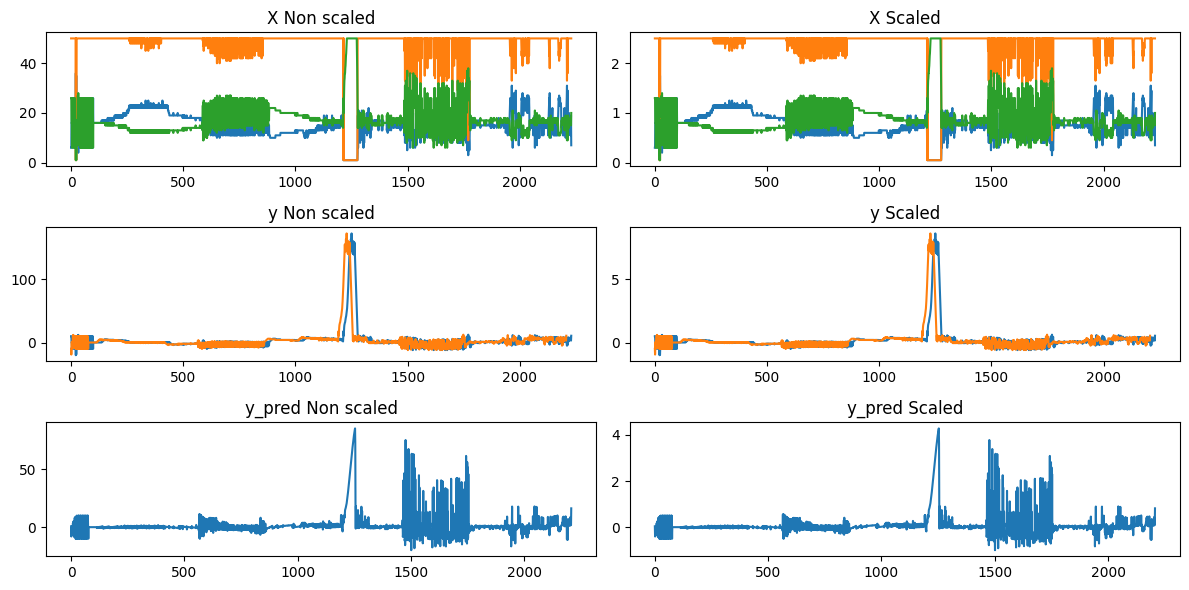

In [8507]:
# Ez nagyon hasznos hogy mennyire sikerült jól beskálázni a tanításnál a ki és a bemeneti változókat


fig, ax = plt.subplots(3, 2, figsize=(12, 6))

X_proba = np.array([
    auto.sensor_left, auto.sensor_center, auto.sensor_right
]).T

X_proba_scaled = auto.x_minmaxscaler.transform(X_proba)

ax[0, 0].set_title('X Non scaled')
ax[0, 1].set_title('X Scaled')
ax[0, 0].plot(auto.sensor_left)
ax[0, 0].plot(auto.sensor_center)
ax[0, 0].plot(auto.sensor_right)
ax[0, 1].plot(X_proba_scaled)

# --

# mivel listák és mivel nincs meg skálázva ezért
y_dist_real        = np.array(auto.y_distance_real)
y_dist             = np.array(auto.y_distance)
y_dist_real_scaled = auto.y_minmaxscaler.transform(y_dist_real)
y_dist_scaled      = auto.y_minmaxscaler.transform(y_dist)


ax[1, 0].set_title('y Non scaled')
ax[1, 1].set_title('y Scaled')
ax[1, 0].plot(auto.y_distance, label='y_distance')
ax[1, 0].plot(auto.y_distance_real, label='y_distance_real')
ax[1, 1].plot(y_dist_scaled, label='y_distance_scaled')
ax[1, 1].plot(y_dist_real_scaled, label='y_distance_real_scaled')

# --

y_dist_pred = [x.item() for x in auto.y_distance_predicted]
y_dist_pred_inv = auto.y_distance_predicted_inv
ax[2, 0].set_title('y_pred Non scaled')
ax[2, 1].set_title('y_pred Scaled')
ax[2, 0].plot(y_dist_pred_inv, label='y_distance_real')
ax[2, 1].plot(y_dist_pred, label='y_distance_real')

plt.tight_layout()
plt.show()

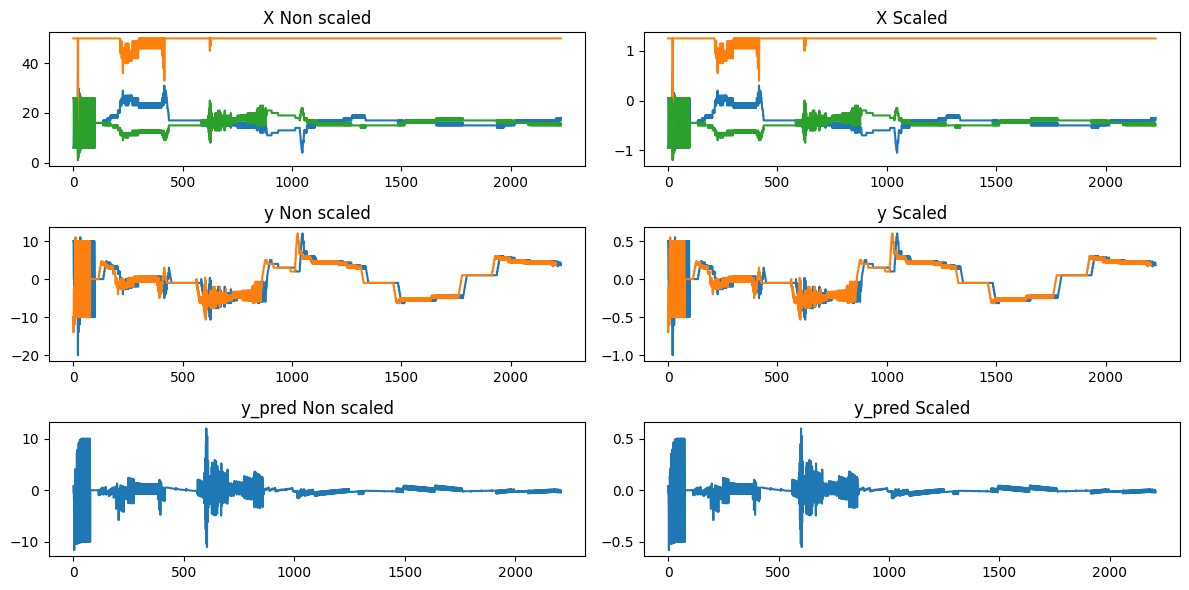

In [8495]:
# Ez nagyon hasznos hogy mennyire sikerült jól beskálázni a tanításnál a ki és a bemeneti változókat


fig, ax = plt.subplots(3, 2, figsize=(12, 6))

X_proba = np.array([
    auto.sensor_left, auto.sensor_center, auto.sensor_right
]).T

X_proba_scaled = auto.x_minmaxscaler.transform(X_proba)

ax[0, 0].set_title('X Non scaled')
ax[0, 1].set_title('X Scaled')
ax[0, 0].plot(auto.sensor_left)
ax[0, 0].plot(auto.sensor_center)
ax[0, 0].plot(auto.sensor_right)
ax[0, 1].plot(X_proba_scaled)

# --

# mivel listák és mivel nincs meg skálázva ezért
y_dist_real        = np.array(auto.y_distance_real)
y_dist             = np.array(auto.y_distance)
y_dist_real_scaled = auto.y_minmaxscaler.transform(y_dist_real)
y_dist_scaled      = auto.y_minmaxscaler.transform(y_dist)


ax[1, 0].set_title('y Non scaled')
ax[1, 1].set_title('y Scaled')
ax[1, 0].plot(auto.y_distance, label='y_distance')
ax[1, 0].plot(auto.y_distance_real, label='y_distance_real')
ax[1, 1].plot(y_dist_scaled, label='y_distance_scaled')
ax[1, 1].plot(y_dist_real_scaled, label='y_distance_real_scaled')

# --

y_dist_pred = [x.item() for x in auto.y_distance_predicted]
y_dist_pred_inv = auto.y_distance_predicted_inv
ax[2, 0].set_title('y_pred Non scaled')
ax[2, 1].set_title('y_pred Scaled')
ax[2, 0].plot(y_dist_pred_inv, label='y_distance_real')
ax[2, 1].plot(y_dist_pred, label='y_distance_real')

plt.tight_layout()
plt.show()

# --------------------- road Description ----------------------------
  		 road.length =  2750
  		 minimum slope (descending) =  -0.3333333333333428
  		 maximum slope (ascending)  =   0.33333333333337123
# -----------------------------------------------------------------
FixScalerCenteredMax self.offset 25.0


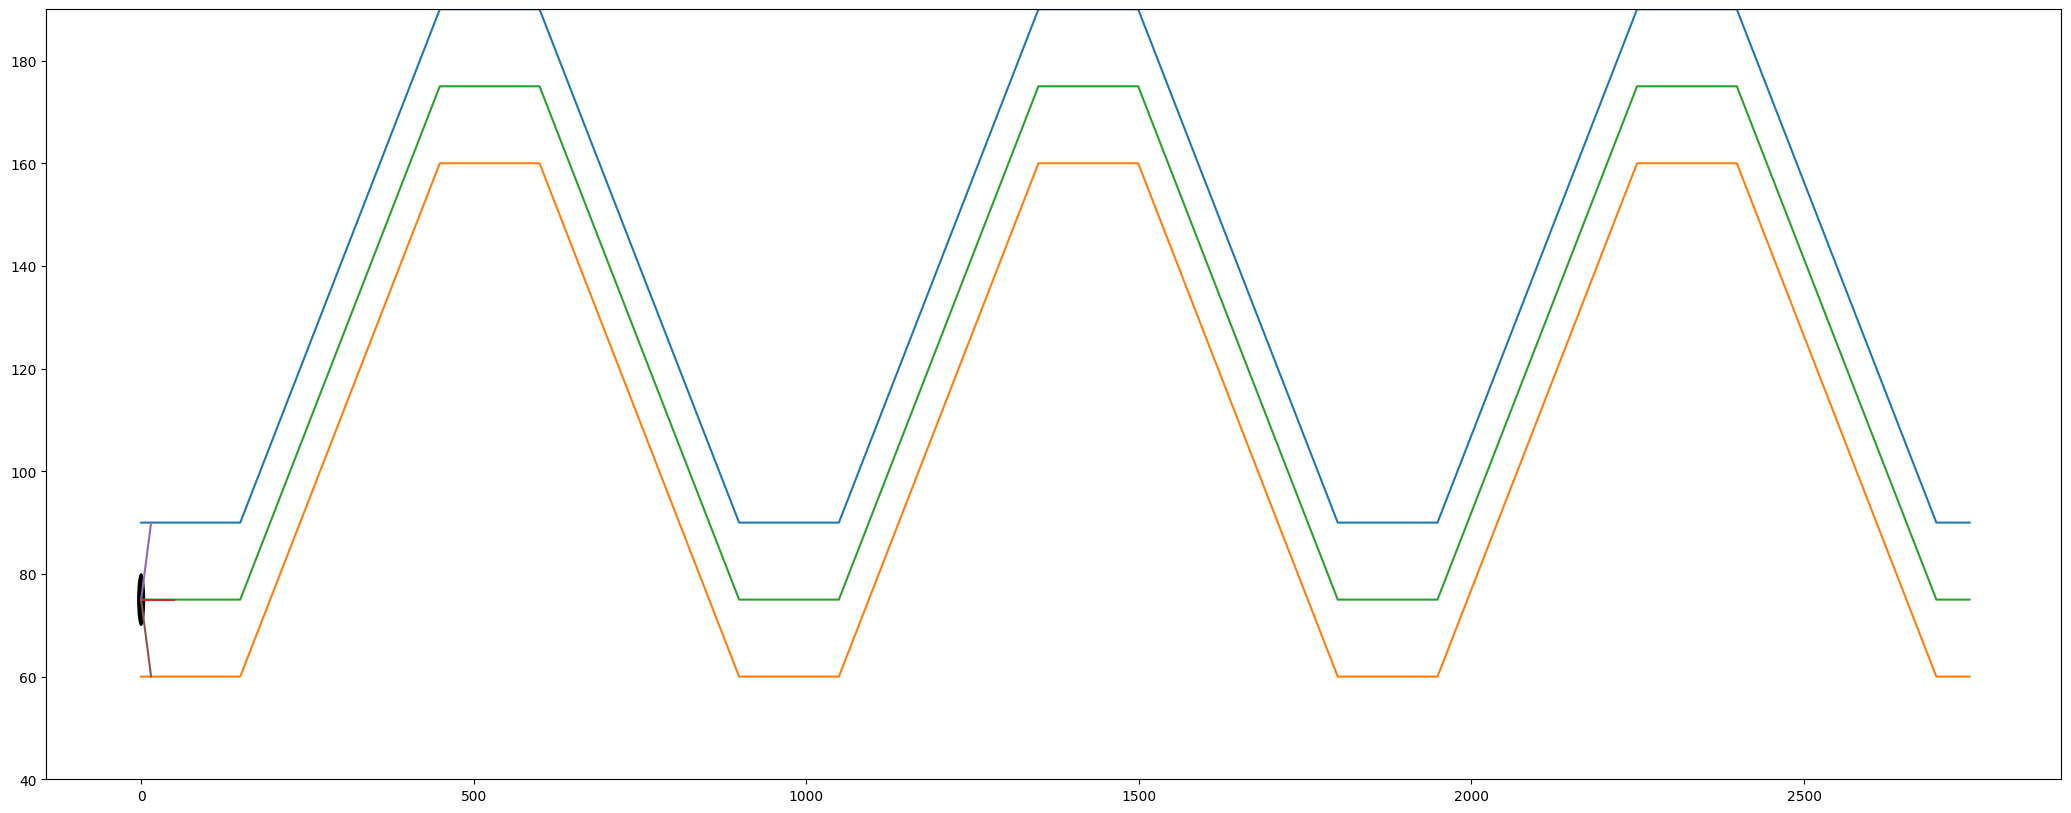

 --------------- plot --------------- 


In [8644]:
# road = Road(wide = 220, length = 3000, type = 1)

road = Road(wide = 30, length = 2750, type = 5,
            ramp_up_length    = 300,
            ramp_down_length  = 300,
            flat_top_length   = 150,
            flat_bottom_length= 150,
            trapezoid_height  = 100)

plotter = Plotter()
platter = Platter()
storage = Storage()

settings = {
    'hidden_layer_sizes': (5, 3),     # (5, 3)
    'learning_rate_init': 0.01,       # 0.01, 0.0001
    'solver': 'adam',                 # sgd, adam
    'activation': 'tanh',             # tanh, relu, logistic
    'nesterovs_momentum': False,
    'max_iter': 5,                    # 1
    'fit_intercept': False,           # Legyen-e intercept a LinearRegression
    'action_range': (10, 1),           # A lehtséges lépések sávja (-7, ..., +7) és a lépésköz
    'scaler_type': 'FixCenteredMax',             # None, MinMax, Standard, Fix, FixCenteredMax, Cut, Log, SignedLog, Reciprocal, Robust, Quantile
    'feature_range': (20, 20),        # Fix esetén az első az X, a második az y osztója (25, 75), !(25, 25), !(55, 55) (25, 10)
    'feature_range_centered_max_maximum': 50, # Fix CM esetén ez az érték a maximum ameddig a sensor lát
    'multi_sensor_regression': True,  # Ture
    'stop_external_move_at_i': 100,   # Ennyi lépés után már ne csináljon mesterséges mozgatást
    'external_move_value': 1,         # Ekkora legyen az elején a mesterséges lépés nagysága
    'dynamic_external_step': False,
    'random_state': 1,
#    'plot_y_min': 0,
#    'plot_y_max': 1200,
}

auto = Car(road, plotter, platter, storage, settings)

auto.sight = 50
auto.sight_center = 50 # 350

auto.calculate_distances()
auto.platter.plot_history(auto, 1)

In [8645]:
auto.calculate_distances()

<a name="run"></a> [log](#log) [plt](#plt) [str](#str) [road](#road) [car](#car) run [dev](#dev) [zip](#zip) [tst](#tst)

# RUN

In [8646]:
auto.mlp.verbose = False

auto.plot_state_space_discover_flag = 0        # 0 - disable, 1 - plot, 2 - save, 3 - both       0
auto.plotter_flag                   = 1        # 0 - disable, 1 - plot, 2 - save, 3 - both       1
auto.plot_history_flag              = 0        # 0 - disable, 1 - plot, 2 - save, 3 - both       0
auto.plot_trace_flag                = 1
auto.plot_investigation_flag        = 0
auto.plot_investigation_sensor_flag = 0
auto.plot_before_after_sensor_estimation_flag = 1
auto.plot_before_after_sensor_values_flag     = 1

auto.plot_frequency = 500
auto.print_rate = 2000

auto.investigation_figsize = (4, 4)                # (4, 4)
auto.investigation_in_one_figsize   = (12, 3)      # (18, 4.8)
auto.investigation_in_one_figsize_7 = (12, 4)      # (18, 7.5)
auto.test_plot_figsize = (15, 3)


# i =  0


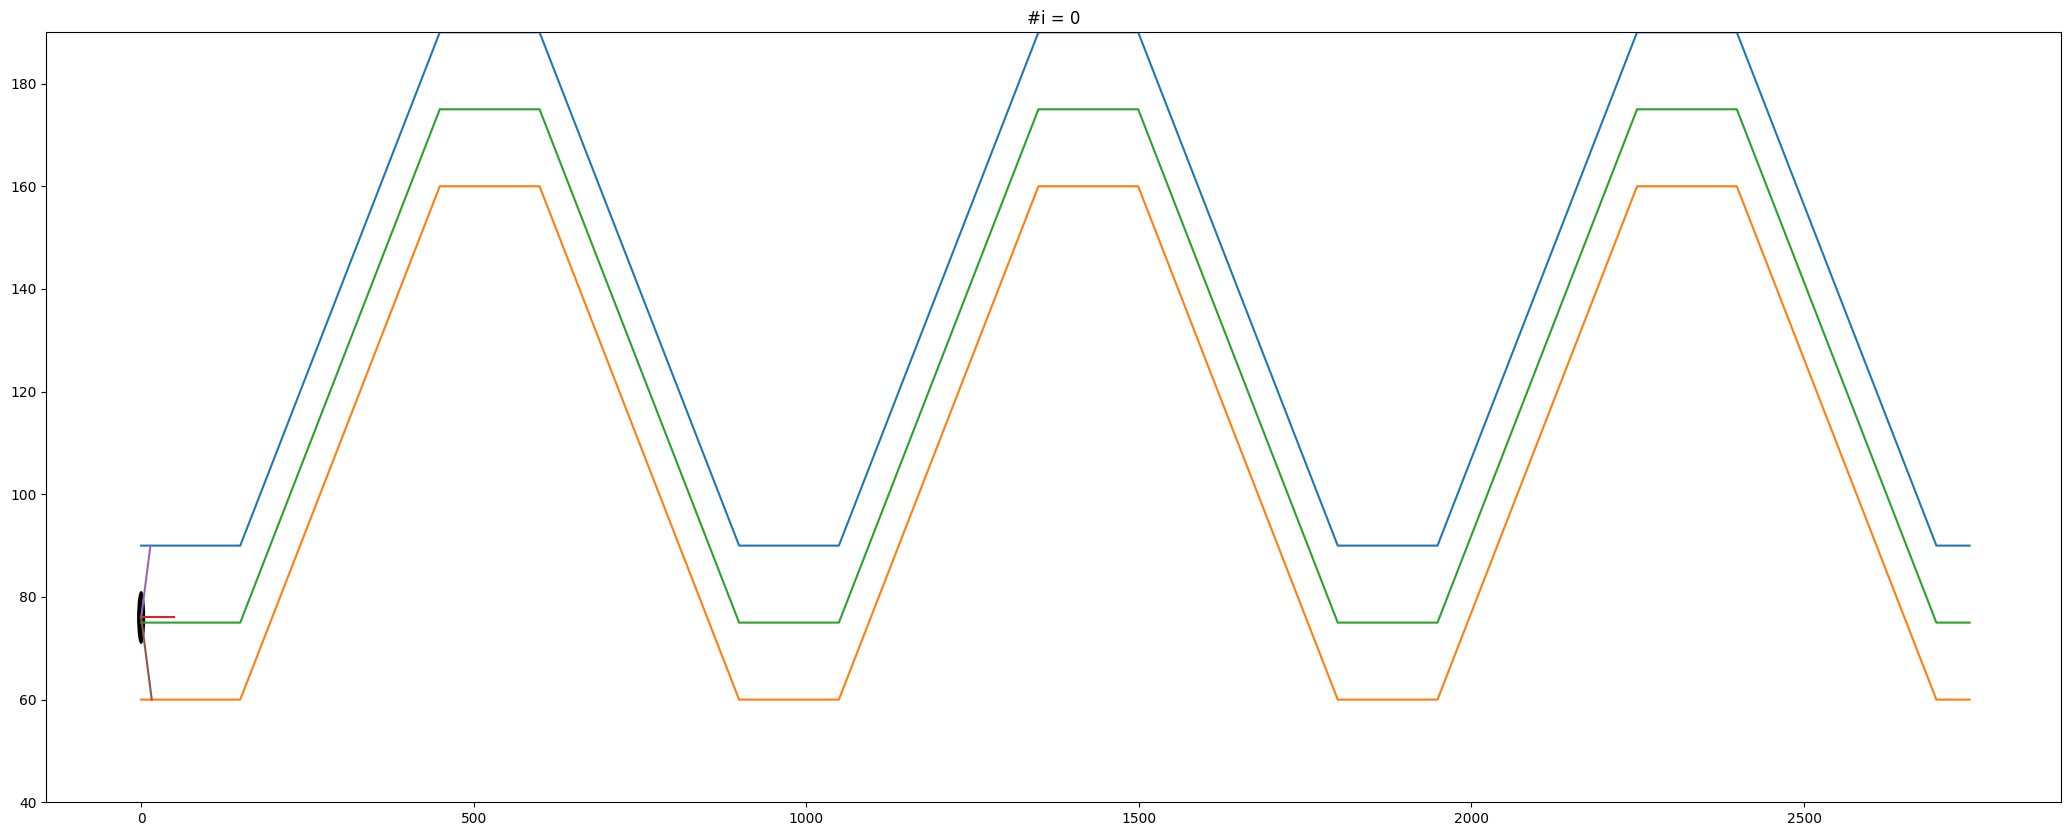

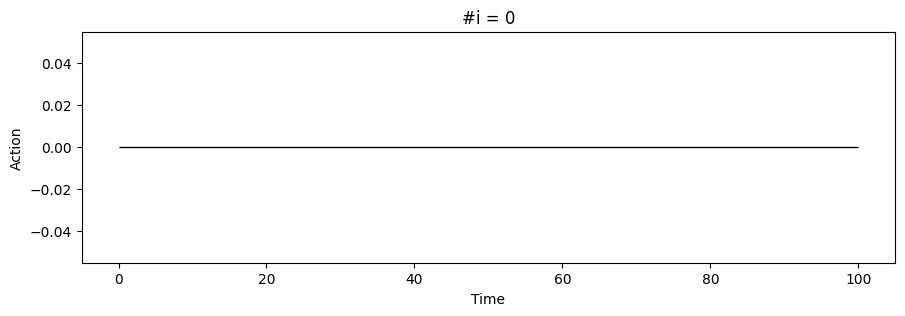

--- Lépés: 0 --- 
Y pozíció: 76.0 
# i =  100
# i =  200
# i =  300
# i =  400
# i =  500


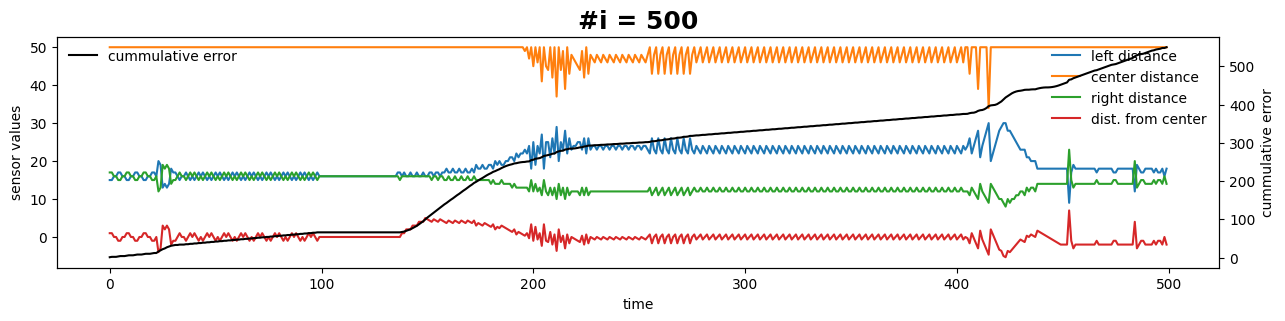

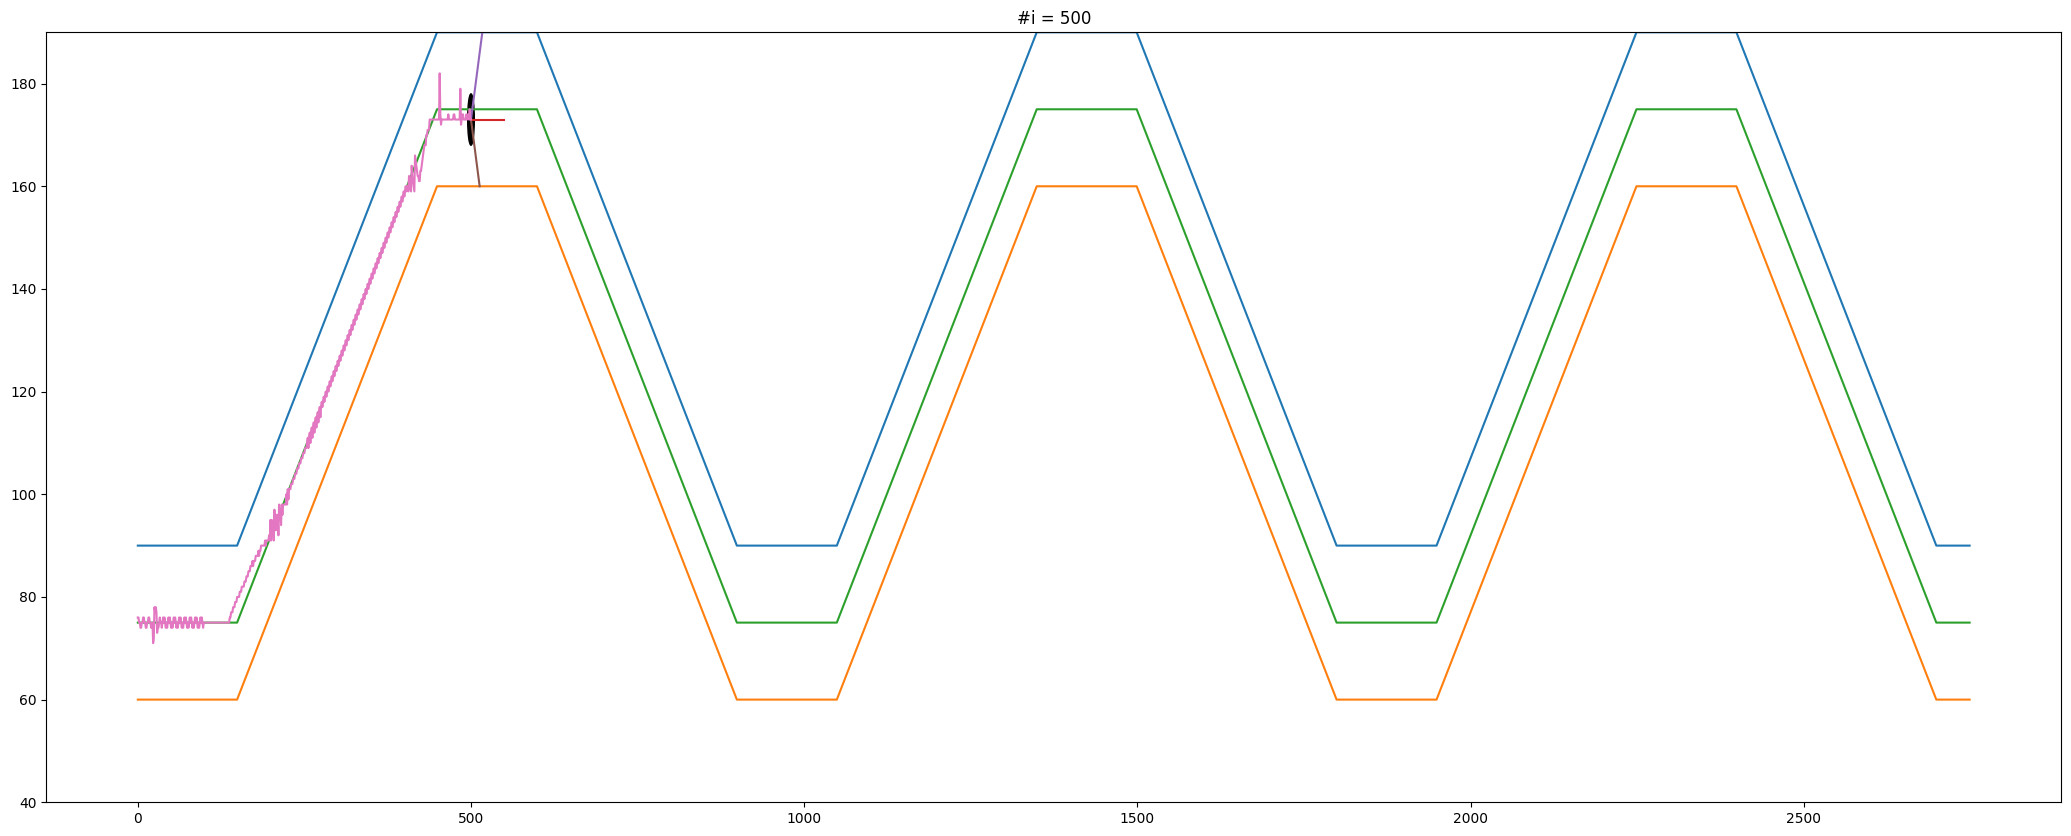

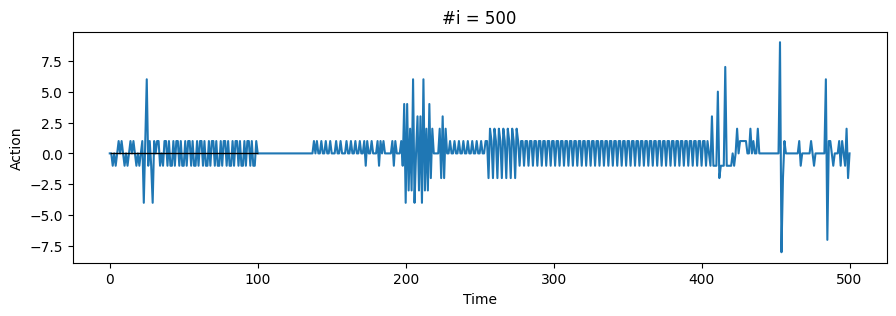

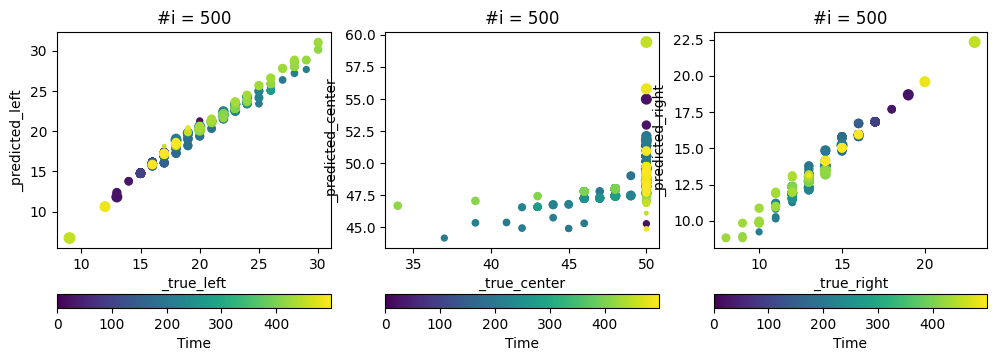

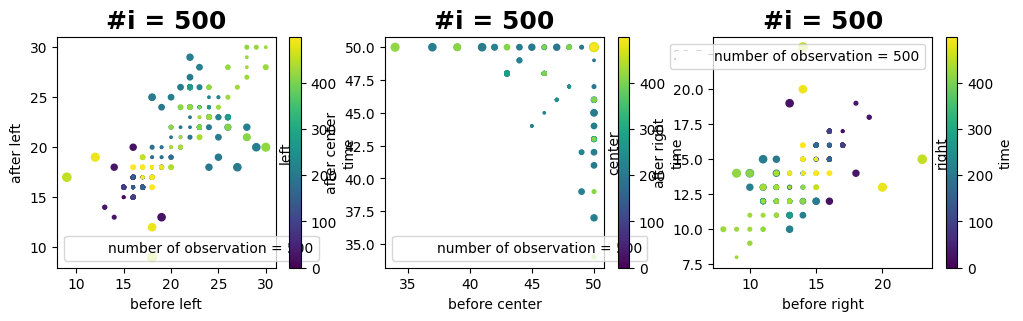

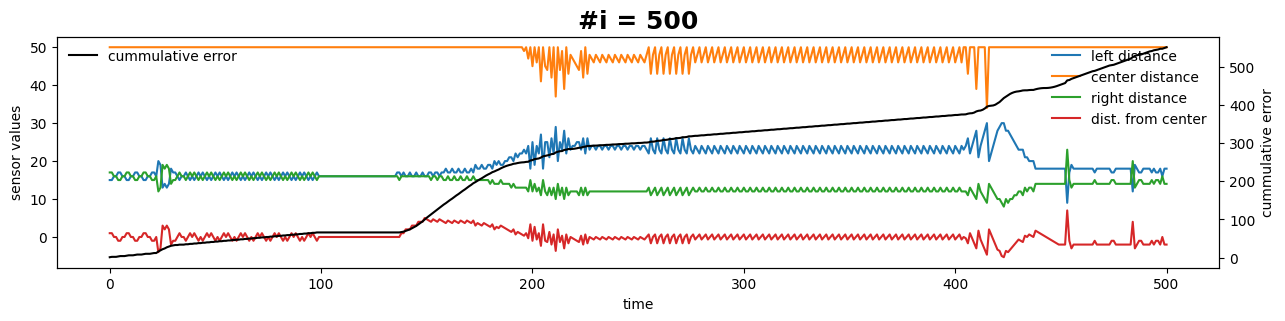

# i =  600
# i =  700
# i =  800
# i =  900
# i =  1000


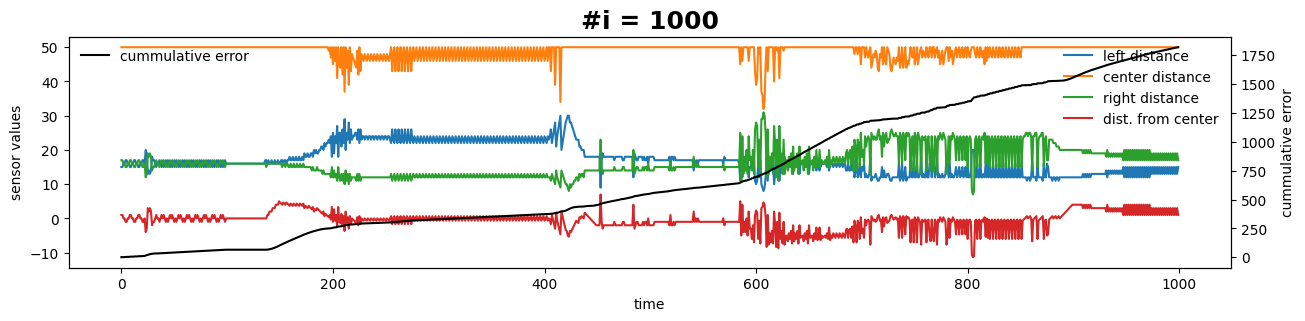

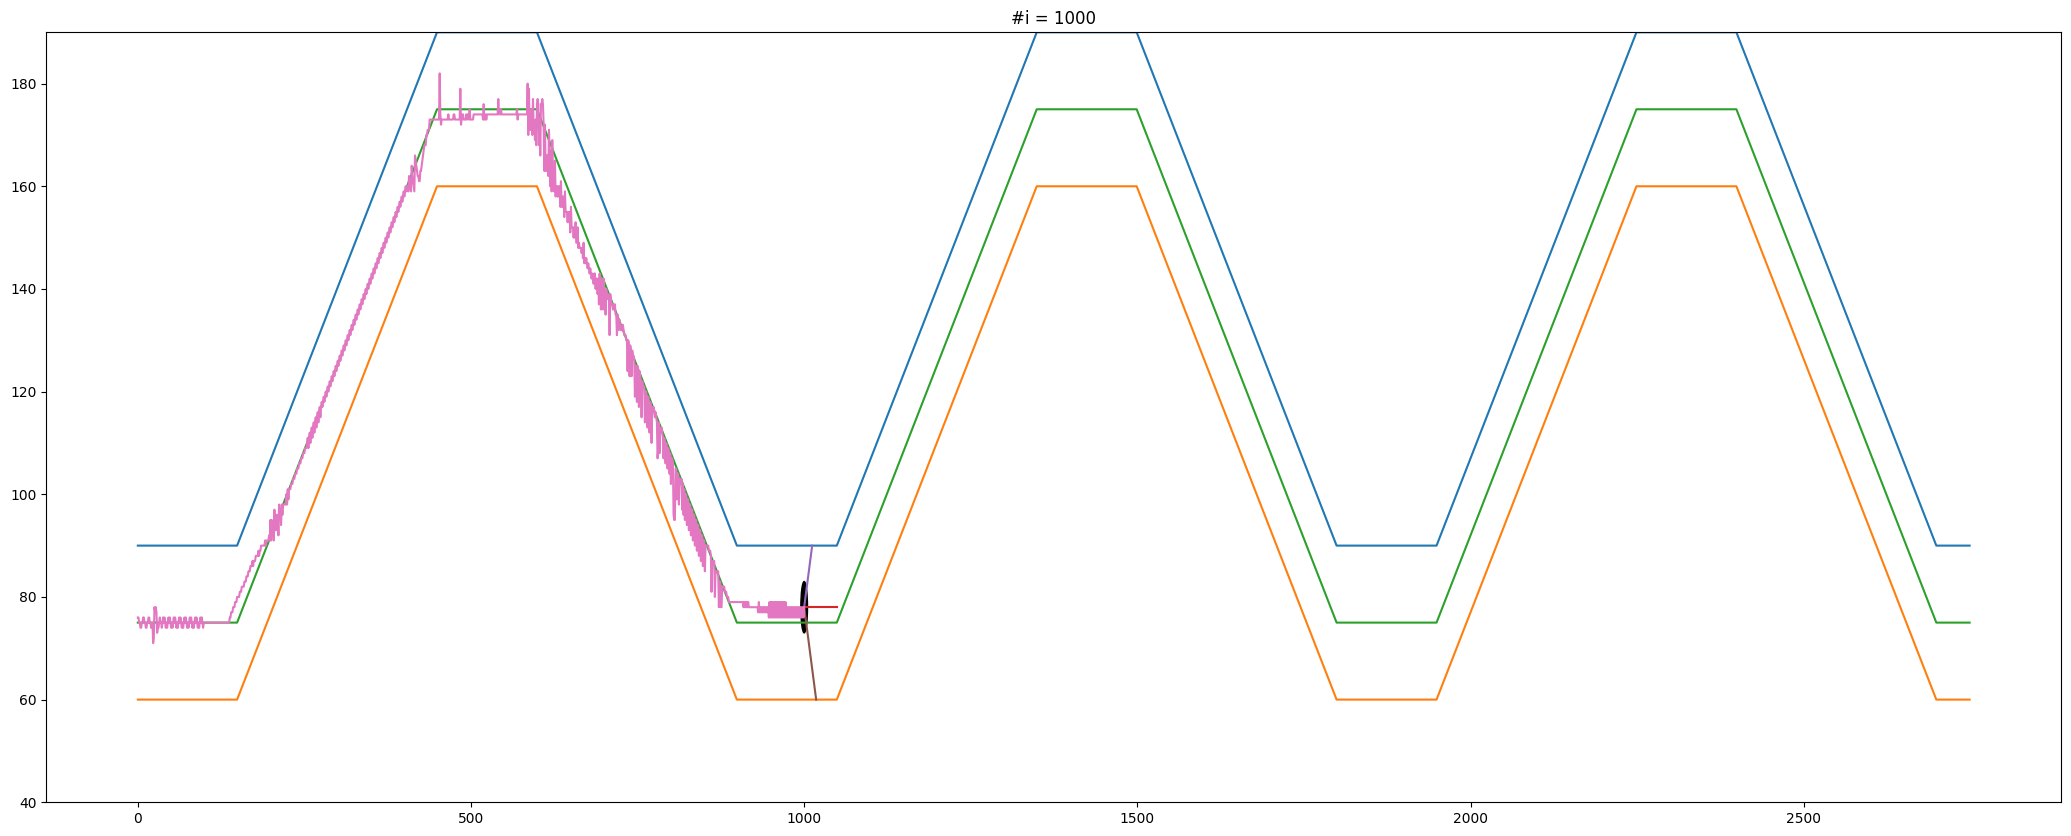

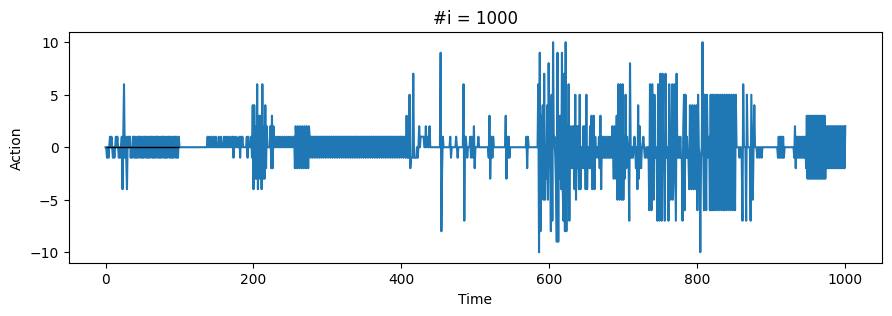

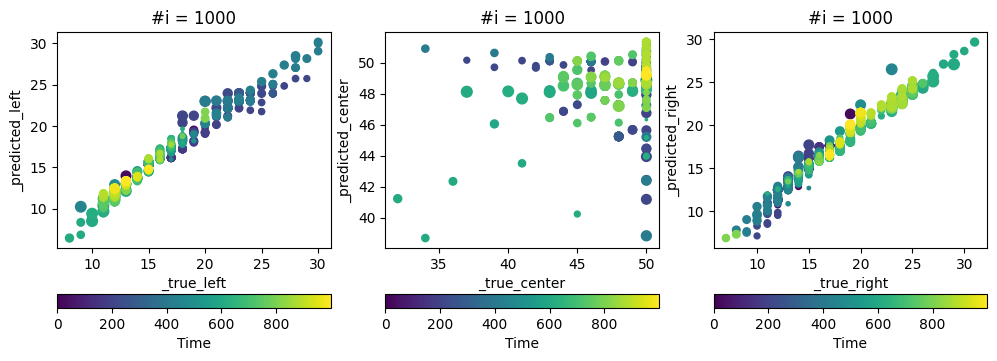

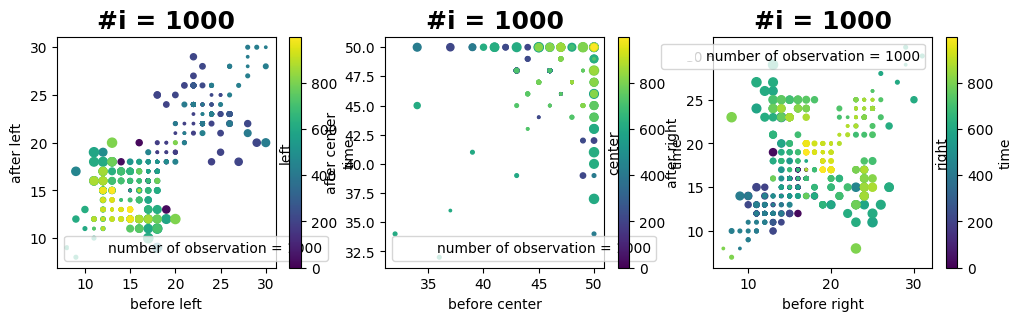

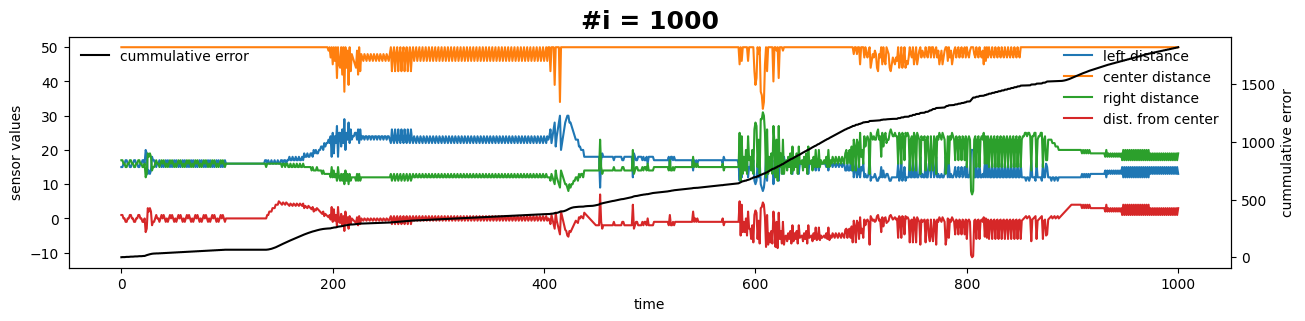

# i =  1100
# i =  1200
# i =  1300
# i =  1400
# i =  1500


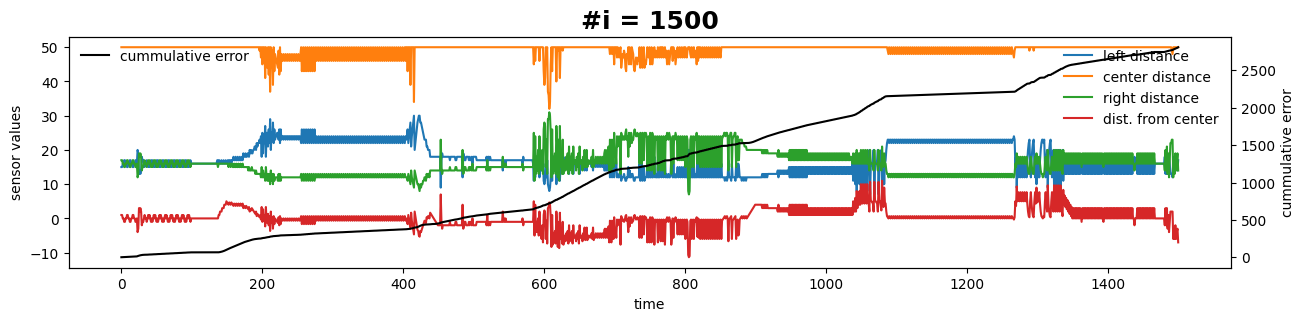

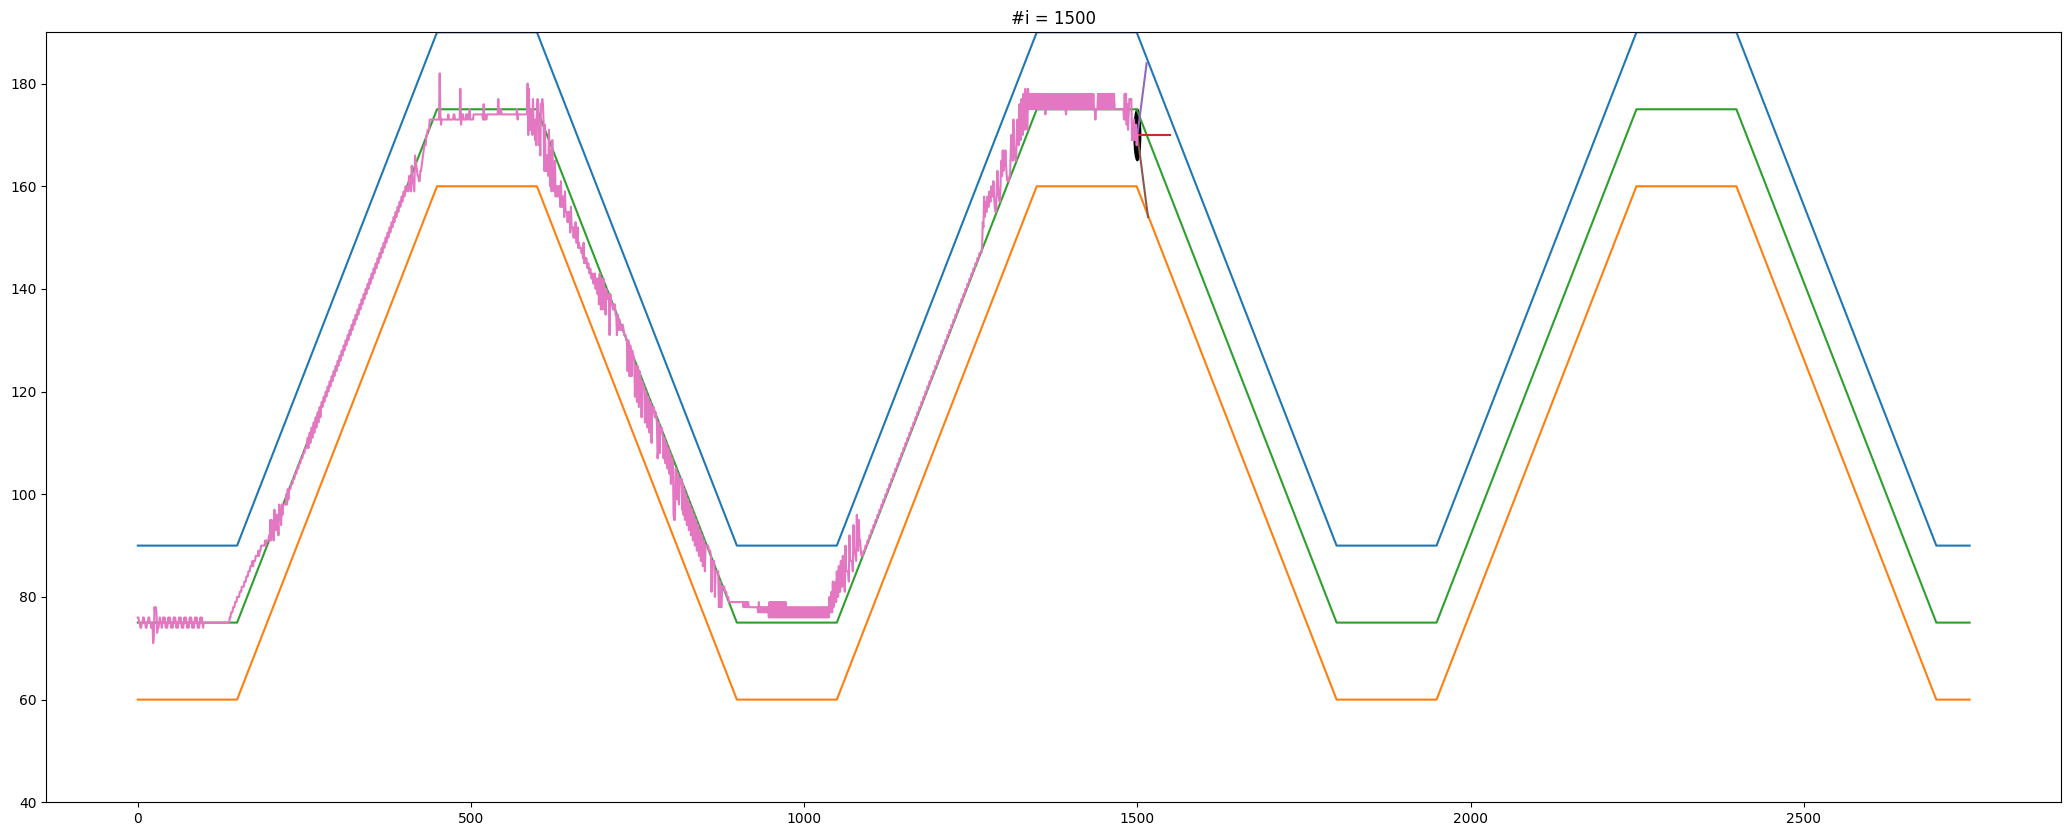

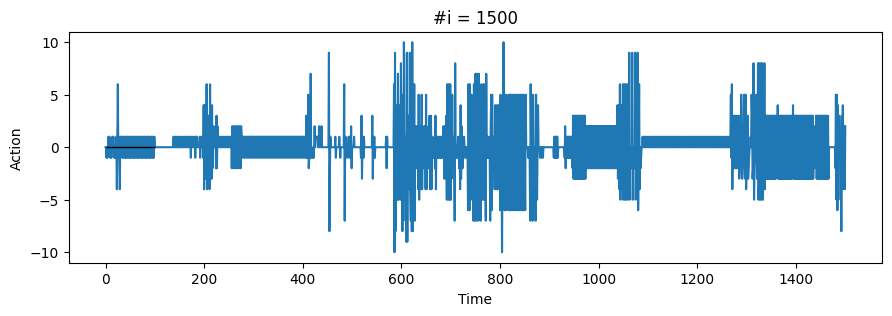

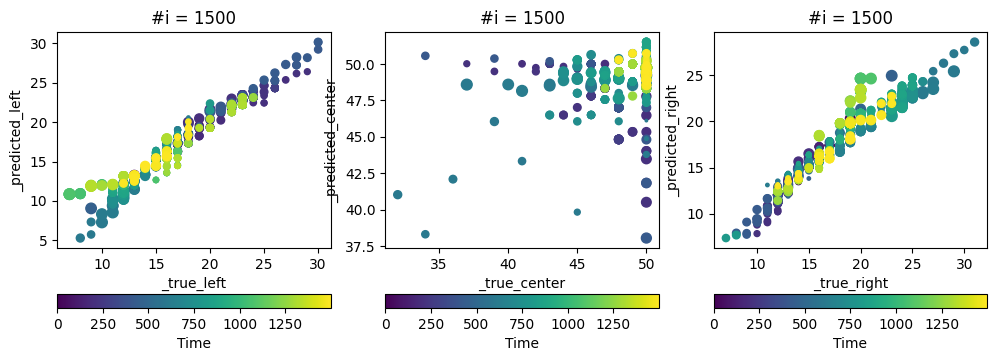

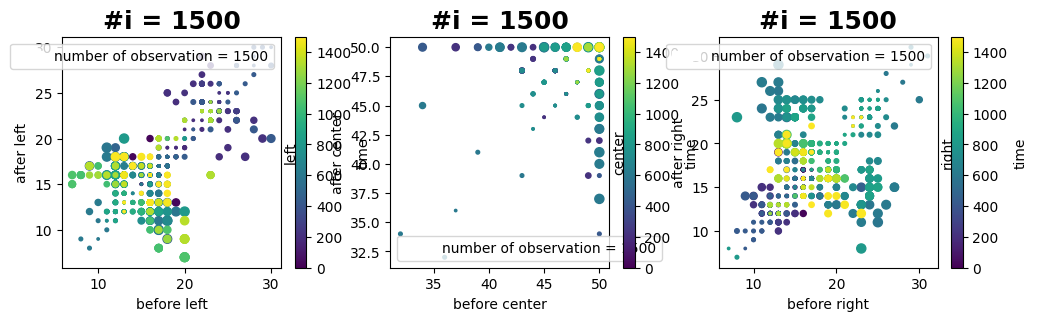

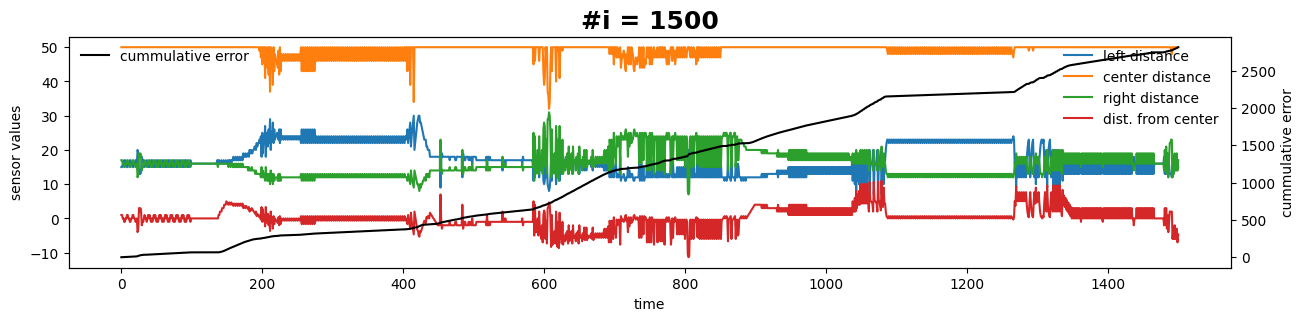

# i =  1600
# i =  1700
# i =  1800
# i =  1900
# i =  2000


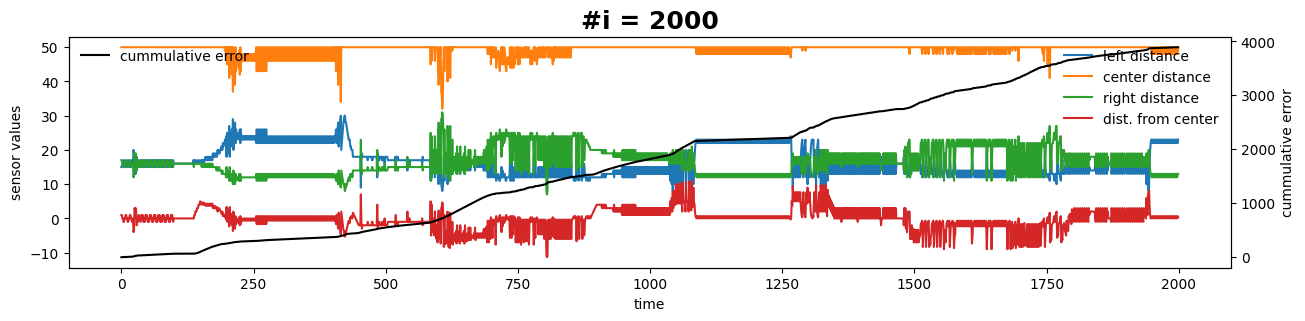

-------- ennyivel módosítom self.y értékét --------
self.y régi értéke = 92.00000
self.y új értéke   = 92.0
self.y új értéke   = 92.00000
self.y új értéke   = 92.00000
action             = 0
----------------- módosítás vége -----------------


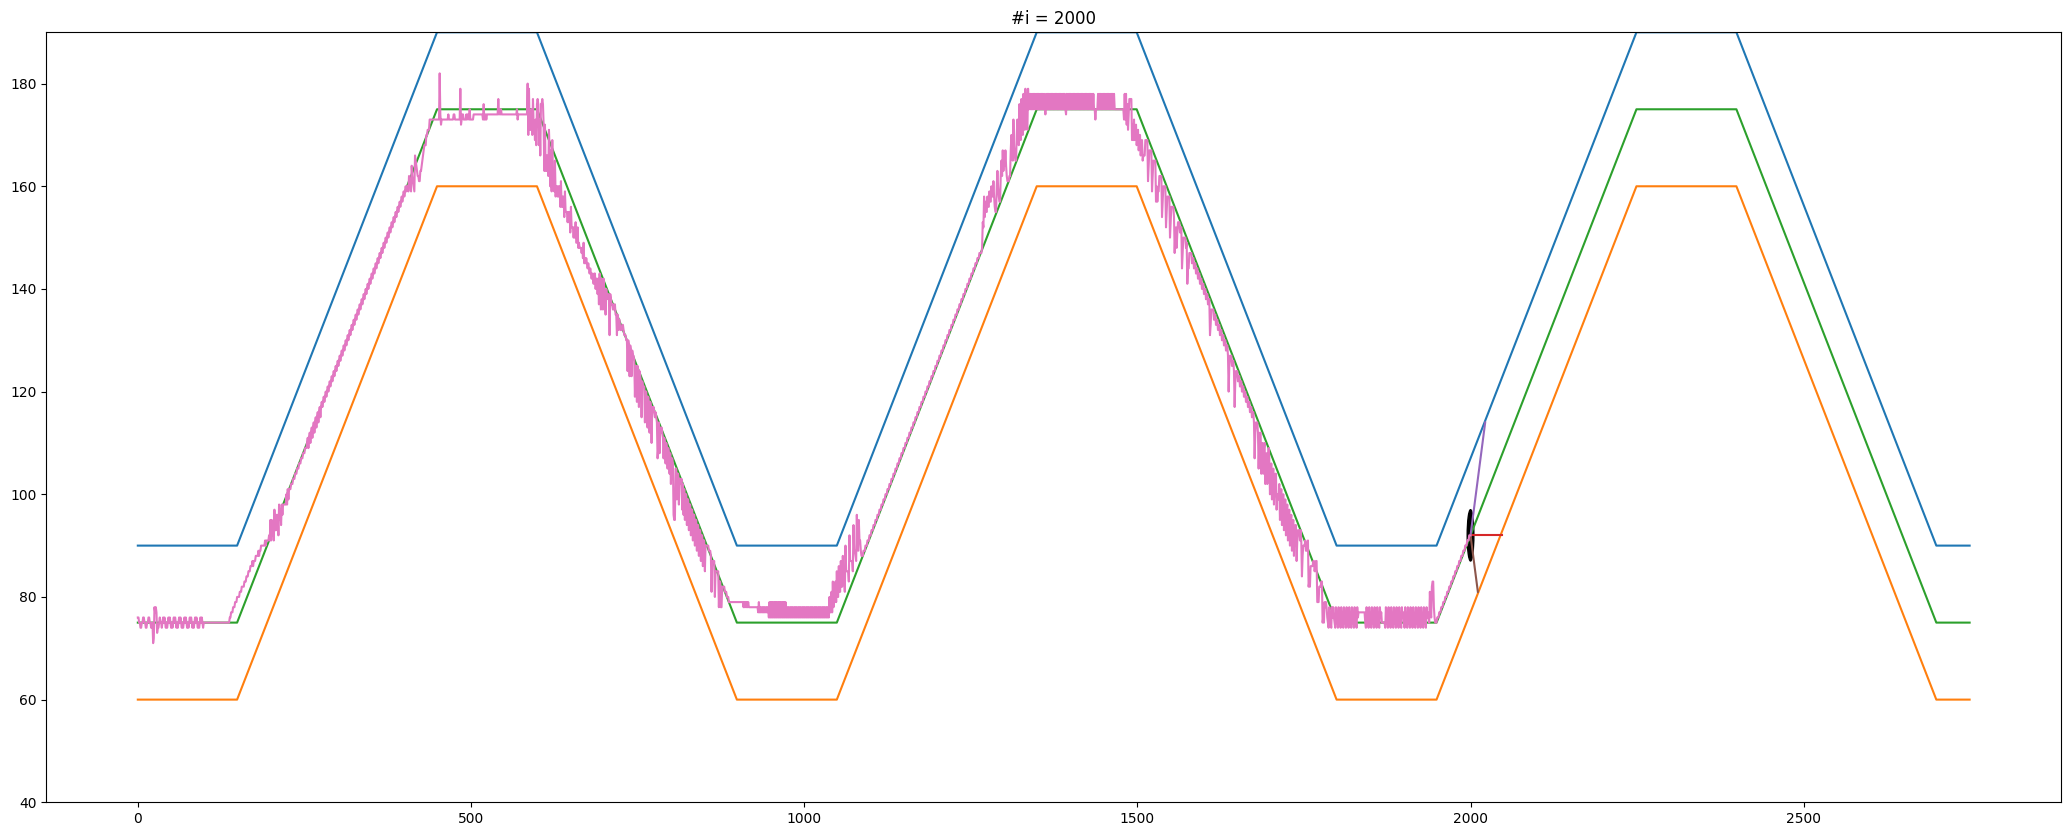

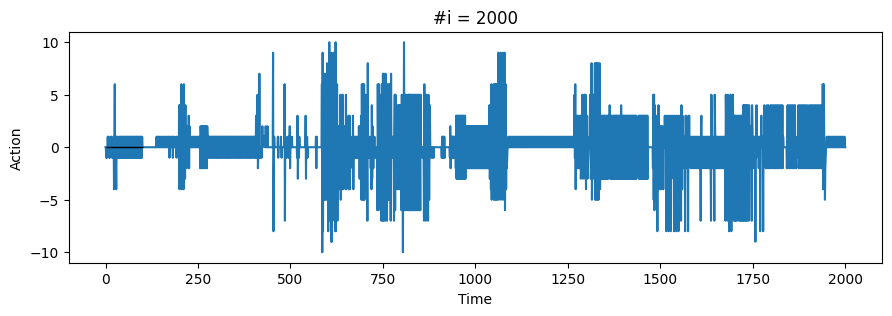

--- Lépés: 2000 --- 
Y pozíció: 92.0 


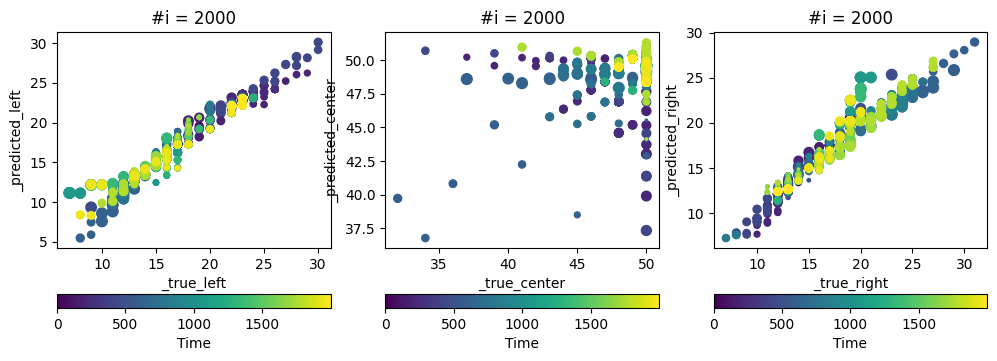

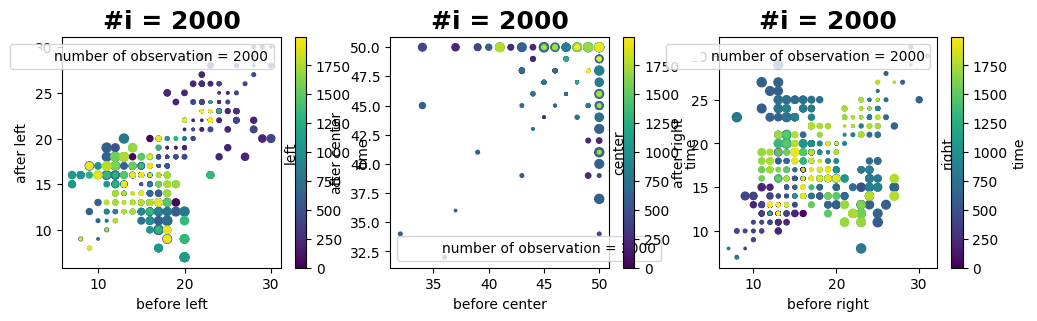

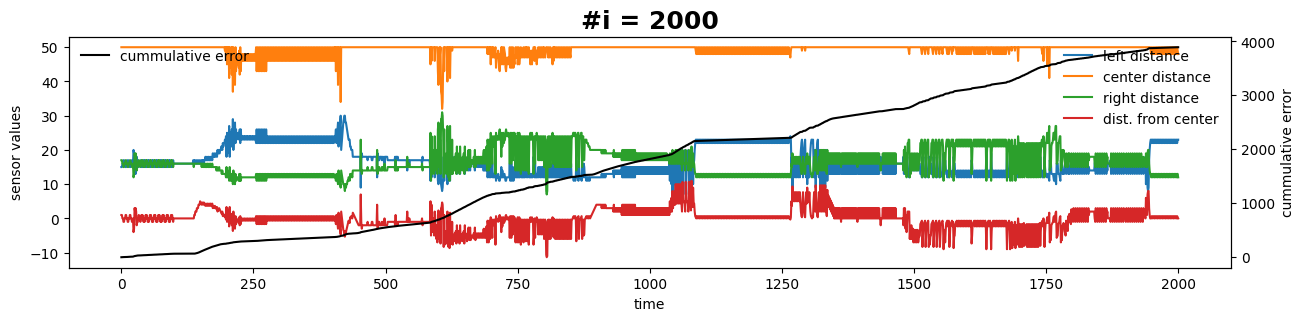

# i =  2100


KeyboardInterrupt: 

In [8647]:
%%time

auto.artificial_jump_frequency = 110 # 100
auto.artificial_jump_value     = 5  # 10

auto.run(2230, artificial_jump=False) # 2230

In [8640]:
# Ha ez nem megy akkor kiszámolom úgy is ahogy a plot_trace metodusban van
# ami a tényleges y értékből számolja ki a diff-ek alapján hogy mi volt a lépés

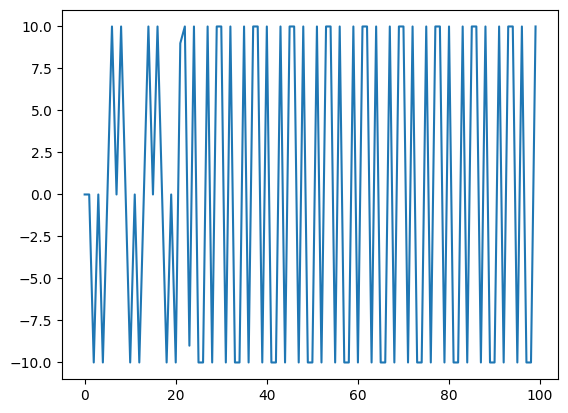

In [8643]:
__y_move = np.diff(np.array(auto.y_history), 1, -1, prepend=0)
__y_move[0] = 0

__FROM = 0
__TO = 100
plt.plot(__y_move[__FROM:__TO])
plt.show()

<class 'list'>
[array([75., 16., 50., 16.]), array([85.,  6., 50., 26.]), array([85.,  6., 50., 26.]), array([75., 16., 50., 16.]), array([75., 16., 50., 16.]), array([65., 26., 50.,  6.]), array([65., 26., 50.,  6.]), array([75., 16., 50., 16.]), array([75., 16., 50., 16.]), array([85.,  6., 50., 26.])]


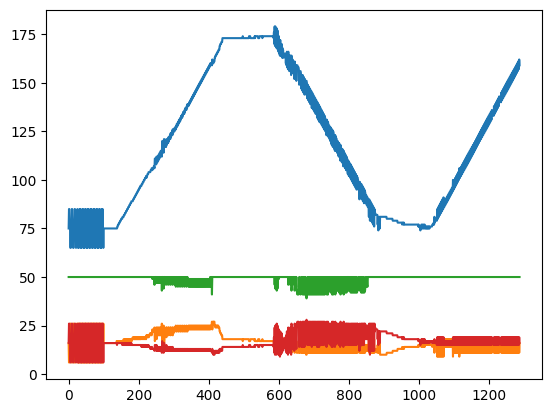

In [8642]:
auto.before # [y, l, c, r]
plt.plot(auto.before)
print(type(auto.before))
print(auto.before[:10])

In [8628]:
auto.jump_flags

[]

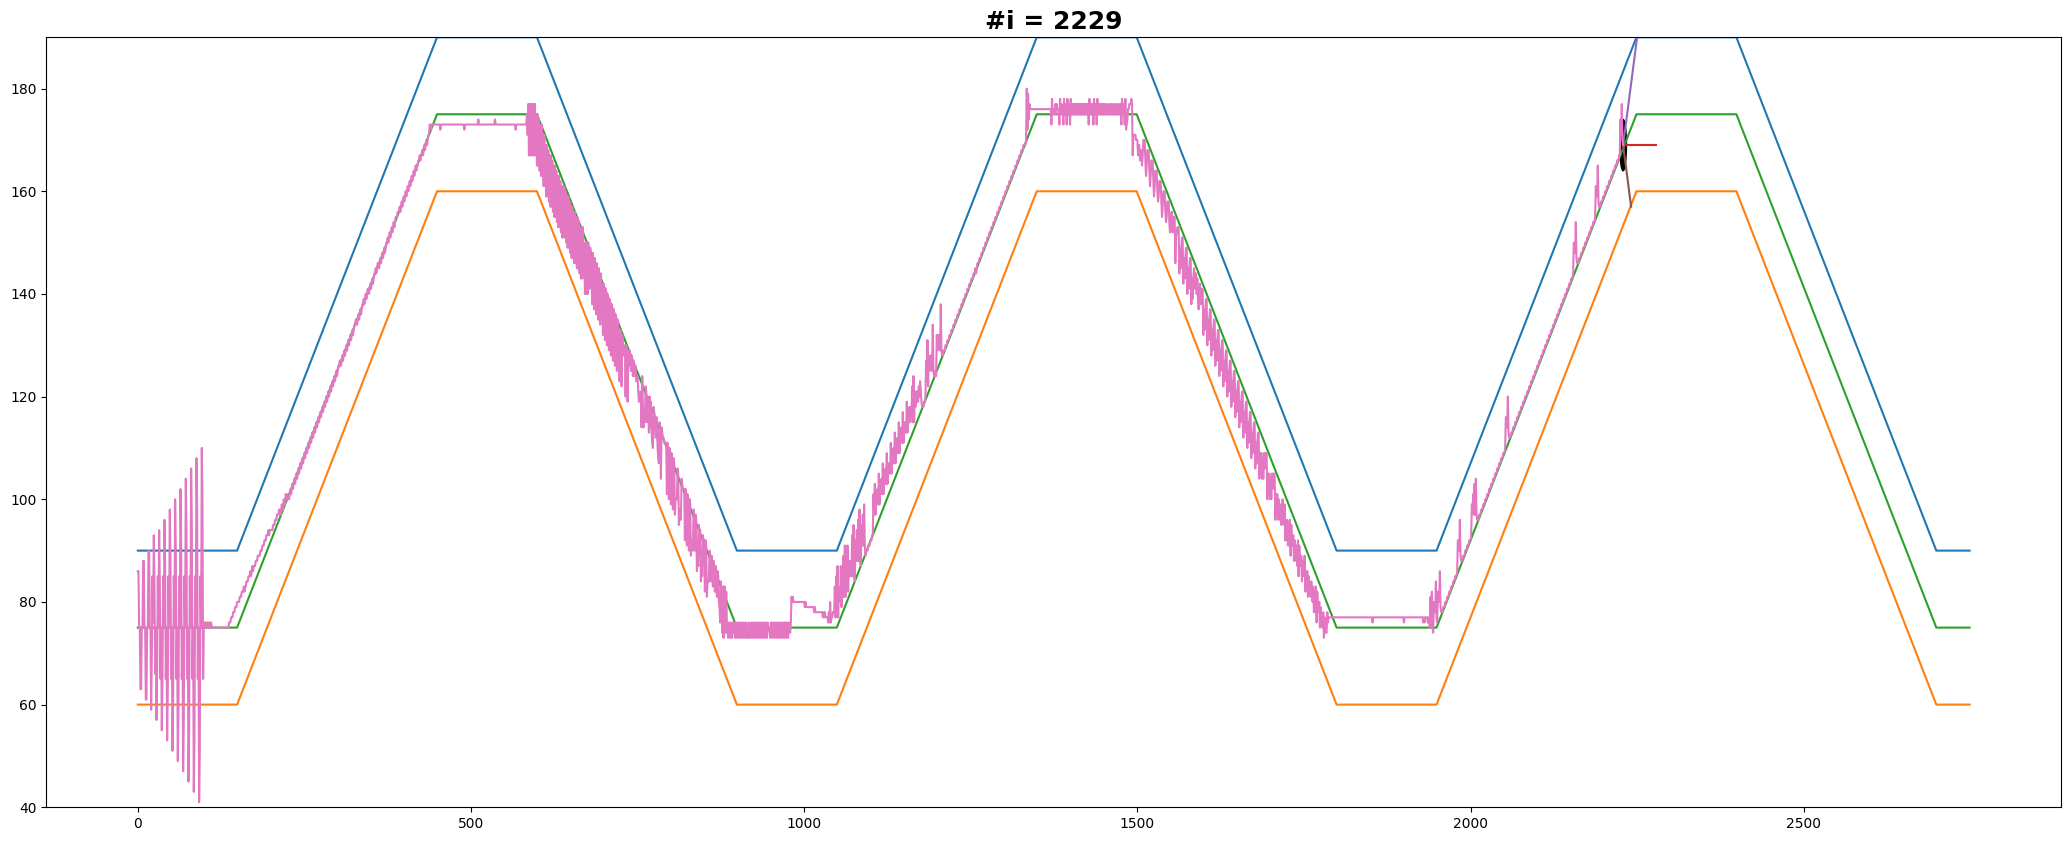

 --------------- plot --------------- 


In [8629]:
auto.platter.plot_history(auto, 1)

[Setup](#setup_current_train)

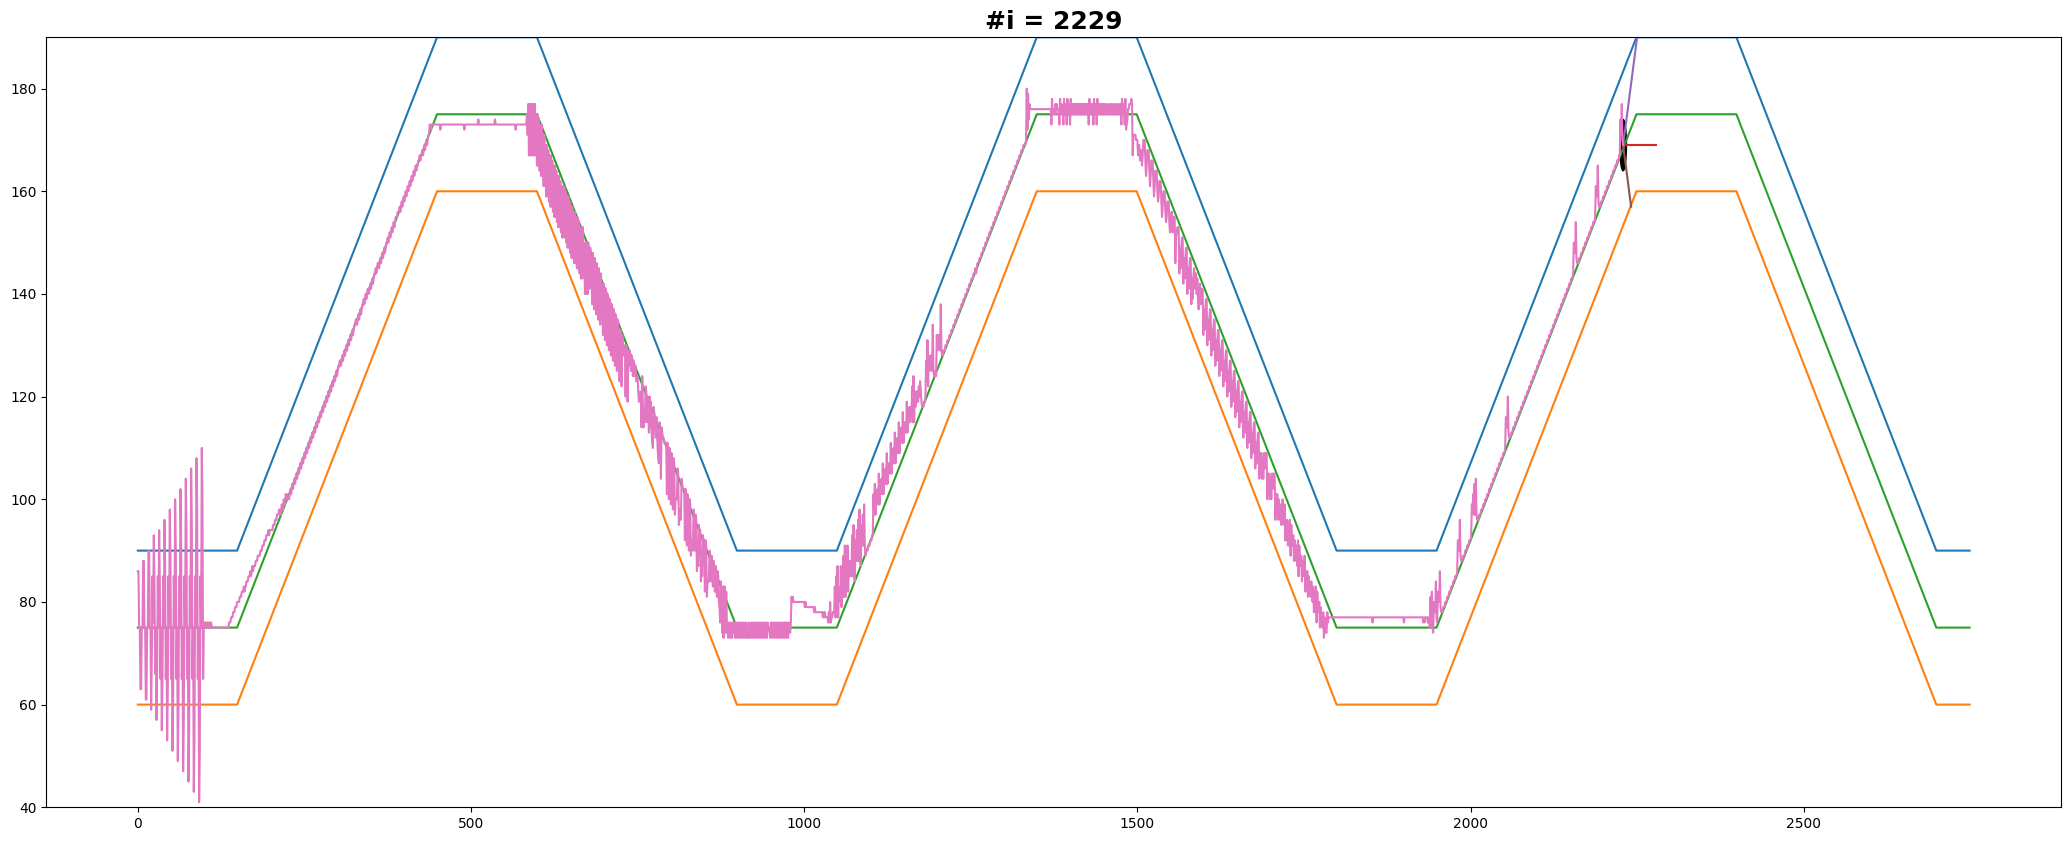

 --------------- plot --------------- 


In [8630]:
auto.platter.plot_history(auto, 1)

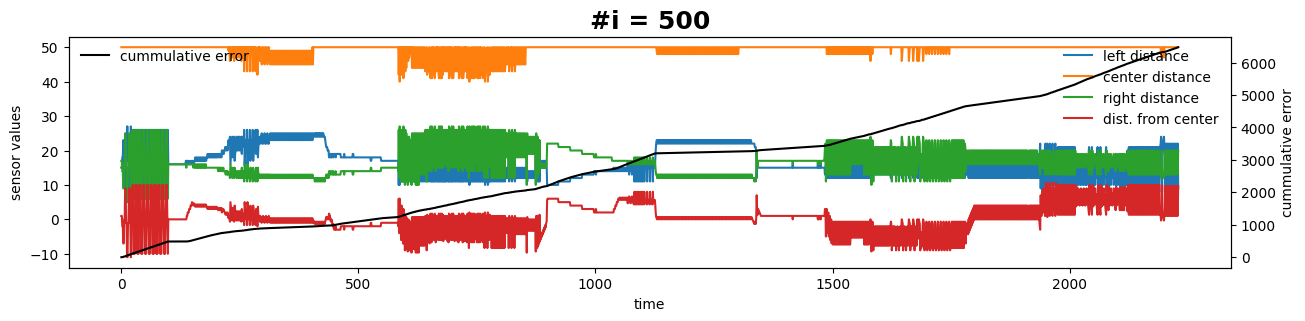

In [8543]:
auto.plotter.test_plot2(auto, auto.plot_frequency, flag=1, lists=[6], force=True)
# Régi
# auto.plotter.test_plot2(auto.sensor_left, auto.sensor_right, auto.y_distance, auto.x, flag=1, lists=[6])

In [ ]:
auto.platter.plot_history(auto, 1)

In [ ]:
auto.platter.plot_history(auto, 1, show_y_distance=True)

In [ ]:
auto.platter.plot_history(auto, 1, show_y_distance=True, grid=True)

In [ ]:
postPlotter = PostPlotter(auto)

postPlotter.plot_y_distance_distibution()

<a name="dev"></a> [log](#log) [plt](#plt) [str](#str) [car](#car) [run](#run) dev [zip](#zip) [tst](#tst)

# Dev

In [ ]:
print('len = ', auto.regression_left.coef_)
print('len = ', auto.regression_left.intercept_)

In [ ]:
print('len = ', auto.regression_left.coef_)
print('len = ', auto.regression_left.intercept_)

In [ ]:
print('len = ', len(auto.mlp.coefs_))

print('type(auto.mlp.coef_[0]) = ', type(auto.mlp.coefs_[0]))
print('type(auto.mlp.coef_[1]) = ', type(auto.mlp.coefs_[1]))

print('auto.mlp.coef[].shape = ',auto.mlp.coefs_[0].shape)
print('auto.mlp.coef[].shape = ',auto.mlp.coefs_[1].shape)
print('auto.mlp.coef[].shape = ',auto.mlp.coefs_[2].shape)

In [ ]:

print(len(auto.regression_center_coef_history))
# print(auto.regression_center_coef_history[100][0])
# print(auto.regression_center_coef_history[100][0][0])
# print(auto.regression_center_coef_history[100][0][1])
# print(auto.regression_left.coef_)

# plotter plot_lr_weight

def plot_lr_weight(car, sensors = ['left'], coefs = ['sensor', 'action'], x = 1, flag = 1):

  if( flag != 0 ):

        # _X_left   =  [[51 -3]]
        # _X_center =  [[110  -3]]
        # _X_right  =  [[51 -3]]

        # Emlékeztetőül,
        # A regressziók ilyen bemeneteket várnak, tehát az első coefficiens azt mondja meg,
        # hogy adott szezor értéket ekkora súllyal kell figyelmbe venni
        # a második coefficiens pedig azt modja meg, hogy a változtatás irányát ekkora
        # sullyal kell figelembe venni -> ha azt akarjuk meghatározni, hogy adott szezorértékből
        # mi lesz, ha valamennyivel elmozdítjuk az autót.
        # A szezor értéke és ez elmozdítás mértéke változók (paraméterek) az egyenletben
        # a szorzótényezők (az egyenlet coefficiensei pedig állandók)
        # Ez a plott a coefficienseket jelenítit meg, illetve azt, hogy ezek hogyan változtak
        # a futás során.

    # sajnos át kell alakítanom másképpen nem megy

    array_regression_left_coef_history = np.array(auto.regression_left_coef_history)
    array_regression_left_coef_history = array_regression_left_coef_history[:,[0][0]]

    array_regression_center_coef_history = np.array(auto.regression_center_coef_history)
    array_regression_center_coef_history = array_regression_center_coef_history[:,[0][0]]

    array_regression_right_coef_history = np.array(auto.regression_right_coef_history)
    array_regression_right_coef_history = array_regression_right_coef_history[:,[0][0]]

    a = True if 'action' in coefs else False
    s = True if 'sensor' in coefs else False

    fig = plt.figure(figsize=(8, 3.8))
    ax = fig.add_subplot()

    if ( 'left' in sensors ):
      if a : ax.plot(array_regression_left_coef_history[:,0], c = '#5195c4', linestyle='dashed', label = 'left sensor coef')
      if s : ax.plot(array_regression_left_coef_history[:,1], c = '#5195c4', label = 'left action coef')

    if ( 'center' in sensors ):
      if a : ax.plot(array_regression_center_coef_history[:,0], c = '#000000', linestyle='dashed', label = 'center sensor coef')
      if s : ax.plot(array_regression_center_coef_history[:,1], c = '#000000', label = 'center action coef')

    if ( 'right' in sensors ):
      if a : ax.plot(array_regression_right_coef_history[:,0], c = '#ff8821', linestyle='dashed', label = 'right sensor coef')
      if s : ax.plot(array_regression_right_coef_history[:,1], c = '#ff8821', label = 'right action coef')
    ax.legend(frameon=False)
    # fig.show()

    fileName = 'plot_lr_coefs'
    if( flag == 1 or flag == 3 ): plt.show(); # fig.show();
    if( flag == 2 or flag == 3 ): fig.savefig(fileName + '_{0:04}'.format(x)+'.png', bbox_inches='tight'); plt.close('all'); fig.clf(); ax.cla(); plt.close('all');

plot_lr_weight(car = auto, flag = 1)

plot_lr_weight(car = auto, sensors=['right'], flag = 1)

plot_lr_weight(car = auto, sensors=['left', 'center'], flag = 1)

plot_lr_weight(car = auto, sensors=['left', 'center', 'right'], flag = 1)

plot_lr_weight(car = auto, sensors=['left', 'center', 'right'], coefs=['sensor'], flag = 1)

plot_lr_weight(car = auto, sensors=['left', 'center', 'right'], coefs=['action'], flag = 1)



In [ ]:
# version 5 rotated animation

def Plot3DVersion5(elevation=20.,
                   azimuth=-35,
                   flag=1,
                   i=0,
                   auto_max=False,
                   colorbar=False,
                   connected=False,
                   output_dir='temp',
                   dpi=80):

    if (flag != 0):
        szin = np.arange(len(auto.sensor_right))
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(projection='3d')
        sc = ax.scatter(auto.sensor_left,
                        auto.sensor_right,
                        auto.y_distance,
                        c=szin)
        ax.set_xlabel('sensor left')
        ax.set_ylabel('sensor right')
        ax.set_zlabel('y_distance')
        
        # Vonal az adatok sorrendjében (a pontokat összekötve)
        if connected == True:
            ax.plot(auto.sensor_left,
                    auto.sensor_right,
                    auto.y_distance,
                    color='black', linewidth=1, alpha=0.6)

        # ax.invert_xaxis()

        __x_min = 0
        __x_max = 200
        __y_min = 0
        __y_max = 200
        __z_min = -50
        __z_max = 50
        
        if auto_max == True:
            __x_max = int(np.array(auto.sensor_left).max())
            __y_max = int(np.array(auto.sensor_right).max())
            __z_max = int(np.array(auto.y_distance).max())

            # __x_min = int(np.array(auto.sensor_left).min())
            # __y_min = int(np.array(auto.sensor_right).min())
            # __z_min = int(np.array(auto.y_distance).min())

        ax.set_xlim(__x_min, __x_max)
        ax.set_ylim(__y_min, __y_max)
        ax.set_zlim(__z_min, __z_max)

        __x = auto.sensor_left[-1]
        __y = auto.sensor_right[-1]
        __z = auto.y_distance[-1]

        xe = __x
        xv = __x
        ye = ax.get_ylim()[0]
        yv = ax.get_ylim()[1]
        ze = ax.get_zlim()[0]
        zv = ax.get_zlim()[0]

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

        xe = __x_min
        xv = __x_max
        ye = __y
        yv = __y
        ze = ax.get_zlim()[0]
        zv = ax.get_zlim()[0]

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

        xe = ax.get_xlim()[0]
        xv = ax.get_xlim()[0]
        ye = __y
        yv = __y
        ze = __z_min
        zv = __z_max

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

        xe = __x_min
        xv = __x_min
        ye = __y_min
        yv = __y_max
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

        xe = __x_min
        xv = __x_max
        ye = __y_max
        yv = __y_max
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

        xe = __x
        xv = __x
        ye = __y_max
        yv = __y_max
        ze = __z_min
        zv = __z_max

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

        # ---
        xe = __x
        xv = __x
        ye = ax.get_ylim()[0]
        yv = ax.get_ylim()[1]
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange',
                linestyle='dashed')  #dotted

        xe = __x_min
        xv = __x
        ye = __y
        yv = __y
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green',
                linestyle='dashed')  #dotted

        xe = __x
        xv = __x
        ye = __y
        yv = __y
        ze = __z_min
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue',
                linestyle='dashed')  #dotted

        ax.view_init(elev=elevation, azim=azimuth)
        
        if colorbar == True:
            cb = plt.colorbar(sc, shrink=0.45, pad=-0.05)
            cb.set_label('Time')

        if (flag == 1 or flag == 3): plt.show()
        if (flag == 2 or flag == 3):
            fig.savefig(os.path.join(output_dir, f"Plot3D_{i:04}.png"), dpi=dpi)
            plt.close('all')
            fig.clf()
            ax.cla()
            plt.close('all')

In [ ]:
# version 5 Right Left Center (senor) and Y_Distance (color) rotated animation

def Plot3DVersion5RCLY(auto,
                       elevation=20.,
                       azimuth=-35,
                       flag=1,
                       i=0,
                       auto_max=False,
                       color='y_distance',
                       colorbar=False,
                       connected=False,
                       output_dir='temp',
                       dpi=80):

    if (flag != 0):
        
        if color == 'time':
            # szin eddig az idő múlását jelképezte
            szin = np.arange(len(auto.sensor_right))
            cb_label = 'Time'

        if color == 'y_distance':
            # szin most viszont már az y_distance értékét jelképezi
            szin = auto.y_distance
            cb_label = 'Distance from Target'
        
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(projection='3d')
        sc = ax.scatter(auto.sensor_left,
                        auto.sensor_right,
                        auto.sensor_center,
                        # auto.y_distance,
                        c=szin)

        ax.set_xlabel('sensor left')
        ax.set_ylabel('sensor right')
        ax.set_zlabel('sensor center')
        # ax.set_zlabel('y_distance')
        
        # Vonal az adatok sorrendjében (a pontokat összekötve)
        if connected == True:
            ax.plot(auto.sensor_left,
                    auto.sensor_right,
                    auto.sensor_center,
                    color='black', linewidth=1, alpha=0.6)
        
        # ax.invert_xaxis()

        __x_min = 0
        __x_max = 400
        __y_min = 0
        __y_max = 200
        __z_min = 0
        __z_max = 400

        if auto_max == True:
            __x_max = int(np.array(auto.sensor_left).max())
            __y_max = int(np.array(auto.sensor_right).max())
            __z_max = int(np.array(auto.sensor_center).max())

            # __x_min = int(np.array(auto.sensor_left).min())
            # __y_min = int(np.array(auto.sensor_right).min())
            # __z_min = int(np.array(auto.sensor_center).min())

        ax.set_xlim(__x_min, __x_max)
        ax.set_ylim(__y_min, __y_max)
        ax.set_zlim(__z_min, __z_max)

        __x = auto.sensor_left[-1]
        __y = auto.sensor_right[-1]
        __z = auto.sensor_center[-1]
        # __z = auto.y_distance[-1]

        xe = __x
        xv = __x
        ye = ax.get_ylim()[0]
        yv = ax.get_ylim()[1]
        ze = ax.get_zlim()[0]
        zv = ax.get_zlim()[0]

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

        xe = __x_min
        xv = __x_max
        ye = __y
        yv = __y
        ze = ax.get_zlim()[0]
        zv = ax.get_zlim()[0]

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue')

        xe = ax.get_xlim()[0]
        xv = ax.get_xlim()[0]
        ye = __y
        yv = __y
        ze = __z_min
        zv = __z_max

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

        xe = __x_min
        xv = __x_min
        ye = __y_min
        yv = __y_max
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green')

        xe = __x_min
        xv = __x_max
        ye = __y_max
        yv = __y_max
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

        xe = __x
        xv = __x
        ye = __y_max
        yv = __y_max
        ze = __z_min
        zv = __z_max

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange')

        # ---
        xe = __x
        xv = __x
        ye = ax.get_ylim()[0]
        yv = ax.get_ylim()[1]
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='orange',
                linestyle='dashed')  #dotted

        xe = __x_min
        xv = __x
        ye = __y
        yv = __y
        ze = __z
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='green',
                linestyle='dashed')  #dotted

        xe = __x
        xv = __x
        ye = __y
        yv = __y
        ze = __z_min
        zv = __z

        ax.plot([xe, xv], [ye, yv], [ze, zv], c='blue',
                linestyle='dashed')  #dotted

        ax.view_init(elev=elevation, azim=azimuth)
        
        if colorbar == True:
            cb = plt.colorbar(sc, shrink=0.45, pad=-0.05)
            cb.set_label(cb_label)
            
        if (flag == 1 or flag == 3): plt.show()
        if (flag == 2 or flag == 3):
            fig.savefig(os.path.join(output_dir, f"Plot3D_{i:04}.png"), dpi=dpi)
            plt.close('all')
            fig.clf()
            ax.cla()
            plt.close('all')

In [ ]:
def create_dir_and_remove_files(output_dir):
# Ha nincs meg a könyvtár, hozd létre
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    else:
        # Ha van, töröld az összes PNG fájlt belőle
        png_files = glob.glob(os.path.join(output_dir, "*.png"))
        for file_path in png_files:
            os.remove(file_path)

In [ ]:
# 3D RLCY

__dpi = 300

Plot3DVersion5RCLY(auto, elevation=10, azimuth=10, flag=3, i=22, color='y_distance', colorbar=True, dpi=__dpi)
Plot3DVersion5RCLY(auto, elevation=10, azimuth=21, flag=3, i=21, color='y_distance', colorbar=True, dpi=__dpi)
Plot3DVersion5RCLY(auto, elevation=10, azimuth=10, flag=3, i=21, color='y_distance', colorbar=True, dpi=__dpi, auto_max=True)

In [ ]:
# 3D RLY

Plot3DVersion5(elevation=10, azimuth=10, flag=3, i=10, auto_max=True, colorbar=True, connected=False, dpi=__dpi)

In [ ]:
# Korábban volt egy olyan parám, hogy az 'y_distance' nem lehet negatív,
# de teljesen normális ha negatív ez azt jelenti hogy lefelé tért el,
# az idáális középponttól

In [ ]:
# Create rotated animation from still image - sensor_left, sensor_right vs y_distance

# Temporary disabled - flag = 0

for i in range(100):
    Plot3DVersion5(elevation=10, azimuth=i, flag=0, i=i)

In [ ]:
# Create rotated animation from still image - sensor_left, sensor_right, sensor_center vs y_distance

# Temporary disabled - flag = 0

output_dir = 'StateSpaceView'
create_dir_and_remove_files(output_dir)

for i in range(30):
    # print(f'# = {i}')
    Plot3DVersion5RCLY(auto, elevation=10, azimuth=i, flag=0, i=i, colorbar=True, output_dir=output_dir)

In [ ]:
auto.plotter.plot_mlp(mlp=auto.mlp, flag = 3)

In [ ]:
auto.plotter.test_plot2(auto, auto.x, flag=1, lists=[6], force=True)

In [ ]:
auto.plotter.test_plot2(auto, auto.x, flag=1, lists=[6], force=True)

In [ ]:
auto.plotter.test_plot2(auto, auto.x, flag=1, lists=[6], force=True)

In [ ]:
auto.plotter.test_plot(auto, auto.x, flag=1, lists=[99])
# Régi
# auto.plotter.test_plot(auto.sensor_left, auto.sensor_right, auto.y_distance, auto.x, flag=1, lists=[99])

In [ ]:
auto.platter.plot_state_space_discover_1(1)
auto.platter.plot_state_space_discover_2(1)
auto.platter.plot_state_space_discover_3(1)
auto.platter.plot_state_space_discover_4(1)
auto.platter.plot_state_space_discover_5(1)

# PostPlotter

In [ ]:
# Nem post plotter, hanem az auto.plot_history(flag = 1)
auto.platter.plot_history(auto, 1, show_y_distance=True, grid=True)

In [ ]:
postPlotter = PostPlotter(auto)

postPlotter.plot_history(flag = 1, show_y_distance=True)

postPlotter.plot_y_distance()

postPlotter.plot_mlp()


In [ ]:
# csinálni egy animációt simán arra, hogy fix center érték mellett megtekeri a plotot

# cinálni arra is egy animációt, hogy fix nézőpont mellett végig iterál center 50-től 200-ig

(2230, 1)
(1, 2230)
(2230, 1)


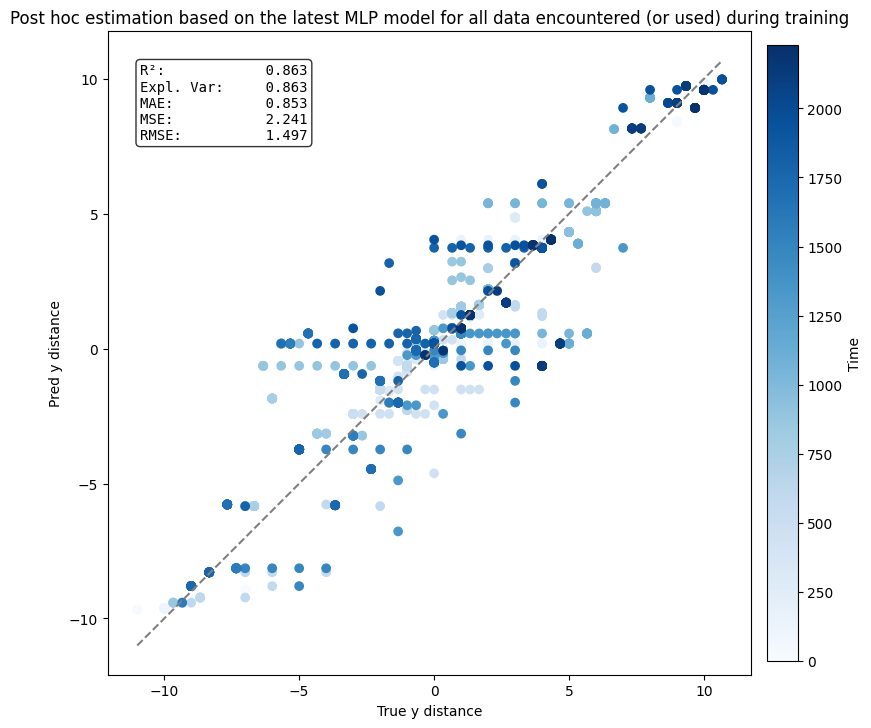

In [8544]:
postPlotter = PostPlotter(auto)

__ = 10

postPlotter.plot_mlp_scatter_prediction_RCL(limit=False,
                                            flag=3,
                                            resolution=100,
                                            transparency=0.8,
                                            cmap='Blues',
                                            colorbar=True,
                                            alpha=1.0,
                                            shrink=0.8,
                                            output_dir='Results',
                                            dpi=300,
                                            i=__)

# ---------------------------------------------------------------
# Ha valamit talán azt lehet szemlélteni ezzel hogy az idő
# múlásával egyre pontosabb a modell
#
# De ez a talmi előny abból adódik, hogy legutoljára látott
# adatokon tanult model alapján készítek becslést, az összes
# tanulás során látott adatra, tehát nyilván való, hogy a
# firssebb adatokon pontosabb lesz a legfrissebb model
# ---------------------------------------------------------------
#
# Ez a plot nem összekeverendő azzal, hogy mit becsült volna a
# modell amikor annál az adatnál járt amelyiken tanult,
#
# Nyilvánvalóan az lenne az igazán mértékadó de ahhoz a tanulás
# során el kellett volna mentenem a becsült értéket és utólag
# meg tudnám jeleníteni.

In [8545]:
# ----------------------------------------------------------------------------------
# megnézni, hogy véletlenül nem tároltam-e el a becsléseket a
# tanulás során lehet hogy csak ciklikusan de meg kellene nézni

# szerencsére eltettem őket a következő módon az alábbi két listába

# self.y_distance_predicted.append(predicted_test)
# self.y_distance_predicted_inv.append(predicted_test_inv)

print(len(auto.y_distance_predicted))
print(len(auto.y_distance_predicted_inv))
print(len(auto.y_distance_real))         # ez a tényleges távolság de tanulás közben is számolom hogy sync-ben
                                         # legyen a hossza a predicted listával
print(len(auto.y_distance))              # ez a minden időpontban bemért távolság a középponttól.

# ----------------------------------------------------------------------------------
# Ez az eltérés a két tömb csoport hosszában azért van mert a predictiont nem minden
# időpontban csinálom meg a tanulási ciklusban (csak mindne 3-ikban)
#
# Ez egyébként egy hiba mert lehetőségem volna rá hogy ugyan ugy minden időpontban
# még akkor is amikor tanulásban van a tanulás előtt kiszámítsam a becslést,
# hogy később össze tudjam vetni a ténlyeges távolság értékekel és ez alapján
# mondjak valamit a neurális háló becslésének aktuális pontosságáról.

2208
2208
2208
2230


In [8440]:
def plot_satter_pred_during_training_vs_tru_y_distance(auto, output_dir, fileName, dpi):
    fig = plt.figure(figsize=(10, 10))
    szin = np.arange(len(auto.y_distance_real))
    scat = plt.scatter(auto.y_distance_real, auto.y_distance_predicted_inv, c=szin)

    plt.xlabel('True y distance')
    plt.ylabel('Pred y distance')
    plt.title('Error of Estimation of Y Distance during training')

    # Meghatározzuk a minimum és maximum értékeket
    min_val = min(np.min(auto.y_distance_real), np.min(auto.y_distance_predicted_inv))
    max_val = max(np.max(auto.y_distance_real), np.max(auto.y_distance_predicted_inv))

    # Nagyobb abszolút érték
    limit = max(abs(min_val), abs(max_val))

    # Főátló (y = x)
    plt.plot([-limit, limit], [-limit, limit], 'r--', linewidth=1.5, label='y = x')

    # Szimmetrikus tengelyhatárok
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)

    # FONTOS: egyforma tengelyskála biztosítása
    plt.gca().set_aspect('equal', adjustable='box')

    cb = plt.colorbar(scat)
    cb.set_label('Time')

    plt.legend()
    fig.savefig(os.path.join(output_dir, f'{fileName}.png'), dpi=dpi)                
    plt.show()
    plt.close(fig)
    plt.close('all')


In [8441]:
from sklearn.metrics import r2_score, explained_variance_score, mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):  # MAPE külön implementálva
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def plot_satter_pred_during_training_vs_tru_y_distance(auto, output_dir, fileName, dpi, stat=False):
    fig = plt.figure(figsize=(10, 10))
    szin = np.arange(len(auto.y_distance_real))
    scat = plt.scatter(auto.y_distance_real, auto.y_distance_predicted_inv, c=szin)

    plt.xlabel('True y distance')
    plt.ylabel('Pred y distance')
    plt.title('Error of Estimation of Y Distance during training')
    
    # Ez nekem most csak azért kell, hogy rátegyem a plotra szövegben, hogy mennyi volt a cum eltérés a középpontól a végén
    # Feltételezzük, hogy ezek NumPy tömbök vagy listák
    y_pred = np.array(auto.y_distance_predicted_inv).ravel()   # y_distance_predicted_inv
    y_real = np.array(auto.y_distance_real).ravel()            # y_distance_real
    # Abszolút különbség és annak kumulatív összege
    abs_diff = np.abs(y_pred - y_real)
    cumulative_error = np.cumsum(abs_diff)
    cumulative_error_last = cumulative_error[-1]
    cumulative_error_last_text = (
        f"{'Cum. Dist. Err:':<12}{cumulative_error_last:>8.2f}"
    )
    plt.text(0.05, 0.67, cumulative_error_last_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    

    # Meghatározzuk a minimum és maximum értékeket
    min_val = min(np.min(auto.y_distance_real), np.min(auto.y_distance_predicted_inv))
    max_val = max(np.max(auto.y_distance_real), np.max(auto.y_distance_predicted_inv))
    limit = max(abs(min_val), abs(max_val))

    plt.plot([-limit, limit], [-limit, limit], 'r--', linewidth=1.5, label='y = x')
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.gca().set_aspect('equal', adjustable='box')

    cb = plt.colorbar(scat)
    cb.set_label('Time')

    if stat:
        y_true = np.array(auto.y_distance_real)
        y_pred = np.array(auto.y_distance_predicted_inv)

        r2 = r2_score(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        
        stats_text = (
            f"{'R²:':<12}{r2:>8.3f}\n"
            f"{'Expl. Var:':<12}{evs:>8.3f}\n"
            f"{'MSE:':<12}{mse:>8.3f}\n"
            f"{'MAE:':<12}{mae:>8.3f}\n"
            f"{'RMSE:':<12}{rmse:>8.3f}\n"
            f"{'MAPE:':<12}{mape:>8.2f} %"
        )
        
        plt.text(0.05, 0.90, stats_text, transform=plt.gca().transAxes,
                 fontsize=10, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # plt.legend()
    fig.savefig(os.path.join(output_dir, f'{fileName}.png'), dpi=dpi)
    plt.show()
    plt.close(fig)
    plt.close('all')


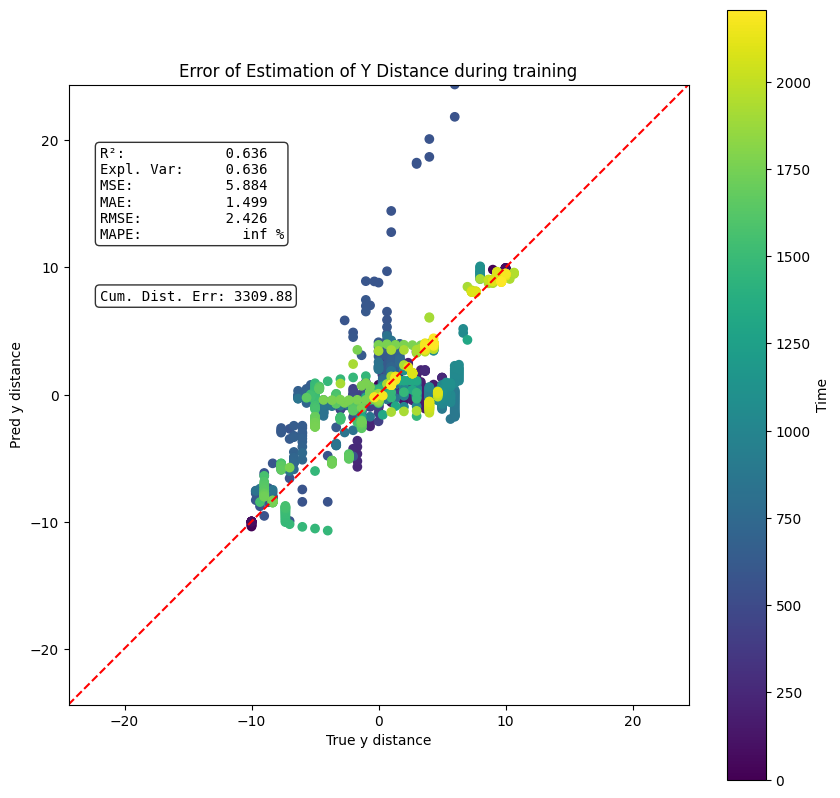

In [8546]:
output_dir = 'Results'
fileName = 'PostPlotter_3D_MLP_Prediction_Scatter'
dpi = 80

plot_satter_pred_during_training_vs_tru_y_distance(auto, output_dir, fileName, dpi, stat=True)

In [8547]:
def plot_satter_pred_during_training_vs_tru_y_distance_hist(auto, output_dir, fileName, dpi, bins=50, stat=False):

    # Adatok
    x = np.ravel(auto.y_distance_real)
    y = np.ravel(auto.y_distance_predicted_inv)
    szin = np.arange(len(x))

    # Határok
    limit = max(abs(np.min([x, y])), abs(np.max([x, y])))
    norm = Normalize(vmin=np.min(szin), vmax=np.max(szin))
    cmap = cm.get_cmap('viridis')

    # Figure és elrendezés
    fig = plt.figure(figsize=(10, 10))

    # Axes-ek pontos pozíciói (normált koordináták: [bal, alsó, szélesség, magasság])
    ax_main   = fig.add_axes([0.25, 0.25, 0.6, 0.6])  # scatter
    ax_xhist  = fig.add_axes([0.25, 0.87, 0.6, 0.1])  # top hist
    ax_yhist  = fig.add_axes([0.13, 0.25, 0.1, 0.6])  # left hist
    ax_cbar   = fig.add_axes([0.88, 0.25, 0.03, 0.6])  # colorbar külön tengelyen

    # === SCATTER ===
    sc = ax_main.scatter(x, y, c=szin, cmap=cmap)
    ax_main.plot([-limit, limit], [-limit, limit], 'r--', label='y = x')
    ax_main.set_xlim(-limit, limit)
    ax_main.set_ylim(-limit, limit)
    ax_main.set_xlabel('True y distance')
    ax_main.set_ylabel('Pred y distance')
    ax_main.set_aspect('equal', adjustable='box')
    # ax_main.legend()
    
    if stat:
        y_true = np.array(auto.y_distance_real)
        y_pred = np.array(auto.y_distance_predicted_inv)

        r2 = r2_score(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        
        stats_text = (
            f"{'R²:':<12}{r2:>8.3f}\n"
            f"{'Expl. Var:':<12}{evs:>8.3f}\n"
            f"{'MSE:':<12}{mse:>8.3f}\n"
            f"{'MAE:':<12}{mae:>8.3f}\n"
            f"{'RMSE:':<12}{rmse:>8.3f}\n"
            f"{'MAPE:':<12}{mape:>8.2f} %"
        )
        
        ax_main.text(0.05, 0.95, stats_text,
                     transform=ax_main.transAxes,
                     fontsize=10, verticalalignment='top',
                     fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # === FELSŐ HISTOGRAM (x) ===
    counts_x, bins_x = np.histogram(x, bins=bins)
    centers_x = 0.5 * (bins_x[1:] + bins_x[:-1])
    for count, left, right, center in zip(counts_x, bins_x[:-1], bins_x[1:], centers_x):
        color = cmap(norm(center))
        ax_xhist.bar(center, count, width=right-left, color=color, align='center')
    ax_xhist.set_xlim(-limit, limit)
    ax_xhist.set_xticks([])
    ax_xhist.set_ylabel('Count')

    # === BAL HISTOGRAM (y) ===
    counts_y, bins_y = np.histogram(y, bins=bins)
    centers_y = 0.5 * (bins_y[1:] + bins_y[:-1])
    for count, bottom, top, center in zip(counts_y, bins_y[:-1], bins_y[1:], centers_y):
        color = cmap(norm(center))
        ax_yhist.barh(center, count, height=top-bottom, color=color, align='center')
    ax_yhist.set_ylim(-limit, limit)
    ax_yhist.set_yticks([])
    ax_yhist.set_xlabel('Count')
    ax_yhist.invert_xaxis()

    # === COLORBAR (KÜLÖN AXISBEN, nem tol el semmit!) ===
    cb = fig.colorbar(sc, cax=ax_cbar)
    cb.set_label('Time')

    # Felső hisztogram – eltávolítjuk a jobb és felső keretet
    ax_xhist.spines['right'].set_visible(False)
    ax_xhist.spines['top'].set_visible(False)

    # Bal oldali hisztogram – eltávolítjuk a felső keretet
    ax_yhist.spines['top'].set_visible(False)
    ax_yhist.spines['left'].set_visible(False)

    # === MENTÉS ===
    fig.savefig(os.path.join(output_dir, f'{fileName}.png'), dpi=dpi)
    plt.show()
    plt.close(fig)


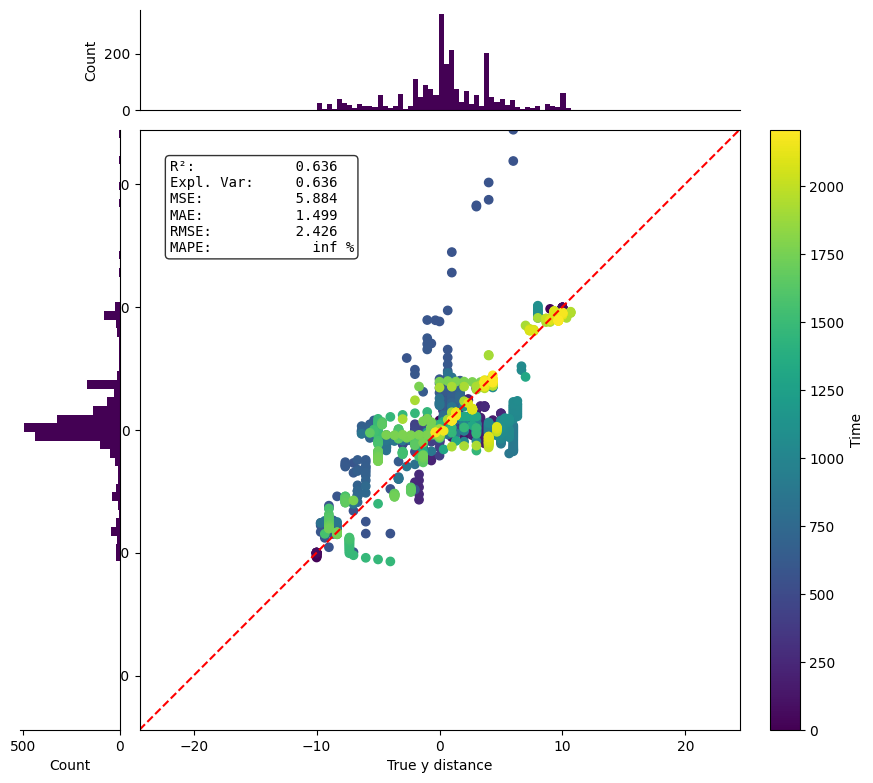

In [8548]:
output_dir = 'Results'
fileName = 'PostPlotter_3D_MLP_Prediction_Scatter_hist'
dpi = 300

plot_satter_pred_during_training_vs_tru_y_distance_hist(auto, output_dir, fileName, dpi, stat=True)

In [8445]:
def plot_current_predicted_vs_current_true_dist_during_traing(auto, output_dir, fileName, dpi, i=1):
    '''
    A tanulás során minden harmadik lépésben elmenésre kerül a model által becsült távolság érétke és a
    valódi távolság. Ezért ezek alapján tudom vizualizálni hogy mekkora volt a különbség a kettő között a
    tanulás során ahogy tanult.
    
    Ez egy jó kép lesz majd arra, hogy összehansonítsak külkönbözö NN modelleket.
    
    Figyelem:
        Ez itt nem azt hasonlítja össze, hogy mennyire tudott a célhoz közel maradni hanem azt, hogy a
        neurális háló becslése az aktuálisan mért távolságra mennyire volt pontos.
    '''
    
    # Feltételezzük, hogy ezek NumPy tömbök vagy listák
    y_pred = np.array(auto.y_distance_predicted_inv).ravel()   # y_distance_predicted_inv
    y_real = np.array(auto.y_distance_real).ravel()            # y_distance_real

    # Abszolút különbség és annak kumulatív összege
    abs_diff = np.abs(y_pred - y_real)
    cumulative_error = np.cumsum(abs_diff)

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Elsődleges tengely: előrejelzett és valós értékek
    ax1.plot(y_pred, label='Predicted Distance', color='tab:blue') # y_distance_predicted_inv
    ax1.plot(y_real, label='Real Distance', color='tab:orange')    # y_distance_real
    ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Distance from Target')
    ax1.legend(loc='upper left')
    ax1.set_title('Predicted vs. Actual Distance from Target and Cumulative Error')

    # Másodlagos tengely: kumulatív abszolút hiba
    ax2 = ax1.twinx()
    ax2.plot(cumulative_error, label='Cumulative |Error| of Neural Network', color='tab:red', linestyle='--')
    ax2.set_ylabel('Cumulative Absolute Error')
    ax2.legend(loc='lower right')

    plt.tight_layout()
    
    # === MENTÉS ===
    fig.savefig(os.path.join(output_dir, f'{fileName}{str(i)}.png'), dpi=dpi)
    plt.show()
    plt.close(fig)

In [8446]:
# ------------------------------------------------------------
# Ez is egy olyan plot metodus amit majd be kell vennem és
# fel kell használnom a különböző eredmények összehasonlításhoz
# ------------------------------------------------------------


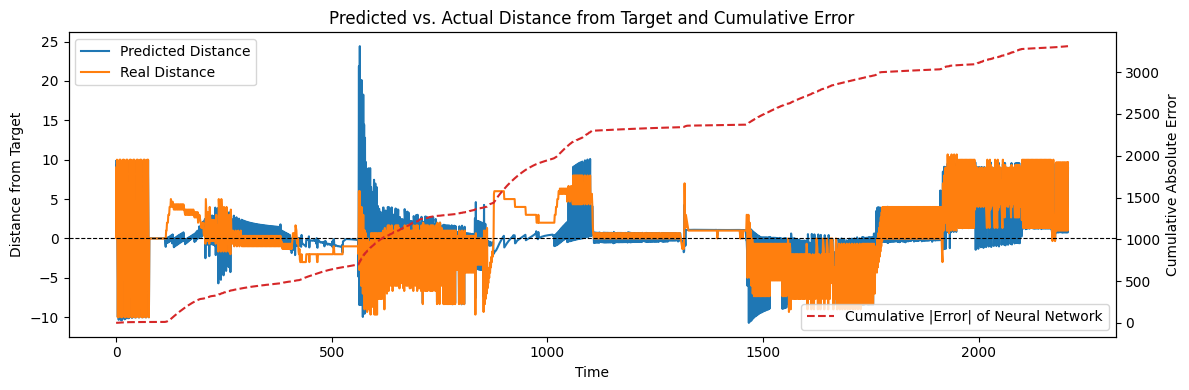

In [8549]:
output_dir = 'Results'
fileName = 'PostPlotter_Prediction_History'
dpi = 300

plot_current_predicted_vs_current_true_dist_during_traing(auto, output_dir, fileName, dpi)

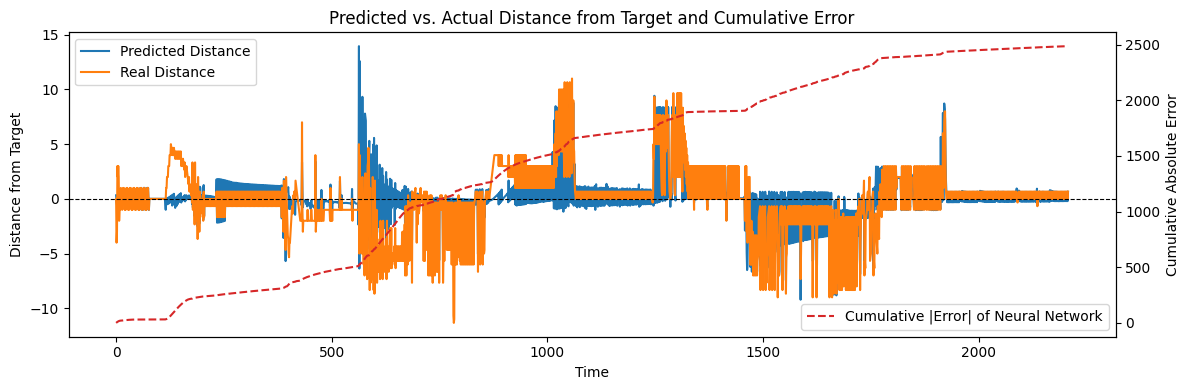

In [8448]:
plot_current_predicted_vs_current_true_dist_during_traing(auto, output_dir, fileName, dpi)

In [ ]:
# Amire még istenenees kiíváncsi lennék, hogy ha betenék egy adott beállítással egy tanulást egy cilusba
# és megpörgetném vagy 10x akkor ha utána vizualizálnom kéne az eredényet akkor azt kéne látnom, hogy
# két külkönböző beállításank az eredményei sziginifáknsan különböznek egymástól

<a name='experiments'></a>

# Experiments

[log](#log) [car](#car) [run](#run) [zip](#zip)

[Setup](#setup_current_train)

[Experiments](#experiments)

[Experiment 1](#experiment_1) | [Experiment 2](#experiment_2)

[Top](#top)

<a name='experiment_1'></a>

# FONTOS

    Ha az egyikből kiveszek valamit akkor azt a másikból is ki kell venni.
    
    A mostani futásban a 12-es ilyen
    
    Érdekes, hogy mindkettőben kiment a picsába és rögtön az elején, ezért mindkettő módszert esetében elment.
    
    
    # -------
    
    Egy másik dolog, hogy még elötte meg kell nézni hogy az az egy ami most lefut ott mekorra különönbség van a két mód között.

In [ ]:
road = Road(wide = 30, length = 2550, type = 5,
            ramp_up_length    = 300,
            ramp_down_length  = 300,
            flat_top_length   = 150,
            flat_bottom_length= 150,
            trapezoid_height  = 100)

plotter = Plotter()
platter = Platter()
storage = Storage()

settings = {
    'hidden_layer_sizes': (5, 3),     # (5, 3)
    'learning_rate_init': 0.01,       # 0.01, 0.0001
    'solver': 'adam',                 # sgd, adam
    'activation': 'tanh',             # tanh, relu, logistic
    'nesterovs_momentum': False,
    'max_iter': 5,                    # 1
    'fit_intercept': False,           # Legyen-e intercept a LinearRegression
    'action_range': (10, 1),           # A lehtséges lépések sávja (-7, ..., +7) és a lépésköz
    'scaler_type': 'Fix',             # None, MinMax, Standard, Fix, Cut, Log, SignedLog, Reciprocal, Robust, Quantile
    'feature_range': (55, 55),        # Fix esetén az első az X, a második az y osztója (25, 75), !(25, 25), !(55, 55) (25, 10)
    'multi_sensor_regression': True,  # Ture
    'stop_external_move_at_i': 100,   # Ennyi lépés után már ne csináljon mesterséges mozgatást
    'random_state': 1,
}

auto = Car(road, plotter, platter, storage, settings)

auto.sight = 50
auto.sight_center = 50 # 250

auto.calculate_distances()
auto.platter.plot_history(auto, 1)

## Nem volt mesterséges mozgatás.

In [ ]:
printer._nf = False

In [ ]:
%%time

experiments = {}

for i in range(10):
    settings['random_state'] = i

    auto = Car(road, plotter, platter, storage, settings)
    
    auto.sight = 50
    auto.sight_center = 50  # 250
    
    auto.calculate_distances()
    auto.mlp.verbose = False
    printer._nf = False
    printer._ut = False
    auto.print_rate = 90000
    
    start_time = time.time()
    auto.run(2230)
    end_time = time.time()
    duration = end_time - start_time
    print(f'# {i} run metódus futási ideje: {duration:.3f} másodperc')
    
    experiments[i] = {
        'i': i,
        'settings': copy.deepcopy(settings),
        'auto': copy.deepcopy(auto)
    }

In [ ]:
import pickle

os.makedirs("Experiments", exist_ok=True)

file_path = os.path.join("Experiments", "experiments__1a_no_artifical_move.pkl")

with open(file_path, "wb") as f:
    pickle.dump(experiments, f)


In [ ]:
file_path = os.path.join("Experiments", "experiments__1a_no_artifical_move.pkl")

with open(file_path, "rb") as f:
    # loaded_experiments = pickle.load(f)
    experiments = pickle.load(f)


In [ ]:
experiments

In [ ]:
for e in experiments:
    print(e)
    experiments[e]['auto'].platter.plot_history(experiments[e]['auto'], 1)

In [ ]:

para_futasok = (12, 24)


In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        postPlotter = PostPlotter(experiments[e]['auto'])
        postPlotter.plot_history(flag = 1, show_y_distance=True)

In [ ]:
cum_errors_totals = []
nn_cum_errors_totals = []

for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        # a.plotter.test_plot2(a.sensor_left, a.sensor_right, a.y_distance, a.x, flag=1, lists=[6])
        y_real = np.array(a.y_distance_real).flatten()
        y_pred = np.array(a.y_distance_predicted_inv).flatten()
        y_dist = np.array(a.y_distance)

        # Tengelytől vett eltérés értéke
        err = np.cumsum(np.abs(a.y_distance))
        cum_err = err[-1]
        cum_errors_totals.append(cum_err)
        # print(cum_err)

        # A neurális háló által adott becslések hibáinak cumulatív érétkei
        nn_err = np.abs(y_real - y_pred)
        nn_err_cum_sum = np.cumsum(nn_err)
        nn_cum_err = nn_err_cum_sum[-1]
        nn_cum_errors_totals.append(nn_cum_err)
        # print(nn_cum_err)

# A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása
cum_errors_totals = np.array(cum_errors_totals)
cum_errors_totals_avg = np.mean(cum_errors_totals)
cum_errors_totals_std = np.std(cum_errors_totals)

# A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása
nn_cum_errors_totals = np.array(nn_cum_errors_totals)
nn_cum_errors_totals_avg = np.mean(nn_cum_errors_totals)
nn_cum_errors_totals_std = np.std(nn_cum_errors_totals)

print('A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása')
print(f'cum_errors_totals_avg = {cum_errors_totals_avg:.2f}')
print(f'cum_errors_totals_std = {cum_errors_totals_std:.2f}')

print('A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása')
print(f'nn_cum_errors_totals_avg = {nn_cum_errors_totals_avg:.2f}')
print(f'nn_cum_errors_totals_std = {nn_cum_errors_totals_std:.2f}')

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        a.plotter.test_plot2(a, a.x, flag=1, lists=[6], force=True)

In [ ]:
output_dir = 'Results'
fileName = 'temp'
dpi = 80

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_current_predicted_vs_current_true_dist_during_traing(a, output_dir, fileName, dpi, i=i)

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_satter_pred_during_training_vs_tru_y_distance(a, output_dir, fileName, dpi, stat=True)

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_satter_pred_during_training_vs_tru_y_distance_hist(a, output_dir, fileName, dpi, stat=True)

In [ ]:
def plot_multiple_histories(cars, show_y_distance=False):
    if not cars:
        print("Nincs megjeleníthető autó.")
        return

    fig, ax = cars[0].road.show()

    # Viridis színskála létrehozása n autóra
    cmap = plt.get_cmap('viridis')
    cmap = plt.get_cmap('Blues') # Blues_r
    
    colors = [cmap(i / max(len(cars) - 1, 1)) for i in range(len(cars))]

    for idx, car in enumerate(cars):
        color = colors[idx]

        circle = plt.Circle((car.x, car.y), 5, color='black')
        ax.add_patch(circle)

        ax.plot(
            range(int(car.x), int(car.x + car.distance_center_from_wall)),
            [car.y] * car.distance_center_from_wall,
            color=color,
            linestyle='--'
        )

        ax.plot(
            range(int(car.x), int(car.x + car.distance_left_from_wall)),
            range(int(car.y), int(car.y + car.distance_left_from_wall)),
            color=color,
            linestyle=':'
        )

        ax.plot(
            range(int(car.x), int(car.x + car.distance_right_from_wall)),
            range(int(car.y), int(car.y - car.distance_right_from_wall), -1),
            color=color,
            linestyle=':'
        )

        if show_y_distance and hasattr(car, 'y_distance'):
            __ = 500
            ax.plot(
                np.array(car.y_distance) + __,
                label=f'Car {car.x} y_distance',
                color=color
            )
            ax.axhline(__, color='black', lw=1.0, ls='--')

        if hasattr(car, 'y_history') and len(car.y_history) > 0:
            ax.plot(car.y_history, label=f'Car {car.x} y_history', color=color)

        if hasattr(car, 'plot_y_min') and hasattr(car, 'plot_y_max'):
            if car.plot_y_min is not None and car.plot_y_max is not None:
                ax.set_ylim(car.plot_y_min, car.plot_y_max)

    ax.legend()
    plt.title("Több autó pályatörténete")
    plt.savefig('Results/Zoo.png', dpi=300, format='png')
    plt.show()


In [ ]:
cars = [experiments[e]['auto'] for e in experiments]
plot_multiple_histories(cars, show_y_distance=False)


In [ ]:
# cars = [experiments[e]['auto'] for e in experiments]
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories(cars, show_y_distance=False)


In [ ]:
def plot_multiple_histories_fill(cars, show_y_distance=False):
    if not cars:
        print("Nincs megjeleníthető autó.")
        return

    fig, ax = cars[0].road.show()

    # Szín kiválasztása a háttérkitöltéshez
    cmap = plt.get_cmap('viridis')
    fill_color = cmap(0.6)  # pl. középtónusú szín
    fill_alpha = 0.3        # áttetszőség

    # y_history gyűjtése
    histories = [car.y_history for car in cars if hasattr(car, 'y_history') and len(car.y_history) > 0]

    if not histories:
        print("Egyik autónak sincs y_history adata.")
        return

    # Az összes history-t azonos hosszra hozzuk (padding vagy vágás)
    min_len = min(len(h) for h in histories)
    trimmed_histories = [h[:min_len] for h in histories]  # vágjuk őket
    all_histories = np.array(trimmed_histories)

    y_min = np.min(all_histories, axis=0)
    y_max = np.max(all_histories, axis=0)
    x = np.arange(min_len)

    # Kitöltött terület kirajzolása
    ax.fill_between(x, y_min, y_max, color=fill_color, alpha=fill_alpha, label='y_history min-max sáv')

    ax.legend()
    plt.title("Y_history min-max tartomány (több autó)")
    plt.show()


In [ ]:
cars = [experiments[e]['auto'] for e in list(experiments)[:5]]
plot_multiple_histories_fill(cars, show_y_distance=False)

In [ ]:
def plot_multiple_histories_bolinger(cars, show_y_distance=False):
    if not cars:
        print("Nincs megjeleníthető autó.")
        return

    fig, ax = cars[0].road.show()

    # Colormap és szín az árnyékoláshoz
    cmap = plt.get_cmap('viridis')
    fill_color = cmap(0.6)
    fill_alpha = 0.3

    # y_history gyűjtése
    histories = [car.y_history for car in cars if hasattr(car, 'y_history') and len(car.y_history) > 0]

    if not histories:
        print("Egyik autónak sincs y_history adata.")
        return

    # Az összes history-t azonos hosszra hozzuk (vágás)
    min_len = min(len(h) for h in histories)
    trimmed_histories = [h[:min_len] for h in histories]
    all_histories = np.array(trimmed_histories)
    
    print('min_ien            ', min_len)
    print('all_histories.shape', all_histories.shape)

    # Statisztika
    y_mean = np.mean(all_histories, axis=0)
    y_median = np.median(all_histories, axis=0)
    y_std = np.std(all_histories, axis=0)
    y_upper = y_median + y_std
    y_lower = y_median - y_std
    x = np.arange(min_len)
    
    print('y_mean.shape       ', y_mean.shape)
    print('y_std.shape        ', y_std.shape)

    # Kitöltés: átlag ± szórás
    ax.fill_between(x, y_lower, y_upper, color=fill_color, alpha=fill_alpha, label='átlag ± szórás')

    # Átlag vonal megjelenítése
    ax.plot(x, y_mean, color='black', label='average', linewidth=1, ls='--')
    
    # Medián vonal megjelenítése
    ax.plot(x, y_median, color='black', label='median', linewidth=2)

    # Opcionális: autók pozíciójának megjelenítése
    for car in cars:
        circle = plt.Circle((car.x, car.y), 5, color='black')
        ax.add_patch(circle)

    ax.legend()
    plt.title("Y_history: átlag ± szórás (több autó)")
    plt.xlabel("Idő / lépésszám")
    plt.ylabel("Y érték")
    plt.grid(True)
    plt.savefig('Results/Zen.png', format='png', dpi=300)
    plt.show()


In [ ]:
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories_bolinger(cars, show_y_distance=False)

<a name='experiment_2'></a>

[log](#log) [car](#car) [run](#run) [zip](#zip)

[Setup](#setup_current_train)

[Experiments](#experiments)

[Experiment 1](#experiment_1) | [Experiment 2](#experiment_2)

[Top](#top)

# <font color='red'>Itt van mesterséges mozgatás</font>

In [ ]:
road = Road(wide = 30, length = 2550, type = 5,
            ramp_up_length    = 300,
            ramp_down_length  = 300,
            flat_top_length   = 150,
            flat_bottom_length= 150,
            trapezoid_height  = 100)

plotter = Plotter()
platter = Platter()
storage = Storage()

settings = {
    'hidden_layer_sizes': (5, 3),     # (5, 3)
    'learning_rate_init': 0.01,       # 0.01, 0.0001
    'solver': 'adam',                 # sgd, adam
    'activation': 'tanh',             # tanh, relu, logistic
    'nesterovs_momentum': False,
    'max_iter': 5,                    # 1
    'fit_intercept': False,           # Legyen-e intercept a LinearRegression
    'action_range': (10, 1),           # A lehtséges lépések sávja (-7, ..., +7) és a lépésköz
    'scaler_type': 'Fix',             # None, MinMax, Standard, Fix, Cut, Log, SignedLog, Reciprocal, Robust, Quantile
    'feature_range': (55, 55),        # Fix esetén az első az X, a második az y osztója (25, 75), !(25, 25), !(55, 55) (25, 10)
    'multi_sensor_regression': True,  # Ture
    'stop_external_move_at_i': 100,   # Ennyi lépés után már ne csináljon mesterséges mozgatást
    'random_state': 1,
}

auto = Car(road, plotter, platter, storage, settings)

auto.sight = 50
auto.sight_center = 50 # 250

auto.calculate_distances()
auto.platter.plot_history(auto, 1)

In [ ]:
%%time

experiments = {}

for i in range(10):
    settings['random_state'] = i

    auto = Car(road, plotter, platter, storage, settings)
    
    auto.sight = 50
    auto.sight_center = 50 # 250
    
    auto.calculate_distances()
    auto.mlp.verbose = False
    printer._nf = False
    printer._ut = False
    auto.print_rate = 90000
    
    start_time = time.time()
    
    auto.artificial_jump_frequency = 110 # 200
    auto.artificial_jump_value     = 5  # 50
    
    auto.run(2230, artificial_jump=True)
    
    end_time = time.time()
    duration = end_time - start_time
    print(f'# {i} run metódus futási ideje: {duration:.3f} másodperc')
    
    experiments[i] = {
        'i': i,
        'settings': copy.deepcopy(settings),
        'auto': copy.deepcopy(auto)
    }

In [ ]:
import pickle

os.makedirs("Experiments", exist_ok=True)

file_path = os.path.join("Experiments", "experiments__1a_with_artifical_move.pkl")

with open(file_path, "wb") as f:
    pickle.dump(experiments, f)


In [ ]:
file_path = os.path.join("Experiments", "experiments__1a_with_artifical_move.pkl")

with open(file_path, "rb") as f:
    # loaded_experiments = pickle.load(f)
    experiments = pickle.load(f)


In [ ]:
experiments

In [ ]:
for e in experiments:
    print(e)
    experiments[e]['auto'].platter.plot_history(experiments[e]['auto'], 1)

In [ ]:

para_futasok = (12, 24)


In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        postPlotter = PostPlotter(experiments[e]['auto'])
        postPlotter.plot_history(flag = 1, show_y_distance=True)

In [ ]:
cum_errors_totals = []
nn_cum_errors_totals = []

for e in experiments:
    print(e)
    a = experiments[e]['auto']
    # a.plotter.test_plot2(a.sensor_left, a.sensor_right, a.y_distance, a.x, flag=1, lists=[6])
    y_real = np.array(a.y_distance_real).flatten()
    y_pred = np.array(a.y_distance_predicted_inv).flatten()
    y_dist = np.array(a.y_distance)

    # Tengelytől vett eltérés értéke
    err = np.cumsum(np.abs(a.y_distance))
    cum_err = err[-1]
    cum_errors_totals.append(cum_err)
    # print(cum_err)
    
    # A neurális háló által adott becslések hibáinak cumulatív érétkei
    nn_err = np.abs(y_real - y_pred)
    nn_err_cum_sum = np.cumsum(nn_err)
    nn_cum_err = nn_err_cum_sum[-1]
    nn_cum_errors_totals.append(nn_cum_err)
    # print(nn_cum_err)

# A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása
cum_errors_totals = np.array(cum_errors_totals)
cum_errors_totals_avg = np.mean(cum_errors_totals)
cum_errors_totals_std = np.std(cum_errors_totals)

# A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása
nn_cum_errors_totals = np.array(nn_cum_errors_totals)
nn_cum_errors_totals_avg = np.mean(nn_cum_errors_totals)
nn_cum_errors_totals_std = np.std(nn_cum_errors_totals)

print('A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása')
print(f'cum_errors_totals_avg = {cum_errors_totals_avg:.2f}')
print(f'cum_errors_totals_std = {cum_errors_totals_std:.2f}')

print('A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása')
print(f'nn_cum_errors_totals_avg = {nn_cum_errors_totals_avg:.2f}')
print(f'nn_cum_errors_totals_std = {nn_cum_errors_totals_std:.2f}')

In [ ]:
# Ki kell venni belőle egyet mert volt egy extrem rossz meres

In [ ]:
cum_errors_totals = []
nn_cum_errors_totals = []

for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        # a.plotter.test_plot2(a.sensor_left, a.sensor_right, a.y_distance, a.x, flag=1, lists=[6])
        y_real = np.array(a.y_distance_real).flatten()
        y_pred = np.array(a.y_distance_predicted_inv).flatten()
        y_dist = np.array(a.y_distance)

        # Tengelytől vett eltérés értéke
        err = np.cumsum(np.abs(a.y_distance))
        cum_err = err[-1]
        cum_errors_totals.append(cum_err)
        # print(cum_err)

        # A neurális háló által adott becslések hibáinak cumulatív érétkei
        nn_err = np.abs(y_real - y_pred)
        nn_err_cum_sum = np.cumsum(nn_err)
        nn_cum_err = nn_err_cum_sum[-1]
        nn_cum_errors_totals.append(nn_cum_err)
        # print(nn_cum_err)

# A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása
cum_errors_totals = np.array(cum_errors_totals)
cum_errors_totals_avg = np.mean(cum_errors_totals)
cum_errors_totals_std = np.std(cum_errors_totals)

# A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása
nn_cum_errors_totals = np.array(nn_cum_errors_totals)
nn_cum_errors_totals_avg = np.mean(nn_cum_errors_totals)
nn_cum_errors_totals_std = np.std(nn_cum_errors_totals)

print('A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása')
print(f'cum_errors_totals_avg = {cum_errors_totals_avg:.2f}')
print(f'cum_errors_totals_std = {cum_errors_totals_std:.2f}')

print('A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása')
print(f'nn_cum_errors_totals_avg = {nn_cum_errors_totals_avg:.2f}')
print(f'nn_cum_errors_totals_std = {nn_cum_errors_totals_std:.2f}')

    # NEM VOLT AI MOZGATAS

    A kisérletek végén elért cumulatív error utolsó értékeienek átlaga és szórása
    cum_errors_totals_avg = 8887.53
    cum_errors_totals_std = 9548.64
    A kisérletek végén a neurális háló által adott becslések hibáinak összege, átlaga és szórása
    nn_cum_errors_totals_avg = 6822.59
    nn_cum_errors_totals_std = 4893.33

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        a.plotter.test_plot2(a, a.x, flag=1, lists=[6], force=True)

In [ ]:
output_dir = 'Results'
fileName = 'temp'
dpi = 80

for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_current_predicted_vs_current_true_dist_during_traing(a, output_dir, fileName, dpi, i=i)

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_satter_pred_during_training_vs_tru_y_distance(a, output_dir, fileName, dpi)

In [ ]:
for i, e in enumerate(experiments):
    if i not in para_futasok:
        print(e)
        a = experiments[e]['auto']
        plot_satter_pred_during_training_vs_tru_y_distance_hist(a, output_dir, fileName, dpi)

In [ ]:
cars = [experiments[e]['auto'] for e in experiments]
plot_multiple_histories(cars, show_y_distance=False)


In [ ]:
# cars = [experiments[e]['auto'] for e in experiments]
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories(cars, show_y_distance=False)


In [ ]:
# cars = [experiments[e]['auto'] for e in experiments]
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories_fill(cars, show_y_distance=False)


In [ ]:
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories_bolinger(cars, show_y_distance=False)


In [ ]:
cars = [experiments[e]['auto'] for i, e in enumerate(experiments) if i not in para_futasok]
plot_multiple_histories_bolinger(cars, show_y_distance=False)


[Experiment_1](#experiment_1)

In [ ]:
# Create rotated animation from still image - sensor_left, sensor_right vs y_distance, predcition

# Temporary disabled - flag = 0

for i in range(100):
    postPlotter.plot_mlp_surface_prediction_v4(limit=True,
                                               flag=0,
                                               resolution=100,
                                               transparency=0.8,
                                               cmap='Blues',
                                               center=100,
                                               elevation=10,
                                               azimuth=i,
                                               i=i)

In [ ]:
# https://matplotlib.org/stable/tutorials/colors/colormaps.html

postPlotter = PostPlotter(auto)

postPlotter.plot_mlp_surface_prediction_v4(resolution=100, transparency=0.8, cmap='Blues', center=100)

postPlotter.plot_sensors_distibution(bins=20)

In [ ]:
postPlotter = PostPlotter(testAuto)
postPlotter.plot_y_move_v2(car = testAuto, x = 1, flag = 1, height = 5)

In [ ]:
testAuto.plot_history(1)

# Data

In [ ]:
# Egyéként ha majd azt akarom csinálni, hogy menet közben nem akarok kiprintelni semmit
# de a végén szeretnék néhány képet csinálni a meglévő függvényekkel.
# Akkor nem kell újra írnom őket, hanem a Car ojektumon átálitom a <<flag>>
# értékeket és meghívom az adott plot() függvényt valahogy így

# auto.plot_investigation_flag = 1          # 0 - disable, 1 - plot, 2 - save, 3 - both

# auto.plot_investigation_senors(_y_test_full, predicted_test_full, self.plot_investigation_flag)

# bár azért ezzel óvatósan, ki tudja mit tárolt el éppen az utolsó változó

<a name="zip"></a> [log](#log) [plt](#plt) [str](#str) [car](#car) [run](#run) [dev](#dev) zip [tst](#tst)

# Zip *.png to images.zip

In [ ]:
%%capture
! zip -0 images.zip *.png

In [ ]:
from google.colab import files

files.download('images.zip')

# Save to MP4

A gif exportot kivettem, ha kell a régebiek között X23 megtalálható.<br>
Felváltottam az MP4 Exporttal.

[log](#log) [plt](#plt) [car](#car) [run](#run) [dev](#dev) [zip](#zip)

In [ ]:
import os
import glob
from google.colab import files

def create_animated_mp4(filter = 'history*.png', prefix = 'ani_', framerate = 10):
  output = prefix + filter[0:filter.find('*')] + '.mp4'
  # print('output = ', output)
  os.system('rm ' + output)
  if( len(glob.glob(filter)) > 0 ):
    # os.system('ffmpeg -r ' + str(framerate) + ' -pattern_type glob -i "' + filter + '" -vcodec mpeg4 -y ' + output)
    os.system('ffmpeg -r ' + str(framerate) + ' -pattern_type glob -i "' + filter + '" -vcodec libx264 -crf 25 -pix_fmt yuv420p ' + output)

    print('ok')

    # rossz egyenként letöltögetni őket, ugyhogy inkább be zippelem és egyben letöltöm
    # files.download(output)
  else:
    # print('Nincsenek ilyen filok a szürési feltétel alapján -> ezért videót sem csináltunk')
    print('skipped')
    pass

In [ ]:
create_animated_mp4('history*.png', 'ani_', framerate=10)

create_animated_mp4('y_move*.png', framerate=10)

create_animated_mp4('trace*.png', framerate=10)

In [ ]:
create_animated_mp4('sensorCenterAfterScaled_vs_sensorCenterPredictedAfterScaled_S1*.png', framerate=10)

create_animated_mp4('sensorCenterBeforeScaled_vs_sensorCenterAfterScaled_v1*.png', framerate=10)

create_animated_mp4('sensorCenterBeforeScaled_vs_sensorCenterAfterScaled_v2*.png', framerate=10)

create_animated_mp4('sensorCenterBeforeScaled_vs_sensorCenterAfterScaled_v3*.png', framerate=10)

create_animated_mp4('sensorCenter_vs_yDistance_v1*.png', framerate=2)

create_animated_mp4('sensorLeftAfterScaled_vs_sensorLeftPredictedAfterScaled_S1*.png', framerate=10)

create_animated_mp4('sensorLeftBeforeScaled_vs_sensorLeftAfterScaled_v1*.png', framerate=10)

create_animated_mp4('sensorLeftBeforeScaled_vs_sensorLeftAfterScaled_v3*.png', framerate=10)

create_animated_mp4('sensorRightAfterScaled_vs_sensorRightPredictedAfterScaled_S1*.png', framerate=10)

create_animated_mp4('sensorRightBeforeScaled_vs_sensorRightAfterScaled_v1*.png', framerate=10)

create_animated_mp4('sensorRightBeforeScaled_vs_sensorRightAfterScaled_v2*.png', framerate=10)

create_animated_mp4('sensorRightBeforeScaled_vs_sensorRightAfterScaled_v3*.png', framerate=10)

create_animated_mp4('sensorRight_vs_yDistance_v1*.png', framerate=2)

create_animated_mp4('state_space_discover_LeftRightCenter_3D*.png', framerate=10)

create_animated_mp4('state_space_discover_LeftRightYDistance_3D*.png', framerate=10)

create_animated_mp4('state_space_discover_LeftRightYDistance_2D*.png', framerate=10)

create_animated_mp4('state_space_discover_LeftRightYDistance_WhitoutBorder*.png', framerate=10)

create_animated_mp4('yDistance_vs_yDistance_predicted_type0*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_type1*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_type2*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_type3*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_type4*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_type5*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_typeWrong*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_typeCorrect_bw*.png', framerate=2)

create_animated_mp4('yDistance_vs_yDistance_predicted_typeCorrect_col*.png', framerate=2)



create_animated_mp4('state_space_discover_new_plotter_LeftRightYDistance_3D_v1*.png', framerate=10)

create_animated_mp4('state_space_discover_new_plotter_LeftRightYDistance_3D_v2*.png', framerate=10)

create_animated_mp4('state_space_discover_new_plotter_LeftRightYDistance_3D_v3*.png', framerate=10)

create_animated_mp4('state_space_discover_new_plotter_LeftRightYDistance_3D_v4*.png', framerate=10)

create_animated_mp4('state_space_discover_new_plotter_LeftRightYDistance_3D_v5*.png', framerate=10)



create_animated_mp4('timeline_sensors_v1*.png', framerate=10)


create_animated_mp4('ANN_*.png', framerate=10)


In [ ]:
create_animated_mp4('Plot3D*.png', framerate=10)

create_animated_mp4('PostPlotter_3D_MLP_Prediction*.png', framerate=10)

In [ ]:
%%capture
! zip -0 ani.zip *.mp4

In [ ]:
files.download('ani.zip')

In [ ]:
# !rm *.png *.mp4

In [ ]:
# !unzip images.zip

<a name="tst"></a> [log](#log) [plt](#plt) [str](#str) [car](#car) [run](#run) [dev](#dev) [zip](#zip) tst

# Test Auto

In [ ]:
# Save

# Via storage object -> passing a car object
storage.save_mlp_from_object(auto)
storage.save_regression_from_object(auto)
storage.save_minmaxscaler_from_object(auto)

# Via auto.storage object -> passing a car object and its property fields
#  -> this can be used inside the car.run() methos as well
auto.storage.save_mlp(auto.mlp)
auto.storage.save_minmaxscaler(auto.x_minmaxscaler, auto.y_minmaxscaler)
auto.storage.save_regression(auto.regression_left, auto.regression_center, auto.regression_right)

# Both, the storage and the auto.storage has the same refrence, so it works back and forth

# ----------------------------------------------------------------------------------------

# Load

# Via storage object -> these are void methods but updates its own self.property fields which later can be called such 'storage.mlp', 'storage.regression_left'
storage.load_mlp()
storage.load_regression()
storage.load_minmaxscaler()


# Via car object -> these are the same as above (as storage is a property of the car object) -> works as a static void or a vodi setter
auto.storage.load_mlp()
auto.storage.load_regression()
auto.storage.load_minmaxscaler()
# Both, the storage and the auto.storage has the same refrence, so it works back and forth


# Ez viszont csak az auto objektumon kereszül érhető el és nem perzistens, gyakorlatilag ezt mentjük el és ezt váltjuk ki a betöltéssel, ha van mit betölteni
auto.mlp

# Ha el lett menteve akármelyik módszerrel
storage.save_mlp_from_object(auto)
auto.storage.save_mlp(auto.mlp)
# Akkor utána elérhető akár az auto.storage objektumon keresztül
auto.storage.mlp
# Akár a storage objektumon keresztül, mert minkettőnek ugyan az a referenciája
storage.mlp

# lényegében ha a storage load megtörtént akkor ezt kell használnom a tesztautóban
# a tesztautó példányosításnál kapja meg a storage-ot és az __init__-ben híja
# meg a load_all metodust

# tanuló car (auto) pedig a futás végén hívja meg a storage save_all metodust
# ezzel gyakorlatilag kiírja minden modelt amit majd a teszt autó be tud olvasni




In [ ]:
# Igazából azt hiszem az utat sem kell újra megcsinálnunk, de ha később új utat szeretnénk neki adni azt itt tehetjük meg
road = Road(wide = 100, length = 3000)
# A plotter objektumot sem kell újra példányosítanunk, helyette a régi plottert kapja meg
# plotter = Plotter()
# Nem csinálunk új storage objektumot, helyette a feltanítottat kapja meg
# storage = Storage()
testAuto = TestCar(road, plotter, storage)

testAuto.calculate_distances()
testAuto.plot_history(1)

testAuto.run(2650)

## Itt hasonlítom össze a testAuto futási eredményeit

By the way -> kis zavar lehet az erőben, hogy mikor melyik objektumon melyik metodust használom.

1. Car objektumnak vannak bizonyos plot funkcói.<br>
Főként azokat tettem ide amelyekből animációt akarok csinálni, vagy futás közben is akarom látni a kimenetüket.

2. Car objektum példányosításnál kap egy Plotter objektumot.<br>
Ennek az volt az elsődleges célja, hogy kivezessem a Car osztályból a Plot funkciókat.<br>
A Plotter osztály olyan faramucin lett megírva, hogy a metodusai és azok szignaturája elég változatos és specifikus. Tulajdonképpen itt is arról van szó, hogyha valamit menet közben és többször is ki akarok plottoltani, akkor annak a Car objektumban kell lennie.

3. PostPlotter osztály viszont egy Car objektumot kap és minden metodusa úgy van megírva, hogy a Car objektumból olvassa ki az adatokat. Ezzel a módszerrel a futás utáni eredményeket akartam megjeleníteni. 

> **Lényegében:** A Car vagy TestCar osztályba marha kényelmes plot fügvényeket tenni, csak nem célszerű. Mert fejlesztésnél akár hányszor átirom őket újra kell példányosítanom magát az objektumot és azzal együtt elveszik minden benne tárolt adat - Sajnos ez akkor sem lesz jobb ha kiszervezem ezeket a Plotter osztályba mert azt is Car és a TestCar osztály kapja meg. Erre van a PostPlotter osztály ami egy Car objektumot vár. Ha már jó és beállítottam mindent egy adott plot metoduson utána átrakhatom a Plotter osztályba, fejlesztés alatt viszont a PostPlotter osztályban van.

Végeredményben elég lenne a Plotter osztály és a másik ket megoldást (PostPlotter és hogy a Car objektumank vannak plot metodusai) ki kellene vezetni.

In [ ]:
# Nem post plotter, hanem az auto.plot_history(flag = 1)
testAuto.plot_history(1)

In [ ]:
# Nem post plotter, hanem az auto.plot_history(flag = 1)
testAuto.plot_history(1)

In [ ]:
testAuto.plotter.test_plot2(testAuto.sensor_left, testAuto.sensor_right, testAuto.y_distance, testAuto.x, 1, [99])

In [ ]:
testAuto.plotter.test_plot2(testAuto.sensor_left, testAuto.sensor_right, testAuto.y_distance, testAuto.x, 1, [99])

In [ ]:
# cummulativ error utolsó értéke

np.cumsum(np.abs(testAuto.y_distance))[-1]

In [ ]:
# cummulativ error utolsó értéke

np.cumsum(np.abs(testAuto.y_distance))[-1]

In [ ]:
# max legnagyobb lépés a futás során

tmp = np.diff(np.array(testAuto.y_history), 1, -1, prepend=0)
tmp[0] = 0
np.array(tmp).max()

In [ ]:
testAuto.plotter.plot_y_move(testAuto.y_history, testAuto.x, 1)

In [ ]:
testAuto.plotter.plot_y_move(testAuto.y_history, testAuto.x, 1)

In [ ]:
%%capture
! rm images.zip
! zip -0 images.zip *.png

In [ ]:
files.download('images.zip')

In [ ]:
create_animated_mp4('test_history*.png', 'ani_', framerate=10)

In [ ]:
%%capture
! zip -0 ani.zip *.mp4

In [ ]:
files.download('ani.zip')

<a name="irodalom"></a>

# Felhasznált irodalom és internetes cimek

Itt gyűjtöttem össze a menet közben összegyűjt okosságokat

[vissza a tartalomhoz](#tartalom)<br>

Scikit-learn - MLPRegressor API
<br>
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


Fogalmak és probléma meghatározás
<br>
https://www.rubrik.com/blog/architecture/20/12/customized-autoscaling--minimize-your-cloud-cost


https://github.com/kubernetes/autoscaler/blob/master/cluster-autoscaler/FAQ.md#what-are-the-parameters-to-ca

https://arxiv.org/pdf/1608.04030.pdf

Metrikák amivel a szollgáltatás minőségét mérik különböző esetekben
<br>
https://blog.avinetworks.com/autoscaling-metrics

------------

NumPy API Reference Guide
<br>
https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html


Seaborn API Reference Guide
<br>
https://seaborn.pydata.org/examples/pair_grid_with_kde.html


Python Logger API Reference Guide
<br>
https://docs.python.org/3/howto/logging-cookbook.html#logging-cookbook


Python Logger API Tutorial
<br>
https://coralogix.com/blog/python-logging-best-practices-tips


PyPlot Colorbar Tutorial
<br>
https://matplotlib.org/stable/tutorials/colors/colorbar_only.html


PyPlot Subplot Tutorial
<br>
https://jakevdp.github.io/PythonDataScienceHandbook/04.07-customizing-colorbars.html


Scikit Learn ONYX Save model
<br>
http://onnx.ai/sklearn-onnx


Scikit Learn Save Model
<br>
https://stackabuse.com/scikit-learn-save-and-restore-models

------------

Scikit learn API Warm_start and Partial_fit
<br>
https://newbedev.com/what-is-the-difference-between-partial-fit-and-warm-start


Online learning
<br>
https://www.dummies.com/programming/big-data/data-science/tips-for-dealing-with-big-data-in-python/


Online learning
<br>
https://dziganto.github.io/data%20science/online%20learning/python/scikit-learn/An-Introduction-To-Online-Machine-Learning/


------------

Huber Loss
<br>
https://en.wikipedia.org/wiki/Huber_loss


Gradient Descent - van benne egy tök jó animáció - emlékszem amikor az első ilyet írtam 10 éve
<br>
https://en.wikipedia.org/wiki/Gradient_descent


Online Learning
<br>
https://en.wikipedia.org/wiki/Online_machine_learning


Ezen tök jól lehet demonstrálni, hogy miért tanul gyorsan a 'relu', gyorsabban a 'tanh' és lassan a 'logistic' azonos beállítások mellett, habár végül midhárom közel azonos eredményre vezet
<br>
https://playground.tensorflow.org

-------------------

Wow
<br>
https://matplotlib.org/devdocs/gallery/mplot3d/voxels_numpy_logo.html

Wow - Nice Pyplot Graphics
<br>
<a href="https://www.google.com/imgres?imgurl=https%3A%2F%2Fi.stack.imgur.com%2F0FSLf.png&imgrefurl=https%3A%2F%2Fstackoverflow.com%2Fquestions%2F48672663%2Fmatplotlib-render-all-internal-voxels-with-alpha&tbnid=ug0Bk5AvbBFGoM&vet=12ahUKEwiF_vrC0d7zAhUfiv0HHZkkCD4QxiAoA3oECAAQIw..i&docid=lv23pEYcw_qlvM&w=465&h=367&itg=1&q=pyplot%203d%20plot%20wall&ved=2ahUKEwiF_vrC0d7zAhUfiv0HHZkkCD4QxiAoA3oECAAQIw">Google search</a>

Wow - Nice Pyplot Graphics
<br>
<a href="https://www.google.com/imgres?imgurl=https%3A%2F%2Fi.stack.imgur.com%2FvLogW.png&imgrefurl=https%3A%2F%2Fstackoverflow.com%2Fquestions%2F48672663%2Fmatplotlib-render-all-internal-voxels-with-alpha&tbnid=jmhk8RQrADn_iM&vet=12ahUKEwivwqC44d7zAhUH8LsIHWVICYkQxiAoAHoECAAQEQ..i&docid=lv23pEYcw_qlvM&w=428&h=352&itg=1&q=pyplot%203d%20plot%20wall&ved=2ahUKEwivwqC44d7zAhUH8LsIHWVICYkQxiAoAHoECAAQEQ">Google search</a>

Wow - Nice Pyplot Graphics
<br>
<a href="https://www.google.com/imgres?imgurl=https%3A%2F%2Fwww.researchgate.net%2Fprofile%2FAndrew-Thompson-21%2Fpublication%2F256099533%2Ffigure%2Ffig2%2FAS%3A601596220153863%401520443124187%2FThree-possible-2D-views-of-a-3D-surface-representing-the-response-to-two-drugs-A.png&imgrefurl=https%3A%2F%2Fwww.researchgate.net%2Ffigure%2FThree-possible-2D-views-of-a-3D-surface-representing-the-response-to-two-drugs-A_fig2_256099533&tbnid=PCWbaGIBwOUEqM&vet=12ahUKEwjU5bet0d7zAhUZ8rsIHQuQDVAQxiAoBXoECAAQGQ..i&docid=sbOccjnKSDRdPM&w=850&h=1014&itg=1&q=pyplot%203d%20plot%20wall&ved=2ahUKEwjU5bet0d7zAhUZ8rsIHQuQDVAQxiAoBXoECAAQGQ">Google search</a>

-----------

PyPlot - Memory issue and its solution
<br>
https://www.py4u.net/discuss/208758